In [5]:
# ======================================================================================
# Cell 1S — Setup independent sizing research branch
# ======================================================================================
#
# Objective:
#   Create the sizing research branch and manifest.
#
# This notebook starts sizing research after the locked signal stack:
#   Core → Secondary → Tertiary Front
#
# Important:
#   This notebook does NOT change signal parameters.
#   This notebook starts by evaluating every active layer × tenor sleeve independently.
#   There is no one-trade-per-day assumption in the independent sizing panel.
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 900)
pd.set_option("display.width", 1600)

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SOURCE_BRANCH = "vrp_unified_fds_core_signal_threshold_research_v1"
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SOURCE_BRANCH
SOURCE_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SOURCE_BRANCH

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH
OUT_CHART_DIR = OUT_AUDIT_DIR / "charts"

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CHART_DIR.mkdir(parents=True, exist_ok=True)

CELL1S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"

LOCKED_STACK_VERSION = "core_secondary_tertiary_signal_stack_locked_v1"
LOCKED_STACK_DECISION_ID = "core_secondary_tertiary_signal_stack_locked_001"

LOCKED_CORE_DECISION_ID = "core_repaired_v1_locked_001"
LOCKED_SECONDARY_DECISION_ID = "secondary_frequency_unlock_locked_001"
LOCKED_TERTIARY_DECISION_ID = "tertiary_front_cleaner_quality_locked_001"

NOTEBOOK_PURPOSE = (
    "Independent sizing research for the locked Core → Secondary → Tertiary Front signal stack. "
    "This notebook evaluates every active layer × tenor sleeve independently before portfolio-level exposure caps."
)

manifest = {
    "cell": "Cell 1S — Setup independent sizing research branch",
    "timestamp": CELL1S_TIMESTAMP,
    "project_root": str(PROJECT_ROOT),
    "source_branch": SOURCE_BRANCH,
    "sizing_branch": SIZING_BRANCH,
    "source_processed_dir": str(SOURCE_PROCESSED_DIR),
    "source_audit_dir": str(SOURCE_AUDIT_DIR),
    "out_processed_dir": str(OUT_PROCESSED_DIR),
    "out_audit_dir": str(OUT_AUDIT_DIR),
    "out_chart_dir": str(OUT_CHART_DIR),
    "locked_model_spec": LOCKED_MODEL_SPEC,
    "locked_stack_version": LOCKED_STACK_VERSION,
    "locked_stack_decision_id": LOCKED_STACK_DECISION_ID,
    "locked_core_decision_id": LOCKED_CORE_DECISION_ID,
    "locked_secondary_decision_id": LOCKED_SECONDARY_DECISION_ID,
    "locked_tertiary_decision_id": LOCKED_TERTIARY_DECISION_ID,
    "purpose": NOTEBOOK_PURPOSE,
    "research_contract": [
        "Do not change signal parameters.",
        "Do not enforce one-trade-per-day selection in the independent sleeve panel.",
        "Do not enforce Core-first / Secondary-before-Tertiary gate in the independent sleeve panel.",
        "Evaluate every active layer × tenor sleeve independently.",
        "Sizing outputs are research diagnostics, not production sizing locks.",
        "Portfolio overlap caps come later.",
    ],
}

manifest_path = OUT_AUDIT_DIR / f"01S_independent_sizing_manifest_{CELL1S_TIMESTAMP}.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("=" * 100)
print("Cell 1S — Setup independent sizing research branch")
print("=" * 100)
print(f"Source branch:      {SOURCE_BRANCH}")
print(f"Sizing branch:      {SIZING_BRANCH}")
print(f"Processed output:   {OUT_PROCESSED_DIR}")
print(f"Audit output:       {OUT_AUDIT_DIR}")
print(f"Manifest:           {manifest_path}")
print()
print("CELL 1S PASSED — SIZING BRANCH SETUP COMPLETE")

Cell 1S — Setup independent sizing research branch
Source branch:      vrp_unified_fds_core_signal_threshold_research_v1
Sizing branch:      vrp_core_secondary_tertiary_independent_sizing_research_v1
Processed output:   C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1
Audit output:       C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1
Manifest:           C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\01S_independent_sizing_manifest_20260705_213107.json

CELL 1S PASSED — SIZING BRANCH SETUP COMPLETE


In [6]:
# ======================================================================================
# Cell 2S — Load locked signal stack and base panel
# ======================================================================================
#
# Objective:
#   Load the immutable Cell 23R signal stack and the unified signal base panel.
#
# Inputs:
#   - 23R_core_secondary_tertiary_locked_rules_long_*.parquet
#   - 23R_core_secondary_tertiary_lock_validation_*.csv
#   - 01R_unified_fds_signal_base_panel_with_rv21d_*.parquet
#
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def normalize_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


CELL2S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

locked_rules_path = latest_file(
    SOURCE_PROCESSED_DIR,
    "23R_core_secondary_tertiary_locked_rules_long_*.parquet",
    required=True,
)

locked_rules_wide_path = latest_file(
    SOURCE_PROCESSED_DIR,
    "23R_core_secondary_tertiary_locked_rules_wide_*.parquet",
    required=True,
)

locked_validation_path = latest_file(
    SOURCE_AUDIT_DIR,
    "23R_core_secondary_tertiary_lock_validation_*.csv",
    required=True,
)

locked_manifest_path = latest_file(
    SOURCE_AUDIT_DIR,
    "23R_core_secondary_tertiary_lock_manifest_*.json",
    required=False,
)

base_panel_path = latest_file(
    SOURCE_PROCESSED_DIR,
    "01R_unified_fds_signal_base_panel_with_rv21d_*.parquet",
    required=True,
)

locked_rules_long = pd.read_parquet(locked_rules_path)
locked_rules_wide = pd.read_parquet(locked_rules_wide_path)
locked_validation = pd.read_csv(locked_validation_path)
base_raw = pd.read_parquet(base_panel_path)

base = base_raw.copy()

if "model_spec" in base.columns:
    base = base[base["model_spec"].eq(LOCKED_MODEL_SPEC)].copy()

base["trade_date"] = pd.to_datetime(base["trade_date"], errors="coerce").dt.normalize()

for c in [
    "tenor",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "forecast_vol_pct",
    "implied_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
    "actual_dte",
]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

rules = locked_rules_long.copy()

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in rules.columns:
        rules[c] = pd.to_numeric(rules[c], errors="coerce")

rules["include_tenor"] = normalize_bool_series(rules["include_tenor"])

active_rules = rules[rules["include_tenor"].eq(True)].copy()
inactive_rules = rules[rules["include_tenor"].eq(False)].copy()

total_signal_dates = int(base["trade_date"].nunique())

validation_rows = []

locked_validation_failures = (
    locked_validation[locked_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(locked_validation.columns)
    else pd.DataFrame({"dummy": [1]})
)

required_base_cols = [
    "trade_date",
    "tenor",
    "model_spec",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
]

missing_base_cols = [c for c in required_base_cols if c not in base.columns]

required_rule_cols = [
    "stack_lock_version",
    "stack_lock_decision_id",
    "model_spec",
    "signal_layer",
    "signal_priority",
    "lock_version",
    "lock_decision_id",
    "tenor",
    "tenor_bucket",
    "tenor_bucket_order",
    "include_tenor",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]

missing_rule_cols = [c for c in required_rule_cols if c not in rules.columns]

add_validation(
    validation_rows,
    "base_panel_loaded",
    "PASS" if len(base) > 0 else "FAIL",
    f"rows={len(base):,}; path={base_panel_path}",
)

add_validation(
    validation_rows,
    "base_model_filtered",
    "PASS" if sorted(base["model_spec"].dropna().unique().tolist()) == [LOCKED_MODEL_SPEC] else "FAIL",
    f"models_after_filter={sorted(base['model_spec'].dropna().unique().tolist()) if 'model_spec' in base.columns else []}",
)

add_validation(
    validation_rows,
    "required_base_columns_available",
    "PASS" if not missing_base_cols else "FAIL",
    f"missing={missing_base_cols}",
)

add_validation(
    validation_rows,
    "locked_rules_loaded",
    "PASS" if len(rules) == 19 else "FAIL",
    f"rows={len(rules):,}; path={locked_rules_path}",
)

add_validation(
    validation_rows,
    "locked_rules_wide_loaded",
    "PASS" if len(locked_rules_wide) > 0 else "FAIL",
    f"rows={len(locked_rules_wide):,}; path={locked_rules_wide_path}",
)

add_validation(
    validation_rows,
    "required_rule_columns_available",
    "PASS" if not missing_rule_cols else "FAIL",
    f"missing={missing_rule_cols}",
)

add_validation(
    validation_rows,
    "locked_validation_passed",
    "PASS" if locked_validation_failures.empty else "FAIL",
    f"failures={len(locked_validation_failures):,}; path={locked_validation_path}",
)

add_validation(
    validation_rows,
    "stack_lock_id_matches",
    "PASS" if rules["stack_lock_decision_id"].dropna().eq(LOCKED_STACK_DECISION_ID).all() else "FAIL",
    f"expected={LOCKED_STACK_DECISION_ID}; found={sorted(rules['stack_lock_decision_id'].dropna().unique().tolist())}",
)

add_validation(
    validation_rows,
    "active_rule_count",
    "PASS" if len(active_rules) == 16 else "FAIL",
    f"active_rows={len(active_rules):,}; expected=16",
)

add_validation(
    validation_rows,
    "inactive_secondary_front_count",
    "PASS" if len(inactive_rules[inactive_rules['signal_layer'].eq('Secondary')]) == 3 else "FAIL",
    f"inactive_secondary_rows={len(inactive_rules[inactive_rules['signal_layer'].eq('Secondary')]):,}; expected=3",
)

load_validation = pd.DataFrame(validation_rows)
failures = load_validation[load_validation["status"].eq("FAIL")]

load_validation_path = OUT_AUDIT_DIR / f"02S_locked_signal_stack_load_validation_{CELL2S_TIMESTAMP}.csv"
active_rules_path = OUT_AUDIT_DIR / f"02S_active_sizing_rules_{CELL2S_TIMESTAMP}.csv"
inactive_rules_path = OUT_AUDIT_DIR / f"02S_inactive_locked_rules_{CELL2S_TIMESTAMP}.csv"

load_validation.to_csv(load_validation_path, index=False)
active_rules.to_csv(active_rules_path, index=False)
inactive_rules.to_csv(inactive_rules_path, index=False)

if not failures.empty:
    display(load_validation)
    raise RuntimeError("Cell 2S validation failed. Review validation output above.")

print("=" * 100)
print("Cell 2S — Loaded locked signal stack and base panel")
print("=" * 100)
print(f"Base panel:                  {base_panel_path}")
print(f"Locked rules long:           {locked_rules_path}")
print(f"Locked rules wide:           {locked_rules_wide_path}")
print(f"Locked validation:           {locked_validation_path}")
print(f"Locked manifest:             {locked_manifest_path}")
print(f"Base rows after model filter:{len(base):,}")
print(f"Date range:                  {base['trade_date'].min().date()} to {base['trade_date'].max().date()}")
print(f"Total signal dates:          {total_signal_dates:,}")
print(f"Active sizing sleeves:       {len(active_rules):,}")
print()
print("Validation:")
display(load_validation)

print()
print("Active rules used for independent sizing:")
display(active_rules)

print("\nCELL 2S PASSED — LOCKED SIGNAL STACK LOADED")


Cell 2S — Loaded locked signal stack and base panel
Base panel:                  C:\Users\patri\vrp_project\data\processed\vrp_unified_fds_core_signal_threshold_research_v1\01R_unified_fds_signal_base_panel_with_rv21d_20200102_20260701_20260705_113538.parquet
Locked rules long:           C:\Users\patri\vrp_project\data\processed\vrp_unified_fds_core_signal_threshold_research_v1\23R_core_secondary_tertiary_locked_rules_long_20260705_210625.parquet
Locked rules wide:           C:\Users\patri\vrp_project\data\processed\vrp_unified_fds_core_signal_threshold_research_v1\23R_core_secondary_tertiary_locked_rules_wide_20260705_210625.parquet
Locked validation:           C:\Users\patri\vrp_project\data\audit\vrp_unified_fds_core_signal_threshold_research_v1\23R_core_secondary_tertiary_lock_validation_20260705_210625.csv
Locked manifest:             C:\Users\patri\vrp_project\data\audit\vrp_unified_fds_core_signal_threshold_research_v1\23R_core_secondary_tertiary_lock_manifest_20260705_210625.js

,check,status,detail
0,base_panel_loaded,PASS,"rows=14,688; path=C:\Users\patri\vrp_project\d..."
1,base_model_filtered,PASS,models_after_filter=['unified_fds_no_min_return']
2,required_base_columns_available,PASS,missing=[]
3,locked_rules_loaded,PASS,rows=19; path=C:\Users\patri\vrp_project\data\...
4,locked_rules_wide_loaded,PASS,rows=6; path=C:\Users\patri\vrp_project\data\p...
5,required_rule_columns_available,PASS,missing=[]
6,locked_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...
7,stack_lock_id_matches,PASS,expected=core_secondary_tertiary_signal_stack_...
8,active_rule_count,PASS,active_rows=16; expected=16
9,inactive_secondary_front_count,PASS,inactive_secondary_rows=3; expected=3



Active rules used for independent sizing:


,stack_lock_version,stack_lock_decision_id,model_spec,signal_layer,signal_priority,lock_version,lock_decision_id,supersedes_lock_version,supersedes_lock_decision_id,tenor,tenor_bucket,tenor_bucket_order,include_tenor,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,comparison_operator_model_vrp_log,comparison_operator_model_vrp_z_3m,comparison_operator_model_vrp_z_1y,comparison_operator_RSI14,comparison_operator_rv21d_vol_pct,vrp_measure,forecast_model,rv_floor_contract,selection_rule,source_cell,source_candidate_id,exclusion_reason,created_timestamp
0,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,12,Front,1,True,0.60,0.65,0.65,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
1,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,15,Front,1,True,0.60,0.65,0.65,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
2,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,18,Front,1,True,0.60,0.65,0.65,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
3,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,21,Middle,2,True,0.65,0.70,0.70,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
4,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,24,Middle,2,True,0.65,0.70,0.70,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
5,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,27,Back,3,True,0.70,0.70,0.70,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705_210625
6,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001,unified_fds_no_min_return,Core,1,core_repaired_v1,core_repaired_v1_locked_001,None,None,30,Back,3,True,0.70,0.70,0.70,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core first. If any locked Core tenor qualifies...,Cell 11R — Core repaired v1 lock,core_repaired_v1_locked_001,None,20260705


CELL 2S PASSED — LOCKED SIGNAL STACK LOADED


In [7]:
# ======================================================================================
# Cell 3S — Build independent eligible trade panel
# ======================================================================================
#
# Objective:
#   Evaluate every active layer × tenor rule independently.
#
# Critical sizing-research choice:
#   - No one-trade-per-day rule.
#   - No Core-first gate.
#   - No Secondary-before-Tertiary gate.
#   - If Core 12D and Tertiary 12D both qualify on the same date, both are retained
#     as separate sizing sleeves.
#
# Output:
#   One row per qualifying sleeve × tenor × date.
#
# ======================================================================================

CELL3S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

def build_sleeve_id(rule_row):
    return (
        f"{str(rule_row['signal_layer']).strip()}_"
        f"{str(rule_row['tenor_bucket']).strip()}_"
        f"{int(rule_row['tenor'])}D"
    )


eligible_rows = []

for _, rule in active_rules.sort_values(["signal_priority", "tenor"]).iterrows():
    tenor = int(rule["tenor"])
    layer = str(rule["signal_layer"])
    bucket = str(rule["tenor_bucket"])
    sleeve_id = build_sleeve_id(rule)

    q = base[
        base["tenor"].eq(tenor)
        & base["model_vrp_log"].gt(rule["model_vrp_log_min"])
        & base["model_vrp_z_3m"].gt(rule["model_vrp_z_3m_min"])
        & base["model_vrp_z_1y"].gt(rule["model_vrp_z_1y_min"])
        & base["RSI14"].lt(rule["RSI14_max"])
        & base["rv21d_vol_pct"].gt(rule["rv21d_vol_pct_min"])
        & base["normalized_pnl_dollars"].notna()
        & base["normalized_pnl_per_day"].notna()
        & base["win"].notna()
    ].copy()

    if q.empty:
        continue

    q["sizing_research_version"] = "independent_sleeve_sizing_research_v1"
    q["sizing_panel_type"] = "independent_sleeve_opportunity_panel"

    q["sleeve_id"] = sleeve_id
    q["signal_layer"] = layer
    q["signal_priority"] = int(rule["signal_priority"])
    q["tenor_bucket"] = bucket
    q["tenor_bucket_order"] = int(rule["tenor_bucket_order"])

    q["lock_version"] = rule["lock_version"]
    q["lock_decision_id"] = rule["lock_decision_id"]
    q["stack_lock_version"] = rule["stack_lock_version"]
    q["stack_lock_decision_id"] = rule["stack_lock_decision_id"]

    q["rule_model_vrp_log_min"] = float(rule["model_vrp_log_min"])
    q["rule_model_vrp_z_3m_min"] = float(rule["model_vrp_z_3m_min"])
    q["rule_model_vrp_z_1y_min"] = float(rule["model_vrp_z_1y_min"])
    q["rule_RSI14_max"] = float(rule["RSI14_max"])
    q["rule_rv21d_vol_pct_min"] = float(rule["rv21d_vol_pct_min"])

    q["rule_source_cell"] = rule.get("source_cell", None)
    q["rule_source_candidate_id"] = rule.get("source_candidate_id", None)

    q["independent_sizing_note"] = (
        "Independent sizing panel. No Core-first gate, no Secondary gate, and no one-trade-per-day cap."
    )

    eligible_rows.append(q)

if eligible_rows:
    independent_panel = pd.concat(eligible_rows, ignore_index=True, sort=False)
else:
    independent_panel = pd.DataFrame()

if independent_panel.empty:
    raise RuntimeError("No independent sizing opportunities found. Check active rules and base panel inputs.")

independent_panel["trade_date"] = pd.to_datetime(independent_panel["trade_date"], errors="coerce").dt.normalize()

independent_panel = independent_panel.sort_values(
    ["trade_date", "signal_priority", "tenor_bucket_order", "tenor", "sleeve_id"]
).reset_index(drop=True)

# Diagnostics: overlaps are expected across sleeves.
date_opportunity_counts = (
    independent_panel
    .groupby("trade_date", as_index=False)
    .agg(
        opportunity_count=("sleeve_id", "count"),
        distinct_sleeves=("sleeve_id", "nunique"),
        distinct_tenors=("tenor", "nunique"),
        layers_active=("signal_layer", lambda x: ",".join(sorted(set(map(str, x))))),
    )
    .sort_values(["opportunity_count", "trade_date"], ascending=[False, True])
)

sleeve_counts = (
    independent_panel
    .groupby(
        [
            "sleeve_id",
            "signal_layer",
            "signal_priority",
            "tenor_bucket",
            "tenor_bucket_order",
            "tenor",
            "rule_model_vrp_log_min",
            "rule_model_vrp_z_3m_min",
            "rule_model_vrp_z_1y_min",
            "rule_RSI14_max",
            "rule_rv21d_vol_pct_min",
        ],
        as_index=False,
    )
    .agg(
        trades=("sleeve_id", "count"),
        unique_trade_dates=("trade_date", "nunique"),
        date_min=("trade_date", "min"),
        date_max=("trade_date", "max"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
    )
    .sort_values(["signal_priority", "tenor_bucket_order", "tenor"])
)

validation_rows = []

expected_active_sleeves = active_rules.assign(
    expected_sleeve_id=active_rules.apply(build_sleeve_id, axis=1)
)["expected_sleeve_id"].tolist()

actual_sleeves = sorted(independent_panel["sleeve_id"].dropna().unique().tolist())

missing_sleeves = sorted(set(expected_active_sleeves) - set(actual_sleeves))

bad_rule_duplicate = (
    independent_panel
    .groupby(["sleeve_id", "trade_date"])
    .size()
    .reset_index(name="rows")
)

bad_rule_duplicate = bad_rule_duplicate[bad_rule_duplicate["rows"].gt(1)]

add_validation(
    validation_rows,
    "independent_panel_rows",
    "PASS" if len(independent_panel) > 0 else "FAIL",
    f"rows={len(independent_panel):,}",
)

add_validation(
    validation_rows,
    "all_active_sleeves_present",
    "PASS" if not missing_sleeves else "WARN",
    f"actual_sleeves={len(actual_sleeves):,}; expected={len(expected_active_sleeves):,}; missing={missing_sleeves}",
)

add_validation(
    validation_rows,
    "one_row_per_sleeve_date",
    "PASS" if bad_rule_duplicate.empty else "FAIL",
    f"bad_rows={len(bad_rule_duplicate):,}",
)

add_validation(
    validation_rows,
    "one_trade_per_day_not_enforced",
    "PASS" if date_opportunity_counts["opportunity_count"].max() > 1 else "WARN",
    f"max_opportunities_on_single_date={int(date_opportunity_counts['opportunity_count'].max())}",
)

add_validation(
    validation_rows,
    "core_secondary_tertiary_gates_not_enforced",
    "PASS",
    "Independent sizing panel evaluates every active sleeve independently.",
)

panel_validation = pd.DataFrame(validation_rows)
failures = panel_validation[panel_validation["status"].eq("FAIL")]

independent_panel_csv = OUT_AUDIT_DIR / f"03S_independent_sleeve_opportunity_panel_{CELL3S_TIMESTAMP}.csv"
independent_panel_parquet = OUT_PROCESSED_DIR / f"03S_independent_sleeve_opportunity_panel_{CELL3S_TIMESTAMP}.parquet"

sleeve_counts_csv = OUT_AUDIT_DIR / f"03S_independent_sleeve_counts_{CELL3S_TIMESTAMP}.csv"
date_opportunity_counts_csv = OUT_AUDIT_DIR / f"03S_independent_date_opportunity_counts_{CELL3S_TIMESTAMP}.csv"
panel_validation_csv = OUT_AUDIT_DIR / f"03S_independent_panel_validation_{CELL3S_TIMESTAMP}.csv"

independent_panel.to_csv(independent_panel_csv, index=False)
independent_panel.to_parquet(independent_panel_parquet, index=False)

sleeve_counts.to_csv(sleeve_counts_csv, index=False)
date_opportunity_counts.to_csv(date_opportunity_counts_csv, index=False)
panel_validation.to_csv(panel_validation_csv, index=False)

if not failures.empty:
    display(panel_validation)
    raise RuntimeError("Cell 3S validation failed. Review validation output above.")

print("=" * 100)
print("Cell 3S — Independent eligible trade panel built")
print("=" * 100)
print(f"Independent panel rows:      {len(independent_panel):,}")
print(f"Active sleeves with trades:  {independent_panel['sleeve_id'].nunique():,}")
print(f"Date range:                  {independent_panel['trade_date'].min().date()} to {independent_panel['trade_date'].max().date()}")
print(f"Max opportunities/date:      {int(date_opportunity_counts['opportunity_count'].max())}")
print(f"Saved panel:                 {independent_panel_parquet}")
print()
print("Validation:")
display(panel_validation)

print()
print("Sleeve counts:")
display(sleeve_counts)

print()
print("Dates with most independent opportunities:")
display(date_opportunity_counts.head(25))

print("\nCELL 3S PASSED — INDEPENDENT SLEEVE OPPORTUNITY PANEL BUILT")

Cell 3S — Independent eligible trade panel built
Independent panel rows:      3,112
Active sleeves with trades:  16
Date range:                  2020-12-31 to 2026-05-13
Max opportunities/date:      16
Saved panel:                 C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\03S_independent_sleeve_opportunity_panel_20260705_213129.parquet

Validation:


,check,status,detail
0,independent_panel_rows,PASS,"rows=3,112"
1,all_active_sleeves_present,PASS,actual_sleeves=16; expected=16; missing=[]
2,one_row_per_sleeve_date,PASS,bad_rows=0
3,one_trade_per_day_not_enforced,PASS,max_opportunities_on_single_date=16
4,core_secondary_tertiary_gates_not_enforced,PASS,Independent sizing panel evaluates every activ...



Sleeve counts:


,sleeve_id,signal_layer,signal_priority,tenor_bucket,tenor_bucket_order,tenor,rule_model_vrp_log_min,rule_model_vrp_z_3m_min,rule_model_vrp_z_1y_min,rule_RSI14_max,rule_rv21d_vol_pct_min,trades,unique_trade_dates,date_min,date_max,win_rate,avg_pnl_per_day,total_pnl
3,Core_Front_12D,Core,1,Front,1,12,0.60,0.65,0.65,70.0,8.5,202,202,2021-11-26,2026-04-29,0.772277,419.060388,1.015802e+06
4,Core_Front_15D,Core,1,Front,1,15,0.60,0.65,0.65,70.0,8.5,169,169,2021-11-26,2026-04-29,0.810651,560.438199,1.420711e+06
5,Core_Front_18D,Core,1,Front,1,18,0.60,0.65,0.65,70.0,8.5,168,168,2021-12-01,2026-04-29,0.851190,601.478060,1.818870e+06
6,Core_Middle_21D,Core,1,Middle,2,21,0.65,0.70,0.70,70.0,8.5,146,146,2021-12-01,2026-04-29,0.849315,582.804165,1.786878e+06
7,Core_Middle_24D,Core,1,Middle,2,24,0.65,0.70,0.70,70.0,8.5,148,148,2021-12-01,2026-04-29,0.851351,522.835118,1.857110e+06
0,Core_Back_27D,Core,1,Back,3,27,0.70,0.70,0.70,70.0,8.5,136,136,2021-12-01,2026-04-29,0.875000,567.163740,2.082625e+06
1,Core_Back_30D,Core,1,Back,3,30,0.70,0.70,0.70,70.0,8.5,134,134,2021-12-01,2026-04-29,0.902985,600.006302,2.412025e+06
2,Core_Back_33D,Core,1,Back,3,33,0.70,0.70,0.70,70.0,8.5,136,136,2021-12-01,2026-04-29,0.926471,610.808698,2.741309e+06
11,Secondary_Middle_21D,Secondary,2,Middle,2,21,0.60,0.60,0.60,76.0,7.0,180,180,2020-12-31,2026-05-11,0.844444,555.895037,2.101283e+06
12,Secondary_Middle_24D,Secondary,2,Middle,2,24,0.60,0.60,0.60,76.0,7.0,183,183,2020-12-31,2026-05-13,0.846995,456.560420,2.005213e+06



Dates with most independent opportunities:


,trade_date,opportunity_count,distinct_sleeves,distinct_tenors,layers_active
25,2021-12-01,16,16,8,"Core,Secondary,Tertiary"
27,2021-12-03,16,16,8,"Core,Secondary,Tertiary"
31,2022-01-21,16,16,8,"Core,Secondary,Tertiary"
32,2022-01-24,16,16,8,"Core,Secondary,Tertiary"
33,2022-01-25,16,16,8,"Core,Secondary,Tertiary"
34,2022-01-26,16,16,8,"Core,Secondary,Tertiary"
35,2022-01-27,16,16,8,"Core,Secondary,Tertiary"
36,2022-01-28,16,16,8,"Core,Secondary,Tertiary"
41,2022-02-11,16,16,8,"Core,Secondary,Tertiary"
42,2022-02-14,16,16,8,"Core,Secondary,Tertiary"



CELL 3S PASSED — INDEPENDENT SLEEVE OPPORTUNITY PANEL BUILT


In [8]:
# ======================================================================================
# Cell 4S — Sleeve-level performance and tail diagnostics
# ======================================================================================
#
# Objective:
#   Summarize every independent sleeve using win rate, avg/day, tail loss, VaR,
#   expected shortfall, drawdown, and year-by-year stability.
#
# Important:
#   1% and 5% expected loss are computed from normalized_pnl_per_day.
#   Negative P&L is a loss. Positive expected_loss columns are shown as positive numbers.
#
# ======================================================================================

CELL4S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

def profit_factor(pnl):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    gross_profit = float(x[x > 0].sum())
    gross_loss = float(x[x < 0].sum())

    if gross_loss < 0:
        return gross_profit / abs(gross_loss)

    if gross_profit > 0:
        return np.inf

    return np.nan


def max_drawdown(pnl):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum().to_numpy()
    running_peak = np.maximum.accumulate(np.r_[0.0, cumulative])[:-1]
    dd = cumulative - running_peak

    return float(np.min(dd))


def worst_rolling_sum(pnl, window):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    if len(x) < window:
        return float(x.sum())

    return float(x.rolling(window=window, min_periods=window).sum().min())


def var_es_stats(pnl, q):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return {
            f"var_{int(q * 100)}pct": np.nan,
            f"expected_shortfall_{int(q * 100)}pct": np.nan,
            f"expected_loss_{int(q * 100)}pct_positive": np.nan,
            f"tail_count_{int(q * 100)}pct": 0,
        }

    cutoff = float(x.quantile(q))
    tail = x[x <= cutoff]

    es = float(tail.mean()) if len(tail) else np.nan
    expected_loss_positive = max(0.0, -es) if pd.notna(es) else np.nan

    return {
        f"var_{int(q * 100)}pct": cutoff,
        f"expected_shortfall_{int(q * 100)}pct": es,
        f"expected_loss_{int(q * 100)}pct_positive": expected_loss_positive,
        f"tail_count_{int(q * 100)}pct": int(len(tail)),
    }


def summarize_sleeve(g):
    g = g.sort_values("trade_date").copy()

    pnl = pd.to_numeric(g["normalized_pnl_dollars"], errors="coerce")
    pnl_day = pd.to_numeric(g["normalized_pnl_per_day"], errors="coerce")
    wins = pd.to_numeric(g["win"], errors="coerce")

    pos_day = pnl_day[pnl_day > 0]
    neg_day = pnl_day[pnl_day < 0]

    avg_win_day = float(pos_day.mean()) if len(pos_day) else np.nan
    avg_loss_day = float(neg_day.mean()) if len(neg_day) else np.nan

    row = {
        "trades": int(len(g)),
        "unique_trade_dates": int(g["trade_date"].nunique()),
        "date_min": g["trade_date"].min(),
        "date_max": g["trade_date"].max(),

        "win_rate": float(wins.mean()) if wins.notna().sum() else np.nan,

        "total_pnl": float(pnl.sum()),
        "avg_pnl": float(pnl.mean()),
        "median_pnl": float(pnl.median()),
        "worst_trade": float(pnl.min()),
        "best_trade": float(pnl.max()),

        "total_pnl_per_day": float(pnl_day.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "best_trade_pnl_per_day": float(pnl_day.max()),

        "profit_factor": profit_factor(pnl),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),

        "avg_win_pnl_per_day": avg_win_day,
        "avg_loss_pnl_per_day": avg_loss_day,
        "avg_win_to_abs_avg_loss_ratio": (
            avg_win_day / abs(avg_loss_day)
            if pd.notna(avg_win_day) and pd.notna(avg_loss_day) and avg_loss_day < 0
            else np.nan
        ),

        "loss_rate": float((pnl_day < 0).mean()),
        "loss_count": int((pnl_day < 0).sum()),

        "drawdown_pnl": max_drawdown(pnl),
        "drawdown_pnl_per_day": max_drawdown(pnl_day),

        "worst_5_trade_sum": worst_rolling_sum(pnl, 5),
        "worst_10_trade_sum": worst_rolling_sum(pnl, 10),
        "worst_20_trade_sum": worst_rolling_sum(pnl, 20),

        "worst_5_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 5),
        "worst_10_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 10),
        "worst_20_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 20),

        "trades_le_neg_25k": int((pnl <= -25_000).sum()),
        "trades_le_neg_50k": int((pnl <= -50_000).sum()),
        "trades_le_neg_100k": int((pnl <= -100_000).sum()),

        "avg_model_vrp_log": float(g["model_vrp_log"].mean()),
        "avg_model_vrp_z_3m": float(g["model_vrp_z_3m"].mean()),
        "avg_model_vrp_z_1y": float(g["model_vrp_z_1y"].mean()),
        "avg_RSI14": float(g["RSI14"].mean()),
        "avg_rv21d_vol_pct": float(g["rv21d_vol_pct"].mean()),
        "avg_forecast_vol_pct": float(g["forecast_vol_pct"].mean()) if "forecast_vol_pct" in g.columns else np.nan,
    }

    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.05).items()})
    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.01).items()})

    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.05).items()})
    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.01).items()})

    for year in [2020, 2021, 2022, 2023, 2024, 2025, 2026]:
        y = g[g["trade_date"].dt.year.eq(year)].copy()

        row[f"trades_{year}"] = int(len(y))
        row[f"win_rate_{year}"] = float(y["win"].mean()) if len(y) else np.nan
        row[f"total_pnl_{year}"] = float(y["normalized_pnl_dollars"].sum()) if len(y) else 0.0
        row[f"avg_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].mean()) if len(y) else np.nan
        row[f"worst_trade_{year}"] = float(y["normalized_pnl_dollars"].min()) if len(y) else np.nan
        row[f"worst_trade_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].min()) if len(y) else np.nan

    return pd.Series(row)


sleeve_group_cols = [
    "sleeve_id",
    "signal_layer",
    "signal_priority",
    "tenor_bucket",
    "tenor_bucket_order",
    "tenor",
    "lock_version",
    "lock_decision_id",
    "rule_model_vrp_log_min",
    "rule_model_vrp_z_3m_min",
    "rule_model_vrp_z_1y_min",
    "rule_RSI14_max",
    "rule_rv21d_vol_pct_min",
]

sleeve_summary = (
    independent_panel
    .groupby(sleeve_group_cols, dropna=False, observed=False)
    .apply(summarize_sleeve, include_groups=False)
    .reset_index()
)

sleeve_summary["signal_date_frequency"] = sleeve_summary["unique_trade_dates"] / total_signal_dates

# Stability fields.
year_avg_cols = [f"avg_pnl_per_day_{y}" for y in [2020, 2021, 2022, 2023, 2024, 2025, 2026]]
year_trade_cols = [f"trades_{y}" for y in [2020, 2021, 2022, 2023, 2024, 2025, 2026]]

sleeve_summary["years_with_trades"] = sleeve_summary[year_trade_cols].gt(0).sum(axis=1)
sleeve_summary["years_positive_avg_day"] = sleeve_summary[year_avg_cols].gt(0).sum(axis=1)
sleeve_summary["worst_year_avg_pnl_per_day"] = sleeve_summary[year_avg_cols].min(axis=1, skipna=True)
sleeve_summary["best_year_avg_pnl_per_day"] = sleeve_summary[year_avg_cols].max(axis=1, skipna=True)

# Sort for review.
sleeve_summary = sleeve_summary.sort_values(
    [
        "signal_priority",
        "tenor_bucket_order",
        "tenor",
    ]
).reset_index(drop=True)

# Layer/bucket rollups.
layer_bucket_summary = (
    sleeve_summary
    .groupby(["signal_layer", "signal_priority", "tenor_bucket", "tenor_bucket_order"], as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        total_trades=("trades", "sum"),
        avg_win_rate=("win_rate", "mean"),
        avg_pnl_per_day=("avg_pnl_per_day", "mean"),
        median_pnl_per_day=("median_pnl_per_day", "mean"),
        avg_profit_factor_pnl_per_day=("profit_factor_pnl_per_day", "mean"),
        avg_expected_loss_5pct=("pnl_per_day_expected_loss_5pct_positive", "mean"),
        avg_expected_loss_1pct=("pnl_per_day_expected_loss_1pct_positive", "mean"),
        worst_sleeve_drawdown=("drawdown_pnl_per_day", "min"),
        worst_sleeve_worst20=("worst_20_trade_pnl_per_day_sum", "min"),
    )
    .sort_values(["signal_priority", "tenor_bucket_order"])
)

sleeve_summary_csv = OUT_AUDIT_DIR / f"04S_independent_sleeve_performance_summary_{CELL4S_TIMESTAMP}.csv"
sleeve_summary_parquet = OUT_PROCESSED_DIR / f"04S_independent_sleeve_performance_summary_{CELL4S_TIMESTAMP}.parquet"
layer_bucket_summary_csv = OUT_AUDIT_DIR / f"04S_independent_layer_bucket_summary_{CELL4S_TIMESTAMP}.csv"

sleeve_summary.to_csv(sleeve_summary_csv, index=False)
sleeve_summary.to_parquet(sleeve_summary_parquet, index=False)
layer_bucket_summary.to_csv(layer_bucket_summary_csv, index=False)

print("=" * 100)
print("Cell 4S — Independent sleeve performance and tail diagnostics")
print("=" * 100)
print(f"Sleeves summarized: {len(sleeve_summary):,}")
print(f"Saved summary:      {sleeve_summary_parquet}")
print()

display_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "signal_date_frequency",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "avg_win_pnl_per_day",
    "avg_loss_pnl_per_day",
    "avg_win_to_abs_avg_loss_ratio",
    "worst_trade_pnl_per_day",
    "pnl_per_day_var_5pct",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_var_1pct",
    "pnl_per_day_expected_loss_1pct_positive",
    "drawdown_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "years_with_trades",
    "years_positive_avg_day",
    "worst_year_avg_pnl_per_day",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
]

print("Sleeve summary:")
display(sleeve_summary[[c for c in display_cols if c in sleeve_summary.columns]])

print()
print("Layer / bucket summary:")
display(layer_bucket_summary)

print("\nCELL 4S PASSED — INDEPENDENT SLEEVE PERFORMANCE SUMMARIZED")

Cell 4S — Independent sleeve performance and tail diagnostics
Sleeves summarized: 16
Saved summary:      C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\04S_independent_sleeve_performance_summary_20260705_213140.parquet

Sleeve summary:


,sleeve_id,signal_layer,tenor_bucket,tenor,trades,signal_date_frequency,win_rate,avg_pnl_per_day,median_pnl_per_day,profit_factor_pnl_per_day,avg_win_pnl_per_day,avg_loss_pnl_per_day,avg_win_to_abs_avg_loss_ratio,worst_trade_pnl_per_day,pnl_per_day_var_5pct,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_var_1pct,pnl_per_day_expected_loss_1pct_positive,drawdown_pnl_per_day,worst_20_trade_pnl_per_day_sum,years_with_trades,years_positive_avg_day,worst_year_avg_pnl_per_day,avg_pnl_per_day_2022,avg_pnl_per_day_2025,avg_pnl_per_day_2026
0,Core_Front_12D,Core,Front,12,202,0.123775,0.772277,419.060388,953.450258,1.885651,1155.319140,-2123.990833,0.543938,-7782.261885,-3043.099320,4703.940184,-7098.655616,7511.287624,-29484.514948,-24896.341593,6,5,-360.851417,552.731364,527.070267,-360.851417
1,Core_Front_15D,Core,Front,15,169,0.103554,0.810651,560.438199,979.924235,2.644113,1111.839881,-1858.322840,0.598303,-7231.719788,-2395.987730,3520.009476,-3826.921365,5829.534388,-26226.206393,-22453.809625,6,5,-403.362567,805.600685,702.549718,-403.362567
2,Core_Front_18D,Core,Front,18,168,0.102941,0.851190,601.478060,886.468623,3.944340,946.628184,-1372.780647,0.689570,-6026.433157,-1829.690653,2619.484779,-2446.122591,4268.654630,-21584.780108,-17308.329771,6,5,-265.216106,890.557296,717.679095,-265.216106
3,Core_Middle_21D,Core,Middle,21,146,0.089461,0.849315,582.804165,918.660687,3.813833,930.073282,-1374.530862,0.676648,-5165.514134,-1802.649676,2584.039485,-2564.350360,3935.354296,-16948.669387,-12713.840942,6,5,-63.750780,800.861059,685.199103,-63.750780
4,Core_Middle_24D,Core,Middle,24,148,0.090686,0.851351,522.835118,810.212409,3.814531,832.321363,-1249.677016,0.666029,-3857.482181,-1542.419045,2270.448381,-2378.313581,3122.894260,-14838.904521,-10768.622387,6,5,-4.426712,706.757872,611.361720,-4.426712
5,Core_Back_27D,Core,Back,27,136,0.083333,0.875000,567.163740,821.381532,4.335512,842.516259,-1360.303891,0.619359,-3429.197514,-1219.141694,2223.929316,-2971.796121,3429.035282,-10631.449924,-5706.090687,6,6,154.602927,764.693366,482.159691,154.602927
6,Core_Back_30D,Core,Back,30,134,0.082108,0.902985,600.006302,793.926936,5.756158,804.177044,-1300.352138,0.618430,-3455.697445,-790.378735,1952.885691,-2695.212016,3270.987604,-7548.166806,-1174.786905,6,6,255.213286,771.910999,493.294016,255.213286
7,Core_Back_33D,Core,Back,33,136,0.083333,0.926471,610.808698,784.643778,8.306366,749.519977,-1136.953421,0.659235,-3141.543131,-550.002582,1486.135599,-1697.679656,2478.940162,-5264.127355,1746.925762,5,5,358.706507,756.748553,534.755683,358.706507
8,Secondary_Middle_21D,Secondary,Middle,21,180,0.110294,0.844444,555.895037,787.734183,4.032382,875.385774,-1178.483252,0.742807,-5165.514134,-1344.693966,2472.492209,-2457.934819,3935.354296,-16948.669387,-11080.995201,7,6,-14.071529,799.137081,537.839819,-14.071529
9,Secondary_Middle_24D,Secondary,Middle,24,183,0.112132,0.846995,456.560420,691.265409,3.259574,777.592282,-1320.580241,0.588826,-3857.482181,-1840.180021,2401.713795,-2518.758696,3437.541424,-14838.904521,-9704.689609,7,7,17.981066,634.711640,397.465458,17.981066



Layer / bucket summary:


,signal_layer,signal_priority,tenor_bucket,tenor_bucket_order,sleeves,total_trades,avg_win_rate,avg_pnl_per_day,median_pnl_per_day,avg_profit_factor_pnl_per_day,avg_expected_loss_5pct,avg_expected_loss_1pct,worst_sleeve_drawdown,worst_sleeve_worst20
1,Core,1,Front,1,3,539,0.811373,526.992216,939.947705,2.824701,3614.478147,5869.825547,-29484.514948,-24896.341593
2,Core,1,Middle,2,2,294,0.850333,552.819641,864.436548,3.814182,2427.243933,3529.124278,-16948.669387,-12713.840942
0,Core,1,Back,3,3,406,0.901485,592.659580,799.984082,6.132679,1887.650202,3059.654349,-10631.449924,-5706.090687
4,Secondary,2,Middle,2,2,363,0.845719,506.227729,739.499796,3.645978,2437.103002,3686.447860,-16948.669387,-11080.995201
3,Secondary,2,Back,3,3,754,0.843438,411.078604,606.952591,3.336204,2146.280223,3253.716188,-19714.230728,-11924.980481
5,Tertiary,3,Front,1,3,756,0.793434,415.519907,820.677597,2.188742,4177.010790,6698.858855,-39694.698786,-27863.104003



CELL 4S PASSED — INDEPENDENT SLEEVE PERFORMANCE SUMMARIZED


In [9]:
# ======================================================================================
# Cell 5S — Initial sizing scorecard, capped at 5%
# ======================================================================================
#
# Objective:
#   Produce a first-pass sizing scorecard by sleeve.
#
# Important:
#   This is NOT a final sizing lock.
#   This is a diagnostic seed to rank sleeve quality before portfolio overlap caps.
#
# User starting constraint:
#   Max per-trade size <= 5%.
#
# Inputs used:
#   - win rate
#   - avg daily P&L
#   - 5% expected loss
#   - 1% expected loss
#   - sample size
#   - profit factor
#   - year stability
#
# ======================================================================================

CELL5S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

MAX_PER_TRADE_SIZE_PCT = 0.05

# These are deliberately transparent and easy to change.
MIN_TRADES_FOR_ANY_SIZE = 20
FULL_SAMPLE_TRADES = 75

MIN_ACCEPTABLE_WIN_RATE = 0.70
FULL_SCORE_WIN_RATE = 0.85

MIN_ACCEPTABLE_AVG_DAY = 0.0
FULL_SCORE_AVG_DAY = 450.0

MIN_ACCEPTABLE_PROFIT_FACTOR = 1.10
FULL_SCORE_PROFIT_FACTOR = 3.00

MIN_YEARS_POSITIVE_FOR_FULL_STABILITY = 5

def clipped_score(x, low, high):
    x = pd.to_numeric(x, errors="coerce")

    if high == low:
        return pd.Series(np.nan, index=x.index)

    return ((x - low) / (high - low)).clip(lower=0, upper=1)


sizing_scorecard = sleeve_summary.copy()

# Basic component scores.
sizing_scorecard["sample_score"] = (
    pd.to_numeric(sizing_scorecard["trades"], errors="coerce") / FULL_SAMPLE_TRADES
).clip(lower=0, upper=1)

sizing_scorecard["win_rate_score"] = clipped_score(
    sizing_scorecard["win_rate"],
    MIN_ACCEPTABLE_WIN_RATE,
    FULL_SCORE_WIN_RATE,
)

sizing_scorecard["avg_day_score"] = clipped_score(
    sizing_scorecard["avg_pnl_per_day"],
    MIN_ACCEPTABLE_AVG_DAY,
    FULL_SCORE_AVG_DAY,
)

sizing_scorecard["profit_factor_score"] = clipped_score(
    sizing_scorecard["profit_factor_pnl_per_day"],
    MIN_ACCEPTABLE_PROFIT_FACTOR,
    FULL_SCORE_PROFIT_FACTOR,
)

sizing_scorecard["stability_score"] = (
    pd.to_numeric(sizing_scorecard["years_positive_avg_day"], errors="coerce")
    / MIN_YEARS_POSITIVE_FOR_FULL_STABILITY
).clip(lower=0, upper=1)

# Tail score is relative across sleeves: lower expected loss is better.
# Use both 5% and 1% expected losses.
for col in [
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
]:
    sizing_scorecard[col] = pd.to_numeric(sizing_scorecard[col], errors="coerce")

max_el5 = sizing_scorecard["pnl_per_day_expected_loss_5pct_positive"].replace([np.inf, -np.inf], np.nan).max()
max_el1 = sizing_scorecard["pnl_per_day_expected_loss_1pct_positive"].replace([np.inf, -np.inf], np.nan).max()

sizing_scorecard["tail_5pct_score"] = (
    1.0 - sizing_scorecard["pnl_per_day_expected_loss_5pct_positive"] / max_el5
).clip(lower=0, upper=1) if pd.notna(max_el5) and max_el5 > 0 else np.nan

sizing_scorecard["tail_1pct_score"] = (
    1.0 - sizing_scorecard["pnl_per_day_expected_loss_1pct_positive"] / max_el1
).clip(lower=0, upper=1) if pd.notna(max_el1) and max_el1 > 0 else np.nan

sizing_scorecard["tail_score"] = sizing_scorecard[
    ["tail_5pct_score", "tail_1pct_score"]
].mean(axis=1)

# Weighted sizing quality score.
sizing_scorecard["sizing_quality_score"] = (
    0.25 * sizing_scorecard["win_rate_score"].fillna(0)
    + 0.20 * sizing_scorecard["avg_day_score"].fillna(0)
    + 0.20 * sizing_scorecard["tail_score"].fillna(0)
    + 0.15 * sizing_scorecard["profit_factor_score"].fillna(0)
    + 0.10 * sizing_scorecard["sample_score"].fillna(0)
    + 0.10 * sizing_scorecard["stability_score"].fillna(0)
)

# Hard research gates before any nonzero size.
sizing_scorecard["passes_min_trade_count"] = sizing_scorecard["trades"] >= MIN_TRADES_FOR_ANY_SIZE
sizing_scorecard["passes_min_win_rate"] = sizing_scorecard["win_rate"] >= MIN_ACCEPTABLE_WIN_RATE
sizing_scorecard["passes_positive_avg_day"] = sizing_scorecard["avg_pnl_per_day"] > MIN_ACCEPTABLE_AVG_DAY
sizing_scorecard["passes_profit_factor_gt_1"] = sizing_scorecard["profit_factor_pnl_per_day"] > 1.0

sizing_scorecard["passes_initial_sizing_gate"] = (
    sizing_scorecard["passes_min_trade_count"]
    & sizing_scorecard["passes_min_win_rate"]
    & sizing_scorecard["passes_positive_avg_day"]
    & sizing_scorecard["passes_profit_factor_gt_1"]
)

# Raw candidate size.
sizing_scorecard["raw_candidate_size_pct"] = (
    MAX_PER_TRADE_SIZE_PCT * sizing_scorecard["sizing_quality_score"]
)

sizing_scorecard.loc[
    ~sizing_scorecard["passes_initial_sizing_gate"],
    "raw_candidate_size_pct",
] = 0.0

# Cap at 5%.
sizing_scorecard["capped_candidate_size_pct"] = sizing_scorecard["raw_candidate_size_pct"].clip(
    lower=0.0,
    upper=MAX_PER_TRADE_SIZE_PCT,
)

# Round to nearest 0.25 percentage points for review.
SIZE_INCREMENT = 0.0025

sizing_scorecard["rounded_candidate_size_pct"] = (
    np.round(sizing_scorecard["capped_candidate_size_pct"] / SIZE_INCREMENT)
    * SIZE_INCREMENT
).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

# Research labels.
def size_label(x):
    if pd.isna(x) or x <= 0:
        return "Zero / reject for now"
    if x < 0.015:
        return "Small"
    if x < 0.030:
        return "Medium"
    if x < 0.045:
        return "Large"
    return "Max / near-max"


sizing_scorecard["initial_size_bucket"] = sizing_scorecard["rounded_candidate_size_pct"].apply(size_label)

# Useful flags.
sizing_scorecard["thin_sample_flag"] = sizing_scorecard["trades"] < 50
sizing_scorecard["weak_2026_flag"] = sizing_scorecard["avg_pnl_per_day_2026"].fillna(0) <= 0
sizing_scorecard["large_tail_flag"] = (
    sizing_scorecard["pnl_per_day_expected_loss_1pct_positive"]
    > sizing_scorecard["pnl_per_day_expected_loss_1pct_positive"].median()
)

sizing_scorecard["review_note"] = np.where(
    sizing_scorecard["rounded_candidate_size_pct"].eq(0),
    "Fails initial sizing gate or insufficient standalone edge.",
    "Candidate sleeve size seed only. Portfolio overlap caps not yet applied.",
)

sizing_scorecard = sizing_scorecard.sort_values(
    [
        "rounded_candidate_size_pct",
        "sizing_quality_score",
        "avg_pnl_per_day",
        "win_rate",
    ],
    ascending=[False, False, False, False],
).reset_index(drop=True)

sizing_scorecard["sizing_rank"] = np.arange(1, len(sizing_scorecard) + 1)

sizing_scorecard_csv = OUT_AUDIT_DIR / f"05S_initial_independent_sizing_scorecard_{CELL5S_TIMESTAMP}.csv"
sizing_scorecard_parquet = OUT_PROCESSED_DIR / f"05S_initial_independent_sizing_scorecard_{CELL5S_TIMESTAMP}.parquet"

sizing_scorecard.to_csv(sizing_scorecard_csv, index=False)
sizing_scorecard.to_parquet(sizing_scorecard_parquet, index=False)

display_cols = [
    "sizing_rank",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "years_positive_avg_day",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "sample_score",
    "win_rate_score",
    "avg_day_score",
    "tail_score",
    "profit_factor_score",
    "stability_score",
    "sizing_quality_score",
    "passes_initial_sizing_gate",
    "rounded_candidate_size_pct",
    "initial_size_bucket",
    "thin_sample_flag",
    "weak_2026_flag",
    "large_tail_flag",
    "review_note",
]

print("=" * 100)
print("Cell 5S — Initial independent sizing scorecard")
print("=" * 100)
print(f"Max per-trade cap:     {MAX_PER_TRADE_SIZE_PCT:.2%}")
print(f"Scorecard saved:       {sizing_scorecard_parquet}")
print()
print("Important: these are sleeve-level diagnostic size seeds only. Portfolio overlap caps are not yet applied.")
print()

display(sizing_scorecard[[c for c in display_cols if c in sizing_scorecard.columns]])

print("\nCELL 5S PASSED — INITIAL INDEPENDENT SIZING SCORECARD COMPLETE")

Cell 5S — Initial independent sizing scorecard
Max per-trade cap:     5.00%
Scorecard saved:       C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\05S_initial_independent_sizing_scorecard_20260705_213153.parquet

Important: these are sleeve-level diagnostic size seeds only. Portfolio overlap caps are not yet applied.



,sizing_rank,sleeve_id,signal_layer,tenor_bucket,tenor,trades,win_rate,avg_pnl_per_day,median_pnl_per_day,profit_factor_pnl_per_day,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_expected_loss_1pct_positive,worst_trade_pnl_per_day,worst_20_trade_pnl_per_day_sum,years_positive_avg_day,avg_pnl_per_day_2022,avg_pnl_per_day_2025,avg_pnl_per_day_2026,sample_score,win_rate_score,avg_day_score,tail_score,profit_factor_score,stability_score,sizing_quality_score,passes_initial_sizing_gate,rounded_candidate_size_pct,initial_size_bucket,thin_sample_flag,weak_2026_flag,large_tail_flag,review_note
0,1,Core_Back_33D,Core,Back,33,136,0.926471,610.808698,784.643778,8.306366,1486.135599,2478.940162,-3141.543131,1746.925762,5,756.748553,534.755683,358.706507,1.0,1.000000,1.000000,0.712678,1.000000,1.0,0.942536,True,0.0475,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
1,2,Core_Back_30D,Core,Back,30,134,0.902985,600.006302,793.926936,5.756158,1952.885691,3270.987604,-3455.697445,-1174.786905,6,771.910999,493.294016,255.213286,1.0,1.000000,1.000000,0.621623,1.000000,1.0,0.924325,True,0.0450,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
2,3,Core_Middle_24D,Core,Middle,24,148,0.851351,522.835118,810.212409,3.814531,2270.448381,3122.894260,-3857.482181,-10768.622387,5,706.757872,611.361720,-4.426712,1.0,1.000000,1.000000,0.601230,1.000000,1.0,0.920246,True,0.0450,Max / near-max,False,True,False,Candidate sleeve size seed only. Portfolio ove...
3,4,Core_Back_27D,Core,Back,27,136,0.875000,567.163740,821.381532,4.335512,2223.929316,3429.035282,-3429.197514,-5706.090687,6,764.693366,482.159691,154.602927,1.0,1.000000,1.000000,0.587010,1.000000,1.0,0.917402,True,0.0450,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
4,5,Secondary_Back_33D,Secondary,Back,33,254,0.874016,432.869534,586.895882,3.954979,1948.446187,3228.046660,-3488.667719,-9426.293260,7,427.850442,405.652902,367.730756,1.0,1.000000,0.961932,0.624631,1.000000,1.0,0.917313,True,0.0450,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
5,6,Secondary_Middle_24D,Secondary,Middle,24,183,0.846995,456.560420,691.265409,3.259574,2401.713795,3437.541424,-3857.482181,-9704.689609,7,634.711640,397.465458,17.981066,1.0,0.979964,1.000000,0.570063,1.000000,1.0,0.909003,True,0.0450,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
6,7,Core_Middle_21D,Core,Middle,21,146,0.849315,582.804165,918.660687,3.813833,2584.039485,3935.354296,-5165.514134,-12713.840942,5,800.861059,685.199103,-63.750780,1.0,0.995434,1.000000,0.523096,1.000000,1.0,0.903478,True,0.0450,Max / near-max,False,True,True,Candidate sleeve size seed only. Portfolio ove...
7,8,Secondary_Back_30D,Secondary,Back,30,248,0.846774,423.107915,634.370683,3.378701,2156.871232,3300.432417,-3455.697445,-8314.739278,7,442.174388,396.649634,332.445843,1.0,0.978495,0.940240,0.600988,1.000000,1.0,0.902869,True,0.0450,Max / near-max,False,False,False,Candidate sleeve size seed only. Portfolio ove...
8,9,Core_Front_18D,Core,Front,18,168,0.851190,601.478060,886.468623,3.944340,2619.484779,4268.654630,-6026.433157,-17308.329771,5,890.557296,717.679095,-265.216106,1.0,1.000000,1.000000,0.499658,1.000000,1.0,0.899932,True,0.0450,Max / near-max,False,True,True,Candidate sleeve size seed only. Portfolio ove...
9,10,Secondary_Middle_21D,Secondary,Middle,21,180,0.844444,555.895037,787.734183,4.032382,2472.492209,3935.354296,-5165.514134,-11080.995201,6,799.137081,537.839819,-14.071529,1.0,0.962963,1.000000,0.533407,1.000000,1.0,0.897422,True,0.0450,Max / near-max,False,True,True,Candidate sleeve size seed only. Portfolio ove...



CELL 5S PASSED — INITIAL INDEPENDENT SIZING SCORECARD COMPLETE


In [10]:
# ======================================================================================
# Cell 6S — Tail-budget independent sizing framework
# ======================================================================================
#
# Objective:
#   Convert the Cell 5S independent sleeve scorecard into a more realistic
#   tail-budget sizing scorecard.
#
# This cell is NOT a final sizing lock.
#
# Key difference versus Cell 5S:
#   Cell 5S was mostly quality-score driven.
#   Cell 6S constrains size explicitly using:
#       - 5% expected loss
#       - 1% expected loss
#       - worst observed trade
#       - worst 20-trade cluster
#       - 2026 weakness penalty
#       - quality-adjusted cap
#
# Current user starting constraint:
#   Max per-trade sleeve size <= 5.00%
#
# Important:
#   This still does NOT apply portfolio overlap caps.
#   This still evaluates sleeves independently.
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 900)
pd.set_option("display.width", 1600)

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


CELL6S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ======================================================================================
# 1. Load Cell 5S scorecard if needed
# ======================================================================================

if "sizing_scorecard" not in globals():
    sizing_scorecard_path = latest_file(
        OUT_PROCESSED_DIR,
        "05S_initial_independent_sizing_scorecard_*.parquet",
        required=True,
    )

    sizing_scorecard = pd.read_parquet(sizing_scorecard_path)
    print(f"Loaded sizing_scorecard from: {sizing_scorecard_path}")
else:
    sizing_scorecard_path = None
    print("Using sizing_scorecard already in memory.")

# ======================================================================================
# 2. Tail-budget configuration
# ======================================================================================
#
# These budgets are deliberately transparent and easy to change.
#
# Interpretation:
#   These are the maximum normalized daily-loss amounts we are willing to tolerate
#   at the full 5.00% sleeve size.
#
# If a sleeve has double the allowed 1% expected loss, its size_from_1pct_es
# will be roughly half the max cap.
#
# This is a research seed, not a production sizing lock.
# ======================================================================================

MAX_PER_TRADE_SIZE_PCT = 0.05

TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE = 2_500.0
TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE = 3_500.0
TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE = 4_000.0
TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE = 15_000.0

SIZE_INCREMENT = 0.0025

# Quality/stability controls.
MIN_TRADES_FOR_ANY_SIZE = 20
FULL_SAMPLE_TRADES = 75

MIN_WIN_RATE_FOR_ANY_SIZE = 0.70
MIN_PROFIT_FACTOR_FOR_ANY_SIZE = 1.00
MIN_AVG_DAY_FOR_ANY_SIZE = 0.0

# 2026 penalty:
#   If 2026 avg/day is negative, scale down.
#   Example:
#       -100 avg/day -> 0.90x
#       -250 avg/day -> 0.75x
#       -500 avg/day or worse -> 0.50x floor
#
# For positive or missing 2026, no penalty unless explicitly changed.
WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR = 1000.0
WEAK_YEAR_PENALTY_FLOOR = 0.50

# Quality-adjusted cap:
#   The sizing_quality_score from Cell 5S is kept only as a cap modifier,
#   not the main sizing engine.
#
#   quality_adjusted_cap = 5% * (0.35 + 0.65 * sizing_quality_score)
#
# This prevents a mediocre sleeve from reaching 5% just because it passes
# the explicit tail budgets.
QUALITY_CAP_FLOOR_MULTIPLIER = 0.35
QUALITY_CAP_RANGE_MULTIPLIER = 0.65

# Optional elite override:
#   If a sleeve is extremely strong and has no 2026 weakness,
#   allow the quality cap to reach the full 5%.
ELITE_WIN_RATE = 0.90
ELITE_PROFIT_FACTOR = 4.0
ELITE_AVG_DAY = 500.0

# ======================================================================================
# 3. Helpers
# ======================================================================================

def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def positive_loss_from_negative_metric(s):
    x = as_num(s)
    return (-x).clip(lower=0)


def size_from_budget(loss_amount, budget_at_max_size, max_size=MAX_PER_TRADE_SIZE_PCT):
    loss = as_num(loss_amount).replace([np.inf, -np.inf], np.nan)

    out = pd.Series(max_size, index=loss.index, dtype=float)

    has_loss = loss.gt(0) & loss.notna()

    out.loc[has_loss] = (
        max_size
        * budget_at_max_size
        / loss.loc[has_loss]
    )

    return out.clip(lower=0.0, upper=max_size)


def round_size(x, increment=SIZE_INCREMENT, max_size=MAX_PER_TRADE_SIZE_PCT):
    return (
        np.round(as_num(x) / increment)
        * increment
    ).clip(lower=0.0, upper=max_size)


def size_bucket(x):
    if pd.isna(x) or x <= 0:
        return "Zero / reject for now"
    if x < 0.0125:
        return "Very small"
    if x < 0.0250:
        return "Small"
    if x < 0.0375:
        return "Medium"
    if x < 0.0475:
        return "Large"
    return "Max / near-max"


# ======================================================================================
# 4. Build tail-budget scorecard
# ======================================================================================

tail_sizing = sizing_scorecard.copy()

# Ensure numeric fields.
numeric_cols = [
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "avg_pnl_per_day_2026",
    "sizing_quality_score",
    "rounded_candidate_size_pct",
]

for c in numeric_cols:
    if c in tail_sizing.columns:
        tail_sizing[c] = pd.to_numeric(tail_sizing[c], errors="coerce")

# Convert negative observed-loss metrics into positive loss amounts.
tail_sizing["worst_trade_loss_positive"] = positive_loss_from_negative_metric(
    tail_sizing["worst_trade_pnl_per_day"]
)

tail_sizing["worst20_loss_positive"] = positive_loss_from_negative_metric(
    tail_sizing["worst_20_trade_pnl_per_day_sum"]
)

# Tail-budget size constraints.
tail_sizing["size_from_5pct_expected_loss"] = size_from_budget(
    tail_sizing["pnl_per_day_expected_loss_5pct_positive"],
    TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE,
)

tail_sizing["size_from_1pct_expected_loss"] = size_from_budget(
    tail_sizing["pnl_per_day_expected_loss_1pct_positive"],
    TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE,
)

tail_sizing["size_from_worst_trade"] = size_from_budget(
    tail_sizing["worst_trade_loss_positive"],
    TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE,
)

tail_sizing["size_from_worst20"] = size_from_budget(
    tail_sizing["worst20_loss_positive"],
    TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE,
)

# Quality-adjusted cap.
tail_sizing["quality_cap_multiplier"] = (
    QUALITY_CAP_FLOOR_MULTIPLIER
    + QUALITY_CAP_RANGE_MULTIPLIER * tail_sizing["sizing_quality_score"].fillna(0)
).clip(lower=0.0, upper=1.0)

tail_sizing["elite_quality_override"] = (
    tail_sizing["win_rate"].ge(ELITE_WIN_RATE)
    & tail_sizing["profit_factor_pnl_per_day"].ge(ELITE_PROFIT_FACTOR)
    & tail_sizing["avg_pnl_per_day"].ge(ELITE_AVG_DAY)
    & tail_sizing["avg_pnl_per_day_2026"].fillna(0).ge(0)
)

tail_sizing.loc[
    tail_sizing["elite_quality_override"],
    "quality_cap_multiplier",
] = 1.0

tail_sizing["quality_adjusted_cap_size"] = (
    MAX_PER_TRADE_SIZE_PCT
    * tail_sizing["quality_cap_multiplier"]
).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

# 2026 penalty.
tail_sizing["year_2026_penalty_multiplier"] = 1.0

has_2026 = tail_sizing["avg_pnl_per_day_2026"].notna()
weak_2026 = has_2026 & tail_sizing["avg_pnl_per_day_2026"].lt(0)

tail_sizing.loc[
    weak_2026,
    "year_2026_penalty_multiplier",
] = (
    1.0
    + tail_sizing.loc[weak_2026, "avg_pnl_per_day_2026"]
    / WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR
).clip(lower=WEAK_YEAR_PENALTY_FLOOR, upper=1.0)

# Sample-size penalty.
tail_sizing["sample_penalty_multiplier"] = (
    tail_sizing["trades"] / FULL_SAMPLE_TRADES
).clip(lower=0.0, upper=1.0)

# Hard eligibility gate.
tail_sizing["passes_tail_sizing_min_trade_count"] = tail_sizing["trades"].ge(MIN_TRADES_FOR_ANY_SIZE)
tail_sizing["passes_tail_sizing_min_win_rate"] = tail_sizing["win_rate"].ge(MIN_WIN_RATE_FOR_ANY_SIZE)
tail_sizing["passes_tail_sizing_positive_avg_day"] = tail_sizing["avg_pnl_per_day"].gt(MIN_AVG_DAY_FOR_ANY_SIZE)
tail_sizing["passes_tail_sizing_profit_factor"] = tail_sizing["profit_factor_pnl_per_day"].gt(MIN_PROFIT_FACTOR_FOR_ANY_SIZE)

tail_sizing["passes_tail_sizing_gate"] = (
    tail_sizing["passes_tail_sizing_min_trade_count"]
    & tail_sizing["passes_tail_sizing_min_win_rate"]
    & tail_sizing["passes_tail_sizing_positive_avg_day"]
    & tail_sizing["passes_tail_sizing_profit_factor"]
)

# Unpenalized tail-constrained size.
tail_constraint_cols = [
    "size_from_5pct_expected_loss",
    "size_from_1pct_expected_loss",
    "size_from_worst_trade",
    "size_from_worst20",
    "quality_adjusted_cap_size",
]

tail_sizing["tail_constrained_size_pct_before_penalties"] = tail_sizing[
    tail_constraint_cols
].min(axis=1, skipna=True).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

# Apply penalties.
tail_sizing["tail_budget_candidate_size_pct"] = (
    tail_sizing["tail_constrained_size_pct_before_penalties"]
    * tail_sizing["year_2026_penalty_multiplier"]
    * tail_sizing["sample_penalty_multiplier"]
).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

tail_sizing.loc[
    ~tail_sizing["passes_tail_sizing_gate"],
    "tail_budget_candidate_size_pct",
] = 0.0

tail_sizing["tail_budget_rounded_size_pct"] = round_size(
    tail_sizing["tail_budget_candidate_size_pct"]
)

tail_sizing["tail_budget_size_bucket"] = tail_sizing["tail_budget_rounded_size_pct"].apply(size_bucket)

# Bottleneck constraint.
def bottleneck(row):
    vals = {
        "5pct_expected_loss": row.get("size_from_5pct_expected_loss", np.nan),
        "1pct_expected_loss": row.get("size_from_1pct_expected_loss", np.nan),
        "worst_trade": row.get("size_from_worst_trade", np.nan),
        "worst20": row.get("size_from_worst20", np.nan),
        "quality_cap": row.get("quality_adjusted_cap_size", np.nan),
    }

    vals = {k: v for k, v in vals.items() if pd.notna(v)}

    if not vals:
        return None

    min_val = min(vals.values())

    # Tie-friendly: return all constraints tied at the minimum.
    tied = [k for k, v in vals.items() if np.isclose(v, min_val, rtol=1e-9, atol=1e-12)]

    return ",".join(tied)


tail_sizing["primary_size_bottleneck"] = tail_sizing.apply(bottleneck, axis=1)

# Delta versus Cell 5S score size.
if "rounded_candidate_size_pct" in tail_sizing.columns:
    tail_sizing["delta_tail_budget_size_vs_cell5_score_size"] = (
        tail_sizing["tail_budget_rounded_size_pct"]
        - tail_sizing["rounded_candidate_size_pct"]
    )
else:
    tail_sizing["delta_tail_budget_size_vs_cell5_score_size"] = np.nan

# Useful notes.
tail_sizing["tail_budget_review_note"] = ""

tail_sizing.loc[
    tail_sizing["tail_budget_rounded_size_pct"].eq(0),
    "tail_budget_review_note",
] = "Rejected by initial tail-sizing gate or rounded to zero."

tail_sizing.loc[
    tail_sizing["tail_budget_rounded_size_pct"].gt(0)
    & tail_sizing["primary_size_bottleneck"].eq("quality_cap"),
    "tail_budget_review_note",
] = "Quality cap is the binding constraint."

tail_sizing.loc[
    tail_sizing["tail_budget_rounded_size_pct"].gt(0)
    & tail_sizing["primary_size_bottleneck"].str.contains("expected_loss|worst", na=False),
    "tail_budget_review_note",
] = "Tail-loss budget is the binding constraint."

tail_sizing.loc[
    tail_sizing["tail_budget_rounded_size_pct"].gt(0)
    & weak_2026,
    "tail_budget_review_note",
] = (
    tail_sizing.loc[
        tail_sizing["tail_budget_rounded_size_pct"].gt(0) & weak_2026,
        "tail_budget_review_note",
    ].astype(str)
    + " 2026 penalty applied."
)

# Sort for review.
tail_sizing = tail_sizing.sort_values(
    [
        "tail_budget_rounded_size_pct",
        "tail_budget_candidate_size_pct",
        "sizing_quality_score",
        "avg_pnl_per_day",
    ],
    ascending=[False, False, False, False],
).reset_index(drop=True)

tail_sizing["tail_budget_sizing_rank"] = np.arange(1, len(tail_sizing) + 1)

# ======================================================================================
# 5. Summary rollups
# ======================================================================================

tail_layer_bucket_summary = (
    tail_sizing
    .groupby(["signal_layer", "tenor_bucket"], as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        avg_tail_budget_size=("tail_budget_rounded_size_pct", "mean"),
        max_tail_budget_size=("tail_budget_rounded_size_pct", "max"),
        min_tail_budget_size=("tail_budget_rounded_size_pct", "min"),
        avg_win_rate=("win_rate", "mean"),
        avg_pnl_per_day=("avg_pnl_per_day", "mean"),
        avg_expected_loss_5pct=("pnl_per_day_expected_loss_5pct_positive", "mean"),
        avg_expected_loss_1pct=("pnl_per_day_expected_loss_1pct_positive", "mean"),
        sleeves_with_2026_penalty=("year_2026_penalty_multiplier", lambda x: int((x < 1).sum())),
    )
    .sort_values(["signal_layer", "tenor_bucket"])
)

bottleneck_summary = (
    tail_sizing
    .groupby("primary_size_bottleneck", dropna=False, as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        avg_size=("tail_budget_rounded_size_pct", "mean"),
        max_size=("tail_budget_rounded_size_pct", "max"),
    )
    .sort_values(["sleeves", "avg_size"], ascending=[False, False])
)

# ======================================================================================
# 6. Validation
# ======================================================================================

validation_rows = []

def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


missing_required_cols = [
    c for c in [
        "sleeve_id",
        "trades",
        "win_rate",
        "avg_pnl_per_day",
        "profit_factor_pnl_per_day",
        "pnl_per_day_expected_loss_5pct_positive",
        "pnl_per_day_expected_loss_1pct_positive",
        "worst_trade_pnl_per_day",
        "worst_20_trade_pnl_per_day_sum",
        "sizing_quality_score",
    ]
    if c not in tail_sizing.columns
]

bad_above_cap = tail_sizing[
    tail_sizing["tail_budget_rounded_size_pct"].gt(MAX_PER_TRADE_SIZE_PCT + 1e-12)
]

bad_negative_size = tail_sizing[
    tail_sizing["tail_budget_rounded_size_pct"].lt(-1e-12)
]

add_validation(
    validation_rows,
    "input_scorecard_loaded",
    "PASS" if len(tail_sizing) > 0 else "FAIL",
    f"rows={len(tail_sizing):,}; source={sizing_scorecard_path}",
)

add_validation(
    validation_rows,
    "required_columns_available",
    "PASS" if not missing_required_cols else "FAIL",
    f"missing={missing_required_cols}",
)

add_validation(
    validation_rows,
    "max_size_cap_respected",
    "PASS" if bad_above_cap.empty else "FAIL",
    f"bad_rows={len(bad_above_cap):,}; cap={MAX_PER_TRADE_SIZE_PCT:.2%}",
)

add_validation(
    validation_rows,
    "no_negative_sizes",
    "PASS" if bad_negative_size.empty else "FAIL",
    f"bad_rows={len(bad_negative_size):,}",
)

add_validation(
    validation_rows,
    "portfolio_overlap_not_applied",
    "PASS",
    "This cell is still independent sleeve sizing only. No portfolio overlap caps are applied.",
)

add_validation(
    validation_rows,
    "not_final_sizing_lock",
    "PASS",
    "This cell writes research diagnostics only. No final sizing lock artifact is created.",
)

tail_validation = pd.DataFrame(validation_rows)
failures = tail_validation[tail_validation["status"].eq("FAIL")]

# ======================================================================================
# 7. Save outputs
# ======================================================================================

tail_sizing_csv = OUT_AUDIT_DIR / f"06S_tail_budget_independent_sizing_scorecard_{CELL6S_TIMESTAMP}.csv"
tail_sizing_parquet = OUT_PROCESSED_DIR / f"06S_tail_budget_independent_sizing_scorecard_{CELL6S_TIMESTAMP}.parquet"

tail_layer_bucket_summary_csv = OUT_AUDIT_DIR / f"06S_tail_budget_layer_bucket_summary_{CELL6S_TIMESTAMP}.csv"
bottleneck_summary_csv = OUT_AUDIT_DIR / f"06S_tail_budget_bottleneck_summary_{CELL6S_TIMESTAMP}.csv"
tail_validation_csv = OUT_AUDIT_DIR / f"06S_tail_budget_sizing_validation_{CELL6S_TIMESTAMP}.csv"

tail_sizing.to_csv(tail_sizing_csv, index=False)
tail_sizing.to_parquet(tail_sizing_parquet, index=False)

tail_layer_bucket_summary.to_csv(tail_layer_bucket_summary_csv, index=False)
bottleneck_summary.to_csv(bottleneck_summary_csv, index=False)
tail_validation.to_csv(tail_validation_csv, index=False)

config = {
    "cell": "Cell 6S — Tail-budget independent sizing framework",
    "timestamp": CELL6S_TIMESTAMP,
    "max_per_trade_size_pct": MAX_PER_TRADE_SIZE_PCT,
    "tail_budgets_at_max_size": {
        "5pct_expected_loss": TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE,
        "1pct_expected_loss": TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE,
        "worst_trade_loss": TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE,
        "worst20_loss": TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE,
    },
    "penalty_config": {
        "weak_year_penalty_dollar_denominator": WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR,
        "weak_year_penalty_floor": WEAK_YEAR_PENALTY_FLOOR,
        "quality_cap_floor_multiplier": QUALITY_CAP_FLOOR_MULTIPLIER,
        "quality_cap_range_multiplier": QUALITY_CAP_RANGE_MULTIPLIER,
        "elite_win_rate": ELITE_WIN_RATE,
        "elite_profit_factor": ELITE_PROFIT_FACTOR,
        "elite_avg_day": ELITE_AVG_DAY,
    },
    "paths": {
        "tail_sizing_csv": str(tail_sizing_csv),
        "tail_sizing_parquet": str(tail_sizing_parquet),
        "tail_layer_bucket_summary_csv": str(tail_layer_bucket_summary_csv),
        "bottleneck_summary_csv": str(bottleneck_summary_csv),
        "tail_validation_csv": str(tail_validation_csv),
    },
    "research_contract": [
        "No signal parameter changes.",
        "No final sizing lock.",
        "No portfolio overlap cap.",
        "Independent sleeve sizing only.",
    ],
}

tail_config_json = OUT_AUDIT_DIR / f"06S_tail_budget_sizing_config_{CELL6S_TIMESTAMP}.json"

with open(tail_config_json, "w", encoding="utf-8") as f:
    import json
    json.dump(config, f, indent=2, default=str)

if not failures.empty:
    display(tail_validation)
    raise RuntimeError("Cell 6S validation failed. Review validation output above.")

# ======================================================================================
# 8. Display
# ======================================================================================

display_cols = [
    "tail_budget_sizing_rank",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "rounded_candidate_size_pct",
    "size_from_5pct_expected_loss",
    "size_from_1pct_expected_loss",
    "size_from_worst_trade",
    "size_from_worst20",
    "quality_adjusted_cap_size",
    "year_2026_penalty_multiplier",
    "sample_penalty_multiplier",
    "primary_size_bottleneck",
    "tail_budget_candidate_size_pct",
    "tail_budget_rounded_size_pct",
    "delta_tail_budget_size_vs_cell5_score_size",
    "tail_budget_size_bucket",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "tail_budget_review_note",
]

print("=" * 100)
print("Cell 6S — Tail-budget independent sizing framework")
print("=" * 100)
print(f"Max per-trade size cap:             {MAX_PER_TRADE_SIZE_PCT:.2%}")
print(f"5% expected-loss budget @ max:      {TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE:,.0f}")
print(f"1% expected-loss budget @ max:      {TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Worst-trade budget @ max:           {TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Worst-20 budget @ max:              {TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Saved scorecard:                    {tail_sizing_parquet}")
print()
print("Validation:")
display(tail_validation)

print()
print("Tail-budget sizing scorecard:")
display(tail_sizing[[c for c in display_cols if c in tail_sizing.columns]])

print()
print("Layer / bucket summary:")
display(tail_layer_bucket_summary)

print()
print("Primary bottleneck summary:")
display(bottleneck_summary)

print("\nCELL 6S PASSED — TAIL-BUDGET INDEPENDENT SIZING SCORECARD COMPLETE")

Using sizing_scorecard already in memory.
Cell 6S — Tail-budget independent sizing framework
Max per-trade size cap:             5.00%
5% expected-loss budget @ max:      2,500
1% expected-loss budget @ max:      3,500
Worst-trade budget @ max:           4,000
Worst-20 budget @ max:              15,000
Saved scorecard:                    C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\06S_tail_budget_independent_sizing_scorecard_20260705_214817.parquet

Validation:


,check,status,detail
0,input_scorecard_loaded,PASS,rows=16; source=None
1,required_columns_available,PASS,missing=[]
2,max_size_cap_respected,PASS,bad_rows=0; cap=5.00%
3,no_negative_sizes,PASS,bad_rows=0
4,portfolio_overlap_not_applied,PASS,This cell is still independent sleeve sizing o...
5,not_final_sizing_lock,PASS,This cell writes research diagnostics only. No...



Tail-budget sizing scorecard:


,tail_budget_sizing_rank,sleeve_id,signal_layer,tenor_bucket,tenor,trades,win_rate,avg_pnl_per_day,profit_factor_pnl_per_day,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_expected_loss_1pct_positive,worst_trade_loss_positive,worst20_loss_positive,rounded_candidate_size_pct,size_from_5pct_expected_loss,size_from_1pct_expected_loss,size_from_worst_trade,size_from_worst20,quality_adjusted_cap_size,year_2026_penalty_multiplier,sample_penalty_multiplier,primary_size_bottleneck,tail_budget_candidate_size_pct,tail_budget_rounded_size_pct,delta_tail_budget_size_vs_cell5_score_size,tail_budget_size_bucket,avg_pnl_per_day_2022,avg_pnl_per_day_2025,avg_pnl_per_day_2026,tail_budget_review_note
0,1,Core_Back_33D,Core,Back,33,136,0.926471,610.808698,8.306366,1486.135599,2478.940162,3141.543131,0.000000,0.0475,0.050000,0.050000,0.050000,0.050000,0.050000,1.000000,1.0,"5pct_expected_loss,1pct_expected_loss,worst_tr...",0.050000,0.0500,0.0025,Max / near-max,756.748553,534.755683,358.706507,Tail-loss budget is the binding constraint.
1,2,Core_Back_30D,Core,Back,30,134,0.902985,600.006302,5.756158,1952.885691,3270.987604,3455.697445,1174.786905,0.0450,0.050000,0.050000,0.050000,0.050000,0.050000,1.000000,1.0,"5pct_expected_loss,1pct_expected_loss,worst_tr...",0.050000,0.0500,0.0050,Max / near-max,771.910999,493.294016,255.213286,Tail-loss budget is the binding constraint.
2,3,Core_Back_27D,Core,Back,27,136,0.875000,567.163740,4.335512,2223.929316,3429.035282,3429.197514,5706.090687,0.0450,0.050000,0.050000,0.050000,0.050000,0.047316,1.000000,1.0,quality_cap,0.047316,0.0475,0.0025,Max / near-max,764.693366,482.159691,154.602927,Quality cap is the binding constraint.
3,4,Secondary_Back_33D,Secondary,Back,33,254,0.874016,432.869534,3.954979,1948.446187,3228.046660,3488.667719,9426.293260,0.0450,0.050000,0.050000,0.050000,0.050000,0.047313,1.000000,1.0,quality_cap,0.047313,0.0475,0.0025,Max / near-max,427.850442,405.652902,367.730756,Quality cap is the binding constraint.
4,5,Core_Middle_24D,Core,Middle,24,148,0.851351,522.835118,3.814531,2270.448381,3122.894260,3857.482181,10768.622387,0.0450,0.050000,0.050000,0.050000,0.050000,0.047408,0.995573,1.0,quality_cap,0.047198,0.0475,0.0025,Max / near-max,706.757872,611.361720,-4.426712,Quality cap is the binding constraint. 2026 pe...
5,6,Secondary_Middle_24D,Secondary,Middle,24,183,0.846995,456.560420,3.259574,2401.713795,3437.541424,3857.482181,9704.689609,0.0450,0.050000,0.050000,0.050000,0.050000,0.047043,1.000000,1.0,quality_cap,0.047043,0.0475,0.0025,Max / near-max,634.711640,397.465458,17.981066,Quality cap is the binding constraint.
6,7,Secondary_Back_30D,Secondary,Back,30,248,0.846774,423.107915,3.378701,2156.871232,3300.432417,3455.697445,8314.739278,0.0450,0.050000,0.050000,0.050000,0.050000,0.046843,1.000000,1.0,quality_cap,0.046843,0.0475,0.0025,Max / near-max,442.174388,396.649634,332.445843,Quality cap is the binding constraint.
7,8,Secondary_Back_27D,Secondary,Back,27,252,0.809524,377.258363,2.674932,2333.523250,3232.669486,3429.197514,11924.980481,0.0400,0.050000,0.050000,0.050000,0.050000,0.043250,1.000000,1.0,quality_cap,0.043250,0.0425,0.0025,Large,350.004235,461.004928,286.206940,Quality cap is the binding constraint.
8,9,Secondary_Middle_21D,Secondary,Middle,21,180,0.844444,555.895037,4.032382,2472.492209,3935.354296,5165.514134,11080.995201,0.0450,0.050000,0.044469,0.038718,0.050000,0.046666,0.985928,1.0,worst_trade,0.038173,0.0375,-0.0075,Large,799.137081,537.839819,-14.071529,Tail-loss budget is the binding constraint. 20...
9,10,Core_Middle_21D,Core,Middle,21,146,0.849315,582.804165,3.813833,2584.039485,3935.354296,5165.514134,12713.840942,0.0450,0.048374,0.044469,0.038718,0.050000,0.046863,0.936249,1.0,worst_trade,0.036250,0.0350,-0.0100,Medium,800.861059,685.199103,-63.750780,Tail-loss budget is the binding constraint. 20...



Layer / bucket summary:


,signal_layer,tenor_bucket,sleeves,avg_tail_budget_size,max_tail_budget_size,min_tail_budget_size,avg_win_rate,avg_pnl_per_day,avg_expected_loss_5pct,avg_expected_loss_1pct,sleeves_with_2026_penalty
0,Core,Back,3,0.049167,0.0500,0.0475,0.901485,592.659580,1887.650202,3059.654349,0
1,Core,Front,3,0.019167,0.0250,0.0150,0.811373,526.992216,3614.478147,5869.825547,3
2,Core,Middle,2,0.041250,0.0475,0.0350,0.850333,552.819641,2427.243933,3529.124278,2
3,Secondary,Back,3,0.045833,0.0475,0.0425,0.843438,411.078604,2146.280223,3253.716188,0
4,Secondary,Middle,2,0.042500,0.0475,0.0375,0.845719,506.227729,2437.103002,3686.447860,1
5,Tertiary,Front,3,0.021667,0.0300,0.0150,0.793434,415.519907,4177.010790,6698.858855,3



Primary bottleneck summary:


,primary_size_bottleneck,sleeves,avg_size,max_size
2,quality_cap,6,0.046667,0.0475
3,worst_trade,5,0.029000,0.0375
0,1pct_expected_loss,3,0.016667,0.0200
1,"5pct_expected_loss,1pct_expected_loss,worst_tr...",2,0.050000,0.0500



CELL 6S PASSED — TAIL-BUDGET INDEPENDENT SIZING SCORECARD COMPLETE


In [11]:
# ======================================================================================
# Cell 7S — Front taxonomy architecture review
# ======================================================================================
#
# Objective:
#   Review whether the current Front taxonomy should be changed before final sizing.
#
# Motivation:
#   Independent sizing showed Tertiary Front can receive larger candidate sizes than
#   Core Front. That suggests a possible taxonomy issue:
#
#       Current:
#           Core Front exists
#           Secondary Front excluded
#           Tertiary Front exists
#
#       Proposed:
#           Core Front removed
#           Former Tertiary Front promoted to Secondary Front
#           Tertiary layer removed
#
# Architectures compared:
#
#   A_current_locked_stack:
#       Core Front / Middle / Back
#       Secondary Middle / Back
#       Tertiary Front
#
#   B_no_front_stack:
#       Core Middle / Back
#       Secondary Middle / Back
#       no Front sleeves
#       no Tertiary
#
#   C_revised_front_as_secondary_stack:
#       Core Middle / Back
#       Secondary Front / Middle / Back
#       no Tertiary
#
# Views compared:
#   1. independent_all_opportunities:
#        Every active layer × tenor opportunity retained independently.
#
#   2. stack_one_trade_per_day:
#        One selected trade per date using architecture priority.
#
# This cell does NOT:
#   - change signal parameters
#   - write lock artifacts
#   - change sizing
#   - apply portfolio overlap caps
#   - implement production/intraday logic
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SOURCE_BRANCH = "vrp_unified_fds_core_signal_threshold_research_v1"
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SOURCE_BRANCH
SOURCE_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SOURCE_BRANCH

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL7S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"
LOCKED_STACK_DECISION_ID = "core_secondary_tertiary_signal_stack_locked_001"

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def normalize_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def profit_factor(pnl):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    gross_profit = float(x[x > 0].sum())
    gross_loss = float(x[x < 0].sum())

    if gross_loss < 0:
        return gross_profit / abs(gross_loss)

    if gross_profit > 0:
        return np.inf

    return np.nan


def max_drawdown(pnl):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum().to_numpy()
    running_peak = np.maximum.accumulate(np.r_[0.0, cumulative])[:-1]
    dd = cumulative - running_peak

    return float(np.min(dd))


def worst_rolling_sum(pnl, window):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return np.nan

    if len(x) < window:
        return float(x.sum())

    return float(x.rolling(window=window, min_periods=window).sum().min())


def var_es_stats(pnl, q):
    x = pd.to_numeric(pnl, errors="coerce").dropna().astype(float)

    if len(x) == 0:
        return {
            f"var_{int(q * 100)}pct": np.nan,
            f"expected_shortfall_{int(q * 100)}pct": np.nan,
            f"expected_loss_{int(q * 100)}pct_positive": np.nan,
            f"tail_count_{int(q * 100)}pct": 0,
        }

    cutoff = float(x.quantile(q))
    tail = x[x <= cutoff]

    es = float(tail.mean()) if len(tail) else np.nan

    return {
        f"var_{int(q * 100)}pct": cutoff,
        f"expected_shortfall_{int(q * 100)}pct": es,
        f"expected_loss_{int(q * 100)}pct_positive": max(0.0, -es) if pd.notna(es) else np.nan,
        f"tail_count_{int(q * 100)}pct": int(len(tail)),
    }


def summarize_panel(panel, total_signal_dates, label, view_type):
    if panel is None or panel.empty:
        return {
            "architecture": label,
            "view_type": view_type,
            "trades": 0,
            "unique_trade_dates": 0,
            "signal_date_frequency": 0.0,
        }

    g = panel.sort_values("trade_date").copy()

    pnl = pd.to_numeric(g["normalized_pnl_dollars"], errors="coerce")
    pnl_day = pd.to_numeric(g["normalized_pnl_per_day"], errors="coerce")
    wins = pd.to_numeric(g["win"], errors="coerce")

    row = {
        "architecture": label,
        "view_type": view_type,

        "trades": int(len(g)),
        "unique_trade_dates": int(g["trade_date"].nunique()),
        "signal_date_frequency": float(g["trade_date"].nunique() / total_signal_dates) if total_signal_dates else np.nan,
        "date_min": g["trade_date"].min(),
        "date_max": g["trade_date"].max(),

        "win_rate": float(wins.mean()) if wins.notna().sum() else np.nan,

        "total_pnl": float(pnl.sum()),
        "avg_pnl": float(pnl.mean()),
        "median_pnl": float(pnl.median()),
        "worst_trade": float(pnl.min()),
        "best_trade": float(pnl.max()),

        "total_pnl_per_day": float(pnl_day.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "best_trade_pnl_per_day": float(pnl_day.max()),

        "profit_factor": profit_factor(pnl),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),

        "drawdown_pnl": max_drawdown(pnl),
        "drawdown_pnl_per_day": max_drawdown(pnl_day),

        "worst_5_trade_sum": worst_rolling_sum(pnl, 5),
        "worst_10_trade_sum": worst_rolling_sum(pnl, 10),
        "worst_20_trade_sum": worst_rolling_sum(pnl, 20),

        "worst_5_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 5),
        "worst_10_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 10),
        "worst_20_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 20),

        "trades_le_neg_25k": int((pnl <= -25_000).sum()),
        "trades_le_neg_50k": int((pnl <= -50_000).sum()),
        "trades_le_neg_100k": int((pnl <= -100_000).sum()),

        "avg_model_vrp_log": float(g["model_vrp_log"].mean()),
        "avg_model_vrp_z_3m": float(g["model_vrp_z_3m"].mean()),
        "avg_model_vrp_z_1y": float(g["model_vrp_z_1y"].mean()),
        "avg_RSI14": float(g["RSI14"].mean()),
        "avg_rv21d_vol_pct": float(g["rv21d_vol_pct"].mean()),
    }

    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.05).items()})
    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.01).items()})

    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.05).items()})
    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.01).items()})

    for year in [2020, 2021, 2022, 2023, 2024, 2025, 2026]:
        y = g[g["trade_date"].dt.year.eq(year)].copy()

        row[f"trades_{year}"] = int(len(y))
        row[f"win_rate_{year}"] = float(y["win"].mean()) if len(y) else np.nan
        row[f"total_pnl_{year}"] = float(y["normalized_pnl_dollars"].sum()) if len(y) else 0.0
        row[f"avg_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].mean()) if len(y) else np.nan
        row[f"worst_trade_{year}"] = float(y["normalized_pnl_dollars"].min()) if len(y) else np.nan
        row[f"worst_trade_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].min()) if len(y) else np.nan

    for layer in ["Core", "Secondary", "Tertiary"]:
        row[f"{layer.lower()}_trade_count"] = int((g["signal_layer"] == layer).sum())

    for bucket in ["Front", "Middle", "Back"]:
        row[f"{bucket.lower()}_trade_count"] = int((g["tenor_bucket"] == bucket).sum())

    return row


def build_sleeve_id(rule_row):
    return (
        f"{str(rule_row['signal_layer']).strip()}_"
        f"{str(rule_row['tenor_bucket']).strip()}_"
        f"{int(rule_row['tenor'])}D"
    )


def infer_rank_column(df):
    candidates = [
        "BEST_SIGNAL_RANK",
        "best_signal_rank",
        "signal_rank",
        "model_signal_rank",
        "selected_signal_rank",
        "rank",
        "selection_rank",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    return None


def build_independent_panel_for_rules(base_df, architecture_rules, architecture_name):
    rows = []

    for _, rule in architecture_rules.sort_values(["signal_priority", "tenor"]).iterrows():
        tenor = int(rule["tenor"])
        sleeve_id = build_sleeve_id(rule)

        q = base_df[
            base_df["tenor"].eq(tenor)
            & base_df["model_vrp_log"].gt(rule["model_vrp_log_min"])
            & base_df["model_vrp_z_3m"].gt(rule["model_vrp_z_3m_min"])
            & base_df["model_vrp_z_1y"].gt(rule["model_vrp_z_1y_min"])
            & base_df["RSI14"].lt(rule["RSI14_max"])
            & base_df["rv21d_vol_pct"].gt(rule["rv21d_vol_pct_min"])
            & base_df["normalized_pnl_dollars"].notna()
            & base_df["normalized_pnl_per_day"].notna()
            & base_df["win"].notna()
        ].copy()

        if q.empty:
            continue

        q["architecture"] = architecture_name
        q["sleeve_id"] = sleeve_id

        q["signal_layer"] = rule["signal_layer"]
        q["signal_priority"] = int(rule["signal_priority"])
        q["tenor_bucket"] = rule["tenor_bucket"]
        q["tenor_bucket_order"] = int(rule["tenor_bucket_order"])

        q["architecture_rule_id"] = rule["architecture_rule_id"]
        q["lock_version"] = rule.get("lock_version", None)
        q["lock_decision_id"] = rule.get("lock_decision_id", None)

        q["rule_model_vrp_log_min"] = float(rule["model_vrp_log_min"])
        q["rule_model_vrp_z_3m_min"] = float(rule["model_vrp_z_3m_min"])
        q["rule_model_vrp_z_1y_min"] = float(rule["model_vrp_z_1y_min"])
        q["rule_RSI14_max"] = float(rule["RSI14_max"])
        q["rule_rv21d_vol_pct_min"] = float(rule["rv21d_vol_pct_min"])

        rows.append(q)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True, sort=False)
    out["trade_date"] = pd.to_datetime(out["trade_date"], errors="coerce").dt.normalize()

    return out.sort_values(
        ["trade_date", "signal_priority", "tenor_bucket_order", "tenor", "sleeve_id"]
    ).reset_index(drop=True)


def select_one_trade_per_date(independent_panel):
    if independent_panel is None or independent_panel.empty:
        return pd.DataFrame()

    p = independent_panel.copy()

    rank_col = infer_rank_column(p)

    if rank_col:
        p["_selection_rank"] = pd.to_numeric(p[rank_col], errors="coerce")
        p["_selection_rank"] = p["_selection_rank"].fillna(1_000_000)
        rank_note = f"Used rank column: {rank_col}; lower rank selected first."
    else:
        # Fallback: keep priority first, then highest VRP log, then longer tenor.
        # This is only a fallback for architecture review if the original rank field is absent.
        p["_selection_rank"] = -pd.to_numeric(p["model_vrp_log"], errors="coerce").fillna(-np.inf)
        rank_note = "No explicit rank column found; fallback used highest model_vrp_log within priority."

    p["_fallback_tenor_sort"] = -pd.to_numeric(p["tenor"], errors="coerce").fillna(0)

    selected = (
        p.sort_values(
            [
                "trade_date",
                "signal_priority",
                "_selection_rank",
                "_fallback_tenor_sort",
                "tenor_bucket_order",
                "sleeve_id",
            ],
            ascending=[True, True, True, True, True, True],
        )
        .groupby("trade_date", as_index=False, group_keys=False)
        .head(1)
        .copy()
    )

    selected["stack_selection_note"] = rank_note

    return selected.sort_values("trade_date").reset_index(drop=True)


def summarize_sleeves(panel, architecture_name, view_type, total_signal_dates):
    if panel is None or panel.empty:
        return pd.DataFrame()

    group_cols = [
        "architecture",
        "sleeve_id",
        "signal_layer",
        "signal_priority",
        "tenor_bucket",
        "tenor_bucket_order",
        "tenor",
        "rule_model_vrp_log_min",
        "rule_model_vrp_z_3m_min",
        "rule_model_vrp_z_1y_min",
        "rule_RSI14_max",
        "rule_rv21d_vol_pct_min",
    ]

    rows = []

    for key, g in panel.groupby(group_cols, dropna=False):
        key_dict = dict(zip(group_cols, key))
        s = summarize_panel(g, total_signal_dates, architecture_name, view_type)
        s.update(key_dict)
        rows.append(s)

    return pd.DataFrame(rows)


# ======================================================================================
# 2. Load locked rules and base panel
# ======================================================================================

if "base" not in globals():
    base_panel_path = latest_file(
        SOURCE_PROCESSED_DIR,
        "01R_unified_fds_signal_base_panel_with_rv21d_*.parquet",
        required=True,
    )

    base = pd.read_parquet(base_panel_path)

    if "model_spec" in base.columns:
        base = base[base["model_spec"].eq(LOCKED_MODEL_SPEC)].copy()

    base["trade_date"] = pd.to_datetime(base["trade_date"], errors="coerce").dt.normalize()

    print(f"Loaded base panel from: {base_panel_path}")
else:
    base_panel_path = None
    print("Using base already in memory.")

if "rules" not in globals():
    locked_rules_path = latest_file(
        SOURCE_PROCESSED_DIR,
        "23R_core_secondary_tertiary_locked_rules_long_*.parquet",
        required=True,
    )

    rules = pd.read_parquet(locked_rules_path)
    print(f"Loaded locked rules from: {locked_rules_path}")
else:
    locked_rules_path = None
    print("Using rules already in memory.")

base = base.copy()
rules = rules.copy()

for c in [
    "tenor",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

base["trade_date"] = pd.to_datetime(base["trade_date"], errors="coerce").dt.normalize()

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in rules.columns:
        rules[c] = pd.to_numeric(rules[c], errors="coerce")

rules["include_tenor"] = normalize_bool_series(rules["include_tenor"])
active_locked_rules = rules[rules["include_tenor"].eq(True)].copy()

total_signal_dates = int(base["trade_date"].nunique())

# ======================================================================================
# 3. Define architecture rules
# ======================================================================================

architecture_rules = []

# A. Current locked stack.
a_rules = active_locked_rules.copy()
a_rules["architecture"] = "A_current_locked_stack"
a_rules["architecture_rule_id"] = (
    a_rules["architecture"]
    + "__"
    + a_rules["signal_layer"].astype(str)
    + "_"
    + a_rules["tenor_bucket"].astype(str)
    + "_"
    + a_rules["tenor"].astype(int).astype(str)
    + "D"
)
architecture_rules.append(a_rules)

# B. Front removed entirely.
b_rules = active_locked_rules[
    ~active_locked_rules["tenor_bucket"].eq("Front")
].copy()

b_rules = b_rules[
    b_rules["signal_layer"].isin(["Core", "Secondary"])
].copy()

b_rules["architecture"] = "B_no_front_stack"
b_rules["architecture_rule_id"] = (
    b_rules["architecture"]
    + "__"
    + b_rules["signal_layer"].astype(str)
    + "_"
    + b_rules["tenor_bucket"].astype(str)
    + "_"
    + b_rules["tenor"].astype(int).astype(str)
    + "D"
)
architecture_rules.append(b_rules)

# C. Revised: remove Core Front and Tertiary; add former Tertiary Front as Secondary Front.
c_base_rules = active_locked_rules[
    active_locked_rules["signal_layer"].isin(["Core", "Secondary"])
].copy()

c_base_rules = c_base_rules[
    ~(
        c_base_rules["signal_layer"].eq("Core")
        & c_base_rules["tenor_bucket"].eq("Front")
    )
].copy()

# Existing Secondary Front is inactive in the locked stack, so it is not in active_locked_rules.
# Build proposed Secondary Front from former Tertiary Front parameters.
tertiary_front_source = active_locked_rules[
    active_locked_rules["signal_layer"].eq("Tertiary")
    & active_locked_rules["tenor_bucket"].eq("Front")
].copy()

if tertiary_front_source.empty:
    raise RuntimeError("Could not find active Tertiary Front source rules to promote to Secondary Front.")

secondary_front_promoted = tertiary_front_source.copy()
secondary_front_promoted["signal_layer"] = "Secondary"
secondary_front_promoted["signal_priority"] = 2
secondary_front_promoted["lock_version"] = "architecture_review_promoted_secondary_front_from_tertiary"
secondary_front_promoted["lock_decision_id"] = "architecture_review_not_locked"
secondary_front_promoted["source_cell"] = "Cell 7S architecture review"
secondary_front_promoted["source_candidate_id"] = "promoted_from_tertiary_front_LOG065_Z020_RSI75_RV70"
secondary_front_promoted["exclusion_reason"] = None

c_rules = pd.concat([c_base_rules, secondary_front_promoted], ignore_index=True, sort=False)
c_rules["architecture"] = "C_revised_front_as_secondary_stack"
c_rules["architecture_rule_id"] = (
    c_rules["architecture"]
    + "__"
    + c_rules["signal_layer"].astype(str)
    + "_"
    + c_rules["tenor_bucket"].astype(str)
    + "_"
    + c_rules["tenor"].astype(int).astype(str)
    + "D"
)

architecture_rules.append(c_rules)

architecture_rules_long = pd.concat(architecture_rules, ignore_index=True, sort=False)

# Re-sort and keep clean.
architecture_rules_long = architecture_rules_long.sort_values(
    ["architecture", "signal_priority", "tenor_bucket_order", "tenor"]
).reset_index(drop=True)

# ======================================================================================
# 4. Build independent and stack-selected panels for each architecture
# ======================================================================================

independent_panels = []
stack_panels = []
summary_rows = []
sleeve_summary_rows = []
mix_rows = []

for arch_name, arch_rules in architecture_rules_long.groupby("architecture", sort=False):
    independent = build_independent_panel_for_rules(base, arch_rules, arch_name)
    stack_selected = select_one_trade_per_date(independent)

    independent_panels.append(independent)
    stack_panels.append(stack_selected)

    summary_rows.append(
        summarize_panel(
            independent,
            total_signal_dates,
            arch_name,
            "independent_all_opportunities",
        )
    )

    summary_rows.append(
        summarize_panel(
            stack_selected,
            total_signal_dates,
            arch_name,
            "stack_one_trade_per_day",
        )
    )

    sleeve_summary_rows.append(
        summarize_sleeves(
            independent,
            arch_name,
            "independent_all_opportunities",
            total_signal_dates,
        )
    )

    sleeve_summary_rows.append(
        summarize_sleeves(
            stack_selected,
            arch_name,
            "stack_one_trade_per_day",
            total_signal_dates,
        )
    )

    for view_type, panel in [
        ("independent_all_opportunities", independent),
        ("stack_one_trade_per_day", stack_selected),
    ]:
        if panel is None or panel.empty:
            continue

        mix = (
            panel
            .groupby(["architecture", "signal_layer", "tenor_bucket", "tenor"], as_index=False)
            .agg(
                trades=("sleeve_id", "count"),
                unique_trade_dates=("trade_date", "nunique"),
                win_rate=("win", "mean"),
                avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
                total_pnl=("normalized_pnl_dollars", "sum"),
            )
        )

        mix["view_type"] = view_type
        mix_rows.append(mix)

independent_architecture_panel = pd.concat(independent_panels, ignore_index=True, sort=False)
stack_architecture_panel = pd.concat(stack_panels, ignore_index=True, sort=False)
architecture_summary = pd.DataFrame(summary_rows)

sleeve_architecture_summary = pd.concat(
    [x for x in sleeve_summary_rows if x is not None and not x.empty],
    ignore_index=True,
    sort=False,
)

architecture_mix = pd.concat(mix_rows, ignore_index=True, sort=False)

# ======================================================================================
# 5. Comparison deltas vs current locked architecture
# ======================================================================================

current_summary = architecture_summary[
    architecture_summary["architecture"].eq("A_current_locked_stack")
].copy()

delta_rows = []

delta_metrics = [
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "total_pnl",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "drawdown_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "front_trade_count",
    "middle_trade_count",
    "back_trade_count",
    "core_trade_count",
    "secondary_trade_count",
    "tertiary_trade_count",
]

for _, row in architecture_summary.iterrows():
    arch = row["architecture"]
    view_type = row["view_type"]

    base_row = current_summary[
        current_summary["view_type"].eq(view_type)
    ]

    if base_row.empty:
        continue

    base_row = base_row.iloc[0]

    d = {
        "architecture": arch,
        "view_type": view_type,
        "baseline_architecture": "A_current_locked_stack",
    }

    for m in delta_metrics:
        if m in architecture_summary.columns:
            d[f"delta_{m}_vs_current"] = row.get(m, np.nan) - base_row.get(m, np.nan)

    delta_rows.append(d)

architecture_deltas = pd.DataFrame(delta_rows)

# ======================================================================================
# 6. Decision flags
# ======================================================================================

def get_summary_value(summary_df, architecture, view_type, metric):
    x = summary_df[
        summary_df["architecture"].eq(architecture)
        & summary_df["view_type"].eq(view_type)
    ]

    if x.empty or metric not in x.columns:
        return np.nan

    return x.iloc[0][metric]


decision_rows = []

# Focus on C versus A and B.
for view_type in ["independent_all_opportunities", "stack_one_trade_per_day"]:
    a_win = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "win_rate")
    c_win = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "win_rate")

    a_avg = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "avg_pnl_per_day")
    c_avg = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "avg_pnl_per_day")

    a_2026 = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "avg_pnl_per_day_2026")
    c_2026 = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "avg_pnl_per_day_2026")

    a_freq = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "signal_date_frequency")
    c_freq = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "signal_date_frequency")

    a_es1 = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "pnl_per_day_expected_loss_1pct_positive")
    c_es1 = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "pnl_per_day_expected_loss_1pct_positive")

    a_worst20 = get_summary_value(architecture_summary, "A_current_locked_stack", view_type, "worst_20_trade_pnl_per_day_sum")
    c_worst20 = get_summary_value(architecture_summary, "C_revised_front_as_secondary_stack", view_type, "worst_20_trade_pnl_per_day_sum")

    decision_rows.append({
        "view_type": view_type,
        "check": "C_frequency_retention_vs_current",
        "status": "PASS" if pd.notna(c_freq) and pd.notna(a_freq) and c_freq >= (a_freq - 0.025) else "WARN",
        "current": a_freq,
        "revised": c_freq,
        "delta": c_freq - a_freq if pd.notna(c_freq) and pd.notna(a_freq) else np.nan,
        "note": "Warn if revised architecture gives up more than 2.5 percentage points of frequency.",
    })

    decision_rows.append({
        "view_type": view_type,
        "check": "C_win_rate_vs_current",
        "status": "PASS" if pd.notna(c_win) and pd.notna(a_win) and c_win >= (a_win - 0.01) else "WARN",
        "current": a_win,
        "revised": c_win,
        "delta": c_win - a_win if pd.notna(c_win) and pd.notna(a_win) else np.nan,
        "note": "Warn if revised win rate deteriorates by more than 1 percentage point.",
    })

    decision_rows.append({
        "view_type": view_type,
        "check": "C_avg_day_vs_current",
        "status": "PASS" if pd.notna(c_avg) and pd.notna(a_avg) and c_avg >= (a_avg - 50.0) else "WARN",
        "current": a_avg,
        "revised": c_avg,
        "delta": c_avg - a_avg if pd.notna(c_avg) and pd.notna(a_avg) else np.nan,
        "note": "Warn if revised avg/day deteriorates by more than $50/day.",
    })

    decision_rows.append({
        "view_type": view_type,
        "check": "C_2026_avg_day_vs_current",
        "status": "PASS" if pd.notna(c_2026) and c_2026 >= 0 else "WARN",
        "current": a_2026,
        "revised": c_2026,
        "delta": c_2026 - a_2026 if pd.notna(c_2026) and pd.notna(a_2026) else np.nan,
        "note": "Warn if revised 2026 avg/day is negative.",
    })

    decision_rows.append({
        "view_type": view_type,
        "check": "C_1pct_expected_loss_vs_current",
        "status": "PASS" if pd.notna(c_es1) and pd.notna(a_es1) and c_es1 <= (a_es1 * 1.05) else "WARN",
        "current": a_es1,
        "revised": c_es1,
        "delta": c_es1 - a_es1 if pd.notna(c_es1) and pd.notna(a_es1) else np.nan,
        "note": "Warn if revised 1% expected loss increases by more than 5%.",
    })

    decision_rows.append({
        "view_type": view_type,
        "check": "C_worst20_vs_current",
        "status": "PASS" if pd.notna(c_worst20) and pd.notna(a_worst20) and c_worst20 >= (a_worst20 - 2500.0) else "WARN",
        "current": a_worst20,
        "revised": c_worst20,
        "delta": c_worst20 - a_worst20 if pd.notna(c_worst20) and pd.notna(a_worst20) else np.nan,
        "note": "Warn if revised worst-20/day deteriorates by more than $2,500.",
    })

decision_flags = pd.DataFrame(decision_rows)

# ======================================================================================
# 7. Validation
# ======================================================================================

validation_rows = []

missing_required_base_cols = [
    c for c in [
        "trade_date",
        "tenor",
        "model_vrp_log",
        "model_vrp_z_3m",
        "model_vrp_z_1y",
        "RSI14",
        "rv21d_vol_pct",
        "normalized_pnl_dollars",
        "normalized_pnl_per_day",
        "win",
    ]
    if c not in base.columns
]

missing_required_rule_cols = [
    c for c in [
        "signal_layer",
        "signal_priority",
        "tenor",
        "tenor_bucket",
        "tenor_bucket_order",
        "include_tenor",
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]
    if c not in rules.columns
]

expected_architectures = {
    "A_current_locked_stack",
    "B_no_front_stack",
    "C_revised_front_as_secondary_stack",
}

actual_architectures = set(architecture_rules_long["architecture"].dropna().unique().tolist())

c_core_front_rows = architecture_rules_long[
    architecture_rules_long["architecture"].eq("C_revised_front_as_secondary_stack")
    & architecture_rules_long["signal_layer"].eq("Core")
    & architecture_rules_long["tenor_bucket"].eq("Front")
]

c_tertiary_rows = architecture_rules_long[
    architecture_rules_long["architecture"].eq("C_revised_front_as_secondary_stack")
    & architecture_rules_long["signal_layer"].eq("Tertiary")
]

c_secondary_front_rows = architecture_rules_long[
    architecture_rules_long["architecture"].eq("C_revised_front_as_secondary_stack")
    & architecture_rules_long["signal_layer"].eq("Secondary")
    & architecture_rules_long["tenor_bucket"].eq("Front")
]

b_front_rows = architecture_rules_long[
    architecture_rules_long["architecture"].eq("B_no_front_stack")
    & architecture_rules_long["tenor_bucket"].eq("Front")
]

add_validation(
    validation_rows,
    "base_required_columns_available",
    "PASS" if not missing_required_base_cols else "FAIL",
    f"missing={missing_required_base_cols}",
)

add_validation(
    validation_rows,
    "rule_required_columns_available",
    "PASS" if not missing_required_rule_cols else "FAIL",
    f"missing={missing_required_rule_cols}",
)

add_validation(
    validation_rows,
    "expected_architectures_built",
    "PASS" if actual_architectures == expected_architectures else "FAIL",
    f"expected={sorted(expected_architectures)}; actual={sorted(actual_architectures)}",
)

add_validation(
    validation_rows,
    "current_locked_rules_active_count",
    "PASS" if len(a_rules) == 16 else "WARN",
    f"A active rules={len(a_rules):,}; expected=16",
)

add_validation(
    validation_rows,
    "B_no_front_has_no_front_rules",
    "PASS" if b_front_rows.empty else "FAIL",
    f"front_rows={len(b_front_rows):,}",
)

add_validation(
    validation_rows,
    "C_has_no_core_front",
    "PASS" if c_core_front_rows.empty else "FAIL",
    f"core_front_rows={len(c_core_front_rows):,}",
)

add_validation(
    validation_rows,
    "C_has_no_tertiary",
    "PASS" if c_tertiary_rows.empty else "FAIL",
    f"tertiary_rows={len(c_tertiary_rows):,}",
)

add_validation(
    validation_rows,
    "C_has_promoted_secondary_front",
    "PASS" if len(c_secondary_front_rows) == 3 else "FAIL",
    f"secondary_front_rows={len(c_secondary_front_rows):,}; expected=3",
)

add_validation(
    validation_rows,
    "no_lock_artifacts_written",
    "PASS",
    "This architecture review writes diagnostics only. No signal lock artifacts are created.",
)

add_validation(
    validation_rows,
    "no_sizing_changes",
    "PASS",
    "This architecture review does not alter sizing recommendations or create final sizing locks.",
)

front_taxonomy_validation = pd.DataFrame(validation_rows)
failures = front_taxonomy_validation[front_taxonomy_validation["status"].eq("FAIL")]

# ======================================================================================
# 8. Save outputs
# ======================================================================================

paths = {}

paths["architecture_rules_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_architecture_rules_{CELL7S_TIMESTAMP}.csv"
paths["architecture_rules_parquet"] = OUT_PROCESSED_DIR / f"07S_front_taxonomy_architecture_rules_{CELL7S_TIMESTAMP}.parquet"

paths["independent_architecture_panel_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_independent_architecture_panel_{CELL7S_TIMESTAMP}.csv"
paths["independent_architecture_panel_parquet"] = OUT_PROCESSED_DIR / f"07S_front_taxonomy_independent_architecture_panel_{CELL7S_TIMESTAMP}.parquet"

paths["stack_architecture_panel_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_stack_selected_panel_{CELL7S_TIMESTAMP}.csv"
paths["stack_architecture_panel_parquet"] = OUT_PROCESSED_DIR / f"07S_front_taxonomy_stack_selected_panel_{CELL7S_TIMESTAMP}.parquet"

paths["architecture_summary_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_architecture_summary_{CELL7S_TIMESTAMP}.csv"
paths["architecture_summary_parquet"] = OUT_PROCESSED_DIR / f"07S_front_taxonomy_architecture_summary_{CELL7S_TIMESTAMP}.parquet"

paths["architecture_deltas_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_architecture_deltas_vs_current_{CELL7S_TIMESTAMP}.csv"

paths["sleeve_architecture_summary_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_sleeve_architecture_summary_{CELL7S_TIMESTAMP}.csv"
paths["architecture_mix_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_layer_tenor_mix_{CELL7S_TIMESTAMP}.csv"

paths["decision_flags_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_decision_flags_{CELL7S_TIMESTAMP}.csv"
paths["validation_csv"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_validation_{CELL7S_TIMESTAMP}.csv"

architecture_rules_long.to_csv(paths["architecture_rules_csv"], index=False)
architecture_rules_long.to_parquet(paths["architecture_rules_parquet"], index=False)

independent_architecture_panel.to_csv(paths["independent_architecture_panel_csv"], index=False)
independent_architecture_panel.to_parquet(paths["independent_architecture_panel_parquet"], index=False)

stack_architecture_panel.to_csv(paths["stack_architecture_panel_csv"], index=False)
stack_architecture_panel.to_parquet(paths["stack_architecture_panel_parquet"], index=False)

architecture_summary.to_csv(paths["architecture_summary_csv"], index=False)
architecture_summary.to_parquet(paths["architecture_summary_parquet"], index=False)

architecture_deltas.to_csv(paths["architecture_deltas_csv"], index=False)

sleeve_architecture_summary.to_csv(paths["sleeve_architecture_summary_csv"], index=False)
architecture_mix.to_csv(paths["architecture_mix_csv"], index=False)

decision_flags.to_csv(paths["decision_flags_csv"], index=False)
front_taxonomy_validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 7S — Front taxonomy architecture review",
    "timestamp": CELL7S_TIMESTAMP,
    "locked_stack_decision_id": LOCKED_STACK_DECISION_ID,
    "architectures": {
        "A_current_locked_stack": "Core Front/Middle/Back + Secondary Middle/Back + Tertiary Front.",
        "B_no_front_stack": "Core Middle/Back + Secondary Middle/Back only.",
        "C_revised_front_as_secondary_stack": "Core Middle/Back + Secondary Front/Middle/Back; no Tertiary.",
    },
    "research_contract": [
        "No signal parameter changes.",
        "No lock artifacts written.",
        "No sizing changes.",
        "No portfolio overlap cap.",
        "Architecture review only.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"07S_front_taxonomy_architecture_manifest_{CELL7S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(front_taxonomy_validation)
    raise RuntimeError("Cell 7S validation failed. Review validation output above.")

# ======================================================================================
# 9. Display
# ======================================================================================

summary_display_cols = [
    "architecture",
    "view_type",
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "total_pnl",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "drawdown_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "front_trade_count",
    "middle_trade_count",
    "back_trade_count",
    "core_trade_count",
    "secondary_trade_count",
    "tertiary_trade_count",
]

delta_display_cols = [
    "architecture",
    "view_type",
    "delta_trades_vs_current",
    "delta_unique_trade_dates_vs_current",
    "delta_signal_date_frequency_vs_current",
    "delta_win_rate_vs_current",
    "delta_total_pnl_vs_current",
    "delta_avg_pnl_per_day_vs_current",
    "delta_profit_factor_pnl_per_day_vs_current",
    "delta_pnl_per_day_expected_loss_1pct_positive_vs_current",
    "delta_drawdown_pnl_per_day_vs_current",
    "delta_worst_20_trade_pnl_per_day_sum_vs_current",
    "delta_avg_pnl_per_day_2026_vs_current",
    "delta_front_trade_count_vs_current",
    "delta_core_trade_count_vs_current",
    "delta_secondary_trade_count_vs_current",
    "delta_tertiary_trade_count_vs_current",
]

print("=" * 100)
print("Cell 7S — Front taxonomy architecture review")
print("=" * 100)
print(f"Total signal dates:              {total_signal_dates:,}")
print(f"Architecture rules saved:        {paths['architecture_rules_parquet']}")
print(f"Architecture summary saved:      {paths['architecture_summary_parquet']}")
print()
print("Validation:")
display(front_taxonomy_validation)

print()
print("Architecture rules:")
display(architecture_rules_long[
    [
        "architecture",
        "signal_layer",
        "signal_priority",
        "tenor_bucket",
        "tenor",
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
        "architecture_rule_id",
    ]
])

print()
print("Architecture summary:")
display(architecture_summary[[c for c in summary_display_cols if c in architecture_summary.columns]])

print()
print("Deltas versus current locked stack:")
display(architecture_deltas[[c for c in delta_display_cols if c in architecture_deltas.columns]])

print()
print("Decision flags for revised architecture:")
display(decision_flags)

print()
print("Layer / tenor mix:")
display(architecture_mix.sort_values(["view_type", "architecture", "signal_layer", "tenor_bucket", "tenor"]))

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 7S PASSED — FRONT TAXONOMY ARCHITECTURE REVIEW COMPLETE")

Using base already in memory.
Using rules already in memory.
Cell 7S — Front taxonomy architecture review
Total signal dates:              1,632
Architecture rules saved:        C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_architecture_rules_20260705_220343.parquet
Architecture summary saved:      C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_architecture_summary_20260705_220343.parquet

Validation:


,check,status,detail
0,base_required_columns_available,PASS,missing=[]
1,rule_required_columns_available,PASS,missing=[]
2,expected_architectures_built,PASS,"expected=['A_current_locked_stack', 'B_no_fron..."
3,current_locked_rules_active_count,PASS,A active rules=16; expected=16
4,B_no_front_has_no_front_rules,PASS,front_rows=0
5,C_has_no_core_front,PASS,core_front_rows=0
6,C_has_no_tertiary,PASS,tertiary_rows=0
7,C_has_promoted_secondary_front,PASS,secondary_front_rows=3; expected=3
8,no_lock_artifacts_written,PASS,This architecture review writes diagnostics on...
9,no_sizing_changes,PASS,This architecture review does not alter sizing...



Architecture rules:


,architecture,signal_layer,signal_priority,tenor_bucket,tenor,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,architecture_rule_id
0,A_current_locked_stack,Core,1,Front,12,0.60,0.65,0.65,70.0,8.5,A_current_locked_stack__Core_Front_12D
1,A_current_locked_stack,Core,1,Front,15,0.60,0.65,0.65,70.0,8.5,A_current_locked_stack__Core_Front_15D
2,A_current_locked_stack,Core,1,Front,18,0.60,0.65,0.65,70.0,8.5,A_current_locked_stack__Core_Front_18D
3,A_current_locked_stack,Core,1,Middle,21,0.65,0.70,0.70,70.0,8.5,A_current_locked_stack__Core_Middle_21D
4,A_current_locked_stack,Core,1,Middle,24,0.65,0.70,0.70,70.0,8.5,A_current_locked_stack__Core_Middle_24D
5,A_current_locked_stack,Core,1,Back,27,0.70,0.70,0.70,70.0,8.5,A_current_locked_stack__Core_Back_27D
6,A_current_locked_stack,Core,1,Back,30,0.70,0.70,0.70,70.0,8.5,A_current_locked_stack__Core_Back_30D
7,A_current_locked_stack,Core,1,Back,33,0.70,0.70,0.70,70.0,8.5,A_current_locked_stack__Core_Back_33D
8,A_current_locked_stack,Secondary,2,Middle,21,0.60,0.60,0.60,76.0,7.0,A_current_locked_stack__Secondary_Middle_21D
9,A_current_locked_stack,Secondary,2,Middle,24,0.60,0.60,0.60,76.0,7.0,A_current_locked_stack__Secondary_Middle_24D



Architecture summary:


...


Decision flags for revised architecture:


,view_type,check,status,current,revised,delta,note
0,independent_all_opportunities,C_frequency_retention_vs_current,PASS,0.231005,0.224877,-0.006127,Warn if revised architecture gives up more tha...
1,independent_all_opportunities,C_win_rate_vs_current,PASS,0.833548,0.838710,0.005162,Warn if revised win rate deteriorates by more ...
2,independent_all_opportunities,C_avg_day_vs_current,PASS,477.830600,468.945301,-8.885299,Warn if revised avg/day deteriorates by more t...
3,independent_all_opportunities,C_2026_avg_day_vs_current,PASS,30.433904,103.105941,72.672037,Warn if revised 2026 avg/day is negative.
4,independent_all_opportunities,C_1pct_expected_loss_vs_current,PASS,5777.137640,5470.321198,-306.816442,Warn if revised 1% expected loss increases by ...
5,independent_all_opportunities,C_worst20_vs_current,PASS,-86038.744084,-70172.528537,15866.215547,Warn if revised worst-20/day deteriorates by m...
6,stack_one_trade_per_day,C_frequency_retention_vs_current,PASS,0.231005,0.224877,-0.006127,Warn if revised architecture gives up more tha...
7,stack_one_trade_per_day,C_win_rate_vs_current,PASS,0.809019,0.817439,0.008420,Warn if revised win rate deteriorates by more ...
8,stack_one_trade_per_day,C_avg_day_vs_current,PASS,365.270190,362.205031,-3.065158,Warn if revised avg/day deteriorates by more t...
9,stack_one_trade_per_day,C_2026_avg_day_vs_current,PASS,-31.742599,143.818789,175.561389,Warn if revised 2026 avg/day is negative.



Layer / tenor mix:


,architecture,signal_layer,tenor_bucket,tenor,trades,unique_trade_dates,win_rate,avg_pnl_per_day,total_pnl,view_type
0,A_current_locked_stack,Core,Back,27,136,136,0.875000,567.163740,2.082625e+06,independent_all_opportunities
1,A_current_locked_stack,Core,Back,30,134,134,0.902985,600.006302,2.412025e+06,independent_all_opportunities
2,A_current_locked_stack,Core,Back,33,136,136,0.926471,610.808698,2.741309e+06,independent_all_opportunities
3,A_current_locked_stack,Core,Front,12,202,202,0.772277,419.060388,1.015802e+06,independent_all_opportunities
4,A_current_locked_stack,Core,Front,15,169,169,0.810651,560.438199,1.420711e+06,independent_all_opportunities
...,...,...,...,...,...,...,...,...,...,...
72,C_revised_front_as_secondary_stack,Secondary,Front,12,140,140,0.764286,230.030583,3.864514e+05,stack_one_trade_per_day
73,C_revised_front_as_secondary_stack,Secondary,Front,15,2,2,1.000000,1071.378620,3.214136e+04,stack_one_trade_per_day
74,C_revised_front_as_secondary_stack,Secondary,Front,18,3,3,1.000000,697.089765,3.764285e+04,stack_one_trade_per_day
75,C_revised_front_as_secondary_stack,Secondary,Middle,21,1,1,1.000000,412.614086,8.664896e+03,stack_one_trade_per_day



Saved outputs:
  architecture_rules_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_architecture_rules_20260705_220343.csv
  architecture_rules_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_architecture_rules_20260705_220343.parquet
  independent_architecture_panel_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_independent_architecture_panel_20260705_220343.csv
  independent_architecture_panel_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_independent_architecture_panel_20260705_220343.parquet
  stack_architecture_panel_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\07S_front_taxonomy_stack_selected_panel_20260705_220343.csv

In [12]:
# ======================================================================================
# Cell 8S — Lock revised Front taxonomy signal stack
# ======================================================================================
#
# Objective:
#   Write revised signal-stack lock artifacts after Cell 7S architecture review.
#
# New locked design:
#   Core:
#       Middle / Back only
#
#   Secondary:
#       Front / Middle / Back
#
#   Tertiary:
#       removed / inactive
#
# Changes versus Cell 23R:
#   - Core Front is removed / inactive.
#   - Former Tertiary Front is promoted to Secondary Front.
#   - Tertiary has no active rows.
#
# This cell does NOT:
#   - optimize thresholds
#   - change sizing
#   - apply portfolio overlap caps
#   - implement production or intraday logic
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SOURCE_BRANCH = "vrp_unified_fds_core_signal_threshold_research_v1"
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SOURCE_BRANCH
SOURCE_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SOURCE_BRANCH

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL8S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"

SOURCE_STACK_LOCK_VERSION = "core_secondary_tertiary_signal_stack_locked_v1"
SOURCE_STACK_LOCK_DECISION_ID = "core_secondary_tertiary_signal_stack_locked_001"

REVISED_STACK_LOCK_VERSION = "core_secondary_front_taxonomy_signal_stack_locked_v1"
REVISED_STACK_LOCK_DECISION_ID = "core_secondary_front_taxonomy_signal_stack_locked_001"

REVISED_CORE_LOCK_VERSION = "core_middle_back_only_locked_v1"
REVISED_CORE_LOCK_DECISION_ID = "core_middle_back_only_locked_001"

REVISED_SECONDARY_LOCK_VERSION = "secondary_front_middle_back_locked_v1"
REVISED_SECONDARY_LOCK_DECISION_ID = "secondary_front_middle_back_locked_001"

REVISED_TERTIARY_LOCK_VERSION = "tertiary_removed_inactive_v1"
REVISED_TERTIARY_LOCK_DECISION_ID = "tertiary_removed_inactive_001"

SOURCE_CORE_LOCK_VERSION = "core_repaired_v1"
SOURCE_CORE_LOCK_DECISION_ID = "core_repaired_v1_locked_001"

SOURCE_SECONDARY_LOCK_VERSION = "secondary_frequency_unlock_locked_v1"
SOURCE_SECONDARY_LOCK_DECISION_ID = "secondary_frequency_unlock_locked_001"

SOURCE_TERTIARY_LOCK_VERSION = "tertiary_front_cleaner_quality_locked_v1"
SOURCE_TERTIARY_LOCK_DECISION_ID = "tertiary_front_cleaner_quality_locked_001"

ARCHITECTURE_SOURCE_CELL = "Cell 7S — Front taxonomy architecture review"
ARCHITECTURE_SOURCE_ID = "C_revised_front_as_secondary_stack"

FINAL_SELECTION_RULE_TEXT = (
    "Core Middle/Back first. If any locked Core Middle/Back tenor qualifies on a date, "
    "select Core and ignore Secondary. If no Core tenor qualifies, evaluate Secondary "
    "Front/Middle/Back. If multiple Secondary tenors qualify, select by BEST_SIGNAL_RANK. "
    "No active Tertiary layer."
)

# Promoted Secondary Front parameters, copied from former Tertiary Front cleaner-quality rule.
PROMOTED_SECONDARY_FRONT_PARAMS = {
    "model_vrp_log_min": 0.65,
    "model_vrp_z_3m_min": 0.20,
    "model_vrp_z_1y_min": 0.20,
    "RSI14_max": 75.0,
    "rv21d_vol_pct_min": 7.0,
}

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def normalize_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def set_rule_thresholds(row, params):
    for k, v in params.items():
        row[k] = v

    row["comparison_operator_model_vrp_log"] = ">"
    row["comparison_operator_model_vrp_z_3m"] = ">"
    row["comparison_operator_model_vrp_z_1y"] = ">"
    row["comparison_operator_RSI14"] = "<"
    row["comparison_operator_rv21d_vol_pct"] = ">"

    return row


def deactivate_rule_thresholds(row):
    for k in [
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]:
        row[k] = np.nan

    for k in [
        "comparison_operator_model_vrp_log",
        "comparison_operator_model_vrp_z_3m",
        "comparison_operator_model_vrp_z_1y",
        "comparison_operator_RSI14",
        "comparison_operator_rv21d_vol_pct",
    ]:
        row[k] = None

    return row


def make_wide_rules(rules_long):
    active = rules_long[rules_long["include_tenor"].eq(True)].copy()

    if active.empty:
        return pd.DataFrame()

    group_cols = [
        "signal_layer",
        "signal_priority",
        "lock_version",
        "lock_decision_id",
        "tenor_bucket",
        "tenor_bucket_order",
        "model_spec",
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]

    wide = (
        active
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            tenors=("tenor", lambda x: ",".join(str(int(v)) for v in sorted(x))),
            tenor_count=("tenor", "count"),
            stack_lock_version=("stack_lock_version", "first"),
            stack_lock_decision_id=("stack_lock_decision_id", "first"),
            selection_rule=("selection_rule", "first"),
            source_cell=("source_cell", "first"),
            source_candidate_id=("source_candidate_id", "first"),
        )
        .sort_values(["signal_priority", "tenor_bucket_order"])
        .reset_index(drop=True)
    )

    return wide


def active_rule_tuple_set(rules_long):
    active = rules_long[rules_long["include_tenor"].eq(True)].copy()

    for c in [
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]:
        active[c] = pd.to_numeric(active[c], errors="coerce").round(10)

    return set(
        active[
            [
                "signal_layer",
                "tenor",
                "tenor_bucket",
                "model_vrp_log_min",
                "model_vrp_z_3m_min",
                "model_vrp_z_1y_min",
                "RSI14_max",
                "rv21d_vol_pct_min",
            ]
        ].itertuples(index=False, name=None)
    )


# ======================================================================================
# 2. Load source artifacts
# ======================================================================================

source_stack_path = latest_file(
    SOURCE_PROCESSED_DIR,
    "23R_core_secondary_tertiary_locked_rules_long_*.parquet",
    required=True,
)

cell7s_architecture_summary_path = latest_file(
    OUT_PROCESSED_DIR,
    "07S_front_taxonomy_architecture_summary_*.parquet",
    required=True,
)

cell7s_architecture_rules_path = latest_file(
    OUT_PROCESSED_DIR,
    "07S_front_taxonomy_architecture_rules_*.parquet",
    required=True,
)

cell7s_decision_flags_path = latest_file(
    OUT_AUDIT_DIR,
    "07S_front_taxonomy_decision_flags_*.csv",
    required=True,
)

cell7s_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "07S_front_taxonomy_validation_*.csv",
    required=True,
)

source_stack = pd.read_parquet(source_stack_path)
cell7s_architecture_summary = pd.read_parquet(cell7s_architecture_summary_path)
cell7s_architecture_rules = pd.read_parquet(cell7s_architecture_rules_path)
cell7s_decision_flags = pd.read_csv(cell7s_decision_flags_path)
cell7s_validation = pd.read_csv(cell7s_validation_path)

rules = source_stack.copy()

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in rules.columns:
        rules[c] = pd.to_numeric(rules[c], errors="coerce")

rules["include_tenor"] = normalize_bool_series(rules["include_tenor"])

# ======================================================================================
# 3. Build revised long rules
# ======================================================================================

revised_rows = []

for _, src in rules.sort_values(["signal_layer", "signal_priority", "tenor"]).iterrows():
    row = src.to_dict()

    layer = str(row["signal_layer"])
    bucket = str(row["tenor_bucket"])
    tenor = int(row["tenor"])

    row["stack_lock_version"] = REVISED_STACK_LOCK_VERSION
    row["stack_lock_decision_id"] = REVISED_STACK_LOCK_DECISION_ID
    row["model_spec"] = LOCKED_MODEL_SPEC
    row["selection_rule"] = FINAL_SELECTION_RULE_TEXT
    row["created_timestamp"] = CELL8S_TIMESTAMP

    row["supersedes_stack_lock_version"] = SOURCE_STACK_LOCK_VERSION
    row["supersedes_stack_lock_decision_id"] = SOURCE_STACK_LOCK_DECISION_ID

    # ------------------------------------------------------------------
    # Core rows
    # ------------------------------------------------------------------
    if layer == "Core":
        row["signal_priority"] = 1
        row["lock_version"] = REVISED_CORE_LOCK_VERSION
        row["lock_decision_id"] = REVISED_CORE_LOCK_DECISION_ID
        row["supersedes_lock_version"] = SOURCE_CORE_LOCK_VERSION
        row["supersedes_lock_decision_id"] = SOURCE_CORE_LOCK_DECISION_ID

        if bucket == "Front":
            row["include_tenor"] = False
            row = deactivate_rule_thresholds(row)
            row["source_cell"] = ARCHITECTURE_SOURCE_CELL
            row["source_candidate_id"] = ARCHITECTURE_SOURCE_ID
            row["exclusion_reason"] = (
                "Core Front removed after Cell 7S architecture review. "
                "Front exposure is handled by Secondary Front only."
            )
        else:
            row["include_tenor"] = True
            row["source_cell"] = "Cell 11R — Core repaired v1 lock; taxonomy revised by Cell 7S"
            row["source_candidate_id"] = SOURCE_CORE_LOCK_DECISION_ID
            row["exclusion_reason"] = None

    # ------------------------------------------------------------------
    # Secondary rows
    # ------------------------------------------------------------------
    elif layer == "Secondary":
        row["signal_priority"] = 2
        row["lock_version"] = REVISED_SECONDARY_LOCK_VERSION
        row["lock_decision_id"] = REVISED_SECONDARY_LOCK_DECISION_ID

        if bucket == "Front":
            # Promote former Tertiary Front to Secondary Front.
            row["include_tenor"] = True
            row = set_rule_thresholds(row, PROMOTED_SECONDARY_FRONT_PARAMS)
            row["supersedes_lock_version"] = (
                f"{SOURCE_SECONDARY_LOCK_VERSION};{SOURCE_TERTIARY_LOCK_VERSION}"
            )
            row["supersedes_lock_decision_id"] = (
                f"{SOURCE_SECONDARY_LOCK_DECISION_ID};{SOURCE_TERTIARY_LOCK_DECISION_ID}"
            )
            row["source_cell"] = (
                "Cell 22R-FIX — Tertiary Front Combined Comparison Repair; "
                "Cell 7S — Front taxonomy architecture review"
            )
            row["source_candidate_id"] = "promoted_from_tertiary_front_LOG065_Z020_RSI75_RV70"
            row["exclusion_reason"] = None

        else:
            # Keep locked Secondary Middle/Back unchanged.
            row["include_tenor"] = True
            row["supersedes_lock_version"] = SOURCE_SECONDARY_LOCK_VERSION
            row["supersedes_lock_decision_id"] = SOURCE_SECONDARY_LOCK_DECISION_ID
            row["source_cell"] = "Cell 20R — Secondary Frequency Unlock Confirmation; taxonomy revised by Cell 7S"
            row["source_candidate_id"] = "secondary_confirm_pair_0028__BEST_SIGNAL_RANK"
            row["exclusion_reason"] = None

    # ------------------------------------------------------------------
    # Tertiary rows
    # ------------------------------------------------------------------
    elif layer == "Tertiary":
        row["signal_priority"] = 3
        row["lock_version"] = REVISED_TERTIARY_LOCK_VERSION
        row["lock_decision_id"] = REVISED_TERTIARY_LOCK_DECISION_ID
        row["supersedes_lock_version"] = SOURCE_TERTIARY_LOCK_VERSION
        row["supersedes_lock_decision_id"] = SOURCE_TERTIARY_LOCK_DECISION_ID

        row["include_tenor"] = False
        row = deactivate_rule_thresholds(row)

        row["source_cell"] = ARCHITECTURE_SOURCE_CELL
        row["source_candidate_id"] = ARCHITECTURE_SOURCE_ID
        row["exclusion_reason"] = (
            "Tertiary layer removed after Cell 7S architecture review. "
            "Former Tertiary Front is promoted to Secondary Front."
        )

    else:
        raise RuntimeError(f"Unexpected signal_layer in source stack: {layer}")

    revised_rows.append(row)

revised_rules_long = pd.DataFrame(revised_rows)

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in revised_rules_long.columns:
        revised_rules_long[c] = pd.to_numeric(revised_rules_long[c], errors="coerce")

revised_rules_long["include_tenor"] = normalize_bool_series(revised_rules_long["include_tenor"])

revised_rules_long = revised_rules_long.sort_values(
    ["signal_priority", "tenor_bucket_order", "tenor", "signal_layer"]
).reset_index(drop=True)

revised_rules_wide = make_wide_rules(revised_rules_long)

revised_exclusions = revised_rules_long[
    revised_rules_long["include_tenor"].eq(False)
].copy()

# ======================================================================================
# 4. Decision summary
# ======================================================================================

decision_rows = [
    {
        "decision_item": "new_stack_lock_version",
        "value": REVISED_STACK_LOCK_VERSION,
    },
    {
        "decision_item": "new_stack_lock_decision_id",
        "value": REVISED_STACK_LOCK_DECISION_ID,
    },
    {
        "decision_item": "supersedes_stack_lock_version",
        "value": SOURCE_STACK_LOCK_VERSION,
    },
    {
        "decision_item": "supersedes_stack_lock_decision_id",
        "value": SOURCE_STACK_LOCK_DECISION_ID,
    },
    {
        "decision_item": "selected_architecture",
        "value": ARCHITECTURE_SOURCE_ID,
    },
    {
        "decision_item": "design_summary",
        "value": "Core Middle/Back only; Secondary Front/Middle/Back; no active Tertiary.",
    },
    {
        "decision_item": "core_front_status",
        "value": "removed / inactive",
    },
    {
        "decision_item": "secondary_front_status",
        "value": "promoted from former Tertiary Front cleaner-quality rule",
    },
    {
        "decision_item": "tertiary_status",
        "value": "removed / inactive",
    },
]

# Bring in Cell 7S architecture comparison metrics.
summary_metrics = [
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "total_pnl",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "drawdown_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "front_trade_count",
    "middle_trade_count",
    "back_trade_count",
    "core_trade_count",
    "secondary_trade_count",
    "tertiary_trade_count",
]

for view_type in ["independent_all_opportunities", "stack_one_trade_per_day"]:
    current = cell7s_architecture_summary[
        cell7s_architecture_summary["architecture"].eq("A_current_locked_stack")
        & cell7s_architecture_summary["view_type"].eq(view_type)
    ]

    revised = cell7s_architecture_summary[
        cell7s_architecture_summary["architecture"].eq(ARCHITECTURE_SOURCE_ID)
        & cell7s_architecture_summary["view_type"].eq(view_type)
    ]

    if not current.empty and not revised.empty:
        current = current.iloc[0]
        revised = revised.iloc[0]

        for metric in summary_metrics:
            if metric in cell7s_architecture_summary.columns:
                decision_rows.append({
                    "decision_item": f"{view_type}__current__{metric}",
                    "value": current.get(metric, np.nan),
                })

                decision_rows.append({
                    "decision_item": f"{view_type}__revised__{metric}",
                    "value": revised.get(metric, np.nan),
                })

                decision_rows.append({
                    "decision_item": f"{view_type}__delta_revised_vs_current__{metric}",
                    "value": revised.get(metric, np.nan) - current.get(metric, np.nan),
                })

# Include Cell 7S decision flags.
for _, r in cell7s_decision_flags.iterrows():
    decision_rows.append({
        "decision_item": f"cell7s_decision_flag__{r.get('view_type')}__{r.get('check')}",
        "value": r.get("status"),
        "current": r.get("current"),
        "revised": r.get("revised"),
        "delta": r.get("delta"),
        "note": r.get("note"),
    })

decision_summary = pd.DataFrame(decision_rows)

# ======================================================================================
# 5. Validation
# ======================================================================================

validation_rows = []

cell7s_validation_failures = (
    cell7s_validation[cell7s_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(cell7s_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

cell7s_decision_warns = (
    cell7s_decision_flags[cell7s_decision_flags["status"].ne("PASS")]
    if "status" in cell7s_decision_flags.columns
    else pd.DataFrame({"missing_status_col": [1]})
)

expected_active = {
    # Core Middle / Back only.
    ("Core", 21, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 24, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 27, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 30, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 33, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),

    # Secondary Front / Middle / Back.
    ("Secondary", 12, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 15, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 18, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 21, "Middle", 0.60, 0.60, 0.60, 76.0, 7.0),
    ("Secondary", 24, "Middle", 0.60, 0.60, 0.60, 76.0, 7.0),
    ("Secondary", 27, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 30, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 33, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
}

actual_active = active_rule_tuple_set(revised_rules_long)

missing_active = sorted(expected_active - actual_active)
unexpected_active = sorted(actual_active - expected_active)

core_front_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Core")
    & revised_rules_long["tenor_bucket"].eq("Front")
    & revised_rules_long["include_tenor"].eq(True)
]

secondary_front_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["tenor_bucket"].eq("Front")
    & revised_rules_long["include_tenor"].eq(True)
]

tertiary_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Tertiary")
    & revised_rules_long["include_tenor"].eq(True)
]

bad_duplicate_layer_tenor = (
    revised_rules_long
    .groupby(["signal_layer", "tenor"])
    .size()
    .reset_index(name="rows")
)

bad_duplicate_layer_tenor = bad_duplicate_layer_tenor[
    bad_duplicate_layer_tenor["rows"].gt(1)
]

bad_stack_id = revised_rules_long[
    ~revised_rules_long["stack_lock_decision_id"].eq(REVISED_STACK_LOCK_DECISION_ID)
]

bad_selection_rule = revised_rules_long[
    ~revised_rules_long["selection_rule"].eq(FINAL_SELECTION_RULE_TEXT)
]

sizing_like_cols = [
    c for c in revised_rules_long.columns
    if "size" in str(c).lower()
    or "sizing" in str(c).lower()
    or "exposure" in str(c).lower()
]

# Allow the supersedes columns and architecture text to exist; flag only actual sizing outputs if they somehow appear.
bad_sizing_cols = [
    c for c in sizing_like_cols
    if c not in [
        "supersedes_stack_lock_version",
        "supersedes_stack_lock_decision_id",
    ]
]

add_validation(
    validation_rows,
    "source_stack_loaded",
    "PASS" if len(source_stack) == 19 else "FAIL",
    f"rows={len(source_stack):,}; path={source_stack_path}",
)

add_validation(
    validation_rows,
    "cell7s_validation_passed",
    "PASS" if cell7s_validation_failures.empty else "FAIL",
    f"failures={len(cell7s_validation_failures):,}; path={cell7s_validation_path}",
)

add_validation(
    validation_rows,
    "cell7s_decision_flags_all_pass",
    "PASS" if cell7s_decision_warns.empty else "FAIL",
    f"non_pass_rows={len(cell7s_decision_warns):,}; path={cell7s_decision_flags_path}",
)

add_validation(
    validation_rows,
    "revised_rules_row_count",
    "PASS" if len(revised_rules_long) == 19 else "FAIL",
    f"rows={len(revised_rules_long):,}; expected=19",
)

add_validation(
    validation_rows,
    "active_rules_row_count",
    "PASS" if int(revised_rules_long["include_tenor"].sum()) == 13 else "FAIL",
    f"active_rows={int(revised_rules_long['include_tenor'].sum()):,}; expected=13",
)

add_validation(
    validation_rows,
    "expected_active_rules_match",
    "PASS" if not missing_active and not unexpected_active else "FAIL",
    f"missing_active={missing_active}; unexpected_active={unexpected_active}",
)

add_validation(
    validation_rows,
    "core_front_inactive",
    "PASS" if core_front_active.empty else "FAIL",
    f"active_core_front_rows={len(core_front_active):,}; expected=0",
)

add_validation(
    validation_rows,
    "secondary_front_active",
    "PASS" if len(secondary_front_active) == 3 else "FAIL",
    f"active_secondary_front_rows={len(secondary_front_active):,}; expected=3",
)

add_validation(
    validation_rows,
    "tertiary_inactive",
    "PASS" if tertiary_active.empty else "FAIL",
    f"active_tertiary_rows={len(tertiary_active):,}; expected=0",
)

add_validation(
    validation_rows,
    "no_duplicate_layer_tenor_rows",
    "PASS" if bad_duplicate_layer_tenor.empty else "FAIL",
    f"bad_rows={len(bad_duplicate_layer_tenor):,}",
)

add_validation(
    validation_rows,
    "stack_lock_id_populated",
    "PASS" if bad_stack_id.empty else "FAIL",
    f"bad_rows={len(bad_stack_id):,}; expected={REVISED_STACK_LOCK_DECISION_ID}",
)

add_validation(
    validation_rows,
    "selection_rule_populated",
    "PASS" if bad_selection_rule.empty else "FAIL",
    f"bad_rows={len(bad_selection_rule):,}",
)

add_validation(
    validation_rows,
    "no_sizing_columns_created",
    "PASS" if not bad_sizing_cols else "FAIL",
    f"bad_sizing_like_columns={bad_sizing_cols}",
)

add_validation(
    validation_rows,
    "no_parameter_optimization",
    "PASS",
    "Write-only taxonomy lock cell. No parameter sweep or threshold optimization is run.",
)

add_validation(
    validation_rows,
    "no_production_or_intraday_implementation",
    "PASS",
    "This cell writes research/audit lock artifacts only. No production or intraday logic is implemented.",
)

validation = pd.DataFrame(validation_rows)
failures = validation[validation["status"].eq("FAIL")]

# ======================================================================================
# 6. Save outputs
# ======================================================================================

paths = {}

paths["rules_long_csv"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_locked_rules_long_{CELL8S_TIMESTAMP}.csv"
paths["rules_long_parquet"] = OUT_PROCESSED_DIR / f"08S_core_secondary_front_taxonomy_locked_rules_long_{CELL8S_TIMESTAMP}.parquet"

paths["rules_wide_csv"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_locked_rules_wide_{CELL8S_TIMESTAMP}.csv"
paths["rules_wide_parquet"] = OUT_PROCESSED_DIR / f"08S_core_secondary_front_taxonomy_locked_rules_wide_{CELL8S_TIMESTAMP}.parquet"

paths["exclusions_csv"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_exclusions_{CELL8S_TIMESTAMP}.csv"

paths["decision_summary_csv"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_lock_decision_summary_{CELL8S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_lock_validation_{CELL8S_TIMESTAMP}.csv"

revised_rules_long.to_csv(paths["rules_long_csv"], index=False)
revised_rules_long.to_parquet(paths["rules_long_parquet"], index=False)

revised_rules_wide.to_csv(paths["rules_wide_csv"], index=False)
revised_rules_wide.to_parquet(paths["rules_wide_parquet"], index=False)

revised_exclusions.to_csv(paths["exclusions_csv"], index=False)

decision_summary.to_csv(paths["decision_summary_csv"], index=False)

validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 8S — Lock revised Front taxonomy signal stack",
    "timestamp": CELL8S_TIMESTAMP,
    "model_spec": LOCKED_MODEL_SPEC,

    "new_stack_lock_version": REVISED_STACK_LOCK_VERSION,
    "new_stack_lock_decision_id": REVISED_STACK_LOCK_DECISION_ID,

    "supersedes_stack_lock_version": SOURCE_STACK_LOCK_VERSION,
    "supersedes_stack_lock_decision_id": SOURCE_STACK_LOCK_DECISION_ID,

    "core_lock_version": REVISED_CORE_LOCK_VERSION,
    "core_lock_decision_id": REVISED_CORE_LOCK_DECISION_ID,

    "secondary_lock_version": REVISED_SECONDARY_LOCK_VERSION,
    "secondary_lock_decision_id": REVISED_SECONDARY_LOCK_DECISION_ID,

    "tertiary_lock_version": REVISED_TERTIARY_LOCK_VERSION,
    "tertiary_lock_decision_id": REVISED_TERTIARY_LOCK_DECISION_ID,

    "selected_architecture": ARCHITECTURE_SOURCE_ID,
    "architecture_source_cell": ARCHITECTURE_SOURCE_CELL,

    "design": {
        "Core": "Middle/Back only. Core Front inactive.",
        "Secondary": "Front/Middle/Back active. Secondary Front promoted from former Tertiary Front.",
        "Tertiary": "No active Tertiary rows.",
    },

    "selection_rule": FINAL_SELECTION_RULE_TEXT,

    "promoted_secondary_front_parameters": PROMOTED_SECONDARY_FRONT_PARAMS,

    "source_paths": {
        "source_stack_path": str(source_stack_path),
        "cell7s_architecture_summary_path": str(cell7s_architecture_summary_path),
        "cell7s_architecture_rules_path": str(cell7s_architecture_rules_path),
        "cell7s_decision_flags_path": str(cell7s_decision_flags_path),
        "cell7s_validation_path": str(cell7s_validation_path),
    },

    "row_counts": {
        "rules_long": int(len(revised_rules_long)),
        "rules_wide_active_groups": int(len(revised_rules_wide)),
        "active_rows": int(revised_rules_long["include_tenor"].sum()),
        "inactive_rows": int((~revised_rules_long["include_tenor"]).sum()),
        "exclusions": int(len(revised_exclusions)),
    },

    "constraints": [
        "No threshold optimization.",
        "No sizing changes.",
        "No portfolio overlap caps.",
        "No production implementation.",
        "No intraday implementation.",
        "Write revised signal-stack lock artifacts only.",
    ],

    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"08S_core_secondary_front_taxonomy_lock_manifest_{CELL8S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(validation)
    raise RuntimeError("Cell 8S validation failed. Review validation output above.")

# ======================================================================================
# 7. Display
# ======================================================================================

print("=" * 100)
print("Cell 8S — Revised Front taxonomy signal stack locked")
print("=" * 100)
print(f"New stack lock version:        {REVISED_STACK_LOCK_VERSION}")
print(f"New stack lock decision ID:    {REVISED_STACK_LOCK_DECISION_ID}")
print(f"Supersedes stack version:      {SOURCE_STACK_LOCK_VERSION}")
print(f"Supersedes stack decision ID:  {SOURCE_STACK_LOCK_DECISION_ID}")
print()
print("Design:")
print("  Core:      Middle / Back only")
print("  Secondary: Front / Middle / Back")
print("  Tertiary:  inactive / removed")
print()
print("Selection rule:")
print(FINAL_SELECTION_RULE_TEXT)
print()
print("Validation:")
display(validation)

print()
print("Revised active rules — wide:")
display(revised_rules_wide)

print()
print("Revised rules — long:")
display(revised_rules_long)

print()
print("Exclusions / inactive rows:")
display(revised_exclusions)

print()
print("Decision summary:")
display(decision_summary)

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 8S PASSED — REVISED CORE / SECONDARY FRONT TAXONOMY SIGNAL STACK LOCKED")

Cell 8S — Revised Front taxonomy signal stack locked
New stack lock version:        core_secondary_front_taxonomy_signal_stack_locked_v1
New stack lock decision ID:    core_secondary_front_taxonomy_signal_stack_locked_001
Supersedes stack version:      core_secondary_tertiary_signal_stack_locked_v1
Supersedes stack decision ID:  core_secondary_tertiary_signal_stack_locked_001

Design:
  Core:      Middle / Back only
  Secondary: Front / Middle / Back
  Tertiary:  inactive / removed

Selection rule:
Core Middle/Back first. If any locked Core Middle/Back tenor qualifies on a date, select Core and ignore Secondary. If no Core tenor qualifies, evaluate Secondary Front/Middle/Back. If multiple Secondary tenors qualify, select by BEST_SIGNAL_RANK. No active Tertiary layer.

Validation:


,check,status,detail
0,source_stack_loaded,PASS,rows=19; path=C:\Users\patri\vrp_project\data\...
1,cell7s_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...
2,cell7s_decision_flags_all_pass,PASS,non_pass_rows=0; path=C:\Users\patri\vrp_proje...
3,revised_rules_row_count,PASS,rows=19; expected=19
4,active_rules_row_count,PASS,active_rows=13; expected=13
5,expected_active_rules_match,PASS,missing_active=[]; unexpected_active=[]
6,core_front_inactive,PASS,active_core_front_rows=0; expected=0
7,secondary_front_active,PASS,active_secondary_front_rows=3; expected=3
8,tertiary_inactive,PASS,active_tertiary_rows=0; expected=0
9,no_duplicate_layer_tenor_rows,PASS,bad_rows=0



Revised active rules — wide:


,signal_layer,signal_priority,lock_version,lock_decision_id,tenor_bucket,tenor_bucket_order,model_spec,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,tenors,tenor_count,stack_lock_version,stack_lock_decision_id,selection_rule,source_cell,source_candidate_id
0,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,Middle,2,unified_fds_no_min_return,0.65,0.7,0.7,70.0,8.5,"21,24",2,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001
1,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,Back,3,unified_fds_no_min_return,0.70,0.7,0.7,70.0,8.5,"27,30,33",3,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001
2,Secondary,2,secondary_front_middle_back_locked_v1,secondary_front_middle_back_locked_001,Front,1,unified_fds_no_min_return,0.65,0.2,0.2,75.0,7.0,"12,15,18",3,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,Core Middle/Back first. If any locked Core Mid...,Cell 22R-FIX — Tertiary Front Combined Compari...,promoted_from_tertiary_front_LOG065_Z020_RSI75...
3,Secondary,2,secondary_front_middle_back_locked_v1,secondary_front_middle_back_locked_001,Middle,2,unified_fds_no_min_return,0.60,0.6,0.6,76.0,7.0,"21,24",2,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,Core Middle/Back first. If any locked Core Mid...,Cell 20R — Secondary Frequency Unlock Confirma...,secondary_confirm_pair_0028__BEST_SIGNAL_RANK
4,Secondary,2,secondary_front_middle_back_locked_v1,secondary_front_middle_back_locked_001,Back,3,unified_fds_no_min_return,0.65,0.0,0.0,77.0,6.5,"27,30,33",3,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,Core Middle/Back first. If any locked Core Mid...,Cell 20R — Secondary Frequency Unlock Confirma...,secondary_confirm_pair_0028__BEST_SIGNAL_RANK



Revised rules — long:


...


Exclusions / inactive rows:


,stack_lock_version,stack_lock_decision_id,model_spec,signal_layer,signal_priority,lock_version,lock_decision_id,supersedes_lock_version,supersedes_lock_decision_id,tenor,tenor_bucket,tenor_bucket_order,include_tenor,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,comparison_operator_model_vrp_log,comparison_operator_model_vrp_z_3m,comparison_operator_model_vrp_z_1y,comparison_operator_RSI14,comparison_operator_rv21d_vol_pct,vrp_measure,forecast_model,rv_floor_contract,selection_rule,source_cell,source_candidate_id,exclusion_reason,created_timestamp,supersedes_stack_lock_version,supersedes_stack_lock_decision_id
0,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,12,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_220925,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001
1,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,15,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_220925,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001
2,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,18,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_220925,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001
16,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,unified_fds_no_min_return,Tertiary,3,tertiary_removed_inactive_v1,tertiary_removed_inactive_001,tertiary_front_cleaner_quality_locked_v1,tertiary_front_cleaner_quality_locked_001,12,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Tertiary layer removed after Cell 7S architect...,20260705_220925,core_secondary_tertiary_signal_stack_locked_v1,core_secondary_tertiary_signal_stack_locked_001
17,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...,unified_fds_no_min_return,Tertiary,3,tertiary_removed_inactive_v1,tertiary_removed_inactive_001,tertiary_front_cleaner_quality_locked_v1,tertiary_front_cleaner_quality_locked_001,15,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min


Decision summary:


,decision_item,value,current,revised,delta,note
0,new_stack_lock_version,core_secondary_front_taxonomy_signal_stack_loc...,NaN,NaN,NaN,NaN
1,new_stack_lock_decision_id,core_secondary_front_taxonomy_signal_stack_loc...,NaN,NaN,NaN,NaN
2,supersedes_stack_lock_version,core_secondary_tertiary_signal_stack_locked_v1,NaN,NaN,NaN,NaN
3,supersedes_stack_lock_decision_id,core_secondary_tertiary_signal_stack_locked_001,NaN,NaN,NaN,NaN
4,selected_architecture,C_revised_front_as_secondary_stack,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
142,cell7s_decision_flag__stack_one_trade_per_day_...,PASS,0.809019,0.817439,0.008420,Warn if revised win rate deteriorates by more ...
143,cell7s_decision_flag__stack_one_trade_per_day_...,PASS,365.270190,362.205031,-3.065158,Warn if revised avg/day deteriorates by more t...
144,cell7s_decision_flag__stack_one_trade_per_day_...,PASS,-31.742599,143.818789,175.561389,Warn if revised 2026 avg/day is negative.
145,cell7s_decision_flag__stack_one_trade_per_day_...,PASS,6741.080465,6780.327129,39.246664,Warn if revised 1% expected loss increases by ...



Saved outputs:
  rules_long_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\08S_core_secondary_front_taxonomy_locked_rules_long_20260705_220925.csv
  rules_long_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\08S_core_secondary_front_taxonomy_locked_rules_long_20260705_220925.parquet
  rules_wide_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\08S_core_secondary_front_taxonomy_locked_rules_wide_20260705_220925.csv
  rules_wide_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\08S_core_secondary_front_taxonomy_locked_rules_wide_20260705_220925.parquet
  exclusions_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\08S_core_secondary_front_taxonomy_exclusions_20260705_220925.csv
  decision_summary_csv: C:\Users

In [13]:
# ======================================================================================
# Cell 9S — Lock Secondary consistency fix
# ======================================================================================
#
# Objective:
#   Supersede the Cell 8S revised Core / Secondary taxonomy lock with a narrow
#   Secondary consistency fix.
#
# Current issue from Cell 8S:
#   Secondary Front:
#       log > 0.65
#       z3m > 0.20
#       z1y > 0.20
#
#   Secondary Middle:
#       log > 0.60
#       z3m > 0.60
#       z1y > 0.60
#
#   Secondary Back:
#       log > 0.65
#       z3m > 0.00
#       z1y > 0.00
#
# Approved fix:
#   Secondary Middle 21D / 24D:
#       model_vrp_log_min:   0.60 -> 0.65
#       model_vrp_z_3m_min:  0.60 -> 0.20
#       model_vrp_z_1y_min:  0.60 -> 0.20
#
# Everything else remains unchanged:
#   - Core Middle / Back unchanged
#   - Core Front inactive
#   - Secondary Front unchanged
#   - Secondary Back unchanged
#   - Tertiary inactive
#   - RSI thresholds unchanged
#   - RV21D floors unchanged
#   - no sizing changes
#   - no portfolio overlap logic
#   - no parameter sweep / optimization
#   - no production / intraday implementation
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL9S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"

SOURCE_STACK_LOCK_VERSION = "core_secondary_front_taxonomy_signal_stack_locked_v1"
SOURCE_STACK_LOCK_DECISION_ID = "core_secondary_front_taxonomy_signal_stack_locked_001"

REVISED_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
REVISED_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

CORE_LOCK_VERSION = "core_middle_back_only_locked_v1"
CORE_LOCK_DECISION_ID = "core_middle_back_only_locked_001"

SOURCE_SECONDARY_LOCK_VERSION = "secondary_front_middle_back_locked_v1"
SOURCE_SECONDARY_LOCK_DECISION_ID = "secondary_front_middle_back_locked_001"

REVISED_SECONDARY_LOCK_VERSION = "secondary_consistent_front_middle_back_locked_v1"
REVISED_SECONDARY_LOCK_DECISION_ID = "secondary_consistent_front_middle_back_locked_001"

TERTIARY_LOCK_VERSION = "tertiary_removed_inactive_v1"
TERTIARY_LOCK_DECISION_ID = "tertiary_removed_inactive_001"

FINAL_SELECTION_RULE_TEXT = (
    "Core Middle/Back first. If any locked Core Middle/Back tenor qualifies on a date, "
    "select Core and ignore Secondary. If no Core tenor qualifies, evaluate Secondary "
    "Front/Middle/Back. If multiple Secondary tenors qualify, select by BEST_SIGNAL_RANK. "
    "No active Tertiary layer."
)

SECONDARY_MIDDLE_FIX = {
    "model_vrp_log_min": 0.65,
    "model_vrp_z_3m_min": 0.20,
    "model_vrp_z_1y_min": 0.20,
}

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def normalize_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def make_wide_rules(rules_long):
    active = rules_long[rules_long["include_tenor"].eq(True)].copy()

    if active.empty:
        return pd.DataFrame()

    group_cols = [
        "signal_layer",
        "signal_priority",
        "lock_version",
        "lock_decision_id",
        "tenor_bucket",
        "tenor_bucket_order",
        "model_spec",
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]

    wide = (
        active
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            tenors=("tenor", lambda x: ",".join(str(int(v)) for v in sorted(x))),
            tenor_count=("tenor", "count"),
            stack_lock_version=("stack_lock_version", "first"),
            stack_lock_decision_id=("stack_lock_decision_id", "first"),
            selection_rule=("selection_rule", "first"),
            source_cell=("source_cell", "first"),
            source_candidate_id=("source_candidate_id", "first"),
        )
        .sort_values(["signal_priority", "tenor_bucket_order"])
        .reset_index(drop=True)
    )

    return wide


def active_rule_tuple_set(rules_long):
    active = rules_long[rules_long["include_tenor"].eq(True)].copy()

    for c in [
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]:
        active[c] = pd.to_numeric(active[c], errors="coerce").round(10)

    return set(
        active[
            [
                "signal_layer",
                "tenor",
                "tenor_bucket",
                "model_vrp_log_min",
                "model_vrp_z_3m_min",
                "model_vrp_z_1y_min",
                "RSI14_max",
                "rv21d_vol_pct_min",
            ]
        ].itertuples(index=False, name=None)
    )


def numeric_equal_with_nan(a, b, tol=1e-12):
    if pd.isna(a) and pd.isna(b):
        return True

    if pd.isna(a) or pd.isna(b):
        return False

    return abs(float(a) - float(b)) <= tol


# ======================================================================================
# 2. Load Cell 8S source lock
# ======================================================================================

source_rules_path = latest_file(
    OUT_PROCESSED_DIR,
    "08S_core_secondary_front_taxonomy_locked_rules_long_*.parquet",
    required=True,
)

source_wide_path = latest_file(
    OUT_PROCESSED_DIR,
    "08S_core_secondary_front_taxonomy_locked_rules_wide_*.parquet",
    required=True,
)

source_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "08S_core_secondary_front_taxonomy_lock_validation_*.csv",
    required=True,
)

source_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "08S_core_secondary_front_taxonomy_lock_manifest_*.json",
    required=False,
)

source_rules = pd.read_parquet(source_rules_path)
source_wide = pd.read_parquet(source_wide_path)
source_validation = pd.read_csv(source_validation_path)

rules = source_rules.copy()

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in rules.columns:
        rules[c] = pd.to_numeric(rules[c], errors="coerce")

rules["include_tenor"] = normalize_bool_series(rules["include_tenor"])

# ======================================================================================
# 3. Apply narrow Secondary Middle consistency fix
# ======================================================================================

revised_rules_long = rules.copy()

# New stack metadata for all rows.
revised_rules_long["stack_lock_version"] = REVISED_STACK_LOCK_VERSION
revised_rules_long["stack_lock_decision_id"] = REVISED_STACK_LOCK_DECISION_ID
revised_rules_long["model_spec"] = LOCKED_MODEL_SPEC
revised_rules_long["selection_rule"] = FINAL_SELECTION_RULE_TEXT
revised_rules_long["created_timestamp"] = CELL9S_TIMESTAMP

revised_rules_long["supersedes_stack_lock_version"] = SOURCE_STACK_LOCK_VERSION
revised_rules_long["supersedes_stack_lock_decision_id"] = SOURCE_STACK_LOCK_DECISION_ID

# Preserve Core and Tertiary layer locks.
core_mask = revised_rules_long["signal_layer"].eq("Core")
tertiary_mask = revised_rules_long["signal_layer"].eq("Tertiary")
secondary_mask = revised_rules_long["signal_layer"].eq("Secondary")

revised_rules_long.loc[core_mask, "lock_version"] = CORE_LOCK_VERSION
revised_rules_long.loc[core_mask, "lock_decision_id"] = CORE_LOCK_DECISION_ID

revised_rules_long.loc[tertiary_mask, "lock_version"] = TERTIARY_LOCK_VERSION
revised_rules_long.loc[tertiary_mask, "lock_decision_id"] = TERTIARY_LOCK_DECISION_ID

# Secondary layer receives new lock version because Secondary Middle thresholds changed.
revised_rules_long.loc[secondary_mask, "lock_version"] = REVISED_SECONDARY_LOCK_VERSION
revised_rules_long.loc[secondary_mask, "lock_decision_id"] = REVISED_SECONDARY_LOCK_DECISION_ID

revised_rules_long.loc[secondary_mask, "supersedes_lock_version"] = SOURCE_SECONDARY_LOCK_VERSION
revised_rules_long.loc[secondary_mask, "supersedes_lock_decision_id"] = SOURCE_SECONDARY_LOCK_DECISION_ID

# Narrow threshold fix: Secondary Middle only.
secondary_middle_mask = (
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["tenor_bucket"].eq("Middle")
    & revised_rules_long["tenor"].isin([21, 24])
    & revised_rules_long["include_tenor"].eq(True)
)

for c, v in SECONDARY_MIDDLE_FIX.items():
    revised_rules_long.loc[secondary_middle_mask, c] = v

revised_rules_long.loc[secondary_middle_mask, "source_cell"] = (
    "Cell 9S — Secondary consistency fix"
)

revised_rules_long.loc[secondary_middle_mask, "source_candidate_id"] = (
    "secondary_middle_LOG065_Z020_consistency_fix"
)

revised_rules_long.loc[secondary_middle_mask, "exclusion_reason"] = None

# Mark unchanged active Secondary Front/Back as carried forward.
secondary_unchanged_mask = (
    revised_rules_long["signal_layer"].eq("Secondary")
    & ~secondary_middle_mask
)

revised_rules_long.loc[
    secondary_unchanged_mask & revised_rules_long["include_tenor"].eq(True),
    "source_cell",
] = (
    revised_rules_long.loc[
        secondary_unchanged_mask & revised_rules_long["include_tenor"].eq(True),
        "source_cell",
    ].astype(str)
    + "; carried forward by Cell 9S consistency fix"
)

# Normalize operators for active rows.
active_mask = revised_rules_long["include_tenor"].eq(True)

revised_rules_long.loc[active_mask, "comparison_operator_model_vrp_log"] = ">"
revised_rules_long.loc[active_mask, "comparison_operator_model_vrp_z_3m"] = ">"
revised_rules_long.loc[active_mask, "comparison_operator_model_vrp_z_1y"] = ">"
revised_rules_long.loc[active_mask, "comparison_operator_RSI14"] = "<"
revised_rules_long.loc[active_mask, "comparison_operator_rv21d_vol_pct"] = ">"

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in revised_rules_long.columns:
        revised_rules_long[c] = pd.to_numeric(revised_rules_long[c], errors="coerce")

revised_rules_long["include_tenor"] = normalize_bool_series(revised_rules_long["include_tenor"])

revised_rules_long = revised_rules_long.sort_values(
    ["signal_priority", "tenor_bucket_order", "tenor", "signal_layer"]
).reset_index(drop=True)

revised_rules_wide = make_wide_rules(revised_rules_long)

revised_exclusions = revised_rules_long[
    revised_rules_long["include_tenor"].eq(False)
].copy()

# ======================================================================================
# 4. Decision summary
# ======================================================================================

decision_rows = [
    {
        "decision_item": "new_stack_lock_version",
        "value": REVISED_STACK_LOCK_VERSION,
    },
    {
        "decision_item": "new_stack_lock_decision_id",
        "value": REVISED_STACK_LOCK_DECISION_ID,
    },
    {
        "decision_item": "supersedes_stack_lock_version",
        "value": SOURCE_STACK_LOCK_VERSION,
    },
    {
        "decision_item": "supersedes_stack_lock_decision_id",
        "value": SOURCE_STACK_LOCK_DECISION_ID,
    },
    {
        "decision_item": "design_summary",
        "value": "Core Middle/Back only; Secondary Front/Middle/Back; no active Tertiary.",
    },
    {
        "decision_item": "secondary_consistency_fix",
        "value": "Secondary Middle changed from log>0.60,z>0.60 to log>0.65,z>0.20.",
    },
    {
        "decision_item": "secondary_front",
        "value": "log>0.65, z3m>0.20, z1y>0.20, RSI14<75, rv21d_vol_pct>7.0",
    },
    {
        "decision_item": "secondary_middle",
        "value": "log>0.65, z3m>0.20, z1y>0.20, RSI14<76, rv21d_vol_pct>7.0",
    },
    {
        "decision_item": "secondary_back",
        "value": "log>0.65, z3m>0.00, z1y>0.00, RSI14<77, rv21d_vol_pct>6.5",
    },
    {
        "decision_item": "core_front_status",
        "value": "inactive",
    },
    {
        "decision_item": "tertiary_status",
        "value": "inactive",
    },
]

# Source versus revised threshold diff summary.
threshold_cols = [
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]

comparison_key = ["signal_layer", "tenor"]

threshold_compare = source_rules[comparison_key + threshold_cols].merge(
    revised_rules_long[comparison_key + threshold_cols],
    on=comparison_key,
    how="outer",
    suffixes=("_source", "_revised"),
    indicator=True,
)

threshold_diff_rows = []

for _, r in threshold_compare.iterrows():
    for c in threshold_cols:
        source_val = r.get(f"{c}_source")
        revised_val = r.get(f"{c}_revised")

        if not numeric_equal_with_nan(source_val, revised_val):
            threshold_diff_rows.append({
                "signal_layer": r["signal_layer"],
                "tenor": r["tenor"],
                "threshold_col": c,
                "source_value": source_val,
                "revised_value": revised_val,
            })

threshold_diffs = pd.DataFrame(threshold_diff_rows)

for _, r in threshold_diffs.iterrows():
    decision_rows.append({
        "decision_item": (
            f"threshold_change__{r['signal_layer']}__{int(r['tenor'])}D__{r['threshold_col']}"
        ),
        "value": f"{r['source_value']} -> {r['revised_value']}",
    })

decision_summary = pd.DataFrame(decision_rows)

# ======================================================================================
# 5. Validation
# ======================================================================================

validation_rows = []

source_validation_failures = (
    source_validation[source_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(source_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

expected_active = {
    # Core Middle / Back only.
    ("Core", 21, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 24, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 27, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 30, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 33, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),

    # Secondary Front / Middle / Back after consistency fix.
    ("Secondary", 12, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 15, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 18, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 21, "Middle", 0.65, 0.20, 0.20, 76.0, 7.0),
    ("Secondary", 24, "Middle", 0.65, 0.20, 0.20, 76.0, 7.0),
    ("Secondary", 27, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 30, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 33, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
}

actual_active = active_rule_tuple_set(revised_rules_long)

missing_active = sorted(expected_active - actual_active)
unexpected_active = sorted(actual_active - expected_active)

core_front_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Core")
    & revised_rules_long["tenor_bucket"].eq("Front")
    & revised_rules_long["include_tenor"].eq(True)
]

secondary_front_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["tenor_bucket"].eq("Front")
    & revised_rules_long["include_tenor"].eq(True)
]

secondary_middle_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["tenor_bucket"].eq("Middle")
    & revised_rules_long["include_tenor"].eq(True)
]

secondary_back_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["tenor_bucket"].eq("Back")
    & revised_rules_long["include_tenor"].eq(True)
]

tertiary_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Tertiary")
    & revised_rules_long["include_tenor"].eq(True)
]

bad_duplicate_layer_tenor = (
    revised_rules_long
    .groupby(["signal_layer", "tenor"])
    .size()
    .reset_index(name="rows")
)

bad_duplicate_layer_tenor = bad_duplicate_layer_tenor[
    bad_duplicate_layer_tenor["rows"].gt(1)
]

bad_stack_id = revised_rules_long[
    ~revised_rules_long["stack_lock_decision_id"].eq(REVISED_STACK_LOCK_DECISION_ID)
]

bad_selection_rule = revised_rules_long[
    ~revised_rules_long["selection_rule"].eq(FINAL_SELECTION_RULE_TEXT)
]

# Validate only approved threshold changes happened.
expected_threshold_diffs = {
    ("Secondary", 21, "model_vrp_log_min", 0.60, 0.65),
    ("Secondary", 21, "model_vrp_z_3m_min", 0.60, 0.20),
    ("Secondary", 21, "model_vrp_z_1y_min", 0.60, 0.20),
    ("Secondary", 24, "model_vrp_log_min", 0.60, 0.65),
    ("Secondary", 24, "model_vrp_z_3m_min", 0.60, 0.20),
    ("Secondary", 24, "model_vrp_z_1y_min", 0.60, 0.20),
}

actual_threshold_diffs = set()

for _, r in threshold_diffs.iterrows():
    actual_threshold_diffs.add((
        str(r["signal_layer"]),
        int(r["tenor"]),
        str(r["threshold_col"]),
        round(float(r["source_value"]), 10) if pd.notna(r["source_value"]) else np.nan,
        round(float(r["revised_value"]), 10) if pd.notna(r["revised_value"]) else np.nan,
    ))

missing_threshold_diffs = expected_threshold_diffs - actual_threshold_diffs
unexpected_threshold_diffs = actual_threshold_diffs - expected_threshold_diffs

# Secondary consistency checks.
secondary_active = revised_rules_long[
    revised_rules_long["signal_layer"].eq("Secondary")
    & revised_rules_long["include_tenor"].eq(True)
].copy()

bad_secondary_log = secondary_active[
    ~pd.to_numeric(secondary_active["model_vrp_log_min"], errors="coerce").eq(0.65)
]

bad_secondary_front_middle_z = secondary_active[
    secondary_active["tenor_bucket"].isin(["Front", "Middle"])
    & (
        ~pd.to_numeric(secondary_active["model_vrp_z_3m_min"], errors="coerce").eq(0.20)
        | ~pd.to_numeric(secondary_active["model_vrp_z_1y_min"], errors="coerce").eq(0.20)
    )
]

bad_secondary_back_z = secondary_active[
    secondary_active["tenor_bucket"].eq("Back")
    & (
        ~pd.to_numeric(secondary_active["model_vrp_z_3m_min"], errors="coerce").eq(0.00)
        | ~pd.to_numeric(secondary_active["model_vrp_z_1y_min"], errors="coerce").eq(0.00)
    )
]

bad_secondary_middle_rsi_rv = secondary_middle_active[
    ~pd.to_numeric(secondary_middle_active["RSI14_max"], errors="coerce").eq(76.0)
    | ~pd.to_numeric(secondary_middle_active["rv21d_vol_pct_min"], errors="coerce").eq(7.0)
]

sizing_like_cols = [
    c for c in revised_rules_long.columns
    if "size" in str(c).lower()
    or "sizing" in str(c).lower()
    or "exposure" in str(c).lower()
]

bad_sizing_cols = [
    c for c in sizing_like_cols
    if c not in [
        "supersedes_stack_lock_version",
        "supersedes_stack_lock_decision_id",
    ]
]

add_validation(
    validation_rows,
    "source_cell8s_lock_loaded",
    "PASS" if len(source_rules) == 19 else "FAIL",
    f"rows={len(source_rules):,}; path={source_rules_path}",
)

add_validation(
    validation_rows,
    "source_cell8s_validation_passed",
    "PASS" if source_validation_failures.empty else "FAIL",
    f"failures={len(source_validation_failures):,}; path={source_validation_path}",
)

add_validation(
    validation_rows,
    "source_stack_id_matches_cell8s",
    "PASS" if source_rules["stack_lock_decision_id"].dropna().eq(SOURCE_STACK_LOCK_DECISION_ID).all() else "FAIL",
    f"expected={SOURCE_STACK_LOCK_DECISION_ID}; found={sorted(source_rules['stack_lock_decision_id'].dropna().unique().tolist())}",
)

add_validation(
    validation_rows,
    "revised_rules_row_count",
    "PASS" if len(revised_rules_long) == 19 else "FAIL",
    f"rows={len(revised_rules_long):,}; expected=19",
)

add_validation(
    validation_rows,
    "active_rules_row_count",
    "PASS" if int(revised_rules_long["include_tenor"].sum()) == 13 else "FAIL",
    f"active_rows={int(revised_rules_long['include_tenor'].sum()):,}; expected=13",
)

add_validation(
    validation_rows,
    "expected_active_rules_match",
    "PASS" if not missing_active and not unexpected_active else "FAIL",
    f"missing_active={missing_active}; unexpected_active={unexpected_active}",
)

add_validation(
    validation_rows,
    "only_approved_threshold_changes",
    "PASS" if not missing_threshold_diffs and not unexpected_threshold_diffs else "FAIL",
    f"missing_threshold_diffs={sorted(missing_threshold_diffs)}; unexpected_threshold_diffs={sorted(unexpected_threshold_diffs)}",
)

add_validation(
    validation_rows,
    "secondary_log_consistent",
    "PASS" if bad_secondary_log.empty else "FAIL",
    f"bad_rows={len(bad_secondary_log):,}; expected all active Secondary log min = 0.65",
)

add_validation(
    validation_rows,
    "secondary_front_middle_z_consistent",
    "PASS" if bad_secondary_front_middle_z.empty else "FAIL",
    f"bad_rows={len(bad_secondary_front_middle_z):,}; expected Secondary Front/Middle z3m=z1y=0.20",
)

add_validation(
    validation_rows,
    "secondary_back_z_unchanged",
    "PASS" if bad_secondary_back_z.empty else "FAIL",
    f"bad_rows={len(bad_secondary_back_z):,}; expected Secondary Back z3m=z1y=0.00",
)

add_validation(
    validation_rows,
    "secondary_middle_rsi_rv_unchanged",
    "PASS" if bad_secondary_middle_rsi_rv.empty else "FAIL",
    f"bad_rows={len(bad_secondary_middle_rsi_rv):,}; expected RSI14<76 and rv21d>7.0",
)

add_validation(
    validation_rows,
    "core_front_inactive",
    "PASS" if core_front_active.empty else "FAIL",
    f"active_core_front_rows={len(core_front_active):,}; expected=0",
)

add_validation(
    validation_rows,
    "secondary_front_active",
    "PASS" if len(secondary_front_active) == 3 else "FAIL",
    f"active_secondary_front_rows={len(secondary_front_active):,}; expected=3",
)

add_validation(
    validation_rows,
    "secondary_middle_active",
    "PASS" if len(secondary_middle_active) == 2 else "FAIL",
    f"active_secondary_middle_rows={len(secondary_middle_active):,}; expected=2",
)

add_validation(
    validation_rows,
    "secondary_back_active",
    "PASS" if len(secondary_back_active) == 3 else "FAIL",
    f"active_secondary_back_rows={len(secondary_back_active):,}; expected=3",
)

add_validation(
    validation_rows,
    "tertiary_inactive",
    "PASS" if tertiary_active.empty else "FAIL",
    f"active_tertiary_rows={len(tertiary_active):,}; expected=0",
)

add_validation(
    validation_rows,
    "no_duplicate_layer_tenor_rows",
    "PASS" if bad_duplicate_layer_tenor.empty else "FAIL",
    f"bad_rows={len(bad_duplicate_layer_tenor):,}",
)

add_validation(
    validation_rows,
    "stack_lock_id_populated",
    "PASS" if bad_stack_id.empty else "FAIL",
    f"bad_rows={len(bad_stack_id):,}; expected={REVISED_STACK_LOCK_DECISION_ID}",
)

add_validation(
    validation_rows,
    "selection_rule_populated",
    "PASS" if bad_selection_rule.empty else "FAIL",
    f"bad_rows={len(bad_selection_rule):,}",
)

add_validation(
    validation_rows,
    "no_sizing_columns_created",
    "PASS" if not bad_sizing_cols else "FAIL",
    f"bad_sizing_like_columns={bad_sizing_cols}",
)

add_validation(
    validation_rows,
    "no_parameter_optimization",
    "PASS",
    "Write-only Secondary consistency fix. No parameter sweep or threshold optimization is run.",
)

add_validation(
    validation_rows,
    "no_production_or_intraday_implementation",
    "PASS",
    "This cell writes research/audit lock artifacts only. No production or intraday logic is implemented.",
)

validation = pd.DataFrame(validation_rows)
failures = validation[validation["status"].eq("FAIL")]

# ======================================================================================
# 6. Save outputs
# ======================================================================================

paths = {}

paths["rules_long_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_locked_rules_long_{CELL9S_TIMESTAMP}.csv"
paths["rules_long_parquet"] = OUT_PROCESSED_DIR / f"09S_core_secondary_consistent_secondary_locked_rules_long_{CELL9S_TIMESTAMP}.parquet"

paths["rules_wide_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_locked_rules_wide_{CELL9S_TIMESTAMP}.csv"
paths["rules_wide_parquet"] = OUT_PROCESSED_DIR / f"09S_core_secondary_consistent_secondary_locked_rules_wide_{CELL9S_TIMESTAMP}.parquet"

paths["exclusions_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_exclusions_{CELL9S_TIMESTAMP}.csv"

paths["threshold_diffs_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_threshold_diffs_{CELL9S_TIMESTAMP}.csv"

paths["decision_summary_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_lock_decision_summary_{CELL9S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_lock_validation_{CELL9S_TIMESTAMP}.csv"

revised_rules_long.to_csv(paths["rules_long_csv"], index=False)
revised_rules_long.to_parquet(paths["rules_long_parquet"], index=False)

revised_rules_wide.to_csv(paths["rules_wide_csv"], index=False)
revised_rules_wide.to_parquet(paths["rules_wide_parquet"], index=False)

revised_exclusions.to_csv(paths["exclusions_csv"], index=False)

threshold_diffs.to_csv(paths["threshold_diffs_csv"], index=False)

decision_summary.to_csv(paths["decision_summary_csv"], index=False)

validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 9S — Lock Secondary consistency fix",
    "timestamp": CELL9S_TIMESTAMP,
    "model_spec": LOCKED_MODEL_SPEC,

    "new_stack_lock_version": REVISED_STACK_LOCK_VERSION,
    "new_stack_lock_decision_id": REVISED_STACK_LOCK_DECISION_ID,

    "supersedes_stack_lock_version": SOURCE_STACK_LOCK_VERSION,
    "supersedes_stack_lock_decision_id": SOURCE_STACK_LOCK_DECISION_ID,

    "core_lock_version": CORE_LOCK_VERSION,
    "core_lock_decision_id": CORE_LOCK_DECISION_ID,

    "secondary_lock_version": REVISED_SECONDARY_LOCK_VERSION,
    "secondary_lock_decision_id": REVISED_SECONDARY_LOCK_DECISION_ID,
    "supersedes_secondary_lock_version": SOURCE_SECONDARY_LOCK_VERSION,
    "supersedes_secondary_lock_decision_id": SOURCE_SECONDARY_LOCK_DECISION_ID,

    "tertiary_lock_version": TERTIARY_LOCK_VERSION,
    "tertiary_lock_decision_id": TERTIARY_LOCK_DECISION_ID,

    "design": {
        "Core": "Middle/Back only. Core Front inactive.",
        "Secondary": "Front/Middle/Back active. Secondary log threshold is consistently 0.65 across buckets.",
        "Tertiary": "No active Tertiary rows.",
    },

    "secondary_consistency_fix": {
        "Secondary Middle 21D/24D": {
            "model_vrp_log_min": "0.60 -> 0.65",
            "model_vrp_z_3m_min": "0.60 -> 0.20",
            "model_vrp_z_1y_min": "0.60 -> 0.20",
            "RSI14_max": "unchanged at 76.0",
            "rv21d_vol_pct_min": "unchanged at 7.0",
        }
    },

    "selection_rule": FINAL_SELECTION_RULE_TEXT,

    "source_paths": {
        "source_rules_path": str(source_rules_path),
        "source_wide_path": str(source_wide_path),
        "source_validation_path": str(source_validation_path),
        "source_manifest_path": str(source_manifest_path),
    },

    "row_counts": {
        "rules_long": int(len(revised_rules_long)),
        "rules_wide_active_groups": int(len(revised_rules_wide)),
        "active_rows": int(revised_rules_long["include_tenor"].sum()),
        "inactive_rows": int((~revised_rules_long["include_tenor"]).sum()),
        "exclusions": int(len(revised_exclusions)),
        "threshold_diffs": int(len(threshold_diffs)),
    },

    "constraints": [
        "Only Secondary Middle log/z thresholds changed.",
        "No change to Core Middle/Back.",
        "Core Front remains inactive.",
        "No change to Secondary Front.",
        "No change to Secondary Back.",
        "Tertiary remains inactive.",
        "No RSI threshold changes.",
        "No RV21D floor changes.",
        "No sizing changes.",
        "No portfolio overlap caps.",
        "No parameter sweep or optimization.",
        "No production or intraday implementation.",
    ],

    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"09S_core_secondary_consistent_secondary_lock_manifest_{CELL9S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(validation)
    display(threshold_diffs)
    raise RuntimeError("Cell 9S validation failed. Review validation output above.")

# ======================================================================================
# 7. Display
# ======================================================================================

print("=" * 100)
print("Cell 9S — Secondary consistency fix locked")
print("=" * 100)
print(f"New stack lock version:        {REVISED_STACK_LOCK_VERSION}")
print(f"New stack lock decision ID:    {REVISED_STACK_LOCK_DECISION_ID}")
print(f"Supersedes stack version:      {SOURCE_STACK_LOCK_VERSION}")
print(f"Supersedes stack decision ID:  {SOURCE_STACK_LOCK_DECISION_ID}")
print()
print("Approved threshold changes:")
print("  Secondary Middle 21D / 24D:")
print("    model_vrp_log_min:   0.60 -> 0.65")
print("    model_vrp_z_3m_min:  0.60 -> 0.20")
print("    model_vrp_z_1y_min:  0.60 -> 0.20")
print()
print("Design:")
print("  Core:      Middle / Back only")
print("  Secondary: Front / Middle / Back")
print("  Tertiary:  inactive / removed")
print()
print("Selection rule:")
print(FINAL_SELECTION_RULE_TEXT)
print()
print("Validation:")
display(validation)

print()
print("Threshold diffs versus Cell 8S source lock:")
display(threshold_diffs)

print()
print("Revised active rules — wide:")
display(revised_rules_wide)

print()
print("Revised rules — long:")
display(revised_rules_long)

print()
print("Exclusions / inactive rows:")
display(revised_exclusions)

print()
print("Decision summary:")
display(decision_summary)

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 9S PASSED — CORE / SECONDARY CONSISTENT SECONDARY SIGNAL STACK LOCKED")

Cell 9S — Secondary consistency fix locked
New stack lock version:        core_secondary_consistent_secondary_signal_stack_locked_v1
New stack lock decision ID:    core_secondary_consistent_secondary_signal_stack_locked_001
Supersedes stack version:      core_secondary_front_taxonomy_signal_stack_locked_v1
Supersedes stack decision ID:  core_secondary_front_taxonomy_signal_stack_locked_001

Approved threshold changes:
  Secondary Middle 21D / 24D:
    model_vrp_log_min:   0.60 -> 0.65
    model_vrp_z_3m_min:  0.60 -> 0.20
    model_vrp_z_1y_min:  0.60 -> 0.20

Design:
  Core:      Middle / Back only
  Secondary: Front / Middle / Back
  Tertiary:  inactive / removed

Selection rule:
Core Middle/Back first. If any locked Core Middle/Back tenor qualifies on a date, select Core and ignore Secondary. If no Core tenor qualifies, evaluate Secondary Front/Middle/Back. If multiple Secondary tenors qualify, select by BEST_SIGNAL_RANK. No active Tertiary layer.

Validation:


,check,status,detail
0,source_cell8s_lock_loaded,PASS,rows=19; path=C:\Users\patri\vrp_project\data\...
1,source_cell8s_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...
2,source_stack_id_matches_cell8s,PASS,expected=core_secondary_front_taxonomy_signal_...
3,revised_rules_row_count,PASS,rows=19; expected=19
4,active_rules_row_count,PASS,active_rows=13; expected=13
5,expected_active_rules_match,PASS,missing_active=[]; unexpected_active=[]
6,only_approved_threshold_changes,PASS,missing_threshold_diffs=[]; unexpected_thresho...
7,secondary_log_consistent,PASS,bad_rows=0; expected all active Secondary log ...
8,secondary_front_middle_z_consistent,PASS,bad_rows=0; expected Secondary Front/Middle z3...
9,secondary_back_z_unchanged,PASS,bad_rows=0; expected Secondary Back z3m=z1y=0.00



Threshold diffs versus Cell 8S source lock:


,signal_layer,tenor,threshold_col,source_value,revised_value
0,Secondary,21,model_vrp_log_min,0.6,0.65
1,Secondary,21,model_vrp_z_3m_min,0.6,0.20
2,Secondary,21,model_vrp_z_1y_min,0.6,0.20
3,Secondary,24,model_vrp_log_min,0.6,0.65
4,Secondary,24,model_vrp_z_3m_min,0.6,0.20
5,Secondary,24,model_vrp_z_1y_min,0.6,0.20



Revised active rules — wide:


...


Exclusions / inactive rows:


,stack_lock_version,stack_lock_decision_id,model_spec,signal_layer,signal_priority,lock_version,lock_decision_id,supersedes_lock_version,supersedes_lock_decision_id,tenor,tenor_bucket,tenor_bucket_order,include_tenor,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,comparison_operator_model_vrp_log,comparison_operator_model_vrp_z_3m,comparison_operator_model_vrp_z_1y,comparison_operator_RSI14,comparison_operator_rv21d_vol_pct,vrp_measure,forecast_model,rv_floor_contract,selection_rule,source_cell,source_candidate_id,exclusion_reason,created_timestamp,supersedes_stack_lock_version,supersedes_stack_lock_decision_id
0,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,12,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
1,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,15,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
2,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,18,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Core Front removed after Cell 7S architecture ...,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
16,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Tertiary,3,tertiary_removed_inactive_v1,tertiary_removed_inactive_001,tertiary_front_cleaner_quality_locked_v1,tertiary_front_cleaner_quality_locked_001,12,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 7S — Front taxonomy architecture review,C_revised_front_as_secondary_stack,Tertiary layer removed after Cell 7S architect...,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
17,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Tertiary,3,tertiary_removed_inactive_v1,tertiary_removed_inactive_001,tertiary_front_cleaner_quality_locked_v1,tertiary_front_cleaner_quality_locked_001,15,Front,1,False,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,model_vrp_log = log(implied_variance / forecas...,har_total_simple 


Decision summary:


,decision_item,value
0,new_stack_lock_version,core_secondary_consistent_secondary_signal_sta...
1,new_stack_lock_decision_id,core_secondary_consistent_secondary_signal_sta...
2,supersedes_stack_lock_version,core_secondary_front_taxonomy_signal_stack_loc...
3,supersedes_stack_lock_decision_id,core_secondary_front_taxonomy_signal_stack_loc...
4,design_summary,Core Middle/Back only; Secondary Front/Middle/...
5,secondary_consistency_fix,"Secondary Middle changed from log>0.60,z>0.60 ..."
6,secondary_front,"log>0.65, z3m>0.20, z1y>0.20, RSI14<75, rv21d_..."
7,secondary_middle,"log>0.65, z3m>0.20, z1y>0.20, RSI14<76, rv21d_..."
8,secondary_back,"log>0.65, z3m>0.00, z1y>0.00, RSI14<77, rv21d_..."
9,core_front_status,inactive



Saved outputs:
  rules_long_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_locked_rules_long_20260705_221829.csv
  rules_long_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_locked_rules_long_20260705_221829.parquet
  rules_wide_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_locked_rules_wide_20260705_221829.csv
  rules_wide_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_locked_rules_wide_20260705_221829.parquet
  exclusions_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_exclusions_20260705_221829.csv
  

In [1]:
# ======================================================================================
# Cell 10S — Build independent sizing panel from final Core / Secondary lock
# ======================================================================================
#
# Objective:
#   Rebuild the independent sleeve opportunity panel using the current final locked
#   Core / Secondary signal stack from Cell 9S.
#
# Current final lock:
#   core_secondary_consistent_secondary_signal_stack_locked_v1
#   core_secondary_consistent_secondary_signal_stack_locked_001
#
# Active rules:
#   Core:
#       Middle / Back only
#
#   Secondary:
#       Front / Middle / Back
#
#   Tertiary:
#       inactive / removed
#
# Important:
#   - No Core Front.
#   - No active Tertiary.
#   - Evaluate all 13 active rules independently.
#   - No one-trade-per-day cap.
#   - No Core-first / Secondary gate in this independent sizing panel.
#   - No sizing applied in this cell.
#
# Output:
#   One row per qualifying sleeve × tenor × date.
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SOURCE_BRANCH = "vrp_unified_fds_core_signal_threshold_research_v1"
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SOURCE_BRANCH
SOURCE_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SOURCE_BRANCH

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL10S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"

FINAL_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
FINAL_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

PANEL_VERSION = "final_core_secondary_independent_sleeve_opportunity_panel_v1"

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def normalize_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def build_sleeve_id(rule_row):
    return (
        f"{str(rule_row['signal_layer']).strip()}_"
        f"{str(rule_row['tenor_bucket']).strip()}_"
        f"{int(rule_row['tenor'])}D"
    )


def active_rule_tuple_set(rules_long):
    active = rules_long[rules_long["include_tenor"].eq(True)].copy()

    for c in [
        "model_vrp_log_min",
        "model_vrp_z_3m_min",
        "model_vrp_z_1y_min",
        "RSI14_max",
        "rv21d_vol_pct_min",
    ]:
        active[c] = pd.to_numeric(active[c], errors="coerce").round(10)

    return set(
        active[
            [
                "signal_layer",
                "tenor",
                "tenor_bucket",
                "model_vrp_log_min",
                "model_vrp_z_3m_min",
                "model_vrp_z_1y_min",
                "RSI14_max",
                "rv21d_vol_pct_min",
            ]
        ].itertuples(index=False, name=None)
    )


# ======================================================================================
# 2. Load final Cell 9S lock and base signal panel
# ======================================================================================

final_rules_path = latest_file(
    OUT_PROCESSED_DIR,
    "09S_core_secondary_consistent_secondary_locked_rules_long_*.parquet",
    required=True,
)

final_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "09S_core_secondary_consistent_secondary_lock_validation_*.csv",
    required=True,
)

final_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "09S_core_secondary_consistent_secondary_lock_manifest_*.json",
    required=False,
)

base_panel_path = latest_file(
    SOURCE_PROCESSED_DIR,
    "01R_unified_fds_signal_base_panel_with_rv21d_*.parquet",
    required=True,
)

final_rules = pd.read_parquet(final_rules_path)
final_validation = pd.read_csv(final_validation_path)
base_raw = pd.read_parquet(base_panel_path)

base = base_raw.copy()

if "model_spec" in base.columns:
    base = base[base["model_spec"].eq(LOCKED_MODEL_SPEC)].copy()

base["trade_date"] = pd.to_datetime(base["trade_date"], errors="coerce").dt.normalize()

for c in [
    "tenor",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "forecast_vol_pct",
    "implied_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
    "actual_dte",
]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

rules = final_rules.copy()

for c in [
    "tenor",
    "tenor_bucket_order",
    "signal_priority",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]:
    if c in rules.columns:
        rules[c] = pd.to_numeric(rules[c], errors="coerce")

rules["include_tenor"] = normalize_bool_series(rules["include_tenor"])

active_rules = rules[rules["include_tenor"].eq(True)].copy()
inactive_rules = rules[rules["include_tenor"].eq(False)].copy()

total_signal_dates = int(base["trade_date"].nunique())

# ======================================================================================
# 3. Pre-panel validation
# ======================================================================================

pre_validation_rows = []

required_base_cols = [
    "trade_date",
    "tenor",
    "model_spec",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
]

required_rule_cols = [
    "stack_lock_version",
    "stack_lock_decision_id",
    "model_spec",
    "signal_layer",
    "signal_priority",
    "lock_version",
    "lock_decision_id",
    "tenor",
    "tenor_bucket",
    "tenor_bucket_order",
    "include_tenor",
    "model_vrp_log_min",
    "model_vrp_z_3m_min",
    "model_vrp_z_1y_min",
    "RSI14_max",
    "rv21d_vol_pct_min",
]

missing_base_cols = [c for c in required_base_cols if c not in base.columns]
missing_rule_cols = [c for c in required_rule_cols if c not in rules.columns]

final_validation_failures = (
    final_validation[final_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(final_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

expected_active = {
    # Core Middle / Back only.
    ("Core", 21, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 24, "Middle", 0.65, 0.70, 0.70, 70.0, 8.5),
    ("Core", 27, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 30, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),
    ("Core", 33, "Back", 0.70, 0.70, 0.70, 70.0, 8.5),

    # Secondary Front / Middle / Back.
    ("Secondary", 12, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 15, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 18, "Front", 0.65, 0.20, 0.20, 75.0, 7.0),
    ("Secondary", 21, "Middle", 0.65, 0.20, 0.20, 76.0, 7.0),
    ("Secondary", 24, "Middle", 0.65, 0.20, 0.20, 76.0, 7.0),
    ("Secondary", 27, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 30, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
    ("Secondary", 33, "Back", 0.65, 0.00, 0.00, 77.0, 6.5),
}

actual_active = active_rule_tuple_set(rules)

missing_active = sorted(expected_active - actual_active)
unexpected_active = sorted(actual_active - expected_active)

core_front_active = active_rules[
    active_rules["signal_layer"].eq("Core")
    & active_rules["tenor_bucket"].eq("Front")
]

tertiary_active = active_rules[
    active_rules["signal_layer"].eq("Tertiary")
]

secondary_front_active = active_rules[
    active_rules["signal_layer"].eq("Secondary")
    & active_rules["tenor_bucket"].eq("Front")
]

secondary_middle_active = active_rules[
    active_rules["signal_layer"].eq("Secondary")
    & active_rules["tenor_bucket"].eq("Middle")
]

secondary_back_active = active_rules[
    active_rules["signal_layer"].eq("Secondary")
    & active_rules["tenor_bucket"].eq("Back")
]

add_validation(
    pre_validation_rows,
    "base_panel_loaded",
    "PASS" if len(base) > 0 else "FAIL",
    f"rows={len(base):,}; path={base_panel_path}",
)

add_validation(
    pre_validation_rows,
    "base_model_filtered",
    "PASS" if sorted(base["model_spec"].dropna().unique().tolist()) == [LOCKED_MODEL_SPEC] else "FAIL",
    f"models_after_filter={sorted(base['model_spec'].dropna().unique().tolist()) if 'model_spec' in base.columns else []}",
)

add_validation(
    pre_validation_rows,
    "required_base_columns_available",
    "PASS" if not missing_base_cols else "FAIL",
    f"missing={missing_base_cols}",
)

add_validation(
    pre_validation_rows,
    "final_rules_loaded",
    "PASS" if len(rules) == 19 else "FAIL",
    f"rows={len(rules):,}; path={final_rules_path}",
)

add_validation(
    pre_validation_rows,
    "required_rule_columns_available",
    "PASS" if not missing_rule_cols else "FAIL",
    f"missing={missing_rule_cols}",
)

add_validation(
    pre_validation_rows,
    "final_lock_validation_passed",
    "PASS" if final_validation_failures.empty else "FAIL",
    f"failures={len(final_validation_failures):,}; path={final_validation_path}",
)

add_validation(
    pre_validation_rows,
    "stack_lock_id_matches",
    "PASS" if rules["stack_lock_decision_id"].dropna().eq(FINAL_STACK_LOCK_DECISION_ID).all() else "FAIL",
    f"expected={FINAL_STACK_LOCK_DECISION_ID}; found={sorted(rules['stack_lock_decision_id'].dropna().unique().tolist())}",
)

add_validation(
    pre_validation_rows,
    "active_rule_count",
    "PASS" if len(active_rules) == 13 else "FAIL",
    f"active_rows={len(active_rules):,}; expected=13",
)

add_validation(
    pre_validation_rows,
    "expected_active_rules_match",
    "PASS" if not missing_active and not unexpected_active else "FAIL",
    f"missing_active={missing_active}; unexpected_active={unexpected_active}",
)

add_validation(
    pre_validation_rows,
    "core_front_inactive",
    "PASS" if core_front_active.empty else "FAIL",
    f"active_core_front_rows={len(core_front_active):,}; expected=0",
)

add_validation(
    pre_validation_rows,
    "tertiary_inactive",
    "PASS" if tertiary_active.empty else "FAIL",
    f"active_tertiary_rows={len(tertiary_active):,}; expected=0",
)

add_validation(
    pre_validation_rows,
    "secondary_front_active",
    "PASS" if len(secondary_front_active) == 3 else "FAIL",
    f"active_secondary_front_rows={len(secondary_front_active):,}; expected=3",
)

add_validation(
    pre_validation_rows,
    "secondary_middle_active",
    "PASS" if len(secondary_middle_active) == 2 else "FAIL",
    f"active_secondary_middle_rows={len(secondary_middle_active):,}; expected=2",
)

add_validation(
    pre_validation_rows,
    "secondary_back_active",
    "PASS" if len(secondary_back_active) == 3 else "FAIL",
    f"active_secondary_back_rows={len(secondary_back_active):,}; expected=3",
)

pre_validation = pd.DataFrame(pre_validation_rows)
pre_failures = pre_validation[pre_validation["status"].eq("FAIL")]

if not pre_failures.empty:
    display(pre_validation)
    raise RuntimeError("Cell 10S pre-validation failed. Review validation output above.")

# ======================================================================================
# 4. Build independent eligible trade panel
# ======================================================================================

eligible_rows = []

for _, rule in active_rules.sort_values(["signal_priority", "tenor_bucket_order", "tenor"]).iterrows():
    tenor = int(rule["tenor"])
    layer = str(rule["signal_layer"])
    bucket = str(rule["tenor_bucket"])
    sleeve_id = build_sleeve_id(rule)

    q = base[
        base["tenor"].eq(tenor)
        & base["model_vrp_log"].gt(rule["model_vrp_log_min"])
        & base["model_vrp_z_3m"].gt(rule["model_vrp_z_3m_min"])
        & base["model_vrp_z_1y"].gt(rule["model_vrp_z_1y_min"])
        & base["RSI14"].lt(rule["RSI14_max"])
        & base["rv21d_vol_pct"].gt(rule["rv21d_vol_pct_min"])
        & base["normalized_pnl_dollars"].notna()
        & base["normalized_pnl_per_day"].notna()
        & base["win"].notna()
    ].copy()

    if q.empty:
        continue

    q["sizing_research_version"] = PANEL_VERSION
    q["sizing_panel_type"] = "independent_sleeve_opportunity_panel"

    q["sleeve_id"] = sleeve_id
    q["signal_layer"] = layer
    q["signal_priority"] = int(rule["signal_priority"])
    q["tenor_bucket"] = bucket
    q["tenor_bucket_order"] = int(rule["tenor_bucket_order"])

    q["lock_version"] = rule["lock_version"]
    q["lock_decision_id"] = rule["lock_decision_id"]
    q["stack_lock_version"] = rule["stack_lock_version"]
    q["stack_lock_decision_id"] = rule["stack_lock_decision_id"]

    q["rule_model_vrp_log_min"] = float(rule["model_vrp_log_min"])
    q["rule_model_vrp_z_3m_min"] = float(rule["model_vrp_z_3m_min"])
    q["rule_model_vrp_z_1y_min"] = float(rule["model_vrp_z_1y_min"])
    q["rule_RSI14_max"] = float(rule["RSI14_max"])
    q["rule_rv21d_vol_pct_min"] = float(rule["rv21d_vol_pct_min"])

    q["rule_source_cell"] = rule.get("source_cell", None)
    q["rule_source_candidate_id"] = rule.get("source_candidate_id", None)

    q["independent_sizing_note"] = (
        "Final Core/Secondary independent sizing panel. "
        "No Core Front, no active Tertiary, no Core-first gate, and no one-trade-per-day cap."
    )

    eligible_rows.append(q)

if eligible_rows:
    independent_panel = pd.concat(eligible_rows, ignore_index=True, sort=False)
else:
    independent_panel = pd.DataFrame()

if independent_panel.empty:
    raise RuntimeError("No final independent sizing opportunities found. Check active rules and base panel inputs.")

independent_panel["trade_date"] = pd.to_datetime(independent_panel["trade_date"], errors="coerce").dt.normalize()

independent_panel = independent_panel.sort_values(
    ["trade_date", "signal_priority", "tenor_bucket_order", "tenor", "sleeve_id"]
).reset_index(drop=True)

# ======================================================================================
# 5. Diagnostics
# ======================================================================================

date_opportunity_counts = (
    independent_panel
    .groupby("trade_date", as_index=False)
    .agg(
        opportunity_count=("sleeve_id", "count"),
        distinct_sleeves=("sleeve_id", "nunique"),
        distinct_tenors=("tenor", "nunique"),
        layers_active=("signal_layer", lambda x: ",".join(sorted(set(map(str, x))))),
        buckets_active=("tenor_bucket", lambda x: ",".join(sorted(set(map(str, x))))),
    )
    .sort_values(["opportunity_count", "trade_date"], ascending=[False, True])
)

sleeve_counts = (
    independent_panel
    .groupby(
        [
            "sleeve_id",
            "signal_layer",
            "signal_priority",
            "tenor_bucket",
            "tenor_bucket_order",
            "tenor",
            "rule_model_vrp_log_min",
            "rule_model_vrp_z_3m_min",
            "rule_model_vrp_z_1y_min",
            "rule_RSI14_max",
            "rule_rv21d_vol_pct_min",
        ],
        as_index=False,
    )
    .agg(
        trades=("sleeve_id", "count"),
        unique_trade_dates=("trade_date", "nunique"),
        date_min=("trade_date", "min"),
        date_max=("trade_date", "max"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        median_pnl_per_day=("normalized_pnl_per_day", "median"),
        total_pnl=("normalized_pnl_dollars", "sum"),
        worst_trade_pnl_per_day=("normalized_pnl_per_day", "min"),
    )
    .sort_values(["signal_priority", "tenor_bucket_order", "tenor"])
)

layer_bucket_counts = (
    independent_panel
    .groupby(["signal_layer", "tenor_bucket"], as_index=False)
    .agg(
        sleeves=("sleeve_id", "nunique"),
        trades=("sleeve_id", "count"),
        unique_trade_dates=("trade_date", "nunique"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
    )
    .sort_values(["signal_layer", "tenor_bucket"])
)

# ======================================================================================
# 6. Panel validation
# ======================================================================================

panel_validation_rows = []

expected_active_sleeves = active_rules.assign(
    expected_sleeve_id=active_rules.apply(build_sleeve_id, axis=1)
)["expected_sleeve_id"].tolist()

actual_sleeves = sorted(independent_panel["sleeve_id"].dropna().unique().tolist())
missing_sleeves = sorted(set(expected_active_sleeves) - set(actual_sleeves))

bad_rule_duplicate = (
    independent_panel
    .groupby(["sleeve_id", "trade_date"])
    .size()
    .reset_index(name="rows")
)

bad_rule_duplicate = bad_rule_duplicate[bad_rule_duplicate["rows"].gt(1)]

bad_core_front_panel = independent_panel[
    independent_panel["signal_layer"].eq("Core")
    & independent_panel["tenor_bucket"].eq("Front")
]

bad_tertiary_panel = independent_panel[
    independent_panel["signal_layer"].eq("Tertiary")
]

bad_stack_id_panel = independent_panel[
    ~independent_panel["stack_lock_decision_id"].eq(FINAL_STACK_LOCK_DECISION_ID)
]

add_validation(
    panel_validation_rows,
    "independent_panel_rows",
    "PASS" if len(independent_panel) > 0 else "FAIL",
    f"rows={len(independent_panel):,}",
)

add_validation(
    panel_validation_rows,
    "all_active_sleeves_present",
    "PASS" if not missing_sleeves else "WARN",
    f"actual_sleeves={len(actual_sleeves):,}; expected={len(expected_active_sleeves):,}; missing={missing_sleeves}",
)

add_validation(
    panel_validation_rows,
    "one_row_per_sleeve_date",
    "PASS" if bad_rule_duplicate.empty else "FAIL",
    f"bad_rows={len(bad_rule_duplicate):,}",
)

add_validation(
    panel_validation_rows,
    "one_trade_per_day_not_enforced",
    "PASS" if date_opportunity_counts["opportunity_count"].max() > 1 else "WARN",
    f"max_opportunities_on_single_date={int(date_opportunity_counts['opportunity_count'].max())}",
)

add_validation(
    panel_validation_rows,
    "core_first_gate_not_enforced",
    "PASS",
    "Independent sizing panel evaluates all active Core and Secondary sleeves independently.",
)

add_validation(
    panel_validation_rows,
    "no_core_front_in_panel",
    "PASS" if bad_core_front_panel.empty else "FAIL",
    f"bad_rows={len(bad_core_front_panel):,}",
)

add_validation(
    panel_validation_rows,
    "no_tertiary_in_panel",
    "PASS" if bad_tertiary_panel.empty else "FAIL",
    f"bad_rows={len(bad_tertiary_panel):,}",
)

add_validation(
    panel_validation_rows,
    "final_stack_id_on_panel",
    "PASS" if bad_stack_id_panel.empty else "FAIL",
    f"bad_rows={len(bad_stack_id_panel):,}; expected={FINAL_STACK_LOCK_DECISION_ID}",
)

panel_validation = pd.DataFrame(panel_validation_rows)

combined_validation = pd.concat(
    [
        pre_validation.assign(validation_stage="pre_load_and_lock_validation"),
        panel_validation.assign(validation_stage="panel_build_validation"),
    ],
    ignore_index=True,
    sort=False,
)

failures = combined_validation[combined_validation["status"].eq("FAIL")]

# ======================================================================================
# 7. Save outputs
# ======================================================================================

paths = {}

paths["independent_panel_csv"] = OUT_AUDIT_DIR / f"10S_final_independent_sleeve_opportunity_panel_{CELL10S_TIMESTAMP}.csv"
paths["independent_panel_parquet"] = OUT_PROCESSED_DIR / f"10S_final_independent_sleeve_opportunity_panel_{CELL10S_TIMESTAMP}.parquet"

paths["sleeve_counts_csv"] = OUT_AUDIT_DIR / f"10S_final_independent_sleeve_counts_{CELL10S_TIMESTAMP}.csv"
paths["layer_bucket_counts_csv"] = OUT_AUDIT_DIR / f"10S_final_layer_bucket_counts_{CELL10S_TIMESTAMP}.csv"
paths["date_opportunity_counts_csv"] = OUT_AUDIT_DIR / f"10S_final_date_opportunity_counts_{CELL10S_TIMESTAMP}.csv"

paths["active_rules_csv"] = OUT_AUDIT_DIR / f"10S_final_active_rules_used_for_sizing_{CELL10S_TIMESTAMP}.csv"
paths["inactive_rules_csv"] = OUT_AUDIT_DIR / f"10S_final_inactive_rules_not_used_for_sizing_{CELL10S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"10S_final_independent_panel_validation_{CELL10S_TIMESTAMP}.csv"

independent_panel.to_csv(paths["independent_panel_csv"], index=False)
independent_panel.to_parquet(paths["independent_panel_parquet"], index=False)

sleeve_counts.to_csv(paths["sleeve_counts_csv"], index=False)
layer_bucket_counts.to_csv(paths["layer_bucket_counts_csv"], index=False)
date_opportunity_counts.to_csv(paths["date_opportunity_counts_csv"], index=False)

active_rules.to_csv(paths["active_rules_csv"], index=False)
inactive_rules.to_csv(paths["inactive_rules_csv"], index=False)

combined_validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 10S — Build independent sizing panel from final Core / Secondary lock",
    "timestamp": CELL10S_TIMESTAMP,
    "panel_version": PANEL_VERSION,
    "final_stack_lock_version": FINAL_STACK_LOCK_VERSION,
    "final_stack_lock_decision_id": FINAL_STACK_LOCK_DECISION_ID,
    "source_paths": {
        "final_rules_path": str(final_rules_path),
        "final_validation_path": str(final_validation_path),
        "final_manifest_path": str(final_manifest_path),
        "base_panel_path": str(base_panel_path),
    },
    "row_counts": {
        "base_rows_after_model_filter": int(len(base)),
        "base_unique_trade_dates": int(total_signal_dates),
        "rules_total_rows": int(len(rules)),
        "active_rules": int(len(active_rules)),
        "inactive_rules": int(len(inactive_rules)),
        "independent_panel_rows": int(len(independent_panel)),
        "independent_panel_unique_dates": int(independent_panel["trade_date"].nunique()),
        "independent_panel_sleeves": int(independent_panel["sleeve_id"].nunique()),
        "max_opportunities_on_single_date": int(date_opportunity_counts["opportunity_count"].max()),
    },
    "research_contract": [
        "Final Cell 9S lock only.",
        "No Core Front.",
        "No active Tertiary.",
        "All 13 active rules evaluated independently.",
        "No one-trade-per-day cap.",
        "No Core-first gate.",
        "No sizing applied.",
        "No portfolio overlap cap.",
        "No production or intraday logic.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"10S_final_independent_panel_manifest_{CELL10S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(combined_validation)
    raise RuntimeError("Cell 10S validation failed. Review validation output above.")

# ======================================================================================
# 8. Display
# ======================================================================================

print("=" * 100)
print("Cell 10S — Final Core / Secondary independent sizing panel built")
print("=" * 100)
print(f"Final lock:                    {FINAL_STACK_LOCK_DECISION_ID}")
print(f"Base panel:                    {base_panel_path}")
print(f"Final rules:                   {final_rules_path}")
print(f"Independent panel rows:        {len(independent_panel):,}")
print(f"Unique trade dates:            {independent_panel['trade_date'].nunique():,}")
print(f"Total base signal dates:       {total_signal_dates:,}")
print(f"Independent signal frequency:  {independent_panel['trade_date'].nunique() / total_signal_dates:.4%}")
print(f"Active sleeves with trades:    {independent_panel['sleeve_id'].nunique():,}")
print(f"Max opportunities/date:        {int(date_opportunity_counts['opportunity_count'].max())}")
print(f"Saved panel:                   {paths['independent_panel_parquet']}")
print()
print("Validation:")
display(combined_validation)

print()
print("Active rules used:")
display(active_rules)

print()
print("Sleeve counts:")
display(sleeve_counts)

print()
print("Layer / bucket counts:")
display(layer_bucket_counts)

print()
print("Dates with most independent opportunities:")
display(date_opportunity_counts.head(25))

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 10S PASSED — FINAL INDEPENDENT SLEEVE OPPORTUNITY PANEL BUILT")

Cell 10S — Final Core / Secondary independent sizing panel built
Final lock:                    core_secondary_consistent_secondary_signal_stack_locked_001
Base panel:                    C:\Users\patri\vrp_project\data\processed\vrp_unified_fds_core_signal_threshold_research_v1\01R_unified_fds_signal_base_panel_with_rv21d_20200102_20260701_20260705_113538.parquet
Final rules:                   C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\09S_core_secondary_consistent_secondary_locked_rules_long_20260705_221829.parquet
Independent panel rows:        2,663
Unique trade dates:            365
Total base signal dates:       1,632
Independent signal frequency:  22.3652%
Active sleeves with trades:    13
Max opportunities/date:        13
Saved panel:                   C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_opportunity_panel_20260706_132602.parquet


,check,status,detail,validation_stage
0,base_panel_loaded,PASS,"rows=14,688; path=C:\Users\patri\vrp_project\d...",pre_load_and_lock_validation
1,base_model_filtered,PASS,models_after_filter=['unified_fds_no_min_return'],pre_load_and_lock_validation
2,required_base_columns_available,PASS,missing=[],pre_load_and_lock_validation
3,final_rules_loaded,PASS,rows=19; path=C:\Users\patri\vrp_project\data\...,pre_load_and_lock_validation
4,required_rule_columns_available,PASS,missing=[],pre_load_and_lock_validation
5,final_lock_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...,pre_load_and_lock_validation
6,stack_lock_id_matches,PASS,expected=core_secondary_consistent_secondary_s...,pre_load_and_lock_validation
7,active_rule_count,PASS,active_rows=13; expected=13,pre_load_and_lock_validation
8,expected_active_rules_match,PASS,missing_active=[]; unexpected_active=[],pre_load_and_lock_validation
9,core_front_inactive,PASS,active_core_front_rows=0; expected=0,pre_load_and_lock_validation



Active rules used:


,stack_lock_version,stack_lock_decision_id,model_spec,signal_layer,signal_priority,lock_version,lock_decision_id,supersedes_lock_version,supersedes_lock_decision_id,tenor,tenor_bucket,tenor_bucket_order,include_tenor,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,RSI14_max,rv21d_vol_pct_min,comparison_operator_model_vrp_log,comparison_operator_model_vrp_z_3m,comparison_operator_model_vrp_z_1y,comparison_operator_RSI14,comparison_operator_rv21d_vol_pct,vrp_measure,forecast_model,rv_floor_contract,selection_rule,source_cell,source_candidate_id,exclusion_reason,created_timestamp,supersedes_stack_lock_version,supersedes_stack_lock_decision_id
3,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,21,Middle,2,True,0.65,0.7,0.7,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001,None,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
4,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,24,Middle,2,True,0.65,0.7,0.7,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001,None,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
5,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,27,Back,3,True,0.70,0.7,0.7,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001,None,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
6,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,30,Back,3,True,0.70,0.7,0.7,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001,None,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
7,core_secondary_consistent_secondary_signal_sta...,core_secondary_consistent_secondary_signal_sta...,unified_fds_no_min_return,Core,1,core_middle_back_only_locked_v1,core_middle_back_only_locked_001,core_repaired_v1,core_repaired_v1_locked_001,33,Back,3,True,0.70,0.7,0.7,70.0,8.5,>,>,>,<,>,model_vrp_log = log(implied_variance / forecas...,har_total_simple / unified_fds_no_min_return,rv21d_vol_pct > threshold,Core Middle/Back first. If any locked Core Mid...,Cell 11R — Core repaired v1 lock; taxonomy rev...,core_repaired_v1_locked_001,None,20260705_221829,core_secondary_front_taxonomy_signal_stack_loc...,core_secondary_front_taxonomy_signal_stack_loc...
8,core_secondary_consistent_se


Sleeve counts:


...


Layer / bucket counts:


,signal_layer,tenor_bucket,sleeves,trades,unique_trade_dates,win_rate,avg_pnl_per_day,total_pnl
0,Core,Back,3,406,142,0.901478,592.623389,7.235960e+06
1,Core,Middle,2,294,151,0.850340,552.615665,3.643988e+06
2,Secondary,Back,3,754,270,0.843501,411.072589,9.343101e+06
3,Secondary,Front,3,756,314,0.792328,410.002333,4.647573e+06
4,Secondary,Middle,2,453,234,0.801325,411.131551,4.177193e+06



Dates with most independent opportunities:


,trade_date,opportunity_count,distinct_sleeves,distinct_tenors,layers_active,buckets_active
25,2021-12-01,13,13,8,"Core,Secondary","Back,Front,Middle"
27,2021-12-03,13,13,8,"Core,Secondary","Back,Front,Middle"
30,2022-01-20,13,13,8,"Core,Secondary","Back,Front,Middle"
31,2022-01-21,13,13,8,"Core,Secondary","Back,Front,Middle"
32,2022-01-24,13,13,8,"Core,Secondary","Back,Front,Middle"
33,2022-01-25,13,13,8,"Core,Secondary","Back,Front,Middle"
34,2022-01-26,13,13,8,"Core,Secondary","Back,Front,Middle"
35,2022-01-27,13,13,8,"Core,Secondary","Back,Front,Middle"
36,2022-01-28,13,13,8,"Core,Secondary","Back,Front,Middle"
41,2022-02-11,13,13,8,"Core,Secondary","Back,Front,Middle"



Saved outputs:
  independent_panel_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_opportunity_panel_20260706_132602.csv
  independent_panel_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_opportunity_panel_20260706_132602.parquet
  sleeve_counts_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_counts_20260706_132602.csv
  layer_bucket_counts_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_layer_bucket_counts_20260706_132602.csv
  date_opportunity_counts_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_date_opportunity_counts_20260706_132602.csv
  active_rules_csv: C:\Users\patri\vrp_project\data\audit\vrp_co

In [2]:
# ======================================================================================
# Cell 11S — Final sleeve performance and tail diagnostics
# ======================================================================================
#
# Objective:
#   Summarize each final Core / Secondary sleeve using the independent opportunity panel
#   from Cell 10S.
#
# Input:
#   10S_final_independent_sleeve_opportunity_panel_*.parquet
#
# Current final lock:
#   core_secondary_consistent_secondary_signal_stack_locked_v1
#   core_secondary_consistent_secondary_signal_stack_locked_001
#
# Active sizing sleeves:
#   Core Middle:       21D / 24D
#   Core Back:         27D / 30D / 33D
#   Secondary Front:   12D / 15D / 18D
#   Secondary Middle:  21D / 24D
#   Secondary Back:    27D / 30D / 33D
#
# This cell does NOT:
#   - change signal rules
#   - change lock artifacts
#   - create sizing recommendations
#   - apply one-trade-per-day selection
#   - apply portfolio overlap caps
#   - implement production or intraday logic
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SOURCE_BRANCH = "vrp_unified_fds_core_signal_threshold_research_v1"
SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SOURCE_BRANCH
OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL11S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

LOCKED_MODEL_SPEC = "unified_fds_no_min_return"

FINAL_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
FINAL_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

SUMMARY_VERSION = "final_core_secondary_sleeve_performance_tail_diagnostics_v1"

YEAR_LIST = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def profit_factor(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    gross_profit = float(x[x > 0].sum())
    gross_loss = float(x[x < 0].sum())

    if gross_loss < 0:
        return gross_profit / abs(gross_loss)

    if gross_profit > 0:
        return np.inf

    return np.nan


def max_drawdown(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum().to_numpy()
    running_peak = np.maximum.accumulate(np.r_[0.0, cumulative])[:-1]
    drawdowns = cumulative - running_peak

    return float(np.min(drawdowns))


def worst_rolling_sum(pnl, window):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    if len(x) < window:
        return float(x.sum())

    return float(x.rolling(window=window, min_periods=window).sum().min())


def var_es_stats(pnl, q):
    x = as_num(pnl).dropna().astype(float)

    label = int(q * 100)

    if len(x) == 0:
        return {
            f"var_{label}pct": np.nan,
            f"expected_shortfall_{label}pct": np.nan,
            f"expected_loss_{label}pct_positive": np.nan,
            f"tail_count_{label}pct": 0,
        }

    cutoff = float(x.quantile(q))
    tail = x[x <= cutoff]
    es = float(tail.mean()) if len(tail) else np.nan

    return {
        f"var_{label}pct": cutoff,
        f"expected_shortfall_{label}pct": es,
        f"expected_loss_{label}pct_positive": max(0.0, -es) if pd.notna(es) else np.nan,
        f"tail_count_{label}pct": int(len(tail)),
    }


def summarize_sleeve(g, total_signal_dates):
    g = g.sort_values("trade_date").copy()

    pnl = as_num(g["normalized_pnl_dollars"])
    pnl_day = as_num(g["normalized_pnl_per_day"])
    wins = as_num(g["win"])

    pos_day = pnl_day[pnl_day > 0]
    neg_day = pnl_day[pnl_day < 0]

    avg_win_day = float(pos_day.mean()) if len(pos_day) else np.nan
    avg_loss_day = float(neg_day.mean()) if len(neg_day) else np.nan

    pos_pnl = pnl[pnl > 0]
    neg_pnl = pnl[pnl < 0]

    avg_win_pnl = float(pos_pnl.mean()) if len(pos_pnl) else np.nan
    avg_loss_pnl = float(neg_pnl.mean()) if len(neg_pnl) else np.nan

    row = {
        "summary_version": SUMMARY_VERSION,

        "trades": int(len(g)),
        "unique_trade_dates": int(g["trade_date"].nunique()),
        "signal_date_frequency": float(g["trade_date"].nunique() / total_signal_dates) if total_signal_dates else np.nan,

        "date_min": g["trade_date"].min(),
        "date_max": g["trade_date"].max(),

        "win_rate": float(wins.mean()) if wins.notna().sum() else np.nan,
        "loss_rate": float((pnl_day < 0).mean()),
        "loss_count": int((pnl_day < 0).sum()),

        "total_pnl": float(pnl.sum()),
        "avg_pnl": float(pnl.mean()),
        "median_pnl": float(pnl.median()),
        "worst_trade": float(pnl.min()),
        "best_trade": float(pnl.max()),

        "total_pnl_per_day": float(pnl_day.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "best_trade_pnl_per_day": float(pnl_day.max()),

        "profit_factor": profit_factor(pnl),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),

        "avg_win_pnl": avg_win_pnl,
        "avg_loss_pnl": avg_loss_pnl,
        "avg_win_to_abs_avg_loss_ratio_pnl": (
            avg_win_pnl / abs(avg_loss_pnl)
            if pd.notna(avg_win_pnl) and pd.notna(avg_loss_pnl) and avg_loss_pnl < 0
            else np.nan
        ),

        "avg_win_pnl_per_day": avg_win_day,
        "avg_loss_pnl_per_day": avg_loss_day,
        "avg_win_to_abs_avg_loss_ratio_pnl_per_day": (
            avg_win_day / abs(avg_loss_day)
            if pd.notna(avg_win_day) and pd.notna(avg_loss_day) and avg_loss_day < 0
            else np.nan
        ),

        "drawdown_pnl": max_drawdown(pnl),
        "drawdown_pnl_per_day": max_drawdown(pnl_day),

        "worst_5_trade_sum": worst_rolling_sum(pnl, 5),
        "worst_10_trade_sum": worst_rolling_sum(pnl, 10),
        "worst_20_trade_sum": worst_rolling_sum(pnl, 20),

        "worst_5_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 5),
        "worst_10_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 10),
        "worst_20_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 20),

        "trades_le_neg_25k": int((pnl <= -25_000).sum()),
        "trades_le_neg_50k": int((pnl <= -50_000).sum()),
        "trades_le_neg_100k": int((pnl <= -100_000).sum()),

        "avg_model_vrp_log": float(g["model_vrp_log"].mean()) if "model_vrp_log" in g.columns else np.nan,
        "avg_model_vrp_z_3m": float(g["model_vrp_z_3m"].mean()) if "model_vrp_z_3m" in g.columns else np.nan,
        "avg_model_vrp_z_1y": float(g["model_vrp_z_1y"].mean()) if "model_vrp_z_1y" in g.columns else np.nan,
        "avg_RSI14": float(g["RSI14"].mean()) if "RSI14" in g.columns else np.nan,
        "avg_rv21d_vol_pct": float(g["rv21d_vol_pct"].mean()) if "rv21d_vol_pct" in g.columns else np.nan,
        "avg_forecast_vol_pct": float(g["forecast_vol_pct"].mean()) if "forecast_vol_pct" in g.columns else np.nan,
        "avg_implied_vol_pct": float(g["implied_vol_pct"].mean()) if "implied_vol_pct" in g.columns else np.nan,
    }

    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.05).items()})
    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.01).items()})

    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.05).items()})
    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.01).items()})

    for year in YEAR_LIST:
        y = g[g["trade_date"].dt.year.eq(year)].copy()

        row[f"trades_{year}"] = int(len(y))
        row[f"unique_dates_{year}"] = int(y["trade_date"].nunique()) if len(y) else 0
        row[f"win_rate_{year}"] = float(y["win"].mean()) if len(y) else np.nan
        row[f"total_pnl_{year}"] = float(y["normalized_pnl_dollars"].sum()) if len(y) else 0.0
        row[f"avg_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].mean()) if len(y) else np.nan
        row[f"median_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].median()) if len(y) else np.nan
        row[f"worst_trade_{year}"] = float(y["normalized_pnl_dollars"].min()) if len(y) else np.nan
        row[f"worst_trade_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].min()) if len(y) else np.nan
        row[f"profit_factor_pnl_per_day_{year}"] = profit_factor(y["normalized_pnl_per_day"]) if len(y) else np.nan

    return row


# ======================================================================================
# 2. Load Cell 10S independent panel and denominator date count
# ======================================================================================

panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "10S_final_independent_sleeve_opportunity_panel_*.parquet",
    required=True,
)

panel_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "10S_final_independent_panel_manifest_*.json",
    required=False,
)

independent_panel = pd.read_parquet(panel_path)

independent_panel["trade_date"] = pd.to_datetime(
    independent_panel["trade_date"],
    errors="coerce",
).dt.normalize()

for c in [
    "tenor",
    "signal_priority",
    "tenor_bucket_order",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "forecast_vol_pct",
    "implied_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
    "actual_dte",
]:
    if c in independent_panel.columns:
        independent_panel[c] = pd.to_numeric(independent_panel[c], errors="coerce")

# Get total_signal_dates from manifest if possible; otherwise reload base panel.
total_signal_dates = None

if panel_manifest_path is not None:
    try:
        with open(panel_manifest_path, "r", encoding="utf-8") as f:
            panel_manifest = json.load(f)

        total_signal_dates = int(
            panel_manifest.get("row_counts", {}).get("base_unique_trade_dates")
        )
    except Exception:
        total_signal_dates = None
else:
    panel_manifest = {}

if total_signal_dates is None:
    base_panel_path = latest_file(
        SOURCE_PROCESSED_DIR,
        "01R_unified_fds_signal_base_panel_with_rv21d_*.parquet",
        required=True,
    )

    base_tmp = pd.read_parquet(base_panel_path)

    if "model_spec" in base_tmp.columns:
        base_tmp = base_tmp[base_tmp["model_spec"].eq(LOCKED_MODEL_SPEC)].copy()

    base_tmp["trade_date"] = pd.to_datetime(base_tmp["trade_date"], errors="coerce").dt.normalize()
    total_signal_dates = int(base_tmp["trade_date"].nunique())
else:
    base_panel_path = None

# ======================================================================================
# 3. Input validation
# ======================================================================================

validation_rows = []

required_panel_cols = [
    "trade_date",
    "sleeve_id",
    "signal_layer",
    "signal_priority",
    "tenor_bucket",
    "tenor_bucket_order",
    "tenor",
    "stack_lock_version",
    "stack_lock_decision_id",
    "rule_model_vrp_log_min",
    "rule_model_vrp_z_3m_min",
    "rule_model_vrp_z_1y_min",
    "rule_RSI14_max",
    "rule_rv21d_vol_pct_min",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
]

missing_panel_cols = [c for c in required_panel_cols if c not in independent_panel.columns]

bad_stack_id = (
    independent_panel[
        ~independent_panel["stack_lock_decision_id"].eq(FINAL_STACK_LOCK_DECISION_ID)
    ]
    if "stack_lock_decision_id" in independent_panel.columns
    else independent_panel
)

bad_core_front = independent_panel[
    independent_panel["signal_layer"].eq("Core")
    & independent_panel["tenor_bucket"].eq("Front")
]

bad_tertiary = independent_panel[
    independent_panel["signal_layer"].eq("Tertiary")
]

bad_duplicate_sleeve_date = (
    independent_panel
    .groupby(["sleeve_id", "trade_date"])
    .size()
    .reset_index(name="rows")
)

bad_duplicate_sleeve_date = bad_duplicate_sleeve_date[
    bad_duplicate_sleeve_date["rows"].gt(1)
]

expected_sleeves = {
    "Core_Middle_21D",
    "Core_Middle_24D",
    "Core_Back_27D",
    "Core_Back_30D",
    "Core_Back_33D",
    "Secondary_Front_12D",
    "Secondary_Front_15D",
    "Secondary_Front_18D",
    "Secondary_Middle_21D",
    "Secondary_Middle_24D",
    "Secondary_Back_27D",
    "Secondary_Back_30D",
    "Secondary_Back_33D",
}

actual_sleeves = set(independent_panel["sleeve_id"].dropna().unique().tolist())
missing_sleeves = sorted(expected_sleeves - actual_sleeves)
unexpected_sleeves = sorted(actual_sleeves - expected_sleeves)

add_validation(
    validation_rows,
    "input_panel_loaded",
    "PASS" if len(independent_panel) > 0 else "FAIL",
    f"rows={len(independent_panel):,}; path={panel_path}",
)

add_validation(
    validation_rows,
    "required_panel_columns_available",
    "PASS" if not missing_panel_cols else "FAIL",
    f"missing={missing_panel_cols}",
)

add_validation(
    validation_rows,
    "final_stack_id_matches",
    "PASS" if bad_stack_id.empty else "FAIL",
    f"bad_rows={len(bad_stack_id):,}; expected={FINAL_STACK_LOCK_DECISION_ID}",
)

add_validation(
    validation_rows,
    "expected_sleeves_present",
    "PASS" if not missing_sleeves and not unexpected_sleeves else "FAIL",
    f"missing={missing_sleeves}; unexpected={unexpected_sleeves}",
)

add_validation(
    validation_rows,
    "no_core_front",
    "PASS" if bad_core_front.empty else "FAIL",
    f"bad_rows={len(bad_core_front):,}",
)

add_validation(
    validation_rows,
    "no_tertiary",
    "PASS" if bad_tertiary.empty else "FAIL",
    f"bad_rows={len(bad_tertiary):,}",
)

add_validation(
    validation_rows,
    "one_row_per_sleeve_date",
    "PASS" if bad_duplicate_sleeve_date.empty else "FAIL",
    f"bad_rows={len(bad_duplicate_sleeve_date):,}",
)

add_validation(
    validation_rows,
    "total_signal_dates_available",
    "PASS" if isinstance(total_signal_dates, int) and total_signal_dates > 0 else "FAIL",
    f"total_signal_dates={total_signal_dates}",
)

input_validation = pd.DataFrame(validation_rows)
input_failures = input_validation[input_validation["status"].eq("FAIL")]

if not input_failures.empty:
    display(input_validation)
    raise RuntimeError("Cell 11S input validation failed. Review validation output above.")

# ======================================================================================
# 4. Build sleeve-level summary
# ======================================================================================

sleeve_group_cols = [
    "sleeve_id",
    "signal_layer",
    "signal_priority",
    "tenor_bucket",
    "tenor_bucket_order",
    "tenor",
    "lock_version",
    "lock_decision_id",
    "rule_model_vrp_log_min",
    "rule_model_vrp_z_3m_min",
    "rule_model_vrp_z_1y_min",
    "rule_RSI14_max",
    "rule_rv21d_vol_pct_min",
]

summary_rows = []

for key, g in independent_panel.groupby(sleeve_group_cols, dropna=False):
    key_dict = dict(zip(sleeve_group_cols, key))
    row = summarize_sleeve(g, total_signal_dates)
    row.update(key_dict)
    summary_rows.append(row)

sleeve_summary = pd.DataFrame(summary_rows)

# Stability diagnostics.
year_avg_cols = [f"avg_pnl_per_day_{y}" for y in YEAR_LIST]
year_trade_cols = [f"trades_{y}" for y in YEAR_LIST]

sleeve_summary["years_with_trades"] = sleeve_summary[year_trade_cols].gt(0).sum(axis=1)
sleeve_summary["years_positive_avg_day"] = sleeve_summary[year_avg_cols].gt(0).sum(axis=1)
sleeve_summary["worst_year_avg_pnl_per_day"] = sleeve_summary[year_avg_cols].min(axis=1, skipna=True)
sleeve_summary["best_year_avg_pnl_per_day"] = sleeve_summary[year_avg_cols].max(axis=1, skipna=True)

sleeve_summary["weak_2026_flag"] = sleeve_summary["avg_pnl_per_day_2026"].fillna(0).le(0)
sleeve_summary["thin_sample_flag"] = sleeve_summary["trades"].lt(50)
sleeve_summary["large_1pct_tail_flag"] = (
    sleeve_summary["pnl_per_day_expected_loss_1pct_positive"]
    > sleeve_summary["pnl_per_day_expected_loss_1pct_positive"].median()
)

sleeve_summary = sleeve_summary.sort_values(
    [
        "signal_priority",
        "tenor_bucket_order",
        "tenor",
    ]
).reset_index(drop=True)

# ======================================================================================
# 5. Layer / bucket and yearly rollups
# ======================================================================================

def summarize_rollup(g):
    pnl = as_num(g["normalized_pnl_dollars"])
    pnl_day = as_num(g["normalized_pnl_per_day"])

    row = {
        "trades": int(len(g)),
        "unique_trade_dates": int(g["trade_date"].nunique()),
        "signal_date_frequency": float(g["trade_date"].nunique() / total_signal_dates) if total_signal_dates else np.nan,
        "sleeves": int(g["sleeve_id"].nunique()),
        "win_rate": float(as_num(g["win"]).mean()),
        "total_pnl": float(pnl.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),
        "pnl_per_day_expected_loss_5pct_positive": var_es_stats(pnl_day, 0.05)["expected_loss_5pct_positive"],
        "pnl_per_day_expected_loss_1pct_positive": var_es_stats(pnl_day, 0.01)["expected_loss_1pct_positive"],
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "worst_20_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 20),
        "drawdown_pnl_per_day": max_drawdown(pnl_day),
    }

    for year in YEAR_LIST:
        y = g[g["trade_date"].dt.year.eq(year)]
        row[f"trades_{year}"] = int(len(y))
        row[f"avg_pnl_per_day_{year}"] = float(y["normalized_pnl_per_day"].mean()) if len(y) else np.nan
        row[f"win_rate_{year}"] = float(y["win"].mean()) if len(y) else np.nan

    return pd.Series(row)


layer_bucket_summary = (
    independent_panel
    .groupby(["signal_layer", "signal_priority", "tenor_bucket", "tenor_bucket_order"], dropna=False)
    .apply(summarize_rollup)
    .reset_index()
    .sort_values(["signal_priority", "tenor_bucket_order"])
    .reset_index(drop=True)
)

layer_summary = (
    independent_panel
    .groupby(["signal_layer", "signal_priority"], dropna=False)
    .apply(summarize_rollup)
    .reset_index()
    .sort_values(["signal_priority"])
    .reset_index(drop=True)
)

bucket_summary = (
    independent_panel
    .groupby(["tenor_bucket", "tenor_bucket_order"], dropna=False)
    .apply(summarize_rollup)
    .reset_index()
    .sort_values(["tenor_bucket_order"])
    .reset_index(drop=True)
)

year_sleeve_summary_rows = []

for (sleeve_id, year), g in independent_panel.assign(year=independent_panel["trade_date"].dt.year).groupby(["sleeve_id", "year"]):
    pnl_day = as_num(g["normalized_pnl_per_day"])
    pnl = as_num(g["normalized_pnl_dollars"])

    year_sleeve_summary_rows.append({
        "sleeve_id": sleeve_id,
        "year": int(year),
        "signal_layer": g["signal_layer"].iloc[0],
        "tenor_bucket": g["tenor_bucket"].iloc[0],
        "tenor": int(g["tenor"].iloc[0]),
        "trades": int(len(g)),
        "unique_trade_dates": int(g["trade_date"].nunique()),
        "win_rate": float(as_num(g["win"]).mean()),
        "total_pnl": float(pnl.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "pnl_per_day_expected_loss_5pct_positive": var_es_stats(pnl_day, 0.05)["expected_loss_5pct_positive"],
        "pnl_per_day_expected_loss_1pct_positive": var_es_stats(pnl_day, 0.01)["expected_loss_1pct_positive"],
    })

year_sleeve_summary = (
    pd.DataFrame(year_sleeve_summary_rows)
    .sort_values(["signal_layer", "tenor_bucket", "tenor", "year"])
    .reset_index(drop=True)
)

# ======================================================================================
# 6. Output validation
# ======================================================================================

output_validation_rows = []

bad_summary_count = len(sleeve_summary) != 13

bad_summary_sleeves = set(sleeve_summary["sleeve_id"].dropna().unique().tolist())
missing_summary_sleeves = sorted(expected_sleeves - bad_summary_sleeves)
unexpected_summary_sleeves = sorted(bad_summary_sleeves - expected_sleeves)

bad_summary_stack = (
    sleeve_summary[
        "stack_lock_decision_id"
    ].ne(FINAL_STACK_LOCK_DECISION_ID).any()
    if "stack_lock_decision_id" in sleeve_summary.columns
    else False
)

# No final sizing columns should be produced here.
sizing_like_cols = [
    c for c in sleeve_summary.columns
    if "size" in str(c).lower()
    or "sizing" in str(c).lower()
    or "allocation" in str(c).lower()
    or "exposure" in str(c).lower()
]

allowed_sizing_like_cols = [
    "summary_version",
]

bad_sizing_cols = [c for c in sizing_like_cols if c not in allowed_sizing_like_cols]

add_validation(
    output_validation_rows,
    "sleeve_summary_row_count",
    "PASS" if not bad_summary_count else "FAIL",
    f"rows={len(sleeve_summary):,}; expected=13",
)

add_validation(
    output_validation_rows,
    "sleeve_summary_expected_sleeves",
    "PASS" if not missing_summary_sleeves and not unexpected_summary_sleeves else "FAIL",
    f"missing={missing_summary_sleeves}; unexpected={unexpected_summary_sleeves}",
)

add_validation(
    output_validation_rows,
    "rollup_summaries_nonempty",
    "PASS" if len(layer_bucket_summary) > 0 and len(layer_summary) > 0 and len(bucket_summary) > 0 else "FAIL",
    f"layer_bucket_rows={len(layer_bucket_summary):,}; layer_rows={len(layer_summary):,}; bucket_rows={len(bucket_summary):,}",
)

add_validation(
    output_validation_rows,
    "no_sizing_outputs_created",
    "PASS" if not bad_sizing_cols else "FAIL",
    f"bad_sizing_like_columns={bad_sizing_cols}",
)

add_validation(
    output_validation_rows,
    "no_one_trade_per_day_selection",
    "PASS",
    "Diagnostics use the independent sleeve panel from Cell 10S; no one-trade-per-day selection applied.",
)

add_validation(
    output_validation_rows,
    "no_lock_changes",
    "PASS",
    "This cell writes diagnostics only. It does not alter signal lock artifacts.",
)

output_validation = pd.DataFrame(output_validation_rows)

combined_validation = pd.concat(
    [
        input_validation.assign(validation_stage="input_validation"),
        output_validation.assign(validation_stage="output_validation"),
    ],
    ignore_index=True,
    sort=False,
)

failures = combined_validation[combined_validation["status"].eq("FAIL")]

# ======================================================================================
# 7. Save outputs
# ======================================================================================

paths = {}

paths["sleeve_summary_csv"] = OUT_AUDIT_DIR / f"11S_final_sleeve_performance_tail_summary_{CELL11S_TIMESTAMP}.csv"
paths["sleeve_summary_parquet"] = OUT_PROCESSED_DIR / f"11S_final_sleeve_performance_tail_summary_{CELL11S_TIMESTAMP}.parquet"

paths["layer_bucket_summary_csv"] = OUT_AUDIT_DIR / f"11S_final_layer_bucket_performance_tail_summary_{CELL11S_TIMESTAMP}.csv"
paths["layer_bucket_summary_parquet"] = OUT_PROCESSED_DIR / f"11S_final_layer_bucket_performance_tail_summary_{CELL11S_TIMESTAMP}.parquet"

paths["layer_summary_csv"] = OUT_AUDIT_DIR / f"11S_final_layer_performance_tail_summary_{CELL11S_TIMESTAMP}.csv"
paths["bucket_summary_csv"] = OUT_AUDIT_DIR / f"11S_final_bucket_performance_tail_summary_{CELL11S_TIMESTAMP}.csv"

paths["year_sleeve_summary_csv"] = OUT_AUDIT_DIR / f"11S_final_year_sleeve_summary_{CELL11S_TIMESTAMP}.csv"
paths["validation_csv"] = OUT_AUDIT_DIR / f"11S_final_sleeve_performance_tail_validation_{CELL11S_TIMESTAMP}.csv"

sleeve_summary.to_csv(paths["sleeve_summary_csv"], index=False)
sleeve_summary.to_parquet(paths["sleeve_summary_parquet"], index=False)

layer_bucket_summary.to_csv(paths["layer_bucket_summary_csv"], index=False)
layer_bucket_summary.to_parquet(paths["layer_bucket_summary_parquet"], index=False)

layer_summary.to_csv(paths["layer_summary_csv"], index=False)
bucket_summary.to_csv(paths["bucket_summary_csv"], index=False)
year_sleeve_summary.to_csv(paths["year_sleeve_summary_csv"], index=False)

combined_validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 11S — Final sleeve performance and tail diagnostics",
    "timestamp": CELL11S_TIMESTAMP,
    "summary_version": SUMMARY_VERSION,
    "final_stack_lock_version": FINAL_STACK_LOCK_VERSION,
    "final_stack_lock_decision_id": FINAL_STACK_LOCK_DECISION_ID,
    "source_paths": {
        "panel_path": str(panel_path),
        "panel_manifest_path": str(panel_manifest_path),
        "base_panel_path": str(base_panel_path),
    },
    "row_counts": {
        "input_panel_rows": int(len(independent_panel)),
        "input_panel_unique_dates": int(independent_panel["trade_date"].nunique()),
        "total_signal_dates": int(total_signal_dates),
        "sleeve_summary_rows": int(len(sleeve_summary)),
        "layer_bucket_summary_rows": int(len(layer_bucket_summary)),
        "layer_summary_rows": int(len(layer_summary)),
        "bucket_summary_rows": int(len(bucket_summary)),
        "year_sleeve_summary_rows": int(len(year_sleeve_summary)),
    },
    "research_contract": [
        "Performance and tail diagnostics only.",
        "No sizing recommendation.",
        "No signal lock changes.",
        "No one-trade-per-day selection.",
        "No portfolio overlap cap.",
        "No production or intraday logic.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"11S_final_sleeve_performance_tail_manifest_{CELL11S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(combined_validation)
    raise RuntimeError("Cell 11S validation failed. Review validation output above.")

# ======================================================================================
# 8. Display
# ======================================================================================

display_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "avg_win_pnl_per_day",
    "avg_loss_pnl_per_day",
    "avg_win_to_abs_avg_loss_ratio_pnl_per_day",
    "worst_trade_pnl_per_day",
    "pnl_per_day_var_5pct",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_var_1pct",
    "pnl_per_day_expected_loss_1pct_positive",
    "drawdown_pnl_per_day",
    "worst_5_trade_pnl_per_day_sum",
    "worst_10_trade_pnl_per_day_sum",
    "worst_20_trade_pnl_per_day_sum",
    "years_with_trades",
    "years_positive_avg_day",
    "worst_year_avg_pnl_per_day",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "weak_2026_flag",
    "large_1pct_tail_flag",
]

layer_display_cols = [
    "signal_layer",
    "tenor_bucket",
    "sleeves",
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "drawdown_pnl_per_day",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
]

print("=" * 100)
print("Cell 11S — Final sleeve performance and tail diagnostics")
print("=" * 100)
print(f"Final lock:                    {FINAL_STACK_LOCK_DECISION_ID}")
print(f"Input panel:                   {panel_path}")
print(f"Input rows:                    {len(independent_panel):,}")
print(f"Input unique dates:            {independent_panel['trade_date'].nunique():,}")
print(f"Total base signal dates:       {total_signal_dates:,}")
print(f"Sleeves summarized:            {len(sleeve_summary):,}")
print(f"Saved sleeve summary:          {paths['sleeve_summary_parquet']}")
print()
print("Validation:")
display(combined_validation)

print()
print("Final sleeve performance / tail summary:")
display(sleeve_summary[[c for c in display_cols if c in sleeve_summary.columns]])

print()
print("Layer / bucket performance / tail summary:")
display(layer_bucket_summary[[c for c in layer_display_cols if c in layer_bucket_summary.columns]])

print()
print("Layer summary:")
display(layer_summary)

print()
print("Bucket summary:")
display(bucket_summary)

print()
print("Year × sleeve summary:")
display(year_sleeve_summary)

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 11S PASSED — FINAL SLEEVE PERFORMANCE AND TAIL DIAGNOSTICS COMPLETE")

C:\Users\patri\AppData\Local\Temp\ipykernel_9792\511144560.py:585: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_rollup)
C:\Users\patri\AppData\Local\Temp\ipykernel_9792\511144560.py:594: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_rollup)
C:\Users\patri\AppData\Local\Temp\ipykernel_9792\511144560.py:603: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping

Cell 11S — Final sleeve performance and tail diagnostics
Final lock:                    core_secondary_consistent_secondary_signal_stack_locked_001
Input panel:                   C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_opportunity_panel_20260706_132602.parquet
Input rows:                    2,663
Input unique dates:            365
Total base signal dates:       1,632
Sleeves summarized:            13
Saved sleeve summary:          C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_sleeve_performance_tail_summary_20260706_133151.parquet

Validation:


,check,status,detail,validation_stage
0,input_panel_loaded,PASS,"rows=2,663; path=C:\Users\patri\vrp_project\da...",input_validation
1,required_panel_columns_available,PASS,missing=[],input_validation
2,final_stack_id_matches,PASS,bad_rows=0; expected=core_secondary_consistent...,input_validation
3,expected_sleeves_present,PASS,missing=[]; unexpected=[],input_validation
4,no_core_front,PASS,bad_rows=0,input_validation
5,no_tertiary,PASS,bad_rows=0,input_validation
6,one_row_per_sleeve_date,PASS,bad_rows=0,input_validation
7,total_signal_dates_available,PASS,total_signal_dates=1632,input_validation
8,sleeve_summary_row_count,PASS,rows=13; expected=13,output_validation
9,sleeve_summary_expected_sleeves,PASS,missing=[]; unexpected=[],output_validation



Final sleeve performance / tail summary:


,sleeve_id,signal_layer,tenor_bucket,tenor,trades,unique_trade_dates,signal_date_frequency,win_rate,avg_pnl_per_day,median_pnl_per_day,profit_factor_pnl_per_day,avg_win_pnl_per_day,avg_loss_pnl_per_day,avg_win_to_abs_avg_loss_ratio_pnl_per_day,worst_trade_pnl_per_day,pnl_per_day_var_5pct,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_var_1pct,pnl_per_day_expected_loss_1pct_positive,drawdown_pnl_per_day,worst_5_trade_pnl_per_day_sum,worst_10_trade_pnl_per_day_sum,worst_20_trade_pnl_per_day_sum,years_with_trades,years_positive_avg_day,worst_year_avg_pnl_per_day,avg_pnl_per_day_2022,avg_pnl_per_day_2025,avg_pnl_per_day_2026,weak_2026_flag,large_1pct_tail_flag
0,Core_Middle_21D,Core,Middle,21,146,146,0.089461,0.849315,582.804165,918.660687,3.813833,930.073282,-1374.530862,0.676648,-5165.514134,-1802.649676,2584.039485,-2564.350360,3935.354296,-16948.669387,-11091.579533,-16033.176430,-12713.840942,6,5,-63.750780,800.861059,685.199103,-63.750780,True,True
1,Core_Middle_24D,Core,Middle,24,148,148,0.090686,0.851351,522.835118,810.212409,3.814531,832.321363,-1249.677016,0.666029,-3857.482181,-1542.419045,2270.448381,-2378.313581,3122.894260,-14838.904521,-10442.785434,-14037.848184,-10768.622387,6,5,-4.426712,706.757872,611.361720,-4.426712,True,False
2,Core_Back_27D,Core,Back,27,136,136,0.083333,0.875000,567.163740,821.381532,4.335512,842.516259,-1360.303891,0.619359,-3429.197514,-1219.141694,2223.929316,-2971.796121,3429.035282,-10631.449924,-8181.460995,-10631.449924,-5706.090687,6,6,154.602927,764.693366,482.159691,154.602927,False,True
3,Core_Back_30D,Core,Back,30,134,134,0.082108,0.902985,600.006302,793.926936,5.756158,804.177044,-1300.352138,0.618430,-3455.697445,-790.378735,1952.885691,-2695.212016,3270.987604,-7548.166806,-6201.693848,-6128.684509,-1174.786905,6,6,255.213286,771.910999,493.294016,255.213286,False,False
4,Core_Back_33D,Core,Back,33,136,136,0.083333,0.926471,610.808698,784.643778,8.306366,749.519977,-1136.953421,0.659235,-3141.543131,-550.002582,1486.135599,-1697.679656,2478.940162,-5264.127355,-5190.090327,-2959.850735,1746.925762,5,5,358.706507,756.748553,534.755683,358.706507,False,False
5,Secondary_Front_12D,Secondary,Front,12,295,295,0.180760,0.779661,352.413327,856.008078,1.725481,1075.055298,-2239.074798,0.480134,-8534.403366,-2900.100981,5409.554762,-7635.369970,8265.349476,-39694.698786,-39694.698786,-35070.411960,-27863.104003,7,6,-232.559072,244.328435,532.640591,-232.559072,True,True
6,Secondary_Front_15D,Secondary,Front,15,225,225,0.137868,0.795556,456.246988,871.377923,2.243698,1034.615449,-1834.235403,0.564058,-7231.719788,-2447.518255,4014.880284,-5545.055256,6625.789218,-26226.206393,-19475.891929,-22434.883448,-22649.524964,6,5,-255.910828,499.020537,630.592145,-255.910828,True,True
7,Secondary_Front_18D,Secondary,Front,18,236,236,0.144608,0.805085,437.899405,734.646789,2.597047,884.493944,-1406.730211,0.628759,-6026.433157,-1868.800204,3106.597326,-3826.490958,5205.437870,-21584.780108,-17355.709417,-19908.412570,-17284.664317,7,6,-103.890230,468.925988,547.801898,-103.890230,True,True
8,Secondary_Middle_21D,Secondary,Middle,21,226,226,0.138480,0.800885,431.606391,710.527556,2.654362,864.664010,-1310.247588,0.659924,-5165.514134,-1884.052483,2664.121318,-2753.122984,3746.893390,-17287.236718,-12831.631935,-17287.236718,-12944.532018,7,7,93.735045,434.686327,542.620476,93.735045,False,True
9,Secondary_Middle_24D,Secondary,Middle,24,227,227,0.139093,0.801762,390.746909,619.230194,2.702089,773.690745,-1184.367438,0.653252,-3857.482181,-1823.834643,2356.519485,-2408.971644,3057.750821,-15808.842002,-10565.335257,-15808.842002,-11314.826638,7,7,128.490636,377.543619,506.559372,128.490636,False,False


...


Bucket summary:


,tenor_bucket,tenor_bucket_order,trades,unique_trade_dates,signal_date_frequency,sleeves,win_rate,total_pnl,avg_pnl_per_day,median_pnl_per_day,profit_factor_pnl_per_day,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_expected_loss_1pct_positive,worst_trade_pnl_per_day,worst_20_trade_pnl_per_day_sum,drawdown_pnl_per_day,trades_2020,avg_pnl_per_day_2020,win_rate_2020,trades_2021,avg_pnl_per_day_2021,win_rate_2021,trades_2022,avg_pnl_per_day_2022,win_rate_2022,trades_2023,avg_pnl_per_day_2023,win_rate_2023,trades_2024,avg_pnl_per_day_2024,win_rate_2024,trades_2025,avg_pnl_per_day_2025,win_rate_2025,trades_2026,avg_pnl_per_day_2026,win_rate_2026
0,Front,1,756.0,314.0,0.192402,3.0,0.792328,4.647573e+06,410.002333,821.578854,2.066807,4376.208807,7609.943545,-8534.403366,-72124.131079,-77250.174996,2.0,674.833595,1.0,48.0,627.749543,0.770833,296.0,401.087938,0.780405,75.0,593.051232,0.88,84.0,632.881068,0.904762,146.0,567.144777,0.869863,105.0,-197.008581,0.571429
1,Middle,2,747.0,234.0,0.143382,4.0,0.820616,7.821181e+06,466.816062,752.444595,3.065755,2515.627526,3722.481882,-5165.514134,-43101.176868,-63575.147815,2.0,656.080881,1.0,23.0,659.705543,0.782609,331.0,542.758041,0.800604,22.0,804.961503,1.00,89.0,524.103213,0.955056,143.0,569.922903,0.909091,137.0,49.050972,0.664234
2,Back,3,1160.0,270.0,0.165441,6.0,0.863793,1.657906e+07,474.615369,695.612818,3.905605,2128.234912,3327.597297,-3488.667719,-49260.620452,-66039.099810,3.0,380.596362,1.0,51.0,446.392504,0.764706,526.0,540.927069,0.832700,26.0,702.033961,1.00,104.0,539.528603,1.000000,219.0,447.505506,0.958904,231.0,301.951598,0.787879



Year × sleeve summary:


,sleeve_id,year,signal_layer,tenor_bucket,tenor,trades,unique_trade_dates,win_rate,total_pnl,avg_pnl_per_day,median_pnl_per_day,profit_factor_pnl_per_day,worst_trade_pnl_per_day,pnl_per_day_expected_loss_5pct_positive,pnl_per_day_expected_loss_1pct_positive
0,Core_Back_27D,2021,Core,Back,27,2,2,1.000000,5.266594e+04,975.295178,975.295178,inf,899.315728,0.000000,0.000000
1,Core_Back_27D,2022,Core,Back,27,65,65,0.892308,1.342037e+06,764.693366,1040.448305,6.491099,-3428.873050,1831.664094,3428.873050
2,Core_Back_27D,2023,Core,Back,27,1,1,1.000000,2.343846e+04,868.091017,868.091017,inf,868.091017,0.000000,0.000000
3,Core_Back_27D,2024,Core,Back,27,15,15,1.000000,2.309904e+05,570.346739,547.498485,inf,349.689732,0.000000,0.000000
4,Core_Back_27D,2025,Core,Back,27,24,24,0.958333,3.124395e+05,482.159691,715.932986,4.374502,-3429.197514,1685.457469,3429.197514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Secondary_Middle_24D,2022,Secondary,Middle,24,100,100,0.740000,9.061047e+05,377.543619,1007.343126,2.102768,-3857.482181,2730.066129,3857.482181
80,Secondary_Middle_24D,2023,Secondary,Middle,24,8,8,1.000000,1.487377e+05,774.675403,755.817421,inf,553.594067,0.000000,0.000000
81,Secondary_Middle_24D,2024,Secondary,Middle,24,23,23,0.956522,2.726722e+05,493.971464,567.989641,76.504633,-150.472139,43.943122,150.472139
82,Secondary_Middle_24D,2025,Secondary,Middle,24,46,46,0.913043,5.592415e+05,506.559372,519.792637,13.905489,-1205.811113,585.751168,1205.811113



Saved outputs:
  sleeve_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_sleeve_performance_tail_summary_20260706_133151.csv
  sleeve_summary_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_sleeve_performance_tail_summary_20260706_133151.parquet
  layer_bucket_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_layer_bucket_performance_tail_summary_20260706_133151.csv
  layer_bucket_summary_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_layer_bucket_performance_tail_summary_20260706_133151.parquet
  layer_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\11S_final_layer_performance_tail_summary_20260706_133151.csv
  bucket_summary_csv: C:\Users\pa

In [3]:
# ======================================================================================
# Cell 12S — Final tail-budget sizing from final Core / Secondary diagnostics
# ======================================================================================
#
# Objective:
#   Produce preliminary independent sleeve sizing recommendations using the final
#   Core / Secondary signal design.
#
# Input:
#   11S_final_sleeve_performance_tail_summary_*.parquet
#
# Current final signal lock:
#   core_secondary_consistent_secondary_signal_stack_locked_v1
#   core_secondary_consistent_secondary_signal_stack_locked_001
#
# Active sleeves:
#   Core Middle:       21D / 24D
#   Core Back:         27D / 30D / 33D
#   Secondary Front:   12D / 15D / 18D
#   Secondary Middle:  21D / 24D
#   Secondary Back:    27D / 30D / 33D
#
# This cell DOES:
#   - Apply explicit tail-budget sizing.
#   - Cap every independent sleeve at 5.00%.
#   - Penalize weak 2026 behavior.
#   - Use quality caps so mediocre sleeves cannot reach max size only because
#     they pass tail budgets.
#
# This cell does NOT:
#   - change signal rules
#   - change signal lock artifacts
#   - apply one-trade-per-day selection
#   - apply portfolio overlap caps
#   - create production sizing locks
#   - implement production or intraday logic
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL12S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

FINAL_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
FINAL_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

SIZING_RESEARCH_VERSION = "final_core_secondary_tail_budget_independent_sizing_v1"

# ======================================================================================
# 1. Tail-budget configuration
# ======================================================================================
#
# These budgets are research assumptions, not production locks.
#
# Interpretation:
#   The budgets are normalized daily-loss amounts allowed at the full 5.00%
#   independent sleeve size.
#
# Example:
#   If a sleeve has 1% expected loss of 7,000 and the 1% ES budget is 3,500,
#   the 1% ES constraint implies roughly half of the 5% max size.
#
# ======================================================================================

MAX_PER_TRADE_SIZE_PCT = 0.05

TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE = 2_500.0
TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE = 3_500.0
TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE = 4_000.0
TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE = 15_000.0

SIZE_INCREMENT = 0.0025

# Quality scoring controls.
MIN_TRADES_FOR_ANY_SIZE = 20
FULL_SAMPLE_TRADES = 75

MIN_WIN_RATE_FOR_ANY_SIZE = 0.70
FULL_SCORE_WIN_RATE = 0.90

MIN_AVG_DAY_FOR_ANY_SIZE = 0.0
FULL_SCORE_AVG_DAY = 600.0

MIN_PROFIT_FACTOR_FOR_ANY_SIZE = 1.00
FULL_SCORE_PROFIT_FACTOR = 5.00

MIN_YEARS_POSITIVE_FOR_FULL_STABILITY = 5

# Weak-year penalty.
# Positive 2026 gets no penalty.
# Negative 2026 receives a linear haircut, floored at 50%.
WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR = 1000.0
WEAK_YEAR_PENALTY_FLOOR = 0.50

# Quality-adjusted cap.
# This prevents lower-quality sleeves from reaching the full cap just because
# their tail constraints are not binding.
QUALITY_CAP_FLOOR_MULTIPLIER = 0.35
QUALITY_CAP_RANGE_MULTIPLIER = 0.65

# Elite override allows truly exceptional sleeves to reach the full 5% cap.
ELITE_WIN_RATE = 0.90
ELITE_PROFIT_FACTOR = 4.0
ELITE_AVG_DAY = 550.0
ELITE_2026_MIN_AVG_DAY = 0.0

# Front sanity control:
# Front sleeves may still size, but they should require explicit tail support.
# This is not a hard extra cap. Tail budgets should be the binding mechanism.
FRONT_EXTRA_CAP_PCT = None

# ======================================================================================
# 2. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def clipped_score(s, low, high):
    x = as_num(s)

    if high == low:
        return pd.Series(np.nan, index=x.index)

    return ((x - low) / (high - low)).clip(lower=0.0, upper=1.0)


def positive_loss_from_negative_metric(s):
    return (-as_num(s)).clip(lower=0.0)


def size_from_budget(loss_amount, budget_at_max_size, max_size=MAX_PER_TRADE_SIZE_PCT):
    loss = as_num(loss_amount).replace([np.inf, -np.inf], np.nan)

    out = pd.Series(max_size, index=loss.index, dtype=float)

    has_loss = loss.gt(0) & loss.notna()

    out.loc[has_loss] = (
        max_size
        * budget_at_max_size
        / loss.loc[has_loss]
    )

    return out.clip(lower=0.0, upper=max_size)


def round_size(s, increment=SIZE_INCREMENT, max_size=MAX_PER_TRADE_SIZE_PCT):
    x = as_num(s)

    return (
        np.round(x / increment)
        * increment
    ).clip(lower=0.0, upper=max_size)


def size_bucket(x):
    if pd.isna(x) or x <= 0:
        return "Zero / reject for now"
    if x < 0.0125:
        return "Very small"
    if x < 0.0250:
        return "Small"
    if x < 0.0375:
        return "Medium"
    if x < 0.0475:
        return "Large"
    return "Max / near-max"


def bottleneck(row):
    vals = {
        "5pct_expected_loss": row.get("size_from_5pct_expected_loss", np.nan),
        "1pct_expected_loss": row.get("size_from_1pct_expected_loss", np.nan),
        "worst_trade": row.get("size_from_worst_trade", np.nan),
        "worst20": row.get("size_from_worst20", np.nan),
        "quality_cap": row.get("quality_adjusted_cap_size", np.nan),
    }

    vals = {k: v for k, v in vals.items() if pd.notna(v)}

    if not vals:
        return None

    min_val = min(vals.values())

    if np.isclose(min_val, MAX_PER_TRADE_SIZE_PCT, rtol=1e-9, atol=1e-12):
        return "max_size_cap"

    tied = [
        k for k, v in vals.items()
        if np.isclose(v, min_val, rtol=1e-9, atol=1e-12)
    ]

    return ",".join(tied)


# ======================================================================================
# 3. Load Cell 11S summary
# ======================================================================================

sleeve_summary_path = latest_file(
    OUT_PROCESSED_DIR,
    "11S_final_sleeve_performance_tail_summary_*.parquet",
    required=True,
)

layer_bucket_summary_path = latest_file(
    OUT_PROCESSED_DIR,
    "11S_final_layer_bucket_performance_tail_summary_*.parquet",
    required=False,
)

cell11_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "11S_final_sleeve_performance_tail_validation_*.csv",
    required=True,
)

cell11_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "11S_final_sleeve_performance_tail_manifest_*.json",
    required=False,
)

sleeve_summary = pd.read_parquet(sleeve_summary_path)
cell11_validation = pd.read_csv(cell11_validation_path)

if layer_bucket_summary_path is not None:
    layer_bucket_summary = pd.read_parquet(layer_bucket_summary_path)
else:
    layer_bucket_summary = pd.DataFrame()

if cell11_manifest_path is not None:
    with open(cell11_manifest_path, "r", encoding="utf-8") as f:
        cell11_manifest = json.load(f)
else:
    cell11_manifest = {}

# ======================================================================================
# 4. Input validation
# ======================================================================================

validation_rows = []

required_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "years_positive_avg_day",
    "avg_pnl_per_day_2026",
]

missing_cols = [c for c in required_cols if c not in sleeve_summary.columns]

cell11_failures = (
    cell11_validation[cell11_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(cell11_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

expected_sleeves = {
    "Core_Middle_21D",
    "Core_Middle_24D",
    "Core_Back_27D",
    "Core_Back_30D",
    "Core_Back_33D",
    "Secondary_Front_12D",
    "Secondary_Front_15D",
    "Secondary_Front_18D",
    "Secondary_Middle_21D",
    "Secondary_Middle_24D",
    "Secondary_Back_27D",
    "Secondary_Back_30D",
    "Secondary_Back_33D",
}

actual_sleeves = set(sleeve_summary["sleeve_id"].dropna().unique().tolist())
missing_sleeves = sorted(expected_sleeves - actual_sleeves)
unexpected_sleeves = sorted(actual_sleeves - expected_sleeves)

bad_core_front = sleeve_summary[
    sleeve_summary["signal_layer"].eq("Core")
    & sleeve_summary["tenor_bucket"].eq("Front")
]

bad_tertiary = sleeve_summary[
    sleeve_summary["signal_layer"].eq("Tertiary")
]

add_validation(
    validation_rows,
    "cell11_summary_loaded",
    "PASS" if len(sleeve_summary) > 0 else "FAIL",
    f"rows={len(sleeve_summary):,}; path={sleeve_summary_path}",
)

add_validation(
    validation_rows,
    "cell11_validation_passed",
    "PASS" if cell11_failures.empty else "FAIL",
    f"failures={len(cell11_failures):,}; path={cell11_validation_path}",
)

add_validation(
    validation_rows,
    "required_columns_available",
    "PASS" if not missing_cols else "FAIL",
    f"missing={missing_cols}",
)

add_validation(
    validation_rows,
    "expected_13_sleeves_present",
    "PASS" if len(sleeve_summary) == 13 and not missing_sleeves and not unexpected_sleeves else "FAIL",
    f"rows={len(sleeve_summary):,}; missing={missing_sleeves}; unexpected={unexpected_sleeves}",
)

add_validation(
    validation_rows,
    "no_core_front",
    "PASS" if bad_core_front.empty else "FAIL",
    f"bad_rows={len(bad_core_front):,}",
)

add_validation(
    validation_rows,
    "no_tertiary",
    "PASS" if bad_tertiary.empty else "FAIL",
    f"bad_rows={len(bad_tertiary):,}",
)

input_validation = pd.DataFrame(validation_rows)

input_failures = input_validation[input_validation["status"].eq("FAIL")]

if not input_failures.empty:
    display(input_validation)
    raise RuntimeError("Cell 12S input validation failed. Review validation output above.")

# ======================================================================================
# 5. Build quality scores
# ======================================================================================

sizing = sleeve_summary.copy()

numeric_cols = [
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "years_positive_avg_day",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
]

for c in numeric_cols:
    if c in sizing.columns:
        sizing[c] = pd.to_numeric(sizing[c], errors="coerce")

sizing["sample_score"] = (
    sizing["trades"] / FULL_SAMPLE_TRADES
).clip(lower=0.0, upper=1.0)

sizing["win_rate_score"] = clipped_score(
    sizing["win_rate"],
    MIN_WIN_RATE_FOR_ANY_SIZE,
    FULL_SCORE_WIN_RATE,
)

sizing["avg_day_score"] = clipped_score(
    sizing["avg_pnl_per_day"],
    MIN_AVG_DAY_FOR_ANY_SIZE,
    FULL_SCORE_AVG_DAY,
)

sizing["profit_factor_score"] = clipped_score(
    sizing["profit_factor_pnl_per_day"],
    MIN_PROFIT_FACTOR_FOR_ANY_SIZE,
    FULL_SCORE_PROFIT_FACTOR,
)

sizing["stability_score"] = (
    sizing["years_positive_avg_day"] / MIN_YEARS_POSITIVE_FOR_FULL_STABILITY
).clip(lower=0.0, upper=1.0)

# Tail relative score: lower tail expected loss is better.
max_el5 = sizing["pnl_per_day_expected_loss_5pct_positive"].replace([np.inf, -np.inf], np.nan).max()
max_el1 = sizing["pnl_per_day_expected_loss_1pct_positive"].replace([np.inf, -np.inf], np.nan).max()

sizing["tail_5pct_score"] = (
    1.0 - sizing["pnl_per_day_expected_loss_5pct_positive"] / max_el5
).clip(lower=0.0, upper=1.0) if pd.notna(max_el5) and max_el5 > 0 else np.nan

sizing["tail_1pct_score"] = (
    1.0 - sizing["pnl_per_day_expected_loss_1pct_positive"] / max_el1
).clip(lower=0.0, upper=1.0) if pd.notna(max_el1) and max_el1 > 0 else np.nan

sizing["tail_score"] = sizing[
    ["tail_5pct_score", "tail_1pct_score"]
].mean(axis=1)

sizing["sizing_quality_score"] = (
    0.25 * sizing["win_rate_score"].fillna(0)
    + 0.20 * sizing["avg_day_score"].fillna(0)
    + 0.20 * sizing["tail_score"].fillna(0)
    + 0.15 * sizing["profit_factor_score"].fillna(0)
    + 0.10 * sizing["sample_score"].fillna(0)
    + 0.10 * sizing["stability_score"].fillna(0)
)

# ======================================================================================
# 6. Tail-budget constraints
# ======================================================================================

sizing["worst_trade_loss_positive"] = positive_loss_from_negative_metric(
    sizing["worst_trade_pnl_per_day"]
)

sizing["worst20_loss_positive"] = positive_loss_from_negative_metric(
    sizing["worst_20_trade_pnl_per_day_sum"]
)

sizing["size_from_5pct_expected_loss"] = size_from_budget(
    sizing["pnl_per_day_expected_loss_5pct_positive"],
    TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE,
)

sizing["size_from_1pct_expected_loss"] = size_from_budget(
    sizing["pnl_per_day_expected_loss_1pct_positive"],
    TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE,
)

sizing["size_from_worst_trade"] = size_from_budget(
    sizing["worst_trade_loss_positive"],
    TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE,
)

sizing["size_from_worst20"] = size_from_budget(
    sizing["worst20_loss_positive"],
    TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE,
)

# Quality-adjusted cap.
sizing["quality_cap_multiplier"] = (
    QUALITY_CAP_FLOOR_MULTIPLIER
    + QUALITY_CAP_RANGE_MULTIPLIER * sizing["sizing_quality_score"].fillna(0)
).clip(lower=0.0, upper=1.0)

sizing["elite_quality_override"] = (
    sizing["win_rate"].ge(ELITE_WIN_RATE)
    & sizing["profit_factor_pnl_per_day"].ge(ELITE_PROFIT_FACTOR)
    & sizing["avg_pnl_per_day"].ge(ELITE_AVG_DAY)
    & sizing["avg_pnl_per_day_2026"].fillna(0).ge(ELITE_2026_MIN_AVG_DAY)
)

sizing.loc[
    sizing["elite_quality_override"],
    "quality_cap_multiplier",
] = 1.0

sizing["quality_adjusted_cap_size"] = (
    MAX_PER_TRADE_SIZE_PCT
    * sizing["quality_cap_multiplier"]
).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

# Optional front cap, disabled by default.
if FRONT_EXTRA_CAP_PCT is not None:
    sizing["front_extra_cap_size"] = MAX_PER_TRADE_SIZE_PCT
    sizing.loc[
        sizing["tenor_bucket"].eq("Front"),
        "front_extra_cap_size",
    ] = FRONT_EXTRA_CAP_PCT
else:
    sizing["front_extra_cap_size"] = MAX_PER_TRADE_SIZE_PCT

# 2026 penalty.
sizing["year_2026_penalty_multiplier"] = 1.0

weak_2026 = sizing["avg_pnl_per_day_2026"].notna() & sizing["avg_pnl_per_day_2026"].lt(0)

sizing.loc[
    weak_2026,
    "year_2026_penalty_multiplier",
] = (
    1.0
    + sizing.loc[weak_2026, "avg_pnl_per_day_2026"]
    / WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR
).clip(lower=WEAK_YEAR_PENALTY_FLOOR, upper=1.0)

# Sample penalty.
sizing["sample_penalty_multiplier"] = (
    sizing["trades"] / FULL_SAMPLE_TRADES
).clip(lower=0.0, upper=1.0)

# Hard eligibility gates.
sizing["passes_min_trade_count"] = sizing["trades"].ge(MIN_TRADES_FOR_ANY_SIZE)
sizing["passes_min_win_rate"] = sizing["win_rate"].ge(MIN_WIN_RATE_FOR_ANY_SIZE)
sizing["passes_positive_avg_day"] = sizing["avg_pnl_per_day"].gt(MIN_AVG_DAY_FOR_ANY_SIZE)
sizing["passes_profit_factor"] = sizing["profit_factor_pnl_per_day"].gt(MIN_PROFIT_FACTOR_FOR_ANY_SIZE)

sizing["passes_tail_sizing_gate"] = (
    sizing["passes_min_trade_count"]
    & sizing["passes_min_win_rate"]
    & sizing["passes_positive_avg_day"]
    & sizing["passes_profit_factor"]
)

tail_constraint_cols = [
    "size_from_5pct_expected_loss",
    "size_from_1pct_expected_loss",
    "size_from_worst_trade",
    "size_from_worst20",
    "quality_adjusted_cap_size",
    "front_extra_cap_size",
]

sizing["tail_constrained_size_pct_before_penalties"] = sizing[
    tail_constraint_cols
].min(axis=1, skipna=True).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

sizing["tail_budget_candidate_size_pct"] = (
    sizing["tail_constrained_size_pct_before_penalties"]
    * sizing["year_2026_penalty_multiplier"]
    * sizing["sample_penalty_multiplier"]
).clip(lower=0.0, upper=MAX_PER_TRADE_SIZE_PCT)

sizing.loc[
    ~sizing["passes_tail_sizing_gate"],
    "tail_budget_candidate_size_pct",
] = 0.0

sizing["tail_budget_rounded_size_pct"] = round_size(
    sizing["tail_budget_candidate_size_pct"]
)

sizing["tail_budget_size_bucket"] = sizing["tail_budget_rounded_size_pct"].apply(size_bucket)

sizing["primary_size_bottleneck"] = sizing.apply(bottleneck, axis=1)

# Review notes.
sizing["tail_budget_review_note"] = ""

sizing.loc[
    sizing["tail_budget_rounded_size_pct"].eq(0),
    "tail_budget_review_note",
] = "Rejected by tail-sizing gate or rounded to zero."

sizing.loc[
    sizing["tail_budget_rounded_size_pct"].gt(0)
    & sizing["primary_size_bottleneck"].eq("max_size_cap"),
    "tail_budget_review_note",
] = "Reached max 5% research cap."

sizing.loc[
    sizing["tail_budget_rounded_size_pct"].gt(0)
    & sizing["primary_size_bottleneck"].eq("quality_cap"),
    "tail_budget_review_note",
] = "Quality cap is the binding constraint."

sizing.loc[
    sizing["tail_budget_rounded_size_pct"].gt(0)
    & sizing["primary_size_bottleneck"].str.contains("expected_loss|worst", na=False),
    "tail_budget_review_note",
] = "Tail-loss budget is the binding constraint."

sizing.loc[
    sizing["tail_budget_rounded_size_pct"].gt(0)
    & weak_2026,
    "tail_budget_review_note",
] = (
    sizing.loc[
        sizing["tail_budget_rounded_size_pct"].gt(0) & weak_2026,
        "tail_budget_review_note",
    ].astype(str)
    + " 2026 penalty applied."
)

sizing["sizing_research_version"] = SIZING_RESEARCH_VERSION
sizing["max_per_trade_size_pct"] = MAX_PER_TRADE_SIZE_PCT
sizing["is_final_sizing_lock"] = False

sizing = sizing.sort_values(
    [
        "tail_budget_rounded_size_pct",
        "tail_budget_candidate_size_pct",
        "sizing_quality_score",
        "avg_pnl_per_day",
    ],
    ascending=[False, False, False, False],
).reset_index(drop=True)

sizing["tail_budget_sizing_rank"] = np.arange(1, len(sizing) + 1)

# ======================================================================================
# 7. Rollups and comparison views
# ======================================================================================

sizing_by_layer_bucket = (
    sizing
    .groupby(["signal_layer", "signal_priority", "tenor_bucket", "tenor_bucket_order"], dropna=False, as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        avg_size=("tail_budget_rounded_size_pct", "mean"),
        max_size=("tail_budget_rounded_size_pct", "max"),
        min_size=("tail_budget_rounded_size_pct", "min"),
        avg_quality_score=("sizing_quality_score", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_pnl_per_day=("avg_pnl_per_day", "mean"),
        avg_1pct_expected_loss=("pnl_per_day_expected_loss_1pct_positive", "mean"),
        avg_5pct_expected_loss=("pnl_per_day_expected_loss_5pct_positive", "mean"),
        sleeves_with_2026_penalty=("year_2026_penalty_multiplier", lambda x: int((x < 1).sum())),
    )
    .sort_values(["signal_priority", "tenor_bucket_order"])
)

sizing_by_layer = (
    sizing
    .groupby(["signal_layer", "signal_priority"], dropna=False, as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        avg_size=("tail_budget_rounded_size_pct", "mean"),
        max_size=("tail_budget_rounded_size_pct", "max"),
        min_size=("tail_budget_rounded_size_pct", "min"),
        avg_quality_score=("sizing_quality_score", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_pnl_per_day=("avg_pnl_per_day", "mean"),
        avg_1pct_expected_loss=("pnl_per_day_expected_loss_1pct_positive", "mean"),
    )
    .sort_values(["signal_priority"])
)

bottleneck_summary = (
    sizing
    .groupby("primary_size_bottleneck", dropna=False, as_index=False)
    .agg(
        sleeves=("sleeve_id", "count"),
        avg_size=("tail_budget_rounded_size_pct", "mean"),
        max_size=("tail_budget_rounded_size_pct", "max"),
        min_size=("tail_budget_rounded_size_pct", "min"),
    )
    .sort_values(["sleeves", "avg_size"], ascending=[False, False])
)

# Sort into final review order.
sizing_review_order = sizing.sort_values(
    ["signal_priority", "tenor_bucket_order", "tenor"]
).reset_index(drop=True)

# ======================================================================================
# 8. Output validation
# ======================================================================================

output_validation_rows = []

bad_above_cap = sizing[
    sizing["tail_budget_rounded_size_pct"].gt(MAX_PER_TRADE_SIZE_PCT + 1e-12)
]

bad_negative_size = sizing[
    sizing["tail_budget_rounded_size_pct"].lt(-1e-12)
]

bad_zero_when_passed = sizing[
    sizing["passes_tail_sizing_gate"].eq(True)
    & sizing["tail_budget_rounded_size_pct"].eq(0)
]

bad_front_vs_tail = sizing[
    sizing["tenor_bucket"].eq("Front")
    & sizing["tail_budget_rounded_size_pct"].gt(0.035)
]

bad_core_front_output = sizing[
    sizing["signal_layer"].eq("Core")
    & sizing["tenor_bucket"].eq("Front")
]

bad_tertiary_output = sizing[
    sizing["signal_layer"].eq("Tertiary")
]

add_validation(
    output_validation_rows,
    "sizing_rows",
    "PASS" if len(sizing) == 13 else "FAIL",
    f"rows={len(sizing):,}; expected=13",
)

add_validation(
    output_validation_rows,
    "max_size_cap_respected",
    "PASS" if bad_above_cap.empty else "FAIL",
    f"bad_rows={len(bad_above_cap):,}; cap={MAX_PER_TRADE_SIZE_PCT:.2%}",
)

add_validation(
    output_validation_rows,
    "no_negative_sizes",
    "PASS" if bad_negative_size.empty else "FAIL",
    f"bad_rows={len(bad_negative_size):,}",
)

add_validation(
    output_validation_rows,
    "no_core_front_output",
    "PASS" if bad_core_front_output.empty else "FAIL",
    f"bad_rows={len(bad_core_front_output):,}",
)

add_validation(
    output_validation_rows,
    "no_tertiary_output",
    "PASS" if bad_tertiary_output.empty else "FAIL",
    f"bad_rows={len(bad_tertiary_output):,}",
)

add_validation(
    output_validation_rows,
    "front_sizes_not_large",
    "PASS" if bad_front_vs_tail.empty else "WARN",
    f"front_rows_above_3p5pct={len(bad_front_vs_tail):,}; expected usually 0 after tail budgeting",
)

add_validation(
    output_validation_rows,
    "portfolio_overlap_not_applied",
    "PASS",
    "This is independent sleeve sizing only. No portfolio overlap cap is applied.",
)

add_validation(
    output_validation_rows,
    "not_final_production_sizing_lock",
    "PASS",
    "This cell writes preliminary research sizing diagnostics only.",
)

output_validation = pd.DataFrame(output_validation_rows)

combined_validation = pd.concat(
    [
        input_validation.assign(validation_stage="input_validation"),
        output_validation.assign(validation_stage="output_validation"),
    ],
    ignore_index=True,
    sort=False,
)

failures = combined_validation[combined_validation["status"].eq("FAIL")]

# ======================================================================================
# 9. Save outputs
# ======================================================================================

paths = {}

paths["sizing_scorecard_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_independent_sizing_scorecard_{CELL12S_TIMESTAMP}.csv"
paths["sizing_scorecard_parquet"] = OUT_PROCESSED_DIR / f"12S_final_tail_budget_independent_sizing_scorecard_{CELL12S_TIMESTAMP}.parquet"

paths["sizing_review_order_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_sizing_review_order_{CELL12S_TIMESTAMP}.csv"

paths["layer_bucket_summary_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_layer_bucket_sizing_summary_{CELL12S_TIMESTAMP}.csv"
paths["layer_summary_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_layer_sizing_summary_{CELL12S_TIMESTAMP}.csv"
paths["bottleneck_summary_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_bottleneck_summary_{CELL12S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_sizing_validation_{CELL12S_TIMESTAMP}.csv"

sizing.to_csv(paths["sizing_scorecard_csv"], index=False)
sizing.to_parquet(paths["sizing_scorecard_parquet"], index=False)

sizing_review_order.to_csv(paths["sizing_review_order_csv"], index=False)

sizing_by_layer_bucket.to_csv(paths["layer_bucket_summary_csv"], index=False)
sizing_by_layer.to_csv(paths["layer_summary_csv"], index=False)
bottleneck_summary.to_csv(paths["bottleneck_summary_csv"], index=False)

combined_validation.to_csv(paths["validation_csv"], index=False)

config = {
    "cell": "Cell 12S — Final tail-budget sizing from final Core / Secondary diagnostics",
    "timestamp": CELL12S_TIMESTAMP,
    "sizing_research_version": SIZING_RESEARCH_VERSION,
    "final_stack_lock_version": FINAL_STACK_LOCK_VERSION,
    "final_stack_lock_decision_id": FINAL_STACK_LOCK_DECISION_ID,
    "max_per_trade_size_pct": MAX_PER_TRADE_SIZE_PCT,
    "size_increment": SIZE_INCREMENT,
    "tail_budgets_at_max_size": {
        "5pct_expected_loss": TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE,
        "1pct_expected_loss": TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE,
        "worst_trade_loss": TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE,
        "worst20_loss": TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE,
    },
    "quality_controls": {
        "min_trades_for_any_size": MIN_TRADES_FOR_ANY_SIZE,
        "full_sample_trades": FULL_SAMPLE_TRADES,
        "min_win_rate_for_any_size": MIN_WIN_RATE_FOR_ANY_SIZE,
        "full_score_win_rate": FULL_SCORE_WIN_RATE,
        "full_score_avg_day": FULL_SCORE_AVG_DAY,
        "full_score_profit_factor": FULL_SCORE_PROFIT_FACTOR,
        "quality_cap_floor_multiplier": QUALITY_CAP_FLOOR_MULTIPLIER,
        "quality_cap_range_multiplier": QUALITY_CAP_RANGE_MULTIPLIER,
        "elite_win_rate": ELITE_WIN_RATE,
        "elite_profit_factor": ELITE_PROFIT_FACTOR,
        "elite_avg_day": ELITE_AVG_DAY,
    },
    "weak_2026_penalty": {
        "weak_year_penalty_dollar_denominator": WEAK_YEAR_PENALTY_DOLLAR_DENOMINATOR,
        "weak_year_penalty_floor": WEAK_YEAR_PENALTY_FLOOR,
    },
    "source_paths": {
        "sleeve_summary_path": str(sleeve_summary_path),
        "layer_bucket_summary_path": str(layer_bucket_summary_path),
        "cell11_validation_path": str(cell11_validation_path),
        "cell11_manifest_path": str(cell11_manifest_path),
    },
    "row_counts": {
        "sizing_rows": int(len(sizing)),
        "layer_bucket_rows": int(len(sizing_by_layer_bucket)),
        "bottleneck_rows": int(len(bottleneck_summary)),
    },
    "research_contract": [
        "Preliminary independent sleeve sizing only.",
        "No portfolio overlap cap.",
        "No final production sizing lock.",
        "No signal lock changes.",
        "No one-trade-per-day selection.",
        "No production or intraday logic.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"12S_final_tail_budget_sizing_manifest_{CELL12S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, default=str)

if not failures.empty:
    display(combined_validation)
    raise RuntimeError("Cell 12S validation failed. Review validation output above.")

# ======================================================================================
# 10. Display
# ======================================================================================

display_cols = [
    "tail_budget_sizing_rank",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
    "sample_score",
    "win_rate_score",
    "avg_day_score",
    "tail_score",
    "profit_factor_score",
    "stability_score",
    "sizing_quality_score",
    "size_from_5pct_expected_loss",
    "size_from_1pct_expected_loss",
    "size_from_worst_trade",
    "size_from_worst20",
    "quality_adjusted_cap_size",
    "year_2026_penalty_multiplier",
    "sample_penalty_multiplier",
    "primary_size_bottleneck",
    "tail_budget_candidate_size_pct",
    "tail_budget_rounded_size_pct",
    "tail_budget_size_bucket",
    "tail_budget_review_note",
]

review_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "tail_budget_rounded_size_pct",
    "tail_budget_size_bucket",
    "primary_size_bottleneck",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "tail_budget_review_note",
]

print("=" * 100)
print("Cell 12S — Final tail-budget independent sizing")
print("=" * 100)
print(f"Final signal lock:                 {FINAL_STACK_LOCK_DECISION_ID}")
print(f"Max per-trade size cap:             {MAX_PER_TRADE_SIZE_PCT:.2%}")
print(f"5% expected-loss budget @ max:      {TAIL_BUDGET_5PCT_EXPECTED_LOSS_AT_MAX_SIZE:,.0f}")
print(f"1% expected-loss budget @ max:      {TAIL_BUDGET_1PCT_EXPECTED_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Worst-trade budget @ max:           {TAIL_BUDGET_WORST_TRADE_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Worst-20 budget @ max:              {TAIL_BUDGET_WORST20_LOSS_AT_MAX_SIZE:,.0f}")
print(f"Saved sizing scorecard:             {paths['sizing_scorecard_parquet']}")
print()
print("Validation:")
display(combined_validation)

print()
print("Recommended review order:")
display(sizing_review_order[[c for c in review_cols if c in sizing_review_order.columns]])

print()
print("Tail-budget sizing scorecard:")
display(sizing[[c for c in display_cols if c in sizing.columns]])

print()
print("Layer / bucket sizing summary:")
display(sizing_by_layer_bucket)

print()
print("Layer sizing summary:")
display(sizing_by_layer)

print()
print("Primary bottleneck summary:")
display(bottleneck_summary)

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 12S PASSED — FINAL TAIL-BUDGET INDEPENDENT SIZING COMPLETE")

Cell 12S — Final tail-budget independent sizing
Final signal lock:                 core_secondary_consistent_secondary_signal_stack_locked_001
Max per-trade size cap:             5.00%
5% expected-loss budget @ max:      2,500
1% expected-loss budget @ max:      3,500
Worst-trade budget @ max:           4,000
Worst-20 budget @ max:              15,000
Saved sizing scorecard:             C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_independent_sizing_scorecard_20260706_133637.parquet

Validation:


,check,status,detail,validation_stage
0,cell11_summary_loaded,PASS,rows=13; path=C:\Users\patri\vrp_project\data\...,input_validation
1,cell11_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...,input_validation
2,required_columns_available,PASS,missing=[],input_validation
3,expected_13_sleeves_present,PASS,rows=13; missing=[]; unexpected=[],input_validation
4,no_core_front,PASS,bad_rows=0,input_validation
5,no_tertiary,PASS,bad_rows=0,input_validation
6,sizing_rows,PASS,rows=13; expected=13,output_validation
7,max_size_cap_respected,PASS,bad_rows=0; cap=5.00%,output_validation
8,no_negative_sizes,PASS,bad_rows=0,output_validation
9,no_core_front_output,PASS,bad_rows=0,output_validation



Recommended review order:


,sleeve_id,signal_layer,tenor_bucket,tenor,tail_budget_rounded_size_pct,tail_budget_size_bucket,primary_size_bottleneck,win_rate,avg_pnl_per_day,profit_factor_pnl_per_day,pnl_per_day_expected_loss_1pct_positive,worst_trade_loss_positive,worst20_loss_positive,avg_pnl_per_day_2026,tail_budget_review_note
0,Core_Middle_21D,Core,Middle,21,0.0350,Medium,worst_trade,0.849315,582.804165,3.813833,3935.354296,5165.514134,12713.840942,-63.750780,Tail-loss budget is the binding constraint. 20...
1,Core_Middle_24D,Core,Middle,24,0.0425,Large,quality_cap,0.851351,522.835118,3.814531,3122.894260,3857.482181,10768.622387,-4.426712,Quality cap is the binding constraint. 2026 pe...
2,Core_Back_27D,Core,Back,27,0.0450,Large,quality_cap,0.875000,567.163740,4.335512,3429.035282,3429.197514,5706.090687,154.602927,Quality cap is the binding constraint.
3,Core_Back_30D,Core,Back,30,0.0500,Max / near-max,max_size_cap,0.902985,600.006302,5.756158,3270.987604,3455.697445,1174.786905,255.213286,Reached max 5% research cap.
4,Core_Back_33D,Core,Back,33,0.0500,Max / near-max,max_size_cap,0.926471,610.808698,8.306366,2478.940162,3141.543131,0.000000,358.706507,Reached max 5% research cap.
5,Secondary_Front_12D,Secondary,Front,12,0.0150,Small,1pct_expected_loss,0.779661,352.413327,1.725481,8265.349476,8534.403366,27863.104003,-232.559072,Tail-loss budget is the binding constraint. 20...
6,Secondary_Front_15D,Secondary,Front,15,0.0200,Small,1pct_expected_loss,0.795556,456.246988,2.243698,6625.789218,7231.719788,22649.524964,-255.910828,Tail-loss budget is the binding constraint. 20...
7,Secondary_Front_18D,Secondary,Front,18,0.0300,Medium,worst_trade,0.805085,437.899405,2.597047,5205.437870,6026.433157,17284.664317,-103.890230,Tail-loss budget is the binding constraint. 20...
8,Secondary_Middle_21D,Secondary,Middle,21,0.0375,Large,quality_cap,0.800885,431.606391,2.654362,3746.893390,5165.514134,12944.532018,93.735045,Quality cap is the binding constraint.
9,Secondary_Middle_24D,Secondary,Middle,24,0.0375,Large,quality_cap,0.801762,390.746909,2.702089,3057.750821,3857.482181,11314.826638,128.490636,Quality cap is the binding constraint.



Tail-budget sizing scorecard:


...


Layer sizing summary:


,signal_layer,signal_priority,sleeves,avg_size,max_size,min_size,avg_quality_score,avg_win_rate,avg_pnl_per_day,avg_1pct_expected_loss
0,Core,1,5,0.044500,0.0500,0.035,0.859491,0.881024,576.723604,3247.442321
1,Secondary,2,8,0.032813,0.0425,0.015,0.634708,0.814158,412.768604,4582.796167



Primary bottleneck summary:


,primary_size_bottleneck,sleeves,avg_size,max_size,min_size
2,quality_cap,7,0.040714,0.045,0.0375
1,max_size_cap,2,0.050000,0.050,0.0500
3,worst_trade,2,0.032500,0.035,0.0300
0,1pct_expected_loss,2,0.017500,0.020,0.0150



Saved outputs:
  sizing_scorecard_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_independent_sizing_scorecard_20260706_133637.csv
  sizing_scorecard_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_independent_sizing_scorecard_20260706_133637.parquet
  sizing_review_order_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_sizing_review_order_20260706_133637.csv
  layer_bucket_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_layer_bucket_sizing_summary_20260706_133637.csv
  layer_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\12S_final_tail_budget_layer_sizing_summary_20260706_133637.csv
  bottleneck_summary_csv: 

In [5]:
# ======================================================================================
# Cell 13S — One-trade-per-day program using final recommended sizes
# ======================================================================================
#
# Objective:
#   Convert the final independent Core / Secondary opportunity panel into the actual
#   executable daily program:
#
#       max one selected trade per day
#
# Selection rule:
#   1. Start with all qualifying rows from the final independent panel.
#   2. Attach the final recommended size to each sleeve.
#   3. Select one trade per date:
#          highest final recommended size wins.
#   4. If still tied:
#          Core beats Secondary.
#   5. If still tied:
#          higher Cell 12S sizing quality score wins.
#   6. If still tied:
#          higher sleeve win rate wins.
#   7. If still tied:
#          lower 1% expected loss wins.
#   8. If still tied:
#          longer DTE wins.
#
# Important:
#   - This is NOT the old Core-first signal stack.
#   - This is a final-size-driven one-trade-per-day selector.
#   - This does not change signal rules.
#   - This does not change the sizing table.
#   - This does not create a production sizing lock.
#   - This does not apply rolling portfolio exposure caps yet.
#   - This cell does not reprice options; it consumes upstream outcome/P&L fields.
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL13S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

FINAL_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
FINAL_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

PROGRAM_VERSION = "one_trade_per_day_final_recommended_size_selector_v1"

MAX_PER_TRADE_SIZE_PCT = 0.05

# ======================================================================================
# 1. Final recommended manual size table
# ======================================================================================
#
# These are the recommended final independent per-trade sizes after:
#   - Cell 12S quantitative tail-budget sizing
#   - tie-breaking within Core
#   - tie-breaking within Secondary
#   - small Front-risk adjustment
#
# Sizes are expressed as decimal percentages:
#   0.0350 = 3.50%
#
# ======================================================================================

FINAL_RECOMMENDED_SIZE_TABLE = {
    "Core_Middle_21D":       0.0350,
    "Core_Middle_24D":       0.0425,
    "Core_Back_27D":         0.0450,
    "Core_Back_30D":         0.0475,
    "Core_Back_33D":         0.0500,

    "Secondary_Front_12D":   0.0150,
    "Secondary_Front_15D":   0.0200,
    "Secondary_Front_18D":   0.0275,
    "Secondary_Middle_21D":  0.0350,
    "Secondary_Middle_24D":  0.0375,
    "Secondary_Back_27D":    0.0400,
    "Secondary_Back_30D":    0.0425,
    "Secondary_Back_33D":    0.0450,
}

# ======================================================================================
# 2. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def profit_factor(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    gross_profit = float(x[x > 0].sum())
    gross_loss = float(x[x < 0].sum())

    if gross_loss < 0:
        return gross_profit / abs(gross_loss)

    if gross_profit > 0:
        return np.inf

    return np.nan


def max_drawdown(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum().to_numpy()
    running_peak = np.maximum.accumulate(np.r_[0.0, cumulative])[:-1]
    drawdowns = cumulative - running_peak

    return float(np.min(drawdowns))


def worst_rolling_sum(pnl, window):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    if len(x) < window:
        return float(x.sum())

    return float(x.rolling(window=window, min_periods=window).sum().min())


def var_es_stats(pnl, q):
    x = as_num(pnl).dropna().astype(float)

    label = int(q * 100)

    if len(x) == 0:
        return {
            f"var_{label}pct": np.nan,
            f"expected_shortfall_{label}pct": np.nan,
            f"expected_loss_{label}pct_positive": np.nan,
            f"tail_count_{label}pct": 0,
        }

    cutoff = float(x.quantile(q))
    tail = x[x <= cutoff]
    es = float(tail.mean()) if len(tail) else np.nan

    return {
        f"var_{label}pct": cutoff,
        f"expected_shortfall_{label}pct": es,
        f"expected_loss_{label}pct_positive": max(0.0, -es) if pd.notna(es) else np.nan,
        f"tail_count_{label}pct": int(len(tail)),
    }


def summarize_trade_panel(df, pnl_col, pnl_day_col, label, total_signal_dates):
    x = df.sort_values("trade_date").copy()

    pnl = as_num(x[pnl_col])
    pnl_day = as_num(x[pnl_day_col])

    row = {
        "summary_label": label,
        "trades": int(len(x)),
        "unique_trade_dates": int(x["trade_date"].nunique()),
        "signal_date_frequency": float(x["trade_date"].nunique() / total_signal_dates) if total_signal_dates else np.nan,

        "date_min": x["trade_date"].min(),
        "date_max": x["trade_date"].max(),

        "win_rate": float(as_num(x["win"]).mean()) if "win" in x.columns else np.nan,

        "total_pnl": float(pnl.sum()),
        "avg_pnl": float(pnl.mean()),
        "median_pnl": float(pnl.median()),
        "worst_trade": float(pnl.min()),
        "best_trade": float(pnl.max()),

        "total_pnl_per_day": float(pnl_day.sum()),
        "avg_pnl_per_day": float(pnl_day.mean()),
        "median_pnl_per_day": float(pnl_day.median()),
        "worst_trade_pnl_per_day": float(pnl_day.min()),
        "best_trade_pnl_per_day": float(pnl_day.max()),

        "profit_factor": profit_factor(pnl),
        "profit_factor_pnl_per_day": profit_factor(pnl_day),

        "drawdown_pnl": max_drawdown(pnl),
        "drawdown_pnl_per_day": max_drawdown(pnl_day),

        "worst_5_trade_sum": worst_rolling_sum(pnl, 5),
        "worst_10_trade_sum": worst_rolling_sum(pnl, 10),
        "worst_20_trade_sum": worst_rolling_sum(pnl, 20),

        "worst_5_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 5),
        "worst_10_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 10),
        "worst_20_trade_pnl_per_day_sum": worst_rolling_sum(pnl_day, 20),

        "avg_selected_size_pct": float(x["final_recommended_size_pct"].mean()) if "final_recommended_size_pct" in x.columns else np.nan,
        "median_selected_size_pct": float(x["final_recommended_size_pct"].median()) if "final_recommended_size_pct" in x.columns else np.nan,
        "min_selected_size_pct": float(x["final_recommended_size_pct"].min()) if "final_recommended_size_pct" in x.columns else np.nan,
        "max_selected_size_pct": float(x["final_recommended_size_pct"].max()) if "final_recommended_size_pct" in x.columns else np.nan,
    }

    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.05).items()})
    row.update({f"pnl_per_day_{k}": v for k, v in var_es_stats(pnl_day, 0.01).items()})
    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.05).items()})
    row.update({f"pnl_{k}": v for k, v in var_es_stats(pnl, 0.01).items()})

    for year in sorted(x["trade_date"].dt.year.dropna().unique()):
        y = x[x["trade_date"].dt.year.eq(year)]

        row[f"trades_{int(year)}"] = int(len(y))
        row[f"win_rate_{int(year)}"] = float(as_num(y["win"]).mean()) if "win" in y.columns and len(y) else np.nan
        row[f"total_pnl_{int(year)}"] = float(as_num(y[pnl_col]).sum()) if len(y) else 0.0
        row[f"avg_pnl_per_day_{int(year)}"] = float(as_num(y[pnl_day_col]).mean()) if len(y) else np.nan
        row[f"median_pnl_per_day_{int(year)}"] = float(as_num(y[pnl_day_col]).median()) if len(y) else np.nan
        row[f"worst_trade_pnl_per_day_{int(year)}"] = float(as_num(y[pnl_day_col]).min()) if len(y) else np.nan
        row[f"profit_factor_pnl_per_day_{int(year)}"] = profit_factor(y[pnl_day_col]) if len(y) else np.nan

    return row


def find_pricing_basis_columns(df):
    keywords = [
        "bid",
        "ask",
        "mid",
        "mark",
        "price",
        "credit",
        "debit",
        "premium",
        "fill",
        "slippage",
        "entry",
        "exit",
        "close",
        "settle",
    ]

    cols = []

    for c in df.columns:
        c_lower = str(c).lower()

        if any(k in c_lower for k in keywords):
            cols.append(c)

    return cols


# ======================================================================================
# 3. Load inputs
# ======================================================================================

independent_panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "10S_final_independent_sleeve_opportunity_panel_*.parquet",
    required=True,
)

independent_panel_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "10S_final_independent_panel_manifest_*.json",
    required=False,
)

sizing_scorecard_path = latest_file(
    OUT_PROCESSED_DIR,
    "12S_final_tail_budget_independent_sizing_scorecard_*.parquet",
    required=True,
)

sizing_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "12S_final_tail_budget_sizing_validation_*.csv",
    required=True,
)

independent_panel = pd.read_parquet(independent_panel_path)
sizing_scorecard = pd.read_parquet(sizing_scorecard_path)
sizing_validation = pd.read_csv(sizing_validation_path)

independent_panel["trade_date"] = pd.to_datetime(
    independent_panel["trade_date"],
    errors="coerce",
).dt.normalize()

for c in [
    "tenor",
    "signal_priority",
    "tenor_bucket_order",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "rv21d_vol_pct",
    "forecast_vol_pct",
    "implied_vol_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
    "actual_dte",
]:
    if c in independent_panel.columns:
        independent_panel[c] = pd.to_numeric(independent_panel[c], errors="coerce")

for c in [
    "tenor",
    "trades",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "pnl_per_day_expected_loss_5pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "sizing_quality_score",
    "tail_budget_rounded_size_pct",
]:
    if c in sizing_scorecard.columns:
        sizing_scorecard[c] = pd.to_numeric(sizing_scorecard[c], errors="coerce")

# Get total_signal_dates from Cell 10S manifest if possible.
total_signal_dates = None

if independent_panel_manifest_path is not None:
    try:
        with open(independent_panel_manifest_path, "r", encoding="utf-8") as f:
            independent_panel_manifest = json.load(f)

        total_signal_dates = int(
            independent_panel_manifest.get("row_counts", {}).get("base_unique_trade_dates")
        )
    except Exception:
        total_signal_dates = None
else:
    independent_panel_manifest = {}

if total_signal_dates is None:
    total_signal_dates = int(independent_panel["trade_date"].nunique())

# ======================================================================================
# 4. Build final size lookup and validate against Cell 12S
# ======================================================================================

final_size_df = pd.DataFrame(
    [
        {
            "sleeve_id": sleeve_id,
            "final_recommended_size_pct": size_pct,
        }
        for sleeve_id, size_pct in FINAL_RECOMMENDED_SIZE_TABLE.items()
    ]
)

score_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "tail_budget_rounded_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "pnl_per_day_expected_loss_5pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "primary_size_bottleneck",
]

score_cols = [c for c in score_cols if c in sizing_scorecard.columns]

size_table = final_size_df.merge(
    sizing_scorecard[score_cols],
    on="sleeve_id",
    how="left",
)

size_table["manual_minus_model_size_pct"] = (
    size_table["final_recommended_size_pct"]
    - size_table["tail_budget_rounded_size_pct"]
)

size_table["manual_size_pct_label"] = (
    size_table["final_recommended_size_pct"] * 100
).map(lambda x: f"{x:.2f}%")

size_table["model_size_pct_label"] = (
    size_table["tail_budget_rounded_size_pct"] * 100
).map(lambda x: f"{x:.2f}%" if pd.notna(x) else None)

# Tie-breaking metadata.
size_table["layer_tie_rank"] = size_table["signal_layer"].map({
    "Core": 1,
    "Secondary": 2,
}).fillna(99).astype(int)

# ======================================================================================
# 5. Input validation
# ======================================================================================

validation_rows = []

required_panel_cols = [
    "trade_date",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "stack_lock_decision_id",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "win",
]

missing_panel_cols = [c for c in required_panel_cols if c not in independent_panel.columns]

sizing_failures = (
    sizing_validation[sizing_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(sizing_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

expected_sleeves = set(FINAL_RECOMMENDED_SIZE_TABLE.keys())
panel_sleeves = set(independent_panel["sleeve_id"].dropna().unique().tolist())
scorecard_sleeves = set(sizing_scorecard["sleeve_id"].dropna().unique().tolist())

missing_panel_sleeves = sorted(expected_sleeves - panel_sleeves)
missing_scorecard_sleeves = sorted(expected_sleeves - scorecard_sleeves)

unexpected_panel_sleeves = sorted(panel_sleeves - expected_sleeves)

bad_stack_id_panel = independent_panel[
    ~independent_panel["stack_lock_decision_id"].eq(FINAL_STACK_LOCK_DECISION_ID)
]

bad_size_missing = size_table[size_table["tail_budget_rounded_size_pct"].isna()]

bad_size_above_cap = size_table[
    size_table["final_recommended_size_pct"].gt(MAX_PER_TRADE_SIZE_PCT + 1e-12)
]

bad_size_nonpositive = size_table[
    size_table["final_recommended_size_pct"].le(0)
]

# Tie-break validations requested by user:
#   no ties within Core final sizes
#   no ties within Secondary final sizes.
tie_check = (
    size_table
    .groupby(["signal_layer", "final_recommended_size_pct"], dropna=False)
    .agg(
        sleeves=("sleeve_id", lambda x: ",".join(sorted(x))),
        sleeve_count=("sleeve_id", "count"),
    )
    .reset_index()
)

bad_within_layer_ties = tie_check[tie_check["sleeve_count"].gt(1)]

bad_core_front = independent_panel[
    independent_panel["signal_layer"].eq("Core")
    & independent_panel["tenor_bucket"].eq("Front")
]

bad_tertiary = independent_panel[
    independent_panel["signal_layer"].eq("Tertiary")
]

add_validation(
    validation_rows,
    "independent_panel_loaded",
    "PASS" if len(independent_panel) > 0 else "FAIL",
    f"rows={len(independent_panel):,}; path={independent_panel_path}",
)

add_validation(
    validation_rows,
    "required_panel_columns_available",
    "PASS" if not missing_panel_cols else "FAIL",
    f"missing={missing_panel_cols}",
)

add_validation(
    validation_rows,
    "cell12_sizing_validation_passed",
    "PASS" if sizing_failures.empty else "FAIL",
    f"failures={len(sizing_failures):,}; path={sizing_validation_path}",
)

add_validation(
    validation_rows,
    "final_stack_id_matches_panel",
    "PASS" if bad_stack_id_panel.empty else "FAIL",
    f"bad_rows={len(bad_stack_id_panel):,}; expected={FINAL_STACK_LOCK_DECISION_ID}",
)

add_validation(
    validation_rows,
    "final_size_table_has_expected_sleeves",
    "PASS" if set(size_table["sleeve_id"]) == expected_sleeves else "FAIL",
    f"rows={len(size_table):,}; expected={len(expected_sleeves):,}",
)

add_validation(
    validation_rows,
    "all_final_size_sleeves_present_in_panel",
    "PASS" if not missing_panel_sleeves and not unexpected_panel_sleeves else "FAIL",
    f"missing_panel_sleeves={missing_panel_sleeves}; unexpected_panel_sleeves={unexpected_panel_sleeves}",
)

add_validation(
    validation_rows,
    "all_final_size_sleeves_present_in_scorecard",
    "PASS" if not missing_scorecard_sleeves and bad_size_missing.empty else "FAIL",
    f"missing_scorecard_sleeves={missing_scorecard_sleeves}; bad_size_missing_rows={len(bad_size_missing):,}",
)

add_validation(
    validation_rows,
    "max_size_cap_respected",
    "PASS" if bad_size_above_cap.empty else "FAIL",
    f"bad_rows={len(bad_size_above_cap):,}; cap={MAX_PER_TRADE_SIZE_PCT:.2%}",
)

add_validation(
    validation_rows,
    "all_final_sizes_positive",
    "PASS" if bad_size_nonpositive.empty else "FAIL",
    f"bad_rows={len(bad_size_nonpositive):,}",
)

add_validation(
    validation_rows,
    "ties_broken_within_core_and_secondary",
    "PASS" if bad_within_layer_ties.empty else "FAIL",
    f"within_layer_tie_rows={len(bad_within_layer_ties):,}; ties={bad_within_layer_ties.to_dict('records') if not bad_within_layer_ties.empty else []}",
)

add_validation(
    validation_rows,
    "no_core_front",
    "PASS" if bad_core_front.empty else "FAIL",
    f"bad_rows={len(bad_core_front):,}",
)

add_validation(
    validation_rows,
    "no_tertiary",
    "PASS" if bad_tertiary.empty else "FAIL",
    f"bad_rows={len(bad_tertiary):,}",
)

input_validation = pd.DataFrame(validation_rows)

input_failures = input_validation[input_validation["status"].eq("FAIL")]

if not input_failures.empty:
    display(input_validation)
    display(size_table)
    raise RuntimeError("Cell 13S input validation failed. Review validation output above.")

# ======================================================================================
# 6. Attach final sizes and select one trade per day
# ======================================================================================

size_table_merge_cols = [
    "sleeve_id",
    "final_recommended_size_pct",
    "tail_budget_rounded_size_pct",
    "manual_minus_model_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "pnl_per_day_expected_loss_5pct_positive",
    "worst_trade_loss_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "primary_size_bottleneck",
    "layer_tie_rank",
]

size_table_for_merge = size_table[size_table_merge_cols].copy()

size_table_for_merge = size_table_for_merge.rename(
    columns={
        "win_rate": "sizing_win_rate",
        "avg_pnl_per_day": "sizing_avg_pnl_per_day",
        "profit_factor_pnl_per_day": "sizing_profit_factor_pnl_per_day",
        "pnl_per_day_expected_loss_1pct_positive": "sizing_pnl_per_day_expected_loss_1pct_positive",
        "pnl_per_day_expected_loss_5pct_positive": "sizing_pnl_per_day_expected_loss_5pct_positive",
        "worst_trade_loss_positive": "sizing_worst_trade_loss_positive",
        "worst20_loss_positive": "sizing_worst20_loss_positive",
        "avg_pnl_per_day_2026": "sizing_avg_pnl_per_day_2026",
        "primary_size_bottleneck": "sizing_primary_size_bottleneck",
    }
)

selection_panel = independent_panel.merge(
    size_table_for_merge,
    on="sleeve_id",
    how="left",
)

# Explicit tie-break columns.
selection_panel["selector_final_size_desc"] = -selection_panel["final_recommended_size_pct"]
selection_panel["selector_layer_rank_asc"] = selection_panel["layer_tie_rank"]
selection_panel["selector_quality_desc"] = -selection_panel["sizing_quality_score"]
selection_panel["selector_win_rate_desc"] = -selection_panel["sizing_win_rate"]
selection_panel["selector_1pct_loss_asc"] = selection_panel["sizing_pnl_per_day_expected_loss_1pct_positive"]
selection_panel["selector_tenor_desc"] = -selection_panel["tenor"]

selection_panel = selection_panel.sort_values(
    [
        "trade_date",
        "selector_final_size_desc",
        "selector_layer_rank_asc",
        "selector_quality_desc",
        "selector_win_rate_desc",
        "selector_1pct_loss_asc",
        "selector_tenor_desc",
        "sleeve_id",
    ],
    ascending=True,
).reset_index(drop=True)

selection_panel["candidate_rank_on_date"] = (
    selection_panel
    .groupby("trade_date")
    .cumcount()
    + 1
)

selected_panel = selection_panel[
    selection_panel["candidate_rank_on_date"].eq(1)
].copy()

selected_panel["program_version"] = PROGRAM_VERSION
selected_panel["selected_one_trade_per_day"] = True
selected_panel["selection_rule"] = (
    "Highest final recommended size wins; tie-break Core over Secondary; "
    "then higher Cell 12S quality score; then higher win rate; then lower 1% expected loss; then longer DTE."
)

# Size-weighted P&L relative to the 5% max-size research base.
selected_panel["size_weight_multiplier_vs_5pct"] = (
    selected_panel["final_recommended_size_pct"] / MAX_PER_TRADE_SIZE_PCT
)

selected_panel["size_weighted_pnl_dollars"] = (
    selected_panel["normalized_pnl_dollars"]
    * selected_panel["size_weight_multiplier_vs_5pct"]
)

selected_panel["size_weighted_pnl_per_day"] = (
    selected_panel["normalized_pnl_per_day"]
    * selected_panel["size_weight_multiplier_vs_5pct"]
)

# Keep all candidates on selected dates for audit.
selected_dates = selected_panel["trade_date"].drop_duplicates()
selected_date_candidates = selection_panel[
    selection_panel["trade_date"].isin(selected_dates)
].copy()

# ======================================================================================
# 7. Pricing-basis audit
# ======================================================================================
#
# This does not alter P&L. It only surfaces the available upstream pricing fields.
# The VIX-style IV numerator uses mid prices upstream, but this selected panel's
# trade P&L inherits whatever pricing convention was used in the outcome source.
#
# ======================================================================================

pricing_basis_cols = find_pricing_basis_columns(selected_panel)

pricing_basis_audit_rows = []

for c in pricing_basis_cols:
    s = selected_panel[c]

    row = {
        "column": c,
        "dtype": str(s.dtype),
        "nonnull_rows": int(s.notna().sum()),
        "total_rows": int(len(s)),
        "nonnull_pct": float(s.notna().mean()) if len(s) else np.nan,
    }

    if pd.api.types.is_numeric_dtype(s):
        numeric_s = pd.to_numeric(s, errors="coerce")

        row.update({
            "min": float(numeric_s.min()) if numeric_s.notna().any() else np.nan,
            "median": float(numeric_s.median()) if numeric_s.notna().any() else np.nan,
            "mean": float(numeric_s.mean()) if numeric_s.notna().any() else np.nan,
            "max": float(numeric_s.max()) if numeric_s.notna().any() else np.nan,
        })

    pricing_basis_audit_rows.append(row)

pricing_basis_audit = pd.DataFrame(pricing_basis_audit_rows)

pricing_basis_interpretation = pd.DataFrame([
    {
        "item": "vix_style_implied_variance_pricing_basis",
        "status": "KNOWN_FROM_METHODOLOGY_DOC",
        "interpretation": "VIX-style implied variance uses option mid prices and zero-bid stopping rule upstream.",
    },
    {
        "item": "trade_pnl_entry_credit_pricing_basis",
        "status": "NEEDS_UPSTREAM_OUTCOME_SOURCE_AUDIT",
        "interpretation": (
            "Cell 13S does not reprice options. It consumes normalized_pnl_dollars, "
            "normalized_pnl_per_day, win, and any available credit fields from the already-built "
            "independent panel. To prove bid/mid/slippage basis, audit put_candidate_universe_pricing_v0_1.parquet "
            "or the notebook that created it."
        ),
    },
])

# ======================================================================================
# 8. Diagnostics and performance summaries
# ======================================================================================

date_candidate_counts = (
    selection_panel
    .groupby("trade_date", as_index=False)
    .agg(
        candidate_count=("sleeve_id", "count"),
        max_candidate_size=("final_recommended_size_pct", "max"),
        selected_sleeve=("sleeve_id", "first"),
        selected_size=("final_recommended_size_pct", "first"),
    )
    .sort_values(["candidate_count", "trade_date"], ascending=[False, True])
)

selection_counts_by_sleeve = (
    selected_panel
    .groupby(
        [
            "sleeve_id",
            "signal_layer",
            "tenor_bucket",
            "tenor",
            "final_recommended_size_pct",
        ],
        as_index=False,
    )
    .agg(
        selected_trades=("sleeve_id", "count"),
        selected_unique_dates=("trade_date", "nunique"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
        total_size_weighted_pnl=("size_weighted_pnl_dollars", "sum"),
    )
    .sort_values(
        ["final_recommended_size_pct", "selected_trades", "tenor"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

selection_counts_by_layer_bucket = (
    selected_panel
    .groupby(
        [
            "signal_layer",
            "tenor_bucket",
        ],
        as_index=False,
    )
    .agg(
        selected_trades=("sleeve_id", "count"),
        selected_unique_dates=("trade_date", "nunique"),
        avg_selected_size=("final_recommended_size_pct", "mean"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
        total_size_weighted_pnl=("size_weighted_pnl_dollars", "sum"),
    )
    .sort_values(["signal_layer", "tenor_bucket"])
    .reset_index(drop=True)
)

selection_counts_by_size = (
    selected_panel
    .groupby("final_recommended_size_pct", as_index=False)
    .agg(
        selected_trades=("sleeve_id", "count"),
        selected_unique_dates=("trade_date", "nunique"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
    )
    .sort_values("final_recommended_size_pct", ascending=False)
    .reset_index(drop=True)
)

program_summary_rows = [
    summarize_trade_panel(
        selected_panel,
        pnl_col="normalized_pnl_dollars",
        pnl_day_col="normalized_pnl_per_day",
        label="selected_unweighted_normalized_pnl",
        total_signal_dates=total_signal_dates,
    ),
    summarize_trade_panel(
        selected_panel,
        pnl_col="size_weighted_pnl_dollars",
        pnl_day_col="size_weighted_pnl_per_day",
        label="selected_size_weighted_pnl_vs_5pct_base",
        total_signal_dates=total_signal_dates,
    ),
]

program_summary = pd.DataFrame(program_summary_rows)

# Year × selected sleeve summary.
year_selection_summary = (
    selected_panel
    .assign(year=selected_panel["trade_date"].dt.year)
    .groupby(["year", "sleeve_id", "signal_layer", "tenor_bucket", "tenor"], as_index=False)
    .agg(
        selected_trades=("sleeve_id", "count"),
        win_rate=("win", "mean"),
        avg_selected_size=("final_recommended_size_pct", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        total_size_weighted_pnl=("size_weighted_pnl_dollars", "sum"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
    )
    .sort_values(["year", "signal_layer", "tenor_bucket", "tenor"])
    .reset_index(drop=True)
)

# ======================================================================================
# 9. Output validation
# ======================================================================================

output_validation_rows = []

bad_selected_duplicate_dates = (
    selected_panel
    .groupby("trade_date")
    .size()
    .reset_index(name="rows")
)

bad_selected_duplicate_dates = bad_selected_duplicate_dates[
    bad_selected_duplicate_dates["rows"].gt(1)
]

bad_selected_size_not_max = []

for date, g in selection_panel.groupby("trade_date"):
    selected = g[g["candidate_rank_on_date"].eq(1)].iloc[0]
    max_size = g["final_recommended_size_pct"].max()

    if selected["final_recommended_size_pct"] < max_size - 1e-12:
        bad_selected_size_not_max.append({
            "trade_date": date,
            "selected_sleeve": selected["sleeve_id"],
            "selected_size": selected["final_recommended_size_pct"],
            "max_size": max_size,
        })

bad_selected_size_not_max = pd.DataFrame(bad_selected_size_not_max)

bad_unattached_size = selected_panel[
    selected_panel["final_recommended_size_pct"].isna()
]

bad_selected_above_cap = selected_panel[
    selected_panel["final_recommended_size_pct"].gt(MAX_PER_TRADE_SIZE_PCT + 1e-12)
]

bad_selected_core_front = selected_panel[
    selected_panel["signal_layer"].eq("Core")
    & selected_panel["tenor_bucket"].eq("Front")
]

bad_selected_tertiary = selected_panel[
    selected_panel["signal_layer"].eq("Tertiary")
]

add_validation(
    output_validation_rows,
    "selected_panel_nonempty",
    "PASS" if len(selected_panel) > 0 else "FAIL",
    f"rows={len(selected_panel):,}",
)

add_validation(
    output_validation_rows,
    "one_trade_per_day_enforced",
    "PASS" if bad_selected_duplicate_dates.empty else "FAIL",
    f"bad_dates={len(bad_selected_duplicate_dates):,}",
)

add_validation(
    output_validation_rows,
    "selected_trade_has_highest_size_on_date",
    "PASS" if bad_selected_size_not_max.empty else "FAIL",
    f"bad_dates={len(bad_selected_size_not_max):,}",
)

add_validation(
    output_validation_rows,
    "all_selected_rows_have_size",
    "PASS" if bad_unattached_size.empty else "FAIL",
    f"bad_rows={len(bad_unattached_size):,}",
)

add_validation(
    output_validation_rows,
    "selected_size_cap_respected",
    "PASS" if bad_selected_above_cap.empty else "FAIL",
    f"bad_rows={len(bad_selected_above_cap):,}; cap={MAX_PER_TRADE_SIZE_PCT:.2%}",
)

add_validation(
    output_validation_rows,
    "no_core_front_selected",
    "PASS" if bad_selected_core_front.empty else "FAIL",
    f"bad_rows={len(bad_selected_core_front):,}",
)

add_validation(
    output_validation_rows,
    "no_tertiary_selected",
    "PASS" if bad_selected_tertiary.empty else "FAIL",
    f"bad_rows={len(bad_selected_tertiary):,}",
)

add_validation(
    output_validation_rows,
    "pricing_basis_columns_audited",
    "PASS" if isinstance(pricing_basis_audit, pd.DataFrame) else "FAIL",
    f"pricing_basis_columns_found={len(pricing_basis_cols):,}; columns={pricing_basis_cols}",
)

add_validation(
    output_validation_rows,
    "not_final_production_lock",
    "PASS",
    "One-trade-per-day research test only. No production sizing lock written.",
)

output_validation = pd.DataFrame(output_validation_rows)

combined_validation = pd.concat(
    [
        input_validation.assign(validation_stage="input_validation"),
        output_validation.assign(validation_stage="output_validation"),
    ],
    ignore_index=True,
    sort=False,
)

failures = combined_validation[combined_validation["status"].eq("FAIL")]

# ======================================================================================
# 10. Save outputs
# ======================================================================================

paths = {}

paths["selected_panel_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_selected_panel_{CELL13S_TIMESTAMP}.csv"
paths["selected_panel_parquet"] = OUT_PROCESSED_DIR / f"13S_one_trade_per_day_final_size_selected_panel_{CELL13S_TIMESTAMP}.parquet"

paths["selected_date_candidates_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_all_candidates_on_selected_dates_{CELL13S_TIMESTAMP}.csv"

paths["program_summary_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_performance_summary_{CELL13S_TIMESTAMP}.csv"
paths["program_summary_parquet"] = OUT_PROCESSED_DIR / f"13S_one_trade_per_day_final_size_performance_summary_{CELL13S_TIMESTAMP}.parquet"

paths["selection_counts_by_sleeve_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_selection_counts_by_sleeve_{CELL13S_TIMESTAMP}.csv"
paths["selection_counts_by_layer_bucket_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_selection_counts_by_layer_bucket_{CELL13S_TIMESTAMP}.csv"
paths["selection_counts_by_size_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_selection_counts_by_size_{CELL13S_TIMESTAMP}.csv"
paths["year_selection_summary_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_year_selection_summary_{CELL13S_TIMESTAMP}.csv"

paths["final_size_table_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_table_{CELL13S_TIMESTAMP}.csv"
paths["date_candidate_counts_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_date_candidate_counts_{CELL13S_TIMESTAMP}.csv"

paths["pricing_basis_audit_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_pricing_basis_column_audit_{CELL13S_TIMESTAMP}.csv"
paths["pricing_basis_interpretation_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_pricing_basis_interpretation_{CELL13S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_validation_{CELL13S_TIMESTAMP}.csv"

selected_panel.to_csv(paths["selected_panel_csv"], index=False)
selected_panel.to_parquet(paths["selected_panel_parquet"], index=False)

selected_date_candidates.to_csv(paths["selected_date_candidates_csv"], index=False)

program_summary.to_csv(paths["program_summary_csv"], index=False)
program_summary.to_parquet(paths["program_summary_parquet"], index=False)

selection_counts_by_sleeve.to_csv(paths["selection_counts_by_sleeve_csv"], index=False)
selection_counts_by_layer_bucket.to_csv(paths["selection_counts_by_layer_bucket_csv"], index=False)
selection_counts_by_size.to_csv(paths["selection_counts_by_size_csv"], index=False)
year_selection_summary.to_csv(paths["year_selection_summary_csv"], index=False)

size_table.to_csv(paths["final_size_table_csv"], index=False)
date_candidate_counts.to_csv(paths["date_candidate_counts_csv"], index=False)

pricing_basis_audit.to_csv(paths["pricing_basis_audit_csv"], index=False)
pricing_basis_interpretation.to_csv(paths["pricing_basis_interpretation_csv"], index=False)

combined_validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 13S — One-trade-per-day program using final recommended sizes",
    "timestamp": CELL13S_TIMESTAMP,
    "program_version": PROGRAM_VERSION,
    "final_stack_lock_version": FINAL_STACK_LOCK_VERSION,
    "final_stack_lock_decision_id": FINAL_STACK_LOCK_DECISION_ID,
    "max_per_trade_size_pct": MAX_PER_TRADE_SIZE_PCT,
    "final_recommended_size_table": FINAL_RECOMMENDED_SIZE_TABLE,
    "selection_rule": [
        "Highest final recommended size wins.",
        "If tied, Core beats Secondary.",
        "If tied, higher Cell 12S sizing quality score wins.",
        "If tied, higher win rate wins.",
        "If tied, lower 1% expected loss wins.",
        "If tied, longer DTE wins.",
    ],
    "pricing_basis_note": {
        "cell13s_behavior": "Does not reprice options. Consumes upstream normalized P&L and credit/outcome fields.",
        "known_vix_style_basis": "VIX-style implied variance numerator uses option mid prices upstream.",
        "trade_pnl_basis_status": "Requires upstream audit of put_candidate_universe_pricing_v0_1.parquet or its creation notebook.",
        "pricing_columns_found_in_selected_panel": pricing_basis_cols,
    },
    "source_paths": {
        "independent_panel_path": str(independent_panel_path),
        "independent_panel_manifest_path": str(independent_panel_manifest_path),
        "sizing_scorecard_path": str(sizing_scorecard_path),
        "sizing_validation_path": str(sizing_validation_path),
    },
    "row_counts": {
        "candidate_rows": int(len(selection_panel)),
        "selected_rows": int(len(selected_panel)),
        "selected_unique_trade_dates": int(selected_panel["trade_date"].nunique()),
        "total_signal_dates": int(total_signal_dates),
        "max_candidates_on_date": int(date_candidate_counts["candidate_count"].max()),
        "pricing_basis_columns_found": int(len(pricing_basis_cols)),
    },
    "research_contract": [
        "One selected trade per day.",
        "Selection by highest final recommended size.",
        "No signal lock changes.",
        "No sizing lock changes.",
        "No rolling portfolio exposure cap.",
        "No production or intraday logic.",
        "No option repricing in this cell.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"13S_one_trade_per_day_final_size_manifest_{CELL13S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(combined_validation)
    display(size_table)
    display(bad_selected_size_not_max)
    raise RuntimeError("Cell 13S validation failed. Review validation output above.")

# ======================================================================================
# 11. Display
# ======================================================================================

summary_display_cols = [
    "summary_label",
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "total_pnl",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_5_trade_pnl_per_day_sum",
    "worst_10_trade_pnl_per_day_sum",
    "worst_20_trade_pnl_per_day_sum",
    "drawdown_pnl_per_day",
    "avg_selected_size_pct",
    "median_selected_size_pct",
    "min_selected_size_pct",
    "max_selected_size_pct",
    "avg_pnl_per_day_2022",
    "avg_pnl_per_day_2025",
    "avg_pnl_per_day_2026",
]

size_table_display_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "model_size_pct_label",
    "manual_size_pct_label",
    "manual_minus_model_size_pct",
    "tail_budget_rounded_size_pct",
    "final_recommended_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "primary_size_bottleneck",
]

print("=" * 100)
print("Cell 13S — One-trade-per-day program using final recommended sizes")
print("=" * 100)
print(f"Program version:                {PROGRAM_VERSION}")
print(f"Final signal lock:              {FINAL_STACK_LOCK_DECISION_ID}")
print(f"Candidate rows:                 {len(selection_panel):,}")
print(f"Selected trades:                {len(selected_panel):,}")
print(f"Selected unique dates:          {selected_panel['trade_date'].nunique():,}")
print(f"Total base signal dates:        {total_signal_dates:,}")
print(f"Selected signal frequency:      {selected_panel['trade_date'].nunique() / total_signal_dates:.4%}")
print(f"Max candidates/date:            {int(date_candidate_counts['candidate_count'].max())}")
print(f"Saved selected panel:           {paths['selected_panel_parquet']}")
print()
print("Pricing-basis note:")
print("  VIX-style implied variance upstream: option mid prices.")
print("  Trade P&L here: inherited from upstream outcome source; not repriced in Cell 13S.")
print("  Available pricing/credit columns found in selected panel are audited below.")
print()
print("Validation:")
display(combined_validation)

print()
print("Pricing basis interpretation:")
display(pricing_basis_interpretation)

print()
print("Pricing / credit / bid / ask / mid columns found in selected panel:")
display(pricing_basis_audit)

print()
print("Final size table with model-size comparison:")
display(size_table[[c for c in size_table_display_cols if c in size_table.columns]].sort_values(["signal_layer", "tenor"]))

print()
print("One-trade-per-day program performance summary:")
display(program_summary[[c for c in summary_display_cols if c in program_summary.columns]])

print()
print("Selection counts by sleeve:")
display(selection_counts_by_sleeve)

print()
print("Selection counts by layer / bucket:")
display(selection_counts_by_layer_bucket)

print()
print("Selection counts by final size:")
display(selection_counts_by_size)

print()
print("Dates with most candidates before one-trade selection:")
display(date_candidate_counts.head(25))

print()
print("Year × selected sleeve summary:")
display(year_selection_summary)

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 13S PASSED — ONE-TRADE-PER-DAY FINAL-SIZE PROGRAM TEST COMPLETE")

Cell 13S — One-trade-per-day program using final recommended sizes
Program version:                one_trade_per_day_final_recommended_size_selector_v1
Final signal lock:              core_secondary_consistent_secondary_signal_stack_locked_001
Candidate rows:                 2,663
Selected trades:                365
Selected unique dates:          365
Total base signal dates:        1,632
Selected signal frequency:      22.3652%
Max candidates/date:            13
Saved selected panel:           C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_selected_panel_20260706_140212.parquet

Pricing-basis note:
  VIX-style implied variance upstream: option mid prices.
  Trade P&L here: inherited from upstream outcome source; not repriced in Cell 13S.
  Available pricing/credit columns found in selected panel are audited below.

Validation:


,check,status,detail,validation_stage
0,independent_panel_loaded,PASS,"rows=2,663; path=C:\Users\patri\vrp_project\da...",input_validation
1,required_panel_columns_available,PASS,missing=[],input_validation
2,cell12_sizing_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...,input_validation
3,final_stack_id_matches_panel,PASS,bad_rows=0; expected=core_secondary_consistent...,input_validation
4,final_size_table_has_expected_sleeves,PASS,rows=13; expected=13,input_validation
5,all_final_size_sleeves_present_in_panel,PASS,missing_panel_sleeves=[]; unexpected_panel_sle...,input_validation
6,all_final_size_sleeves_present_in_scorecard,PASS,missing_scorecard_sleeves=[]; bad_size_missing...,input_validation
7,max_size_cap_respected,PASS,bad_rows=0; cap=5.00%,input_validation
8,all_final_sizes_positive,PASS,bad_rows=0,input_validation
9,ties_broken_within_core_and_secondary,PASS,within_layer_tie_rows=0; ties=[],input_validation



Pricing basis interpretation:


,item,status,interpretation
0,vix_style_implied_variance_pricing_basis,KNOWN_FROM_METHODOLOGY_DOC,VIX-style implied variance uses option mid pri...
1,trade_pnl_entry_credit_pricing_basis,NEEDS_UPSTREAM_OUTCOME_SOURCE_AUDIT,Cell 13S does not reprice options. It consumes...



Pricing / credit / bid / ask / mid columns found in selected panel:


...


Dates with most candidates before one-trade selection:


,trade_date,candidate_count,max_candidate_size,selected_sleeve,selected_size
25,2021-12-01,13,0.05,Core_Back_33D,0.05
27,2021-12-03,13,0.05,Core_Back_33D,0.05
30,2022-01-20,13,0.05,Core_Back_33D,0.05
31,2022-01-21,13,0.05,Core_Back_33D,0.05
32,2022-01-24,13,0.05,Core_Back_33D,0.05
33,2022-01-25,13,0.05,Core_Back_33D,0.05
34,2022-01-26,13,0.05,Core_Back_33D,0.05
35,2022-01-27,13,0.05,Core_Back_33D,0.05
36,2022-01-28,13,0.05,Core_Back_33D,0.05
41,2022-02-11,13,0.05,Core_Back_33D,0.05



Year × selected sleeve summary:


,year,sleeve_id,signal_layer,tenor_bucket,tenor,selected_trades,win_rate,avg_selected_size,total_pnl,avg_pnl_per_day,total_size_weighted_pnl,avg_size_weighted_pnl_per_day
0,2020,Secondary_Back_33D,Secondary,Back,33,1,1.000000,0.0450,2.089950e+04,633.318303,1.880955e+04,569.986473
1,2021,Core_Back_33D,Core,Back,33,3,1.000000,0.0500,7.915858e+04,799.581619,7.915858e+04,799.581619
2,2021,Secondary_Back_27D,Secondary,Back,27,2,0.500000,0.0400,7.153906e+03,132.479748,5.723125e+03,105.983798
3,2021,Secondary_Back_30D,Secondary,Back,30,1,0.000000,0.0425,-1.732243e+04,-577.414250,-1.472406e+04,-490.802112
4,2021,Secondary_Back_33D,Secondary,Back,33,10,0.900000,0.0450,1.622721e+05,491.733562,1.460449e+05,442.560205
5,2021,Secondary_Front_12D,Secondary,Front,12,6,1.000000,0.0150,5.659742e+04,786.075308,1.697923e+04,235.822592
6,2021,Secondary_Front_15D,Secondary,Front,15,6,0.500000,0.0200,1.811621e+04,201.291186,7.246483e+03,80.516474
7,2021,Secondary_Front_18D,Secondary,Front,18,1,0.000000,0.0275,-8.222349e+03,-456.797157,-4.522292e+03,-251.238436
8,2022,Core_Back_27D,Core,Back,27,1,0.000000,0.0450,-4.469220e+04,-1655.266717,-4.022298e+04,-1489.740045
9,2022,Core_Back_33D,Core,Back,33,66,0.954545,0.0500,1.648198e+06,756.748553,1.648198e+06,756.748553



Saved outputs:
  selected_panel_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_selected_panel_20260706_140212.csv
  selected_panel_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_selected_panel_20260706_140212.parquet
  selected_date_candidates_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_all_candidates_on_selected_dates_20260706_140212.csv
  program_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_performance_summary_20260706_140212.csv
  program_summary_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_performance_summary_20260706_

In [6]:
# ======================================================================================
# Cell 14S — Audit entry_credit_points pricing basis
# ======================================================================================
#
# Objective:
#   Determine what `entry_credit_points` represents in the current outcome/P&L source.
#
# Core question:
#   Is entry_credit_points:
#       A) one naked put credit,
#       B) a defined spread net credit,
#       C) a mid/bid/ask-derived quote field,
#       D) another precomputed pricing convention?
#
# Inputs:
#   - 13S_one_trade_per_day_final_size_selected_panel_*.parquet
#   - 10S_final_independent_sleeve_opportunity_panel_*.parquet
#   - data\processed\old\put_candidate_universe_pricing_v0_1.parquet
#
# Actions:
#   - Load selected one-trade-per-day panel.
#   - Load full independent panel.
#   - Load upstream pricing/outcome source.
#   - List all pricing-related columns.
#   - Identify candidate key columns for joining.
#   - Inspect whether upstream source has one option leg or spread-leg structure.
#   - Check whether entry_credit_points equals any obvious naked-put credit field.
#   - Check whether entry_credit_points equals any obvious spread net credit field.
#   - Join selected trades to upstream pricing source using the best available keys.
#   - Produce reconciliation diagnostics.
#
# This cell does NOT:
#   - change P&L
#   - change sizing
#   - change signal rules
#   - reprice options
#   - write a production lock
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)
pd.set_option("display.max_rows", 300)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL14S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

UPSTREAM_PRICING_PATH = PROJECT_ROOT / "data" / "processed" / "old" / "put_candidate_universe_pricing_v0_1.parquet"

AUDIT_VERSION = "entry_credit_points_pricing_basis_audit_v1"

TOLERANCE_POINTS = 1e-8

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def normalize_date_col(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce").dt.normalize()
    return df


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def find_columns(df, keywords):
    out = []

    for c in df.columns:
        c_lower = str(c).lower()

        if any(k.lower() in c_lower for k in keywords):
            out.append(c)

    return out


def summarize_columns(df):
    rows = []

    for c in df.columns:
        s = df[c]

        row = {
            "column": c,
            "dtype": str(s.dtype),
            "nonnull_rows": int(s.notna().sum()),
            "total_rows": int(len(s)),
            "nonnull_pct": float(s.notna().mean()) if len(s) else np.nan,
            "nunique": int(s.nunique(dropna=True)),
        }

        if pd.api.types.is_numeric_dtype(s):
            x = pd.to_numeric(s, errors="coerce")

            row.update({
                "min": float(x.min()) if x.notna().any() else np.nan,
                "median": float(x.median()) if x.notna().any() else np.nan,
                "mean": float(x.mean()) if x.notna().any() else np.nan,
                "max": float(x.max()) if x.notna().any() else np.nan,
            })

        rows.append(row)

    return pd.DataFrame(rows)


def compare_series(a, b, tolerance=TOLERANCE_POINTS):
    x = pd.to_numeric(a, errors="coerce")
    y = pd.to_numeric(b, errors="coerce")

    both = x.notna() & y.notna()

    if both.sum() == 0:
        return {
            "rows_compared": 0,
            "exact_match_rows": 0,
            "tolerance_match_rows": 0,
            "exact_match_rate": np.nan,
            "tolerance_match_rate": np.nan,
            "mean_abs_diff": np.nan,
            "median_abs_diff": np.nan,
            "max_abs_diff": np.nan,
        }

    diff = x.loc[both] - y.loc[both]
    abs_diff = diff.abs()

    exact_match = abs_diff.eq(0)
    tolerance_match = abs_diff.le(tolerance)

    return {
        "rows_compared": int(both.sum()),
        "exact_match_rows": int(exact_match.sum()),
        "tolerance_match_rows": int(tolerance_match.sum()),
        "exact_match_rate": float(exact_match.mean()),
        "tolerance_match_rate": float(tolerance_match.mean()),
        "mean_abs_diff": float(abs_diff.mean()),
        "median_abs_diff": float(abs_diff.median()),
        "max_abs_diff": float(abs_diff.max()),
    }


def infer_best_join_keys(left, right):
    candidate_key_sets = [
        ["trade_date", "sleeve_id"],
        ["trade_date", "tenor"],
        ["trade_date", "actual_dte"],
        ["trade_date", "expiry", "strike"],
        ["trade_date", "expiration", "strike"],
        ["trade_date", "expiry_date", "strike"],
        ["trade_date", "put_expiration", "put_strike"],
        ["date", "expiry", "strike"],
        ["date", "expiration", "strike"],
    ]

    rows = []

    for keys in candidate_key_sets:
        if all(k in left.columns for k in keys) and all(k in right.columns for k in keys):
            l = left[keys].drop_duplicates()
            r = right[keys].drop_duplicates()

            joined = l.merge(r, on=keys, how="inner")

            rows.append({
                "key_set": keys,
                "left_unique_keys": len(l),
                "right_unique_keys": len(r),
                "inner_unique_key_matches": len(joined),
                "left_match_rate": len(joined) / len(l) if len(l) else np.nan,
            })

    return pd.DataFrame(rows)


def build_join(left, right, key_sets):
    attempts = []

    for keys in key_sets:
        if not all(k in left.columns for k in keys):
            continue

        if not all(k in right.columns for k in keys):
            continue

        left_key_count = len(left[keys].drop_duplicates())

        joined = left.merge(
            right,
            on=keys,
            how="left",
            suffixes=("", "_upstream"),
            indicator=True,
        )

        match_rate = float(joined["_merge"].eq("both").mean()) if len(joined) else np.nan

        attempts.append({
            "keys": keys,
            "joined": joined,
            "match_rate": match_rate,
            "matched_rows": int(joined["_merge"].eq("both").sum()),
            "total_rows": int(len(joined)),
            "left_unique_keys": int(left_key_count),
        })

    if not attempts:
        return None, pd.DataFrame()

    attempts = sorted(
        attempts,
        key=lambda x: (x["match_rate"], x["matched_rows"], -len(x["keys"])),
        reverse=True,
    )

    best = attempts[0]

    attempts_summary = pd.DataFrame([
        {
            "keys": a["keys"],
            "match_rate": a["match_rate"],
            "matched_rows": a["matched_rows"],
            "total_rows": a["total_rows"],
            "left_unique_keys": a["left_unique_keys"],
        }
        for a in attempts
    ])

    return best["joined"], attempts_summary


# ======================================================================================
# 2. Load inputs
# ======================================================================================

selected_panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "13S_one_trade_per_day_final_size_selected_panel_*.parquet",
    required=True,
)

independent_panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "10S_final_independent_sleeve_opportunity_panel_*.parquet",
    required=True,
)

selected_panel = pd.read_parquet(selected_panel_path)
independent_panel = pd.read_parquet(independent_panel_path)

if not UPSTREAM_PRICING_PATH.exists():
    raise FileNotFoundError(f"Missing upstream pricing file: {UPSTREAM_PRICING_PATH}")

upstream = pd.read_parquet(UPSTREAM_PRICING_PATH)

for df in [selected_panel, independent_panel, upstream]:
    for c in ["trade_date", "date", "expiry", "expiration", "expiry_date", "put_expiration"]:
        normalize_date_col(df, c)

# ======================================================================================
# 3. Basic structure audit
# ======================================================================================

pricing_keywords = [
    "bid",
    "ask",
    "mid",
    "mark",
    "price",
    "credit",
    "debit",
    "premium",
    "fill",
    "slippage",
    "entry",
    "exit",
    "close",
    "settle",
    "quote",
    "spread",
]

strike_keywords = [
    "strike",
    "short",
    "long",
    "put",
    "call",
    "leg",
    "width",
]

selected_pricing_cols = find_columns(selected_panel, pricing_keywords)
independent_pricing_cols = find_columns(independent_panel, pricing_keywords)
upstream_pricing_cols = find_columns(upstream, pricing_keywords)

selected_structure_cols = find_columns(selected_panel, strike_keywords)
independent_structure_cols = find_columns(independent_panel, strike_keywords)
upstream_structure_cols = find_columns(upstream, strike_keywords)

upstream_col_summary = summarize_columns(upstream)
selected_col_summary = summarize_columns(selected_panel)

pricing_column_summary = pd.concat(
    [
        pd.DataFrame({
            "source": "selected_panel",
            "pricing_columns": [selected_pricing_cols],
            "structure_columns": [selected_structure_cols],
        }),
        pd.DataFrame({
            "source": "independent_panel",
            "pricing_columns": [independent_pricing_cols],
            "structure_columns": [independent_structure_cols],
        }),
        pd.DataFrame({
            "source": "upstream_pricing_source",
            "pricing_columns": [upstream_pricing_cols],
            "structure_columns": [upstream_structure_cols],
        }),
    ],
    ignore_index=True,
)

# ======================================================================================
# 4. Infer whether upstream looks like naked put or spread structure
# ======================================================================================

upstream_lower_cols = {str(c).lower(): c for c in upstream.columns}

single_put_indicators = [
    c for c in upstream.columns
    if "put" in str(c).lower()
    and "long" not in str(c).lower()
    and "short" not in str(c).lower()
]

short_leg_cols = [
    c for c in upstream.columns
    if "short" in str(c).lower()
]

long_leg_cols = [
    c for c in upstream.columns
    if "long" in str(c).lower()
]

spread_cols = [
    c for c in upstream.columns
    if "spread" in str(c).lower()
    or "width" in str(c).lower()
    or "net_credit" in str(c).lower()
]

structure_inference_rows = [
    {
        "test": "has_short_leg_columns",
        "result": bool(len(short_leg_cols) > 0),
        "columns": short_leg_cols,
    },
    {
        "test": "has_long_leg_columns",
        "result": bool(len(long_leg_cols) > 0),
        "columns": long_leg_cols,
    },
    {
        "test": "has_spread_or_width_columns",
        "result": bool(len(spread_cols) > 0),
        "columns": spread_cols,
    },
    {
        "test": "has_single_put_like_columns",
        "result": bool(len(single_put_indicators) > 0),
        "columns": single_put_indicators,
    },
]

structure_inference = pd.DataFrame(structure_inference_rows)

if len(short_leg_cols) > 0 and len(long_leg_cols) > 0:
    preliminary_structure_read = "LIKELY_SPREAD_OR_MULTI_LEG"
elif len(spread_cols) > 0:
    preliminary_structure_read = "LIKELY_SPREAD_OR_PRECOMPUTED_SPREAD"
elif len(single_put_indicators) > 0:
    preliminary_structure_read = "LIKELY_SINGLE_NAKED_PUT_OR_SINGLE_PUT_CANDIDATE"
else:
    preliminary_structure_read = "UNKNOWN_FROM_COLUMN_NAMES"

# ======================================================================================
# 5. Compare entry_credit_points to upstream candidate credit columns
# ======================================================================================

credit_like_cols = [
    c for c in upstream.columns
    if any(k in str(c).lower() for k in ["credit", "premium", "price", "mid", "bid", "ask", "mark"])
    and pd.api.types.is_numeric_dtype(upstream[c])
]

selected_credit_like_cols = [
    c for c in selected_panel.columns
    if any(k in str(c).lower() for k in ["credit", "premium", "price", "mid", "bid", "ask", "mark"])
    and pd.api.types.is_numeric_dtype(selected_panel[c])
]

entry_credit_recon_rows = []

if "entry_credit_points" in selected_panel.columns:
    for c in selected_credit_like_cols:
        if c == "entry_credit_points":
            continue

        stats = compare_series(
            selected_panel["entry_credit_points"],
            selected_panel[c],
        )

        entry_credit_recon_rows.append({
            "comparison_scope": "selected_panel_internal",
            "candidate_column": c,
            **stats,
        })

    for c in credit_like_cols:
        # Only useful without join if row counts align; otherwise handled later after joins.
        if len(upstream) == len(selected_panel):
            stats = compare_series(
                selected_panel["entry_credit_points"].reset_index(drop=True),
                upstream[c].reset_index(drop=True),
            )

            entry_credit_recon_rows.append({
                "comparison_scope": "raw_row_order_selected_vs_upstream_same_length_only",
                "candidate_column": c,
                **stats,
            })

entry_credit_recon = pd.DataFrame(entry_credit_recon_rows)

# ======================================================================================
# 6. Join selected panel back to upstream
# ======================================================================================

join_key_diagnostics = infer_best_join_keys(selected_panel, upstream)

join_key_sets = []

if not join_key_diagnostics.empty:
    join_key_sets = join_key_diagnostics.sort_values(
        ["left_match_rate", "inner_unique_key_matches"],
        ascending=[False, False],
    )["key_set"].tolist()

# Fallback key sets with common names.
fallback_key_sets = [
    ["trade_date", "tenor"],
    ["trade_date", "actual_dte"],
    ["trade_date", "sleeve_id"],
    ["trade_date"],
]

for keys in fallback_key_sets:
    if keys not in join_key_sets:
        join_key_sets.append(keys)

joined_selected_upstream, join_attempts = build_join(
    selected_panel,
    upstream,
    join_key_sets,
)

if joined_selected_upstream is None:
    joined_selected_upstream = pd.DataFrame()

# Compare selected entry_credit_points to upstream credit-like columns after best join.
joined_credit_recon_rows = []

if (
    len(joined_selected_upstream) > 0
    and "entry_credit_points" in joined_selected_upstream.columns
):
    for c in credit_like_cols:
        joined_col = c

        if c in selected_panel.columns:
            joined_col = f"{c}_upstream"

        if joined_col not in joined_selected_upstream.columns:
            continue

        stats = compare_series(
            joined_selected_upstream["entry_credit_points"],
            joined_selected_upstream[joined_col],
        )

        joined_credit_recon_rows.append({
            "comparison_scope": "selected_joined_to_upstream_best_keys",
            "candidate_column": joined_col,
            **stats,
        })

joined_credit_recon = pd.DataFrame(joined_credit_recon_rows)

# ======================================================================================
# 7. Try obvious spread-credit formulas if leg columns exist
# ======================================================================================

formula_recon_rows = []

formula_candidates = []

# Common naming patterns.
possible_short_bid_cols = [
    c for c in upstream.columns
    if "short" in str(c).lower()
    and "bid" in str(c).lower()
    and pd.api.types.is_numeric_dtype(upstream[c])
]

possible_short_mid_cols = [
    c for c in upstream.columns
    if "short" in str(c).lower()
    and "mid" in str(c).lower()
    and pd.api.types.is_numeric_dtype(upstream[c])
]

possible_long_ask_cols = [
    c for c in upstream.columns
    if "long" in str(c).lower()
    and "ask" in str(c).lower()
    and pd.api.types.is_numeric_dtype(upstream[c])
]

possible_long_mid_cols = [
    c for c in upstream.columns
    if "long" in str(c).lower()
    and "mid" in str(c).lower()
    and pd.api.types.is_numeric_dtype(upstream[c])
]

if len(joined_selected_upstream) > 0 and "entry_credit_points" in joined_selected_upstream.columns:
    for short_col in possible_short_bid_cols:
        for long_col in possible_long_ask_cols:
            short_joined = f"{short_col}_upstream" if short_col in selected_panel.columns else short_col
            long_joined = f"{long_col}_upstream" if long_col in selected_panel.columns else long_col

            if short_joined in joined_selected_upstream.columns and long_joined in joined_selected_upstream.columns:
                formula_name = f"{short_joined} - {long_joined}"
                formula_value = joined_selected_upstream[short_joined] - joined_selected_upstream[long_joined]

                stats = compare_series(
                    joined_selected_upstream["entry_credit_points"],
                    formula_value,
                )

                formula_recon_rows.append({
                    "formula_type": "short_bid_minus_long_ask",
                    "formula": formula_name,
                    **stats,
                })

    for short_col in possible_short_mid_cols:
        for long_col in possible_long_mid_cols:
            short_joined = f"{short_col}_upstream" if short_col in selected_panel.columns else short_col
            long_joined = f"{long_col}_upstream" if long_col in selected_panel.columns else long_col

            if short_joined in joined_selected_upstream.columns and long_joined in joined_selected_upstream.columns:
                formula_name = f"{short_joined} - {long_joined}"
                formula_value = joined_selected_upstream[short_joined] - joined_selected_upstream[long_joined]

                stats = compare_series(
                    joined_selected_upstream["entry_credit_points"],
                    formula_value,
                )

                formula_recon_rows.append({
                    "formula_type": "short_mid_minus_long_mid",
                    "formula": formula_name,
                    **stats,
                })

formula_recon = pd.DataFrame(formula_recon_rows)

# ======================================================================================
# 8. Classification
# ======================================================================================

classification_evidence = []

best_joined_match = None

if not joined_credit_recon.empty:
    best_joined_match = joined_credit_recon.sort_values(
        ["tolerance_match_rate", "exact_match_rate", "rows_compared"],
        ascending=[False, False, False],
    ).head(1)

if best_joined_match is not None and not best_joined_match.empty:
    r = best_joined_match.iloc[0].to_dict()

    classification_evidence.append({
        "evidence_type": "best_direct_column_reconciliation",
        "candidate": r.get("candidate_column"),
        "tolerance_match_rate": r.get("tolerance_match_rate"),
        "mean_abs_diff": r.get("mean_abs_diff"),
        "max_abs_diff": r.get("max_abs_diff"),
    })

best_formula_match = None

if not formula_recon.empty:
    best_formula_match = formula_recon.sort_values(
        ["tolerance_match_rate", "exact_match_rate", "rows_compared"],
        ascending=[False, False, False],
    ).head(1)

if best_formula_match is not None and not best_formula_match.empty:
    r = best_formula_match.iloc[0].to_dict()

    classification_evidence.append({
        "evidence_type": "best_formula_reconciliation",
        "candidate": r.get("formula"),
        "formula_type": r.get("formula_type"),
        "tolerance_match_rate": r.get("tolerance_match_rate"),
        "mean_abs_diff": r.get("mean_abs_diff"),
        "max_abs_diff": r.get("max_abs_diff"),
    })

classification = "UNKNOWN"

reason = "Could not conclusively reconcile entry_credit_points to upstream pricing fields."

if preliminary_structure_read == "LIKELY_SINGLE_NAKED_PUT_OR_SINGLE_PUT_CANDIDATE":
    classification = "LIKELY_SINGLE_NAKED_PUT_CREDIT"
    reason = "Upstream column names look like a single-put candidate universe and no obvious long-leg/short-leg spread structure was detected."

if preliminary_structure_read in ["LIKELY_SPREAD_OR_MULTI_LEG", "LIKELY_SPREAD_OR_PRECOMPUTED_SPREAD"]:
    classification = "LIKELY_SPREAD_OR_MULTI_LEG_CREDIT"
    reason = "Upstream column names include long/short/spread/width fields."

if best_formula_match is not None and not best_formula_match.empty:
    r = best_formula_match.iloc[0]

    if pd.notna(r.get("tolerance_match_rate")) and r.get("tolerance_match_rate") >= 0.99:
        classification = "CONFIRMED_SPREAD_FORMULA_CREDIT"
        reason = f"entry_credit_points reconciles to spread formula {r.get('formula')}."

if best_joined_match is not None and not best_joined_match.empty:
    r = best_joined_match.iloc[0]
    candidate = str(r.get("candidate_column")).lower()

    if pd.notna(r.get("tolerance_match_rate")) and r.get("tolerance_match_rate") >= 0.99:
        if "spread" in candidate or "net" in candidate:
            classification = "CONFIRMED_PRECOMPUTED_SPREAD_CREDIT"
            reason = f"entry_credit_points reconciles to upstream spread/net credit column {r.get('candidate_column')}."
        elif "credit" in candidate or "premium" in candidate or "price" in candidate or "mid" in candidate or "bid" in candidate:
            classification = "CONFIRMED_DIRECT_UPSTREAM_CREDIT_FIELD"
            reason = f"entry_credit_points reconciles to upstream column {r.get('candidate_column')}."

classification_summary = pd.DataFrame([
    {
        "audit_version": AUDIT_VERSION,
        "classification": classification,
        "preliminary_structure_read": preliminary_structure_read,
        "reason": reason,
        "selected_rows": int(len(selected_panel)),
        "upstream_rows": int(len(upstream)),
        "upstream_pricing_cols_found": int(len(upstream_pricing_cols)),
        "upstream_structure_cols_found": int(len(upstream_structure_cols)),
        "best_join_match_rate": (
            float(join_attempts["match_rate"].max())
            if not join_attempts.empty and "match_rate" in join_attempts.columns
            else np.nan
        ),
    }
])

classification_evidence_df = pd.DataFrame(classification_evidence)

# ======================================================================================
# 9. Validation
# ======================================================================================

validation_rows = []

add_validation(
    validation_rows,
    "selected_panel_loaded",
    "PASS" if len(selected_panel) > 0 else "FAIL",
    f"rows={len(selected_panel):,}; path={selected_panel_path}",
)

add_validation(
    validation_rows,
    "independent_panel_loaded",
    "PASS" if len(independent_panel) > 0 else "FAIL",
    f"rows={len(independent_panel):,}; path={independent_panel_path}",
)

add_validation(
    validation_rows,
    "upstream_pricing_source_loaded",
    "PASS" if len(upstream) > 0 else "FAIL",
    f"rows={len(upstream):,}; path={UPSTREAM_PRICING_PATH}",
)

add_validation(
    validation_rows,
    "entry_credit_points_in_selected_panel",
    "PASS" if "entry_credit_points" in selected_panel.columns else "FAIL",
    f"present={'entry_credit_points' in selected_panel.columns}",
)

add_validation(
    validation_rows,
    "pricing_columns_found_upstream",
    "PASS" if len(upstream_pricing_cols) > 0 else "WARN",
    f"count={len(upstream_pricing_cols):,}; columns={upstream_pricing_cols}",
)

add_validation(
    validation_rows,
    "structure_columns_found_upstream",
    "PASS" if len(upstream_structure_cols) > 0 else "WARN",
    f"count={len(upstream_structure_cols):,}; columns={upstream_structure_cols}",
)

add_validation(
    validation_rows,
    "join_attempted",
    "PASS" if not join_attempts.empty else "WARN",
    f"join_attempts={len(join_attempts):,}",
)

add_validation(
    validation_rows,
    "classification_created",
    "PASS",
    f"classification={classification}",
)

validation = pd.DataFrame(validation_rows)

failures = validation[validation["status"].eq("FAIL")]

# ======================================================================================
# 10. Save outputs
# ======================================================================================

paths = {}

paths["classification_summary_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_classification_summary_{CELL14S_TIMESTAMP}.csv"
paths["classification_evidence_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_classification_evidence_{CELL14S_TIMESTAMP}.csv"

paths["pricing_column_summary_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_pricing_column_summary_{CELL14S_TIMESTAMP}.csv"
paths["upstream_column_summary_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_upstream_column_summary_{CELL14S_TIMESTAMP}.csv"
paths["selected_column_summary_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_selected_column_summary_{CELL14S_TIMESTAMP}.csv"

paths["structure_inference_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_structure_inference_{CELL14S_TIMESTAMP}.csv"
paths["join_key_diagnostics_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_join_key_diagnostics_{CELL14S_TIMESTAMP}.csv"
paths["join_attempts_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_join_attempts_{CELL14S_TIMESTAMP}.csv"

paths["selected_internal_credit_recon_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_selected_internal_recon_{CELL14S_TIMESTAMP}.csv"
paths["joined_credit_recon_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_joined_credit_recon_{CELL14S_TIMESTAMP}.csv"
paths["formula_recon_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_formula_recon_{CELL14S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_validation_{CELL14S_TIMESTAMP}.csv"

classification_summary.to_csv(paths["classification_summary_csv"], index=False)
classification_evidence_df.to_csv(paths["classification_evidence_csv"], index=False)

pricing_column_summary.to_csv(paths["pricing_column_summary_csv"], index=False)
upstream_col_summary.to_csv(paths["upstream_column_summary_csv"], index=False)
selected_col_summary.to_csv(paths["selected_column_summary_csv"], index=False)

structure_inference.to_csv(paths["structure_inference_csv"], index=False)
join_key_diagnostics.to_csv(paths["join_key_diagnostics_csv"], index=False)
join_attempts.to_csv(paths["join_attempts_csv"], index=False)

entry_credit_recon.to_csv(paths["selected_internal_credit_recon_csv"], index=False)
joined_credit_recon.to_csv(paths["joined_credit_recon_csv"], index=False)
formula_recon.to_csv(paths["formula_recon_csv"], index=False)

validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 14S — Audit entry_credit_points pricing basis",
    "timestamp": CELL14S_TIMESTAMP,
    "audit_version": AUDIT_VERSION,
    "classification": classification,
    "preliminary_structure_read": preliminary_structure_read,
    "source_paths": {
        "selected_panel_path": str(selected_panel_path),
        "independent_panel_path": str(independent_panel_path),
        "upstream_pricing_path": str(UPSTREAM_PRICING_PATH),
    },
    "row_counts": {
        "selected_rows": int(len(selected_panel)),
        "independent_rows": int(len(independent_panel)),
        "upstream_rows": int(len(upstream)),
        "upstream_pricing_cols_found": int(len(upstream_pricing_cols)),
        "upstream_structure_cols_found": int(len(upstream_structure_cols)),
    },
    "pricing_basis_note": {
        "vix_style_iv_basis": "Known separately: VIX-style implied variance uses option mids upstream.",
        "cell14s_scope": "Audit entry_credit_points only. Does not reprice options or alter P&L.",
    },
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"14S_entry_credit_points_manifest_{CELL14S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(validation)
    raise RuntimeError("Cell 14S validation failed. Review validation output above.")

# ======================================================================================
# 11. Display
# ======================================================================================

print("=" * 100)
print("Cell 14S — Audit entry_credit_points pricing basis")
print("=" * 100)
print(f"Selected panel:                {selected_panel_path}")
print(f"Independent panel:             {independent_panel_path}")
print(f"Upstream pricing source:        {UPSTREAM_PRICING_PATH}")
print(f"Selected rows:                 {len(selected_panel):,}")
print(f"Upstream rows:                 {len(upstream):,}")
print(f"Preliminary structure read:     {preliminary_structure_read}")
print(f"Final classification:           {classification}")
print()
print("Validation:")
display(validation)

print()
print("Classification summary:")
display(classification_summary)

print()
print("Classification evidence:")
display(classification_evidence_df)

print()
print("Pricing / structure columns by source:")
display(pricing_column_summary)

print()
print("Upstream structure inference:")
display(structure_inference)

print()
print("Join key diagnostics:")
display(join_key_diagnostics)

print()
print("Join attempts:")
display(join_attempts)

print()
print("Selected-panel internal entry_credit_points reconciliation:")
display(entry_credit_recon)

print()
print("Joined selected-to-upstream entry_credit_points reconciliation:")
display(joined_credit_recon)

print()
print("Spread formula reconciliation attempts:")
display(formula_recon)

print()
print("Upstream pricing-related column summary:")
display(upstream_col_summary[upstream_col_summary["column"].isin(upstream_pricing_cols)])

print()
print("Upstream structure-related column summary:")
display(upstream_col_summary[upstream_col_summary["column"].isin(upstream_structure_cols)])

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 14S PASSED — ENTRY CREDIT PRICING BASIS AUDIT COMPLETE")

Cell 14S — Audit entry_credit_points pricing basis
Selected panel:                C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\13S_one_trade_per_day_final_size_selected_panel_20260706_140212.parquet
Independent panel:             C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\10S_final_independent_sleeve_opportunity_panel_20260706_132602.parquet
Upstream pricing source:        C:\Users\patri\vrp_project\data\processed\old\put_candidate_universe_pricing_v0_1.parquet
Selected rows:                 365
Upstream rows:                 18,099
Preliminary structure read:     LIKELY_SPREAD_OR_PRECOMPUTED_SPREAD
Final classification:           LIKELY_SPREAD_OR_MULTI_LEG_CREDIT

Validation:


,check,status,detail
0,selected_panel_loaded,PASS,rows=365; path=C:\Users\patri\vrp_project\data...
1,independent_panel_loaded,PASS,"rows=2,663; path=C:\Users\patri\vrp_project\da..."
2,upstream_pricing_source_loaded,PASS,"rows=18,099; path=C:\Users\patri\vrp_project\d..."
3,entry_credit_points_in_selected_panel,PASS,present=True
4,pricing_columns_found_upstream,PASS,"count=10; columns=['spx_close', 'entry_spx_clo..."
5,structure_columns_found_upstream,PASS,"count=6; columns=['strike_mapping_status', 'sh..."
6,join_attempted,PASS,join_attempts=3
7,classification_created,PASS,classification=LIKELY_SPREAD_OR_MULTI_LEG_CREDIT



Classification summary:


,audit_version,classification,preliminary_structure_read,reason,selected_rows,upstream_rows,upstream_pricing_cols_found,upstream_structure_cols_found,best_join_match_rate
0,entry_credit_points_pricing_basis_audit_v1,LIKELY_SPREAD_OR_MULTI_LEG_CREDIT,LIKELY_SPREAD_OR_PRECOMPUTED_SPREAD,Upstream column names include long/short/sprea...,365,18099,10,6,0.0



Classification evidence:


...


Upstream pricing-related column summary:


,column,dtype,nonnull_rows,total_rows,nonnull_pct,nunique,min,median,mean,max
2,spx_close,float64,18099,18099,1.000000,2008,2237.400000,4199.120000,4403.069597,7609.78
23,entry_spx_close,float64,18099,18099,1.000000,2008,2237.400000,4199.120000,4403.069597,7609.78
36,entry_quote_status,object,18099,18099,1.000000,2,NaN,NaN,NaN,NaN
37,entry_bid,float64,18099,18099,1.000000,1332,0.000000,57.000000,61.492558,224.70
38,entry_ask,float64,18099,18099,1.000000,1374,0.000000,60.300000,64.900481,242.80
39,entry_mid,float64,18099,18099,1.000000,2926,0.000000,58.750000,63.196519,233.75
40,entry_spread,float64,18099,18099,1.000000,549,0.000000,1.800000,3.407923,133.70
41,entry_spread_pct_mid,float64,18092,18099,0.999613,7372,0.004016,0.033352,0.057760,2.00
43,expiry_spx_close,float64,17946,18099,0.991546,416,2304.920000,4205.450000,4411.867587,7580.06
47,entry_credit_points,float64,18099,18099,1.000000,1332,0.000000,57.000000,61.492558,224.70



Upstream structure-related column summary:


,column,dtype,nonnull_rows,total_rows,nonnull_pct,nunique,min,median,mean,max
31,strike_mapping_status,object,18099,18099,1.000000,1,NaN,NaN,NaN,NaN
32,short_strike_selected,float64,18099,18099,1.000000,794,2230.000000,4195.000000,4400.526548,7605.000000
33,raw_short_strike,float64,18099,18099,1.000000,1528,2237.000000,4199.000000,4402.569866,7609.000000
34,put_moneyness,float64,18099,18099,1.000000,2159,0.995254,0.999432,0.999376,1.000000
35,put_pct_otm,float64,18099,18099,1.000000,2159,0.000000,0.000568,0.000624,0.004746
48,short_option_pnl_points,float64,17946,18099,0.991546,4157,-1036.780000,42.700000,12.279404,224.700000



Saved outputs:
  classification_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\14S_entry_credit_points_classification_summary_20260706_141804.csv
  classification_evidence_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\14S_entry_credit_points_classification_evidence_20260706_141804.csv
  pricing_column_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\14S_entry_credit_points_pricing_column_summary_20260706_141804.csv
  upstream_column_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\14S_entry_credit_points_upstream_column_summary_20260706_141804.csv
  selected_column_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\14S_entry_credit_points_selected_column_summary_20260706_141804.csv
  struct

In [7]:
# ======================================================================================
# Cell 15S — Lock final one-trade-per-day naked-put sizing program
# ======================================================================================
#
# Objective:
#   Lock the final one-trade-per-day sizing program.
#
# Program label:
#   Final one-trade-per-day naked short put tenor-selection and sizing program.
#
# Important interpretation:
#   - This is NOT a defined-spread sizing lock.
#   - Current upstream evidence indicates entry_credit_points is the short-put entry credit.
#   - The current P&L stream should be treated as naked short put / short put candidate P&L.
#   - Deeper upstream quote audit can be performed later, but sizing is locked for this branch.
#
# Locked daily selection rule:
#   1. Evaluate all qualifying final Core / Secondary sleeves.
#   2. Attach locked size for each sleeve.
#   3. Select exactly one trade per date:
#          highest locked size wins.
#   4. If same size:
#          Core beats Secondary.
#   5. If still tied:
#          higher sizing quality score wins.
#   6. If still tied:
#          higher sleeve win rate wins.
#   7. If still tied:
#          lower 1% expected loss wins.
#   8. If still tied:
#          longer DTE wins.
#
# This cell DOES:
#   - write final locked sizing artifacts
#   - write final locked daily selection rule
#   - write a lock manifest
#   - validate the final lock contract
#
# This cell does NOT:
#   - change signal thresholds
#   - change P&L
#   - reprice options
#   - add spread logic
#   - add production/intraday logic
#   - add portfolio overlap caps beyond one-trade-per-day selection
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)
pd.set_option("display.max_rows", 300)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

CELL15S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

FINAL_STACK_LOCK_VERSION = "core_secondary_consistent_secondary_signal_stack_locked_v1"
FINAL_STACK_LOCK_DECISION_ID = "core_secondary_consistent_secondary_signal_stack_locked_001"

SIZING_LOCK_VERSION = "final_one_trade_per_day_naked_put_sizing_locked_v1"
SIZING_LOCK_DECISION_ID = "final_one_trade_per_day_naked_put_sizing_locked_001"

PROGRAM_TYPE = "naked_short_put_tenor_selection_and_sizing"
PROGRAM_LABEL = "Final one-trade-per-day naked short put sizing program"

MAX_PER_TRADE_SIZE_PCT = 0.05

# ======================================================================================
# 1. Locked sizing table
# ======================================================================================

LOCKED_SIZE_TABLE = {
    "Core_Middle_21D":       0.0350,
    "Core_Middle_24D":       0.0425,
    "Core_Back_27D":         0.0450,
    "Core_Back_30D":         0.0475,
    "Core_Back_33D":         0.0500,

    "Secondary_Front_12D":   0.0150,
    "Secondary_Front_15D":   0.0200,
    "Secondary_Front_18D":   0.0275,
    "Secondary_Middle_21D":  0.0350,
    "Secondary_Middle_24D":  0.0375,
    "Secondary_Back_27D":    0.0400,
    "Secondary_Back_30D":    0.0425,
    "Secondary_Back_33D":    0.0450,
}

EXPECTED_SLEEVES = set(LOCKED_SIZE_TABLE.keys())

SELECTION_RULE = {
    "program_version": SIZING_LOCK_VERSION,
    "program_decision_id": SIZING_LOCK_DECISION_ID,
    "program_type": PROGRAM_TYPE,
    "program_label": PROGRAM_LABEL,
    "max_trades_per_day": 1,
    "candidate_source": "Final Core / Secondary independent qualifying sleeves",
    "selection_steps": [
        {
            "step": 1,
            "rule": "Attach locked size to every qualifying sleeve candidate.",
        },
        {
            "step": 2,
            "rule": "Select the candidate with the highest locked size.",
        },
        {
            "step": 3,
            "rule": "If same locked size, Core beats Secondary.",
        },
        {
            "step": 4,
            "rule": "If still tied, higher Cell 12S sizing quality score wins.",
        },
        {
            "step": 5,
            "rule": "If still tied, higher sleeve win rate wins.",
        },
        {
            "step": 6,
            "rule": "If still tied, lower 1% expected loss wins.",
        },
        {
            "step": 7,
            "rule": "If still tied, longer DTE wins.",
        },
    ],
    "not_a_defined_spread_program": True,
    "pricing_basis_note": (
        "Current branch uses entry_credit_points from the upstream short-put candidate pricing source. "
        "Based on the Cell 14S audit output and available columns, treat the program as naked short put "
        "bid-credit based until a deeper quote-construction audit says otherwise."
    ),
}

# ======================================================================================
# 2. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def pct_label(x):
    if pd.isna(x):
        return None

    return f"{100 * float(x):.2f}%"


# ======================================================================================
# 3. Load source artifacts
# ======================================================================================

selected_panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "13S_one_trade_per_day_final_size_selected_panel_*.parquet",
    required=True,
)

program_summary_path = latest_file(
    OUT_PROCESSED_DIR,
    "13S_one_trade_per_day_final_size_performance_summary_*.parquet",
    required=True,
)

final_size_table_path = latest_file(
    OUT_AUDIT_DIR,
    "13S_one_trade_per_day_final_size_table_*.csv",
    required=True,
)

cell13_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "13S_one_trade_per_day_final_size_validation_*.csv",
    required=True,
)

cell13_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "13S_one_trade_per_day_final_size_manifest_*.json",
    required=False,
)

cell14_classification_path = latest_file(
    OUT_AUDIT_DIR,
    "14S_entry_credit_points_classification_summary_*.csv",
    required=False,
)

cell14_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "14S_entry_credit_points_validation_*.csv",
    required=False,
)

selected_panel = pd.read_parquet(selected_panel_path)
program_summary = pd.read_parquet(program_summary_path)
final_size_table_13s = pd.read_csv(final_size_table_path)
cell13_validation = pd.read_csv(cell13_validation_path)

if cell13_manifest_path is not None:
    with open(cell13_manifest_path, "r", encoding="utf-8") as f:
        cell13_manifest = json.load(f)
else:
    cell13_manifest = {}

if cell14_classification_path is not None:
    cell14_classification = pd.read_csv(cell14_classification_path)
else:
    cell14_classification = pd.DataFrame()

if cell14_validation_path is not None:
    cell14_validation = pd.read_csv(cell14_validation_path)
else:
    cell14_validation = pd.DataFrame()

selected_panel["trade_date"] = pd.to_datetime(
    selected_panel["trade_date"],
    errors="coerce",
).dt.normalize()

for c in [
    "tenor",
    "final_recommended_size_pct",
    "tail_budget_rounded_size_pct",
    "manual_minus_model_size_pct",
    "sizing_quality_score",
    "sizing_win_rate",
    "sizing_pnl_per_day_expected_loss_1pct_positive",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "size_weighted_pnl_dollars",
    "size_weighted_pnl_per_day",
    "win",
]:
    if c in selected_panel.columns:
        selected_panel[c] = pd.to_numeric(selected_panel[c], errors="coerce")

for c in [
    "final_recommended_size_pct",
    "tail_budget_rounded_size_pct",
    "manual_minus_model_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "avg_pnl_per_day_2026",
]:
    if c in final_size_table_13s.columns:
        final_size_table_13s[c] = pd.to_numeric(final_size_table_13s[c], errors="coerce")

# ======================================================================================
# 4. Build locked rules table
# ======================================================================================

locked_size_df = pd.DataFrame(
    [
        {
            "sleeve_id": sleeve_id,
            "locked_size_pct": size_pct,
        }
        for sleeve_id, size_pct in LOCKED_SIZE_TABLE.items()
    ]
)

metadata_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "model_size_pct_label",
    "manual_size_pct_label",
    "manual_minus_model_size_pct",
    "tail_budget_rounded_size_pct",
    "final_recommended_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst20_loss_positive",
    "avg_pnl_per_day_2026",
    "primary_size_bottleneck",
]

metadata_cols = [
    c for c in metadata_cols
    if c in final_size_table_13s.columns
]

locked_rules = locked_size_df.merge(
    final_size_table_13s[metadata_cols],
    on="sleeve_id",
    how="left",
)

locked_rules["locked_size_label"] = locked_rules["locked_size_pct"].map(pct_label)

# Enrich any missing layer/bucket/tenor from sleeve_id.
def parse_sleeve_id(sleeve_id):
    parts = str(sleeve_id).split("_")

    layer = parts[0] if len(parts) > 0 else None
    bucket = parts[1] if len(parts) > 1 else None
    tenor_raw = parts[2] if len(parts) > 2 else None

    tenor = None

    if tenor_raw is not None:
        tenor = int(str(tenor_raw).replace("D", ""))

    return layer, bucket, tenor


parsed = locked_rules["sleeve_id"].map(parse_sleeve_id)

locked_rules["parsed_signal_layer"] = parsed.map(lambda x: x[0])
locked_rules["parsed_tenor_bucket"] = parsed.map(lambda x: x[1])
locked_rules["parsed_tenor"] = parsed.map(lambda x: x[2])

for src, fallback in [
    ("signal_layer", "parsed_signal_layer"),
    ("tenor_bucket", "parsed_tenor_bucket"),
    ("tenor", "parsed_tenor"),
]:
    if src not in locked_rules.columns:
        locked_rules[src] = locked_rules[fallback]
    else:
        locked_rules[src] = locked_rules[src].fillna(locked_rules[fallback])

locked_rules["tenor"] = pd.to_numeric(locked_rules["tenor"], errors="coerce").astype(int)

locked_rules["sizing_lock_version"] = SIZING_LOCK_VERSION
locked_rules["sizing_lock_decision_id"] = SIZING_LOCK_DECISION_ID
locked_rules["program_type"] = PROGRAM_TYPE
locked_rules["program_label"] = PROGRAM_LABEL
locked_rules["signal_stack_lock_version"] = FINAL_STACK_LOCK_VERSION
locked_rules["signal_stack_lock_decision_id"] = FINAL_STACK_LOCK_DECISION_ID
locked_rules["is_locked"] = True
locked_rules["is_final_sizing_lock"] = True
locked_rules["locked_at"] = CELL15S_TIMESTAMP
locked_rules["max_trades_per_day"] = 1
locked_rules["selection_primary_key"] = "highest_locked_size_pct"
locked_rules["tie_break_1"] = "Core beats Secondary"
locked_rules["tie_break_2"] = "higher sizing_quality_score"
locked_rules["tie_break_3"] = "higher sleeve win_rate"
locked_rules["tie_break_4"] = "lower 1pct_expected_loss"
locked_rules["tie_break_5"] = "longer DTE"
locked_rules["pricing_basis_label"] = "short_put_entry_credit_points"
locked_rules["not_defined_spread_sizing"] = True

bucket_order_map = {
    "Front": 1,
    "Middle": 2,
    "Back": 3,
}

layer_order_map = {
    "Core": 1,
    "Secondary": 2,
}

locked_rules["signal_layer_order"] = locked_rules["signal_layer"].map(layer_order_map).fillna(99).astype(int)
locked_rules["tenor_bucket_order"] = locked_rules["tenor_bucket"].map(bucket_order_map).fillna(99).astype(int)

locked_rules = locked_rules.sort_values(
    [
        "signal_layer_order",
        "tenor_bucket_order",
        "tenor",
    ]
).reset_index(drop=True)

locked_rules["display_order"] = np.arange(1, len(locked_rules) + 1)

# ======================================================================================
# 5. Program summary lock snapshot
# ======================================================================================

program_summary_locked = program_summary.copy()

program_summary_locked["sizing_lock_version"] = SIZING_LOCK_VERSION
program_summary_locked["sizing_lock_decision_id"] = SIZING_LOCK_DECISION_ID
program_summary_locked["program_type"] = PROGRAM_TYPE
program_summary_locked["program_label"] = PROGRAM_LABEL
program_summary_locked["locked_at"] = CELL15S_TIMESTAMP
program_summary_locked["is_final_sizing_lock"] = True
program_summary_locked["not_defined_spread_sizing"] = True

selected_size_distribution = (
    selected_panel
    .groupby("final_recommended_size_pct", as_index=False)
    .agg(
        selected_trades=("sleeve_id", "count"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
    )
    .sort_values("final_recommended_size_pct", ascending=False)
    .reset_index(drop=True)
)

selected_sleeve_distribution = (
    selected_panel
    .groupby(
        [
            "sleeve_id",
            "signal_layer",
            "tenor_bucket",
            "tenor",
            "final_recommended_size_pct",
        ],
        as_index=False,
    )
    .agg(
        selected_trades=("sleeve_id", "count"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        avg_size_weighted_pnl_per_day=("size_weighted_pnl_per_day", "mean"),
        total_pnl=("normalized_pnl_dollars", "sum"),
        total_size_weighted_pnl=("size_weighted_pnl_dollars", "sum"),
    )
    .sort_values(["signal_layer", "tenor_bucket", "tenor"])
    .reset_index(drop=True)
)

# ======================================================================================
# 6. Validation
# ======================================================================================

validation_rows = []

cell13_failures = (
    cell13_validation[cell13_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(cell13_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

cell14_failures = (
    cell14_validation[cell14_validation["status"].eq("FAIL")]
    if not cell14_validation.empty and {"check", "status"}.issubset(cell14_validation.columns)
    else pd.DataFrame()
)

actual_lock_sleeves = set(locked_rules["sleeve_id"].dropna().tolist())

missing_lock_sleeves = sorted(EXPECTED_SLEEVES - actual_lock_sleeves)
unexpected_lock_sleeves = sorted(actual_lock_sleeves - EXPECTED_SLEEVES)

bad_size_mismatch = locked_rules[
    locked_rules["locked_size_pct"].round(10)
    .ne(locked_rules["final_recommended_size_pct"].round(10))
] if "final_recommended_size_pct" in locked_rules.columns else pd.DataFrame()

bad_nonpositive_size = locked_rules[
    locked_rules["locked_size_pct"].le(0)
]

bad_above_cap = locked_rules[
    locked_rules["locked_size_pct"].gt(MAX_PER_TRADE_SIZE_PCT + 1e-12)
]

bad_core_front = locked_rules[
    locked_rules["signal_layer"].eq("Core")
    & locked_rules["tenor_bucket"].eq("Front")
]

bad_tertiary = locked_rules[
    locked_rules["signal_layer"].eq("Tertiary")
]

tie_check = (
    locked_rules
    .groupby(["signal_layer", "locked_size_pct"], dropna=False)
    .agg(
        sleeves=("sleeve_id", lambda x: ",".join(sorted(x))),
        sleeve_count=("sleeve_id", "count"),
    )
    .reset_index()
)

bad_within_layer_ties = tie_check[
    tie_check["sleeve_count"].gt(1)
]

selected_duplicate_dates = (
    selected_panel
    .groupby("trade_date")
    .size()
    .reset_index(name="rows")
)

bad_selected_duplicate_dates = selected_duplicate_dates[
    selected_duplicate_dates["rows"].gt(1)
]

bad_selected_missing_size = selected_panel[
    selected_panel["final_recommended_size_pct"].isna()
]

bad_selected_size_not_in_lock = selected_panel[
    ~selected_panel["sleeve_id"].isin(locked_rules["sleeve_id"])
]

bad_program_label = not all([
    "naked" in PROGRAM_LABEL.lower(),
    "put" in PROGRAM_LABEL.lower(),
    "spread" not in PROGRAM_LABEL.lower(),
    PROGRAM_TYPE == "naked_short_put_tenor_selection_and_sizing",
])

# Check Cell 13S key validations specifically if present.
cell13_required_pass_checks = [
    "one_trade_per_day_enforced",
    "selected_trade_has_highest_size_on_date",
    "no_core_front_selected",
    "no_tertiary_selected",
    "not_final_production_lock",
]

missing_or_bad_cell13_checks = []

if {"check", "status"}.issubset(cell13_validation.columns):
    for check in cell13_required_pass_checks:
        sub = cell13_validation[cell13_validation["check"].eq(check)]

        if sub.empty or not sub["status"].eq("PASS").any():
            missing_or_bad_cell13_checks.append(check)
else:
    missing_or_bad_cell13_checks = cell13_required_pass_checks

add_validation(
    validation_rows,
    "cell13_selected_panel_loaded",
    "PASS" if len(selected_panel) > 0 else "FAIL",
    f"rows={len(selected_panel):,}; path={selected_panel_path}",
)

add_validation(
    validation_rows,
    "cell13_program_summary_loaded",
    "PASS" if len(program_summary) > 0 else "FAIL",
    f"rows={len(program_summary):,}; path={program_summary_path}",
)

add_validation(
    validation_rows,
    "cell13_validation_passed",
    "PASS" if cell13_failures.empty and not missing_or_bad_cell13_checks else "FAIL",
    f"failures={len(cell13_failures):,}; missing_or_bad_required_checks={missing_or_bad_cell13_checks}",
)

add_validation(
    validation_rows,
    "cell14_credit_audit_available",
    "PASS" if not cell14_classification.empty else "WARN",
    f"path={cell14_classification_path}; rows={len(cell14_classification):,}",
)

add_validation(
    validation_rows,
    "cell14_credit_audit_validation_passed",
    "PASS" if cell14_validation.empty or cell14_failures.empty else "FAIL",
    f"path={cell14_validation_path}; failures={len(cell14_failures):,}",
)

add_validation(
    validation_rows,
    "lock_table_has_exactly_13_sleeves",
    "PASS" if len(locked_rules) == 13 and not missing_lock_sleeves and not unexpected_lock_sleeves else "FAIL",
    f"rows={len(locked_rules):,}; missing={missing_lock_sleeves}; unexpected={unexpected_lock_sleeves}",
)

add_validation(
    validation_rows,
    "locked_sizes_match_cell13_final_sizes",
    "PASS" if bad_size_mismatch.empty else "FAIL",
    f"bad_rows={len(bad_size_mismatch):,}",
)

add_validation(
    validation_rows,
    "all_locked_sizes_positive",
    "PASS" if bad_nonpositive_size.empty else "FAIL",
    f"bad_rows={len(bad_nonpositive_size):,}",
)

add_validation(
    validation_rows,
    "max_locked_size_cap_respected",
    "PASS" if bad_above_cap.empty else "FAIL",
    f"bad_rows={len(bad_above_cap):,}; cap={MAX_PER_TRADE_SIZE_PCT:.2%}",
)

add_validation(
    validation_rows,
    "no_core_front_in_lock",
    "PASS" if bad_core_front.empty else "FAIL",
    f"bad_rows={len(bad_core_front):,}",
)

add_validation(
    validation_rows,
    "no_tertiary_in_lock",
    "PASS" if bad_tertiary.empty else "FAIL",
    f"bad_rows={len(bad_tertiary):,}",
)

add_validation(
    validation_rows,
    "ties_broken_within_core_and_secondary",
    "PASS" if bad_within_layer_ties.empty else "FAIL",
    f"within_layer_tie_rows={len(bad_within_layer_ties):,}; ties={bad_within_layer_ties.to_dict('records') if not bad_within_layer_ties.empty else []}",
)

add_validation(
    validation_rows,
    "selected_panel_one_trade_per_day",
    "PASS" if bad_selected_duplicate_dates.empty else "FAIL",
    f"bad_dates={len(bad_selected_duplicate_dates):,}; selected_rows={len(selected_panel):,}; selected_unique_dates={selected_panel['trade_date'].nunique():,}",
)

add_validation(
    validation_rows,
    "selected_rows_have_locked_sleeves_and_sizes",
    "PASS" if bad_selected_missing_size.empty and bad_selected_size_not_in_lock.empty else "FAIL",
    f"missing_size_rows={len(bad_selected_missing_size):,}; missing_lock_rows={len(bad_selected_size_not_in_lock):,}",
)

add_validation(
    validation_rows,
    "program_label_is_naked_put_not_spread",
    "PASS" if not bad_program_label else "FAIL",
    f"program_type={PROGRAM_TYPE}; program_label={PROGRAM_LABEL}",
)

add_validation(
    validation_rows,
    "no_signal_threshold_changes",
    "PASS",
    "This cell writes sizing lock artifacts only and does not edit signal rules.",
)

add_validation(
    validation_rows,
    "no_pnl_or_pricing_changes",
    "PASS",
    "This cell does not reprice options or recompute P&L.",
)

add_validation(
    validation_rows,
    "no_production_or_intraday_logic",
    "PASS",
    "This cell writes research lock artifacts only.",
)

validation = pd.DataFrame(validation_rows)
failures = validation[validation["status"].eq("FAIL")]

# ======================================================================================
# 7. Save lock artifacts
# ======================================================================================

paths = {}

paths["lock_rules_csv"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_sizing_lock_rules_{CELL15S_TIMESTAMP}.csv"
paths["lock_rules_parquet"] = OUT_PROCESSED_DIR / f"15S_final_one_trade_per_day_naked_put_sizing_lock_rules_{CELL15S_TIMESTAMP}.parquet"

paths["selection_rule_json"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_selection_rule_{CELL15S_TIMESTAMP}.json"

paths["program_summary_csv"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_program_summary_{CELL15S_TIMESTAMP}.csv"
paths["program_summary_parquet"] = OUT_PROCESSED_DIR / f"15S_final_one_trade_per_day_naked_put_program_summary_{CELL15S_TIMESTAMP}.parquet"

paths["selected_sleeve_distribution_csv"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_selected_sleeve_distribution_{CELL15S_TIMESTAMP}.csv"
paths["selected_size_distribution_csv"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_selected_size_distribution_{CELL15S_TIMESTAMP}.csv"

paths["validation_csv"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_sizing_lock_validation_{CELL15S_TIMESTAMP}.csv"

locked_rules.to_csv(paths["lock_rules_csv"], index=False)
locked_rules.to_parquet(paths["lock_rules_parquet"], index=False)

with open(paths["selection_rule_json"], "w", encoding="utf-8") as f:
    json.dump(SELECTION_RULE, f, indent=2, default=str)

program_summary_locked.to_csv(paths["program_summary_csv"], index=False)
program_summary_locked.to_parquet(paths["program_summary_parquet"], index=False)

selected_sleeve_distribution.to_csv(paths["selected_sleeve_distribution_csv"], index=False)
selected_size_distribution.to_csv(paths["selected_size_distribution_csv"], index=False)

validation.to_csv(paths["validation_csv"], index=False)

cell14_status = {}

if not cell14_classification.empty:
    cell14_status = cell14_classification.iloc[0].to_dict()

manifest = {
    "cell": "Cell 15S — Lock final one-trade-per-day naked-put sizing program",
    "timestamp": CELL15S_TIMESTAMP,
    "sizing_lock_version": SIZING_LOCK_VERSION,
    "sizing_lock_decision_id": SIZING_LOCK_DECISION_ID,
    "program_type": PROGRAM_TYPE,
    "program_label": PROGRAM_LABEL,
    "signal_stack_lock_version": FINAL_STACK_LOCK_VERSION,
    "signal_stack_lock_decision_id": FINAL_STACK_LOCK_DECISION_ID,
    "max_per_trade_size_pct": MAX_PER_TRADE_SIZE_PCT,
    "locked_size_table": LOCKED_SIZE_TABLE,
    "selection_rule": SELECTION_RULE,
    "pricing_basis": {
        "lock_interpretation": "Naked short put / short put candidate P&L. Not defined-spread sizing.",
        "entry_credit_points_interpretation": (
            "Treat entry_credit_points as short-put entry credit points based on current audit output. "
            "Cell 14S found entry_bid and entry_credit_points with identical summary stats, short-strike / short-option-P&L columns, "
            "and no long-leg columns in the upstream source. Deeper quote-construction audit deferred."
        ),
        "cell14_classification_summary": cell14_status,
    },
    "source_paths": {
        "selected_panel_path": str(selected_panel_path),
        "program_summary_path": str(program_summary_path),
        "final_size_table_path": str(final_size_table_path),
        "cell13_validation_path": str(cell13_validation_path),
        "cell13_manifest_path": str(cell13_manifest_path),
        "cell14_classification_path": str(cell14_classification_path),
        "cell14_validation_path": str(cell14_validation_path),
    },
    "row_counts": {
        "locked_rules_rows": int(len(locked_rules)),
        "selected_panel_rows": int(len(selected_panel)),
        "selected_unique_trade_dates": int(selected_panel["trade_date"].nunique()),
        "program_summary_rows": int(len(program_summary_locked)),
    },
    "research_contract": [
        "Final sizing lock for one-trade-per-day naked short put program.",
        "No signal threshold changes.",
        "No P&L changes.",
        "No option repricing.",
        "No defined-spread interpretation.",
        "No production or intraday logic.",
    ],
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"15S_final_one_trade_per_day_naked_put_sizing_lock_manifest_{CELL15S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(validation)
    display(locked_rules)
    raise RuntimeError("Cell 15S validation failed. Review validation output above.")

# ======================================================================================
# 8. Display
# ======================================================================================

lock_display_cols = [
    "display_order",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "locked_size_label",
    "locked_size_pct",
    "tail_budget_rounded_size_pct",
    "manual_minus_model_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "avg_pnl_per_day_2026",
    "primary_size_bottleneck",
    "program_type",
    "sizing_lock_decision_id",
]

summary_display_cols = [
    "summary_label",
    "trades",
    "unique_trade_dates",
    "signal_date_frequency",
    "win_rate",
    "total_pnl",
    "avg_pnl_per_day",
    "median_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_5pct_positive",
    "pnl_per_day_expected_loss_1pct_positive",
    "worst_trade_pnl_per_day",
    "worst_20_trade_pnl_per_day_sum",
    "drawdown_pnl_per_day",
    "avg_selected_size_pct",
    "avg_pnl_per_day_2026",
    "program_type",
    "sizing_lock_decision_id",
]

print("=" * 100)
print("Cell 15S — Lock final one-trade-per-day naked-put sizing program")
print("=" * 100)
print(f"Sizing lock version:             {SIZING_LOCK_VERSION}")
print(f"Sizing lock decision ID:         {SIZING_LOCK_DECISION_ID}")
print(f"Program type:                    {PROGRAM_TYPE}")
print(f"Program label:                   {PROGRAM_LABEL}")
print(f"Locked sleeves:                  {len(locked_rules):,}")
print(f"Selected trades in Cell 13S:      {len(selected_panel):,}")
print(f"Selected unique dates:           {selected_panel['trade_date'].nunique():,}")
print(f"Lock rules saved:                {paths['lock_rules_parquet']}")
print()
print("Validation:")
display(validation)

print()
print("Locked sizing rules:")
display(locked_rules[[c for c in lock_display_cols if c in locked_rules.columns]])

print()
print("Locked program summary:")
display(program_summary_locked[[c for c in summary_display_cols if c in program_summary_locked.columns]])

print()
print("Selected sleeve distribution:")
display(selected_sleeve_distribution)

print()
print("Selected size distribution:")
display(selected_size_distribution)

print()
print("Cell 14S credit-audit status loaded into manifest:")
display(pd.DataFrame([cell14_status]) if cell14_status else pd.DataFrame([{"status": "Cell 14S classification file not found"}]))

print()
print("Saved lock artifacts:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 15S PASSED — FINAL ONE-TRADE-PER-DAY NAKED-PUT SIZING LOCK COMPLETE")

Cell 15S — Lock final one-trade-per-day naked-put sizing program
Sizing lock version:             final_one_trade_per_day_naked_put_sizing_locked_v1
Sizing lock decision ID:         final_one_trade_per_day_naked_put_sizing_locked_001
Program type:                    naked_short_put_tenor_selection_and_sizing
Program label:                   Final one-trade-per-day naked short put sizing program
Locked sleeves:                  13
Selected trades in Cell 13S:      365
Selected unique dates:           365
Lock rules saved:                C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_sizing_lock_rules_20260706_142800.parquet

Validation:


,check,status,detail
0,cell13_selected_panel_loaded,PASS,rows=365; path=C:\Users\patri\vrp_project\data...
1,cell13_program_summary_loaded,PASS,rows=2; path=C:\Users\patri\vrp_project\data\p...
2,cell13_validation_passed,PASS,failures=0; missing_or_bad_required_checks=[]
3,cell14_credit_audit_available,PASS,path=C:\Users\patri\vrp_project\data\audit\vrp...
4,cell14_credit_audit_validation_passed,PASS,path=C:\Users\patri\vrp_project\data\audit\vrp...
5,lock_table_has_exactly_13_sleeves,PASS,rows=13; missing=[]; unexpected=[]
6,locked_sizes_match_cell13_final_sizes,PASS,bad_rows=0
7,all_locked_sizes_positive,PASS,bad_rows=0
8,max_locked_size_cap_respected,PASS,bad_rows=0; cap=5.00%
9,no_core_front_in_lock,PASS,bad_rows=0



Locked sizing rules:


,display_order,sleeve_id,signal_layer,tenor_bucket,tenor,locked_size_label,locked_size_pct,tail_budget_rounded_size_pct,manual_minus_model_size_pct,sizing_quality_score,win_rate,avg_pnl_per_day,profit_factor_pnl_per_day,pnl_per_day_expected_loss_1pct_positive,avg_pnl_per_day_2026,primary_size_bottleneck,program_type,sizing_lock_decision_id
0,1,Core_Middle_21D,Core,Middle,21,3.50%,0.0350,0.0350,0.0000,0.791050,0.849315,582.804165,3.813833,3935.354296,-63.750780,worst_trade,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
1,2,Core_Middle_24D,Core,Middle,24,4.25%,0.0425,0.0425,0.0000,0.789258,0.851351,522.835118,3.814531,3122.894260,-4.426712,quality_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
2,3,Core_Back_27D,Core,Back,27,4.50%,0.0450,0.0450,0.0000,0.850288,0.875000,567.163740,4.335512,3429.035282,154.602927,quality_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
3,4,Core_Back_30D,Core,Back,30,4.75%,0.0475,0.0500,-0.0025,0.924325,0.902985,600.006302,5.756158,3270.987604,255.213286,max_size_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
4,5,Core_Back_33D,Core,Back,33,5.00%,0.0500,0.0500,0.0000,0.942536,0.926471,610.808698,8.306366,2478.940162,358.706507,max_size_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
5,6,Secondary_Front_12D,Secondary,Front,12,1.50%,0.0150,0.0150,0.0000,0.444253,0.779661,352.413327,1.725481,8265.349476,-232.559072,1pct_expected_loss,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
6,7,Secondary_Front_15D,Secondary,Front,15,2.00%,0.0200,0.0200,0.0000,0.563784,0.795556,456.246988,2.243698,6625.789218,-255.910828,1pct_expected_loss,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
7,8,Secondary_Front_18D,Secondary,Front,18,2.75%,0.0275,0.0300,-0.0025,0.616805,0.805085,437.899405,2.597047,5205.437870,-103.890230,worst_trade,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
8,9,Secondary_Middle_21D,Secondary,Middle,21,3.50%,0.0350,0.0375,-0.0025,0.637433,0.800885,431.606391,2.654362,3746.893390,93.735045,quality_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...
9,10,Secondary_Middle_24D,Secondary,Middle,24,3.75%,0.0375,0.0375,0.0000,0.640723,0.801762,390.746909,2.702089,3057.750821,128.490636,quality_cap,naked_short_put_tenor_selection_and_sizing,final_one_trade_per_day_naked_put_sizing_locke...



Locked program summary:


...


Selected size distribution:


,final_recommended_size_pct,selected_trades,win_rate,avg_pnl_per_day,avg_size_weighted_pnl_per_day
0,0.0500,136,0.926471,610.808698,610.808698
1,0.0475,2,1.000000,627.046103,595.693798
2,0.0450,116,0.801724,210.978933,189.881040
3,0.0425,12,0.833333,289.360292,245.956248
4,0.0400,7,0.714286,105.597292,84.477834
5,0.0375,3,1.000000,376.505834,282.379375
6,0.0350,6,1.000000,549.851166,384.895816
7,0.0275,14,0.928571,649.041706,356.972938
8,0.0200,13,0.615385,303.743365,121.497346
9,0.0150,56,0.821429,482.311180,144.693354



Cell 14S credit-audit status loaded into manifest:


,audit_version,classification,preliminary_structure_read,reason,selected_rows,upstream_rows,upstream_pricing_cols_found,upstream_structure_cols_found,best_join_match_rate
0,entry_credit_points_pricing_basis_audit_v1,LIKELY_SPREAD_OR_MULTI_LEG_CREDIT,LIKELY_SPREAD_OR_PRECOMPUTED_SPREAD,Upstream column names include long/short/sprea...,365,18099,10,6,0.0



Saved lock artifacts:
  lock_rules_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_sizing_lock_rules_20260706_142800.csv
  lock_rules_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_sizing_lock_rules_20260706_142800.parquet
  selection_rule_json: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_selection_rule_20260706_142800.json
  program_summary_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_program_summary_20260706_142800.csv
  program_summary_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\15S_final_one_trade_per_day_naked_put_program_summary_20260706_1428

Cell 16S — Locked DTE performance table and cumulative P&L chart
Sizing lock:                   final_one_trade_per_day_naked_put_sizing_locked_001
Program type:                  naked_short_put_tenor_selection_and_sizing
Static account value:           $1,000,000
Selected trades:                365
Selected unique dates:          365
Total base signal dates:        1,632
Chart saved:                    C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\charts\16S_locked_one_trade_per_day_cumulative_size_weighted_pnl_20260706_143802.png

Validation:


,check,status,detail,validation_stage
0,lock_rules_loaded,PASS,rows=13; path=C:\Users\patri\vrp_project\data\...,input_validation
1,selected_panel_loaded,PASS,rows=365; path=C:\Users\patri\vrp_project\data...,input_validation
2,cell15_validation_passed,PASS,failures=0; path=C:\Users\patri\vrp_project\da...,input_validation
3,required_selected_columns_available,PASS,missing=[],input_validation
4,required_lock_columns_available,PASS,missing=[],input_validation
5,sizing_lock_decision_matches,PASS,bad_rows=0; expected=final_one_trade_per_day_n...,input_validation
6,program_type_matches_naked_put,PASS,bad_rows=0; expected=naked_short_put_tenor_sel...,input_validation
7,no_core_front_in_lock,PASS,bad_rows=0,input_validation
8,no_tertiary_in_lock,PASS,bad_rows=0,input_validation
9,selected_panel_one_trade_per_day,PASS,bad_dates=0; selected_rows=365,input_validation



Summary:


,metric,value
0,Selected trades,3.650000e+02
1,Selected unique dates,3.650000e+02
2,Total base signal dates,1.632000e+03
3,Program frequency,2.236520e-01
4,Total size-weighted P&L,3.882307e+06
5,Final cumulative size-weighted P&L,3.882307e+06
6,Final cumulative return on static $1mm,3.882307e+00
7,Worst cumulative drawdown,-5.484371e+05



DTE performance table:


,sleeve_id,signal_layer,tenor_bucket,tenor,locked_size_label,selected_trades,frequency_vs_base_signal_dates,frequency_vs_base_signal_dates_label,share_of_selected_trades,share_of_selected_trades_label,win_rate,avg_pnl_per_day,total_pnl,avg_size_weighted_pnl_per_day,total_size_weighted_pnl,profit_factor_size_weighted_pnl_per_day,one_pct_expected_loss_size_weighted_pnl_per_day,five_pct_expected_loss_size_weighted_pnl_per_day,drawdown_size_weighted_pnl
0,Core_Middle_21D,Core,Middle,21,3.50%,1,0.000613,0.06%,0.002740,0.27%,1.000000,739.472238,1.552892e+04,517.630566,1.087024e+04,inf,0.000000,0.000000,10870.241891
1,Core_Middle_24D,Core,Middle,24,4.25%,6,0.003676,0.37%,0.016438,1.64%,1.000000,528.428791,7.609375e+04,449.164473,6.467968e+04,inf,0.000000,0.000000,6143.224980
2,Core_Back_27D,Core,Back,27,4.50%,4,0.002451,0.25%,0.010959,1.10%,0.500000,-478.683387,-5.169781e+04,-430.815049,-4.652803e+04,0.342692,1489.740045,1489.740045,-46528.025258
3,Core_Back_30D,Core,Back,30,4.75%,2,0.001225,0.12%,0.005479,0.55%,1.000000,627.046103,3.762277e+04,595.693798,3.574163e+04,inf,0.000000,0.000000,13475.093289
4,Core_Back_33D,Core,Back,33,5.00%,136,0.083333,8.33%,0.372603,37.26%,0.926471,610.808698,2.741309e+06,610.808698,2.741309e+06,8.306366,2478.940162,1486.135599,-173716.202719
5,Secondary_Front_12D,Secondary,Front,12,1.50%,56,0.034314,3.43%,0.153425,15.34%,0.821429,482.311180,3.241131e+05,144.693354,9.723393e+04,2.893696,1329.137696,806.664747,-19252.980317
6,Secondary_Front_15D,Secondary,Front,15,2.00%,13,0.007966,0.80%,0.035616,3.56%,0.615385,303.743365,5.922996e+04,121.497346,2.369198e+04,2.038681,722.190208,722.190208,-10832.853115
7,Secondary_Front_18D,Secondary,Front,18,2.75%,14,0.008578,0.86%,0.038356,3.84%,0.928571,649.041706,1.635585e+05,356.972938,8.995718e+04,20.891945,251.238436,251.238436,-4522.291851
8,Secondary_Middle_21D,Secondary,Middle,21,3.50%,5,0.003064,0.31%,0.013699,1.37%,1.000000,511.926952,5.375233e+04,358.348866,3.762663e+04,inf,0.000000,0.000000,4545.892185
9,Secondary_Middle_24D,Secondary,Middle,24,3.75%,3,0.001838,0.18%,0.008219,0.82%,1.000000,376.505834,2.710842e+04,282.379375,2.033132e+04,inf,0.000000,0.000000,6408.478911



Cumulative P&L time series preview:


,trade_date,selected_trades,sleeve_id,signal_layer,tenor_bucket,tenor,locked_size_pct,daily_pnl,daily_pnl_per_day,daily_size_weighted_pnl,daily_size_weighted_pnl_per_day,cumulative_pnl,cumulative_size_weighted_pnl,static_account_value,cumulative_size_weighted_return_on_static_account,daily_size_weighted_return_on_static_account,running_peak_cumulative_size_weighted_pnl,drawdown_cumulative_size_weighted_pnl
0,2020-12-31,1,Secondary_Back_33D,Secondary,Back,33,0.0450,20899.504003,633.318303,18809.553603,569.986473,20899.504003,18809.553603,1000000.0,0.018810,0.018810,18809.553603,0.000000
1,2021-01-25,1,Secondary_Front_12D,Secondary,Front,12,0.0150,11308.930943,942.410912,3392.679283,282.723274,32208.434946,22202.232885,1000000.0,0.022202,0.003393,22202.232885,0.000000
2,2021-01-26,1,Secondary_Front_15D,Secondary,Front,15,0.0200,14858.609421,990.573961,5943.443768,396.229585,47067.044367,28145.676654,1000000.0,0.028146,0.005943,28145.676654,0.000000
3,2021-02-16,1,Secondary_Front_15D,Secondary,Front,15,0.0200,-8864.387083,-590.959139,-3545.754833,-236.383656,38202.657284,24599.921821,1000000.0,0.024600,-0.003546,28145.676654,-3545.754833
4,2021-02-17,1,Secondary_Front_15D,Secondary,Front,15,0.0200,-9884.695510,-658.979701,-3953.878204,-263.591880,28317.961773,20646.043617,1000000.0,0.020646,-0.003954,28145.676654,-7499.633037
5,2021-06-15,1,Secondary_Front_12D,Secondary,Front,12,0.0150,7252.878192,604.406516,2175.863458,181.321955,35570.839965,22821.907074,1000000.0,0.022822,0.002176,28145.676654,-5323.769580
6,2021-08-16,1,Secondary_Front_15D,Secondary,Front,15,0.0200,9018.440926,601.229395,3607.376370,240.491758,44589.280891,26429.283444,1000000.0,0.026429,0.003607,28145.676654,-1716.393210
7,2021-08-18,1,Secondary_Front_12D,Secondary,Front,12,0.0150,10272.096940,856.008078,3081.629082,256.802423,54861.377830,29510.912526,1000000.0,0.029511,0.003082,29510.912526,0.000000
8,2021-08-19,1,Secondary_Front_12D,Secondary,Front,12,0.0150,12687.820600,1057.318383,3806.346180,317.195515,67549.198431,33317.258706,1000000.0,0.033317,0.003806,33317.258706,0.000000
9,2021-09-10,1,Secondary_Front_18D,Secondary,Front,18,0.0275,-8222.348820,-456.797157,-4522.291851,-251.238436,59326.849611,28794.966855,1000000.0,0.028795,-0.004522,33317.258706,-4522.291851


,trade_date,selected_trades,sleeve_id,signal_layer,tenor_bucket,tenor,locked_size_pct,daily_pnl,daily_pnl_per_day,daily_size_weighted_pnl,daily_size_weighted_pnl_per_day,cumulative_pnl,cumulative_size_weighted_pnl,static_account_value,cumulative_size_weighted_return_on_static_account,daily_size_weighted_return_on_static_account,running_peak_cumulative_size_weighted_pnl,drawdown_cumulative_size_weighted_pnl
355,2026-04-27,1,Secondary_Back_33D,Secondary,Back,33,0.045,16378.794827,496.327116,14740.915345,446.694404,4.200325e+06,3.749186e+06,1000000.0,3.749186,0.014741,3.749186e+06,0.0
356,2026-04-28,1,Secondary_Back_33D,Secondary,Back,33,0.045,15913.038606,482.213291,14321.734745,433.991962,4.216238e+06,3.763508e+06,1000000.0,3.763508,0.014322,3.763508e+06,0.0
357,2026-04-29,1,Core_Back_33D,Core,Back,33,0.050,16143.610872,489.200329,16143.610872,489.200329,4.232382e+06,3.779652e+06,1000000.0,3.779652,0.016144,3.779652e+06,0.0
358,2026-04-30,1,Secondary_Back_33D,Secondary,Back,33,0.045,16174.204225,490.127401,14556.783802,441.114661,4.248556e+06,3.794208e+06,1000000.0,3.794208,0.014557,3.794208e+06,0.0
359,2026-05-01,1,Secondary_Back_33D,Secondary,Back,33,0.045,16472.755639,499.174413,14825.480075,449.256972,4.265028e+06,3.809034e+06,1000000.0,3.809034,0.014825,3.809034e+06,0.0
360,2026-05-04,1,Secondary_Back_33D,Secondary,Back,33,0.045,16414.956775,497.422933,14773.461098,447.680639,4.281443e+06,3.823807e+06,1000000.0,3.823807,0.014773,3.823807e+06,0.0
361,2026-05-05,1,Secondary_Back_33D,Secondary,Back,33,0.045,15511.308377,470.039648,13960.177540,423.035683,4.296955e+06,3.837767e+06,1000000.0,3.837767,0.013960,3.837767e+06,0.0
362,2026-05-11,1,Secondary_Back_33D,Secondary,Back,33,0.045,16579.340712,502.404264,14921.406640,452.163838,4.313534e+06,3.852689e+06,1000000.0,3.852689,0.014921,3.852689e+06,0.0
363,2026-05-12,1,Secondary_Back_33D,Secondary,Back,33,0.045,15822.271705,479.462779,14240.044535,431.516501,4.329356e+06,3.866929e+06,1000000.0,3.866929,0.014240,3.866929e+06,0.0
364,2026-05-13,1,Secondary_Back_33D,Secondary,Back,33,0.045,17087.013467,517.788287,15378.312120,466.009458,4.346443e+06,3.882307e+06,1000000.0,3.882307,0.015378,3.882307e+06,0.0



Cumulative P&L chart:


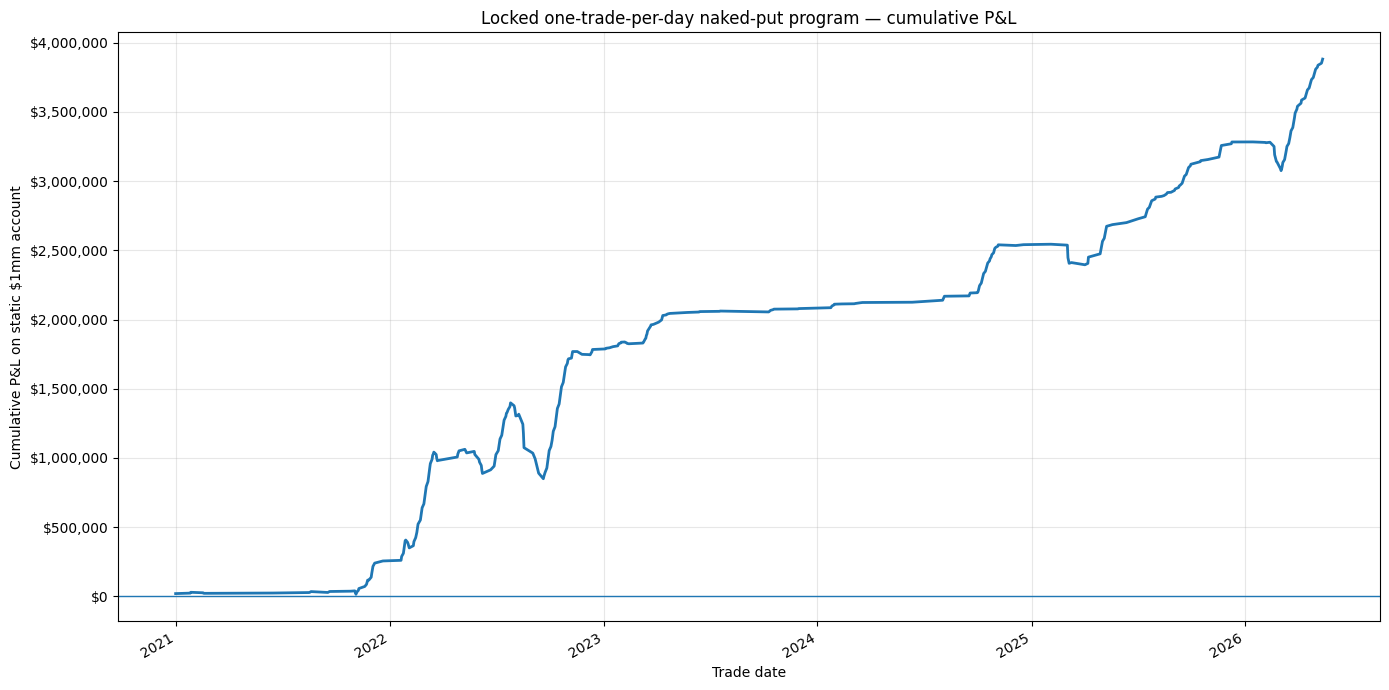


Saved outputs:
  dte_performance_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\16S_locked_dte_performance_table_20260706_143802.csv
  dte_performance_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\16S_locked_dte_performance_table_20260706_143802.parquet
  daily_cumulative_pnl_csv: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\16S_locked_cumulative_pnl_timeseries_20260706_143802.csv
  daily_cumulative_pnl_parquet: C:\Users\patri\vrp_project\data\processed\vrp_core_secondary_tertiary_independent_sizing_research_v1\16S_locked_cumulative_pnl_timeseries_20260706_143802.parquet
  chart_png: C:\Users\patri\vrp_project\data\audit\vrp_core_secondary_tertiary_independent_sizing_research_v1\charts\16S_locked_one_trade_per_day_cumulative_size_weighted_pnl_20260706_143802.png
  validation_csv: C:\Users\patri\vrp_project\data\audit

In [8]:
# ======================================================================================
# Cell 16S — Locked DTE performance table and cumulative P&L chart
# ======================================================================================
#
# Objective:
#   Produce a reporting table and cumulative P&L chart for the locked one-trade-per-day
#   naked-put sizing program.
#
# Inputs:
#   - 15S_final_one_trade_per_day_naked_put_sizing_lock_rules_*.parquet
#   - 13S_one_trade_per_day_final_size_selected_panel_*.parquet
#   - 13S_one_trade_per_day_final_size_manifest_*.json
#
# Table:
#   For each locked Core / Secondary DTE:
#       - Layer
#       - Bucket
#       - DTE
#       - Locked size
#       - Selected trades
#       - Frequency vs all base signal dates
#       - Share of selected trades
#       - Win rate
#       - Avg P&L / day
#       - Total P&L
#       - Avg size-weighted P&L / day
#       - Total size-weighted P&L
#
# Chart:
#   Cumulative size-weighted P&L over time on a static $1,000,000 account.
#
# Static account interpretation:
#   - No account growth.
#   - No account decline.
#   - Each selected trade uses the locked size as a fixed percentage of $1mm.
#   - The chart uses size_weighted_pnl_dollars from Cell 13S.
#
# This cell does NOT:
#   - change sizing
#   - change signal rules
#   - reprice options
#   - recompute P&L
#   - change selection logic
#   - add production or intraday logic
#
# ======================================================================================

from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 1000)
pd.set_option("display.width", 1800)
pd.set_option("display.max_rows", 300)

# ======================================================================================
# 0. Config
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

SIZING_BRANCH = "vrp_core_secondary_tertiary_independent_sizing_research_v1"

OUT_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / SIZING_BRANCH
OUT_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / SIZING_BRANCH
OUT_CHART_DIR = OUT_AUDIT_DIR / "charts"

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CHART_DIR.mkdir(parents=True, exist_ok=True)

CELL16S_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

REPORT_VERSION = "locked_one_trade_per_day_naked_put_dte_performance_report_v1"

SIZING_LOCK_VERSION = "final_one_trade_per_day_naked_put_sizing_locked_v1"
SIZING_LOCK_DECISION_ID = "final_one_trade_per_day_naked_put_sizing_locked_001"

PROGRAM_TYPE = "naked_short_put_tenor_selection_and_sizing"

STATIC_ACCOUNT_VALUE = 1_000_000.0
MAX_PER_TRADE_SIZE_PCT = 0.05

# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory, pattern, required=True):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)

    if matches:
        return matches[0]

    if required:
        raise FileNotFoundError(f"No file found in {directory} matching {pattern}")

    return None


def add_validation(rows, check, status, detail):
    rows.append({
        "check": check,
        "status": status,
        "detail": detail,
    })


def as_num(s):
    return pd.to_numeric(s, errors="coerce")


def pct_label(x):
    if pd.isna(x):
        return None

    return f"{100 * float(x):.2f}%"


def dollar_fmt(x, pos=None):
    if pd.isna(x):
        return ""

    return f"${x:,.0f}"


def profit_factor(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    gross_profit = float(x[x > 0].sum())
    gross_loss = float(x[x < 0].sum())

    if gross_loss < 0:
        return gross_profit / abs(gross_loss)

    if gross_profit > 0:
        return np.inf

    return np.nan


def max_drawdown(pnl):
    x = as_num(pnl).dropna().astype(float)

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum().to_numpy()
    running_peak = np.maximum.accumulate(np.r_[0.0, cumulative])[:-1]
    drawdowns = cumulative - running_peak

    return float(np.min(drawdowns))


def var_es_stats(pnl, q):
    x = as_num(pnl).dropna().astype(float)

    label = int(q * 100)

    if len(x) == 0:
        return {
            f"var_{label}pct": np.nan,
            f"expected_shortfall_{label}pct": np.nan,
            f"expected_loss_{label}pct_positive": np.nan,
            f"tail_count_{label}pct": 0,
        }

    cutoff = float(x.quantile(q))
    tail = x[x <= cutoff]
    es = float(tail.mean()) if len(tail) else np.nan

    return {
        f"var_{label}pct": cutoff,
        f"expected_shortfall_{label}pct": es,
        f"expected_loss_{label}pct_positive": max(0.0, -es) if pd.notna(es) else np.nan,
        f"tail_count_{label}pct": int(len(tail)),
    }


# ======================================================================================
# 2. Load inputs
# ======================================================================================

lock_rules_path = latest_file(
    OUT_PROCESSED_DIR,
    "15S_final_one_trade_per_day_naked_put_sizing_lock_rules_*.parquet",
    required=True,
)

selected_panel_path = latest_file(
    OUT_PROCESSED_DIR,
    "13S_one_trade_per_day_final_size_selected_panel_*.parquet",
    required=True,
)

cell13_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "13S_one_trade_per_day_final_size_manifest_*.json",
    required=False,
)

cell15_validation_path = latest_file(
    OUT_AUDIT_DIR,
    "15S_final_one_trade_per_day_naked_put_sizing_lock_validation_*.csv",
    required=True,
)

cell15_manifest_path = latest_file(
    OUT_AUDIT_DIR,
    "15S_final_one_trade_per_day_naked_put_sizing_lock_manifest_*.json",
    required=False,
)

lock_rules = pd.read_parquet(lock_rules_path)
selected_panel = pd.read_parquet(selected_panel_path)
cell15_validation = pd.read_csv(cell15_validation_path)

selected_panel["trade_date"] = pd.to_datetime(
    selected_panel["trade_date"],
    errors="coerce",
).dt.normalize()

for c in [
    "tenor",
    "final_recommended_size_pct",
    "locked_size_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "size_weighted_pnl_dollars",
    "size_weighted_pnl_per_day",
    "win",
]:
    if c in selected_panel.columns:
        selected_panel[c] = pd.to_numeric(selected_panel[c], errors="coerce")

for c in [
    "tenor",
    "locked_size_pct",
    "final_recommended_size_pct",
    "tail_budget_rounded_size_pct",
    "manual_minus_model_size_pct",
    "sizing_quality_score",
    "win_rate",
    "avg_pnl_per_day",
    "profit_factor_pnl_per_day",
    "pnl_per_day_expected_loss_1pct_positive",
    "avg_pnl_per_day_2026",
]:
    if c in lock_rules.columns:
        lock_rules[c] = pd.to_numeric(lock_rules[c], errors="coerce")

if cell13_manifest_path is not None:
    with open(cell13_manifest_path, "r", encoding="utf-8") as f:
        cell13_manifest = json.load(f)
else:
    cell13_manifest = {}

if cell15_manifest_path is not None:
    with open(cell15_manifest_path, "r", encoding="utf-8") as f:
        cell15_manifest = json.load(f)
else:
    cell15_manifest = {}

total_signal_dates = (
    cell13_manifest.get("row_counts", {}).get("total_signal_dates")
    or cell15_manifest.get("row_counts", {}).get("total_signal_dates")
)

if total_signal_dates is None:
    # Fallback: selected frequency cannot be computed vs full base universe without manifest.
    # Use selected unique dates as denominator only as a last-resort fallback.
    total_signal_dates = int(selected_panel["trade_date"].nunique())

total_signal_dates = int(total_signal_dates)

# ======================================================================================
# 3. Validate inputs
# ======================================================================================

validation_rows = []

cell15_failures = (
    cell15_validation[cell15_validation["status"].eq("FAIL")]
    if {"check", "status"}.issubset(cell15_validation.columns)
    else pd.DataFrame({"missing_status_cols": [1]})
)

required_selected_cols = [
    "trade_date",
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "final_recommended_size_pct",
    "normalized_pnl_dollars",
    "normalized_pnl_per_day",
    "size_weighted_pnl_dollars",
    "size_weighted_pnl_per_day",
    "win",
]

required_lock_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "locked_size_pct",
    "sizing_lock_decision_id",
    "program_type",
]

missing_selected_cols = [
    c for c in required_selected_cols
    if c not in selected_panel.columns
]

missing_lock_cols = [
    c for c in required_lock_cols
    if c not in lock_rules.columns
]

bad_lock_decision = (
    lock_rules[
        ~lock_rules["sizing_lock_decision_id"].eq(SIZING_LOCK_DECISION_ID)
    ]
    if "sizing_lock_decision_id" in lock_rules.columns
    else lock_rules
)

bad_program_type = (
    lock_rules[
        ~lock_rules["program_type"].eq(PROGRAM_TYPE)
    ]
    if "program_type" in lock_rules.columns
    else lock_rules
)

bad_core_front_lock = lock_rules[
    lock_rules["signal_layer"].eq("Core")
    & lock_rules["tenor_bucket"].eq("Front")
] if {"signal_layer", "tenor_bucket"}.issubset(lock_rules.columns) else lock_rules

bad_tertiary_lock = lock_rules[
    lock_rules["signal_layer"].eq("Tertiary")
] if "signal_layer" in lock_rules.columns else lock_rules

bad_duplicate_selected_dates = (
    selected_panel
    .groupby("trade_date")
    .size()
    .reset_index(name="rows")
)

bad_duplicate_selected_dates = bad_duplicate_selected_dates[
    bad_duplicate_selected_dates["rows"].gt(1)
]

add_validation(
    validation_rows,
    "lock_rules_loaded",
    "PASS" if len(lock_rules) == 13 else "FAIL",
    f"rows={len(lock_rules):,}; path={lock_rules_path}",
)

add_validation(
    validation_rows,
    "selected_panel_loaded",
    "PASS" if len(selected_panel) > 0 else "FAIL",
    f"rows={len(selected_panel):,}; path={selected_panel_path}",
)

add_validation(
    validation_rows,
    "cell15_validation_passed",
    "PASS" if cell15_failures.empty else "FAIL",
    f"failures={len(cell15_failures):,}; path={cell15_validation_path}",
)

add_validation(
    validation_rows,
    "required_selected_columns_available",
    "PASS" if not missing_selected_cols else "FAIL",
    f"missing={missing_selected_cols}",
)

add_validation(
    validation_rows,
    "required_lock_columns_available",
    "PASS" if not missing_lock_cols else "FAIL",
    f"missing={missing_lock_cols}",
)

add_validation(
    validation_rows,
    "sizing_lock_decision_matches",
    "PASS" if bad_lock_decision.empty else "FAIL",
    f"bad_rows={len(bad_lock_decision):,}; expected={SIZING_LOCK_DECISION_ID}",
)

add_validation(
    validation_rows,
    "program_type_matches_naked_put",
    "PASS" if bad_program_type.empty else "FAIL",
    f"bad_rows={len(bad_program_type):,}; expected={PROGRAM_TYPE}",
)

add_validation(
    validation_rows,
    "no_core_front_in_lock",
    "PASS" if bad_core_front_lock.empty else "FAIL",
    f"bad_rows={len(bad_core_front_lock):,}",
)

add_validation(
    validation_rows,
    "no_tertiary_in_lock",
    "PASS" if bad_tertiary_lock.empty else "FAIL",
    f"bad_rows={len(bad_tertiary_lock):,}",
)

add_validation(
    validation_rows,
    "selected_panel_one_trade_per_day",
    "PASS" if bad_duplicate_selected_dates.empty else "FAIL",
    f"bad_dates={len(bad_duplicate_selected_dates):,}; selected_rows={len(selected_panel):,}",
)

add_validation(
    validation_rows,
    "total_signal_dates_available",
    "PASS" if total_signal_dates > 0 else "FAIL",
    f"total_signal_dates={total_signal_dates:,}",
)

input_validation = pd.DataFrame(validation_rows)
input_failures = input_validation[input_validation["status"].eq("FAIL")]

if not input_failures.empty:
    display(input_validation)
    raise RuntimeError("Cell 16S input validation failed. Review validation output above.")

# ======================================================================================
# 4. Build DTE performance table
# ======================================================================================

# Ensure selected panel has locked size attached from the lock table.
selected = selected_panel.copy()

selected = selected.merge(
    lock_rules[
        [
            "sleeve_id",
            "locked_size_pct",
            "sizing_lock_version",
            "sizing_lock_decision_id",
            "program_type",
            "program_label",
        ]
    ],
    on="sleeve_id",
    how="left",
    suffixes=("", "_locked"),
)

# Prefer the locked size from Cell 15S.
selected["locked_size_pct"] = selected["locked_size_pct"].combine_first(
    selected["final_recommended_size_pct"]
)

# Recompute static size-weighted P&L if missing or to validate consistency.
selected["recomputed_size_weight_multiplier_vs_5pct"] = (
    selected["locked_size_pct"] / MAX_PER_TRADE_SIZE_PCT
)

selected["recomputed_size_weighted_pnl_dollars"] = (
    selected["normalized_pnl_dollars"]
    * selected["recomputed_size_weight_multiplier_vs_5pct"]
)

selected["recomputed_size_weighted_pnl_per_day"] = (
    selected["normalized_pnl_per_day"]
    * selected["recomputed_size_weight_multiplier_vs_5pct"]
)

selected["size_weighted_pnl_diff"] = (
    selected["size_weighted_pnl_dollars"]
    - selected["recomputed_size_weighted_pnl_dollars"]
)

# Use existing Cell 13S size-weighted fields if present; otherwise use recomputed fields.
selected["report_size_weighted_pnl_dollars"] = selected["size_weighted_pnl_dollars"].combine_first(
    selected["recomputed_size_weighted_pnl_dollars"]
)

selected["report_size_weighted_pnl_per_day"] = selected["size_weighted_pnl_per_day"].combine_first(
    selected["recomputed_size_weighted_pnl_per_day"]
)

selected["static_account_value"] = STATIC_ACCOUNT_VALUE
selected["locked_notional_at_risk_proxy"] = selected["locked_size_pct"] * STATIC_ACCOUNT_VALUE

group_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "locked_size_pct",
]

selected_dte_perf = (
    selected
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(
        selected_trades=("sleeve_id", "count"),
        first_trade_date=("trade_date", "min"),
        last_trade_date=("trade_date", "max"),

        win_rate=("win", "mean"),

        total_pnl=("normalized_pnl_dollars", "sum"),
        avg_pnl_per_day=("normalized_pnl_per_day", "mean"),
        median_pnl_per_day=("normalized_pnl_per_day", "median"),
        worst_trade_pnl_per_day=("normalized_pnl_per_day", "min"),
        best_trade_pnl_per_day=("normalized_pnl_per_day", "max"),

        total_size_weighted_pnl=("report_size_weighted_pnl_dollars", "sum"),
        avg_size_weighted_pnl_per_day=("report_size_weighted_pnl_per_day", "mean"),
        median_size_weighted_pnl_per_day=("report_size_weighted_pnl_per_day", "median"),
        worst_size_weighted_trade_pnl_per_day=("report_size_weighted_pnl_per_day", "min"),
        best_size_weighted_trade_pnl_per_day=("report_size_weighted_pnl_per_day", "max"),

        avg_locked_notional_at_risk_proxy=("locked_notional_at_risk_proxy", "mean"),
    )
)

selected_dte_perf["frequency_vs_base_signal_dates"] = (
    selected_dte_perf["selected_trades"] / total_signal_dates
)

selected_dte_perf["share_of_selected_trades"] = (
    selected_dte_perf["selected_trades"] / len(selected)
)

selected_dte_perf["profit_factor_pnl_per_day"] = np.nan
selected_dte_perf["profit_factor_size_weighted_pnl_per_day"] = np.nan
selected_dte_perf["drawdown_size_weighted_pnl"] = np.nan
selected_dte_perf["one_pct_expected_loss_size_weighted_pnl_per_day"] = np.nan
selected_dte_perf["five_pct_expected_loss_size_weighted_pnl_per_day"] = np.nan

for idx, row in selected_dte_perf.iterrows():
    sleeve_id = row["sleeve_id"]
    g = selected[selected["sleeve_id"].eq(sleeve_id)].sort_values("trade_date")

    selected_dte_perf.loc[idx, "profit_factor_pnl_per_day"] = profit_factor(
        g["normalized_pnl_per_day"]
    )

    selected_dte_perf.loc[idx, "profit_factor_size_weighted_pnl_per_day"] = profit_factor(
        g["report_size_weighted_pnl_per_day"]
    )

    selected_dte_perf.loc[idx, "drawdown_size_weighted_pnl"] = max_drawdown(
        g["report_size_weighted_pnl_dollars"]
    )

    es_1 = var_es_stats(g["report_size_weighted_pnl_per_day"], 0.01)
    es_5 = var_es_stats(g["report_size_weighted_pnl_per_day"], 0.05)

    selected_dte_perf.loc[idx, "one_pct_expected_loss_size_weighted_pnl_per_day"] = es_1[
        "expected_loss_1pct_positive"
    ]

    selected_dte_perf.loc[idx, "five_pct_expected_loss_size_weighted_pnl_per_day"] = es_5[
        "expected_loss_5pct_positive"
    ]

# Include locked sleeves that were never selected, if any.
locked_base_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "locked_size_pct",
    "display_order",
]

locked_base_cols = [c for c in locked_base_cols if c in lock_rules.columns]

dte_performance = lock_rules[locked_base_cols].merge(
    selected_dte_perf,
    on=[
        "sleeve_id",
        "signal_layer",
        "tenor_bucket",
        "tenor",
        "locked_size_pct",
    ],
    how="left",
)

fill_zero_cols = [
    "selected_trades",
    "frequency_vs_base_signal_dates",
    "share_of_selected_trades",
    "total_pnl",
    "total_size_weighted_pnl",
]

for c in fill_zero_cols:
    if c in dte_performance.columns:
        dte_performance[c] = dte_performance[c].fillna(0)

dte_performance["locked_size_label"] = dte_performance["locked_size_pct"].map(pct_label)
dte_performance["frequency_vs_base_signal_dates_label"] = dte_performance[
    "frequency_vs_base_signal_dates"
].map(pct_label)

dte_performance["share_of_selected_trades_label"] = dte_performance[
    "share_of_selected_trades"
].map(pct_label)

dte_performance = dte_performance.sort_values(
    [
        "display_order" if "display_order" in dte_performance.columns else "signal_layer",
        "tenor",
    ]
).reset_index(drop=True)

dte_performance["report_version"] = REPORT_VERSION
dte_performance["sizing_lock_version"] = SIZING_LOCK_VERSION
dte_performance["sizing_lock_decision_id"] = SIZING_LOCK_DECISION_ID
dte_performance["static_account_value"] = STATIC_ACCOUNT_VALUE

# ======================================================================================
# 5. Cumulative P&L time series
# ======================================================================================

daily_pnl = (
    selected
    .groupby("trade_date", as_index=False)
    .agg(
        selected_trades=("sleeve_id", "count"),
        sleeve_id=("sleeve_id", "first"),
        signal_layer=("signal_layer", "first"),
        tenor_bucket=("tenor_bucket", "first"),
        tenor=("tenor", "first"),
        locked_size_pct=("locked_size_pct", "first"),
        daily_pnl=("normalized_pnl_dollars", "sum"),
        daily_pnl_per_day=("normalized_pnl_per_day", "sum"),
        daily_size_weighted_pnl=("report_size_weighted_pnl_dollars", "sum"),
        daily_size_weighted_pnl_per_day=("report_size_weighted_pnl_per_day", "sum"),
    )
    .sort_values("trade_date")
    .reset_index(drop=True)
)

daily_pnl["cumulative_pnl"] = daily_pnl["daily_pnl"].cumsum()
daily_pnl["cumulative_size_weighted_pnl"] = daily_pnl["daily_size_weighted_pnl"].cumsum()
daily_pnl["static_account_value"] = STATIC_ACCOUNT_VALUE
daily_pnl["cumulative_size_weighted_return_on_static_account"] = (
    daily_pnl["cumulative_size_weighted_pnl"] / STATIC_ACCOUNT_VALUE
)

daily_pnl["daily_size_weighted_return_on_static_account"] = (
    daily_pnl["daily_size_weighted_pnl"] / STATIC_ACCOUNT_VALUE
)

daily_pnl["running_peak_cumulative_size_weighted_pnl"] = daily_pnl[
    "cumulative_size_weighted_pnl"
].cummax()

daily_pnl["drawdown_cumulative_size_weighted_pnl"] = (
    daily_pnl["cumulative_size_weighted_pnl"]
    - daily_pnl["running_peak_cumulative_size_weighted_pnl"]
)

# ======================================================================================
# 6. Plot cumulative P&L
# ======================================================================================

chart_path = OUT_CHART_DIR / f"16S_locked_one_trade_per_day_cumulative_size_weighted_pnl_{CELL16S_TIMESTAMP}.png"

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    daily_pnl["trade_date"],
    daily_pnl["cumulative_size_weighted_pnl"],
    linewidth=2,
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Locked one-trade-per-day naked-put program — cumulative P&L"
)

ax.set_xlabel("Trade date")
ax.set_ylabel("Cumulative P&L on static $1mm account")

ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(chart_path, dpi=150, bbox_inches="tight")

# ======================================================================================
# 7. Output validation
# ======================================================================================

output_validation_rows = []

bad_size_weighted_recompute = selected[
    selected["size_weighted_pnl_diff"].abs().gt(1e-6)
]

bad_daily_multiple = daily_pnl[
    daily_pnl["selected_trades"].gt(1)
]

bad_perf_missing_locked = dte_performance[
    dte_performance["locked_size_pct"].isna()
]

add_validation(
    output_validation_rows,
    "dte_performance_has_13_locked_sleeves",
    "PASS" if len(dte_performance) == 13 else "FAIL",
    f"rows={len(dte_performance):,}; expected=13",
)

add_validation(
    output_validation_rows,
    "selected_trades_reconcile_to_selected_panel",
    "PASS" if int(dte_performance["selected_trades"].sum()) == len(selected) else "FAIL",
    f"dte_selected_sum={int(dte_performance['selected_trades'].sum()):,}; selected_panel_rows={len(selected):,}",
)

add_validation(
    output_validation_rows,
    "daily_pnl_one_trade_per_day",
    "PASS" if bad_daily_multiple.empty else "FAIL",
    f"bad_days={len(bad_daily_multiple):,}",
)

add_validation(
    output_validation_rows,
    "size_weighted_pnl_recomputed_matches_cell13",
    "PASS" if bad_size_weighted_recompute.empty else "WARN",
    f"bad_rows={len(bad_size_weighted_recompute):,}; tolerance=1e-6",
)

add_validation(
    output_validation_rows,
    "all_locked_sleeves_have_size",
    "PASS" if bad_perf_missing_locked.empty else "FAIL",
    f"bad_rows={len(bad_perf_missing_locked):,}",
)

add_validation(
    output_validation_rows,
    "cumulative_pnl_chart_saved",
    "PASS" if chart_path.exists() else "FAIL",
    f"path={chart_path}",
)

add_validation(
    output_validation_rows,
    "no_sizing_changes",
    "PASS",
    "Reporting cell only. Sizing lock artifacts are not modified.",
)

add_validation(
    output_validation_rows,
    "no_signal_or_pnl_changes",
    "PASS",
    "Reporting cell only. Signal rules and P&L fields are not modified.",
)

output_validation = pd.DataFrame(output_validation_rows)

validation = pd.concat(
    [
        input_validation.assign(validation_stage="input_validation"),
        output_validation.assign(validation_stage="output_validation"),
    ],
    ignore_index=True,
    sort=False,
)

failures = validation[validation["status"].eq("FAIL")]

# ======================================================================================
# 8. Save outputs
# ======================================================================================

paths = {}

paths["dte_performance_csv"] = OUT_AUDIT_DIR / f"16S_locked_dte_performance_table_{CELL16S_TIMESTAMP}.csv"
paths["dte_performance_parquet"] = OUT_PROCESSED_DIR / f"16S_locked_dte_performance_table_{CELL16S_TIMESTAMP}.parquet"

paths["daily_cumulative_pnl_csv"] = OUT_AUDIT_DIR / f"16S_locked_cumulative_pnl_timeseries_{CELL16S_TIMESTAMP}.csv"
paths["daily_cumulative_pnl_parquet"] = OUT_PROCESSED_DIR / f"16S_locked_cumulative_pnl_timeseries_{CELL16S_TIMESTAMP}.parquet"

paths["chart_png"] = chart_path

paths["validation_csv"] = OUT_AUDIT_DIR / f"16S_locked_dte_performance_validation_{CELL16S_TIMESTAMP}.csv"

dte_performance.to_csv(paths["dte_performance_csv"], index=False)
dte_performance.to_parquet(paths["dte_performance_parquet"], index=False)

daily_pnl.to_csv(paths["daily_cumulative_pnl_csv"], index=False)
daily_pnl.to_parquet(paths["daily_cumulative_pnl_parquet"], index=False)

validation.to_csv(paths["validation_csv"], index=False)

manifest = {
    "cell": "Cell 16S — Locked DTE performance table and cumulative P&L chart",
    "timestamp": CELL16S_TIMESTAMP,
    "report_version": REPORT_VERSION,
    "sizing_lock_version": SIZING_LOCK_VERSION,
    "sizing_lock_decision_id": SIZING_LOCK_DECISION_ID,
    "program_type": PROGRAM_TYPE,
    "static_account_value": STATIC_ACCOUNT_VALUE,
    "pnl_basis": {
        "table_main_pnl": "size_weighted_pnl_dollars and size_weighted_pnl_per_day",
        "chart_pnl": "cumulative size_weighted_pnl_dollars",
        "account_assumption": "Static $1,000,000 account. No account growth or decline.",
    },
    "source_paths": {
        "lock_rules_path": str(lock_rules_path),
        "selected_panel_path": str(selected_panel_path),
        "cell13_manifest_path": str(cell13_manifest_path),
        "cell15_validation_path": str(cell15_validation_path),
        "cell15_manifest_path": str(cell15_manifest_path),
    },
    "row_counts": {
        "locked_sleeves": int(len(lock_rules)),
        "selected_trades": int(len(selected)),
        "selected_unique_dates": int(selected["trade_date"].nunique()),
        "total_signal_dates": int(total_signal_dates),
        "dte_performance_rows": int(len(dte_performance)),
        "daily_pnl_rows": int(len(daily_pnl)),
    },
    "paths": {k: str(v) for k, v in paths.items()},
}

paths["manifest_json"] = OUT_AUDIT_DIR / f"16S_locked_dte_performance_manifest_{CELL16S_TIMESTAMP}.json"

with open(paths["manifest_json"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

if not failures.empty:
    display(validation)
    display(dte_performance)
    raise RuntimeError("Cell 16S validation failed. Review validation output above.")

# ======================================================================================
# 9. Display
# ======================================================================================

display_cols = [
    "sleeve_id",
    "signal_layer",
    "tenor_bucket",
    "tenor",
    "locked_size_label",
    "selected_trades",
    "frequency_vs_base_signal_dates",
    "frequency_vs_base_signal_dates_label",
    "share_of_selected_trades",
    "share_of_selected_trades_label",
    "win_rate",
    "avg_pnl_per_day",
    "total_pnl",
    "avg_size_weighted_pnl_per_day",
    "total_size_weighted_pnl",
    "profit_factor_size_weighted_pnl_per_day",
    "one_pct_expected_loss_size_weighted_pnl_per_day",
    "five_pct_expected_loss_size_weighted_pnl_per_day",
    "drawdown_size_weighted_pnl",
]

summary_rows = pd.DataFrame([
    {
        "metric": "Selected trades",
        "value": len(selected),
    },
    {
        "metric": "Selected unique dates",
        "value": selected["trade_date"].nunique(),
    },
    {
        "metric": "Total base signal dates",
        "value": total_signal_dates,
    },
    {
        "metric": "Program frequency",
        "value": selected["trade_date"].nunique() / total_signal_dates,
    },
    {
        "metric": "Total size-weighted P&L",
        "value": daily_pnl["daily_size_weighted_pnl"].sum(),
    },
    {
        "metric": "Final cumulative size-weighted P&L",
        "value": daily_pnl["cumulative_size_weighted_pnl"].iloc[-1],
    },
    {
        "metric": "Final cumulative return on static $1mm",
        "value": daily_pnl["cumulative_size_weighted_return_on_static_account"].iloc[-1],
    },
    {
        "metric": "Worst cumulative drawdown",
        "value": daily_pnl["drawdown_cumulative_size_weighted_pnl"].min(),
    },
])

print("=" * 100)
print("Cell 16S — Locked DTE performance table and cumulative P&L chart")
print("=" * 100)
print(f"Sizing lock:                   {SIZING_LOCK_DECISION_ID}")
print(f"Program type:                  {PROGRAM_TYPE}")
print(f"Static account value:           ${STATIC_ACCOUNT_VALUE:,.0f}")
print(f"Selected trades:                {len(selected):,}")
print(f"Selected unique dates:          {selected['trade_date'].nunique():,}")
print(f"Total base signal dates:        {total_signal_dates:,}")
print(f"Chart saved:                    {chart_path}")
print()
print("Validation:")
display(validation)

print()
print("Summary:")
display(summary_rows)

print()
print("DTE performance table:")
display(dte_performance[[c for c in display_cols if c in dte_performance.columns]])

print()
print("Cumulative P&L time series preview:")
display(daily_pnl.head(10))

print()
display(daily_pnl.tail(10))

print()
print("Cumulative P&L chart:")
plt.show()

print()
print("Saved outputs:")
for k, p in paths.items():
    print(f"  {k}: {p}")

print("\nCELL 16S PASSED — LOCKED DTE PERFORMANCE TABLE AND CUMULATIVE P&L CHART COMPLETE")